In [4]:
### Load the data

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the JSON responses
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/results/results_with_uq/llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# Extract the answers from the DataFrame
true_answers = dict(zip(range(2787, 2866), df['answer']))

### Binwise calculate accuracy 

In [ ]:
# Initialize lists to store uncertainties and accuracies
confidences = []
accuracies = []

# Extract data from responses_with_uncertainty
key_to_check_similarity = 'avg_similarity_within_group'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))

        # correct = sum(response['answer'] == true_answer for response in responses)
        correct = 0
        for response in responses:
            try:
                if isinstance(response, dict) and response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"Response {response} does not contain 'answer' key. Skipping this response.")
            except TypeError:
                print(f"Unexpected data type in response: {response}. Skipping this response.")
        avg_accuracy = correct / len(responses)
        
        confidences.append(confidence)
        accuracies.append(avg_accuracy)

# Convert lists to NumPy arrays and handle NaNs
confidences = np.array(confidences)
accuracies = np.array(accuracies)

# Remove NaNs
confidences_copy = confidences.copy()
confidences = confidences[~np.isnan(confidences_copy)]
accuracies = accuracies[~np.isnan(confidences_copy)]

### Plot Uncertainy vs Accuracy ( Bin data by uncertainty )

In [ ]:
# Bin data by uncertainty
def bin_data(confidences, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

        # Debugging: Print bin details
        print(f"Bin {i}: Center = {bin_centers[i]:.2f}, Accuracy = {bin_accuracies[-1]:.2f}, Count = {np.sum(bin_mask)}")

    return bin_centers, bin_accuracies

# Plot the calibration curve
def plot_calibration_curve(confidences, accuracies, num_bins=10):
    bin_centers, bin_accuracies = bin_data(confidences, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Consistency with Group by Graph Similarity Reliability Curve: Confidence vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the calibration curve
plot_calibration_curve(confidences, accuracies, num_bins=10)

### Plot Uncertainty vs confidence ( Bin by confidence )

100%|██████████| 80/80 [00:00<00:00, 59314.89it/s]

Response {'question': 'Which caption accurately orders car features (tub, flags, roof) and other contextual information (event/year, location)?', 'options': ['A', 'C', 'B', 'D'], 'explanation': "This caption is correct as it incorporates all accurate features (tub on the roof, flags attached) and situates the car in context (Mongol Rally) and time (2009). It mentions the car being decorated with flames, which is a car feature, but without a clear picture, it's not possible to validate this from the image. Additionally, it correctly places the year and event as the Mongol Rally in 2009."} does not contain 'answer' key. Skipping this response.
Response {'explanation': "The given image has cars lined up with decals and a racing theme, likely for the Mongol Rally. The caption that accurately reflects this scenario is 'C. With a tub resting on its outer roof, flags attached, the car is ready to take off for the rally.' This is because of the specific detail of the tub on the roof and the fl

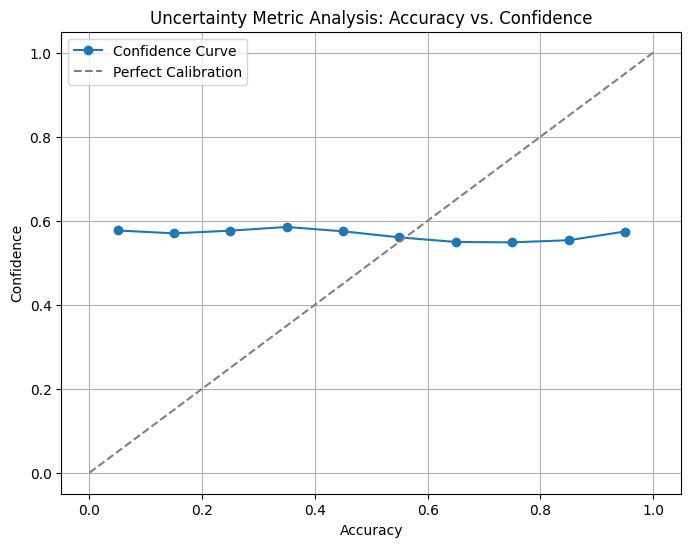

In [9]:
# Initialize lists to store uncertainties and accuracies
confidences = []
accuracies = []

# Extract data from responses_with_uncertainty
key_to_check_similarity = 'uncertainty'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        if key_to_check_similarity.lower() == 'uncertainty':
            confidence = 1 - result[key_to_check_similarity]
        else:
            confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))

        # correct = sum(response['answer'] == true_answer for response in responses)
        correct = 0
        for response in responses:
            try:
                if isinstance(response, dict) and response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"Response {response} does not contain 'answer' key. Skipping this response.")
            except TypeError:
                print(f"Unexpected data type in response: {response}. Skipping this response.")
        avg_accuracy = correct / len(responses)
        
        confidences.append(confidence)
        accuracies.append(avg_accuracy)

# Convert lists to NumPy arrays and handle NaNs
confidences = np.array(confidences)
accuracies = np.array(accuracies)

# Remove NaNs
accuracies_copy = accuracies.copy()
accuracies = accuracies[~np.isnan(accuracies_copy)]
confidences = confidences[~np.isnan(accuracies_copy)]

# Bin data by accuracy
def bin_data_by_accuracy(accuracies, confidences, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(accuracies, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_confidences = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_confidences.append(np.mean(confidences[bin_mask]))
        else:
            bin_confidences.append(0)  # If no data points fall in the bin, set confidence to 0

        # Debugging: Print bin details
        print(f"Bin {i}: Center = {bin_centers[i]:.2f}, Confidence = {bin_confidences[-1]:.2f}, Count = {np.sum(bin_mask)}")

    return bin_centers, bin_confidences

# Plot the confidence curve binned by accuracy
def plot_confidence_curve(accuracies, confidences, num_bins=10):
    bin_centers, bin_confidences = bin_data_by_accuracy(accuracies, confidences, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_confidences, marker='o', label='Confidence Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Accuracy')
    plt.ylabel('Confidence')
    plt.title('Uncertainty Metric Analysis: Accuracy vs. Confidence')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the confidence curve binned by accuracy
plot_confidence_curve(accuracies, confidences, num_bins=10)

In [13]:
# responses_with_uncertainty

### Save the keys to visualize the graphs 

100%|██████████| 80/80 [00:00<00:00, 61533.89it/s]

Response {'question': 'Which caption accurately orders car features (tub, flags, roof) and other contextual information (event/year, location)?', 'options': ['A', 'C', 'B', 'D'], 'explanation': "This caption is correct as it incorporates all accurate features (tub on the roof, flags attached) and situates the car in context (Mongol Rally) and time (2009). It mentions the car being decorated with flames, which is a car feature, but without a clear picture, it's not possible to validate this from the image. Additionally, it correctly places the year and event as the Mongol Rally in 2009."} does not contain 'answer' key. Skipping this response.
Response {'explanation': "The given image has cars lined up with decals and a racing theme, likely for the Mongol Rally. The caption that accurately reflects this scenario is 'C. With a tub resting on its outer roof, flags attached, the car is ready to take off for the rally.' This is because of the specific detail of the tub on the roof and the fl

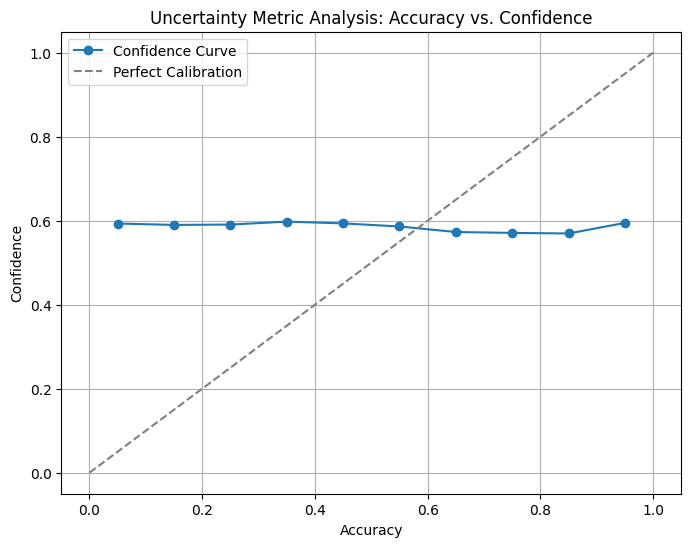

In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the JSON responses
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/results/results_with_uq/llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# Extract the answers from the DataFrame
true_answers = dict(zip(range(2787, 2866), df['answer']))

# Initialize lists to store accuracies and confidences
accuracies = []
confidences = []
response_keys = []

# Extract data from responses_with_uncertainty
key_to_check_similarity = 'avg_similarity_within_group'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))

        # correct = sum(response['answer'] == true_answer for response in responses)
        correct = 0
        for response in responses:
            try:
                if isinstance(response, dict) and response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"Response {response} does not contain 'answer' key. Skipping this response.")
            except TypeError:
                print(f"Unexpected data type in response: {response}. Skipping this response.")
        avg_accuracy = correct / len(responses)
        confidences.append(confidence)
        accuracies.append(avg_accuracy)
        response_keys.append(int(idx))

# Convert lists to NumPy arrays and handle NaNs
confidences = np.array(confidences)
accuracies = np.array(accuracies)
response_keys = np.array(response_keys)

# Remove NaNs
accuracies_copy = accuracies.copy()
accuracies = accuracies[~np.isnan(accuracies_copy)]
confidences = confidences[~np.isnan(accuracies_copy)]
response_keys = response_keys[~np.isnan(accuracies_copy)]

# Bin data by accuracy
def bin_data_by_accuracy(accuracies, confidences, response_keys, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(accuracies, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_confidences = []
    bin_counts = []
    bin_keys = [[] for _ in range(num_bins)]

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_confidences.append(np.mean(confidences[bin_mask]))
            bin_counts.append(np.sum(bin_mask))
            bin_keys[i].extend(response_keys[bin_mask].tolist())
        else:
            bin_confidences.append(0)  # If no data points fall in the bin, set confidence to 0
            bin_counts.append(0)

        # Debugging: Print bin details
        print(f"Bin {i}: Center = {bin_centers[i]:.2f}, Confidence = {bin_confidences[-1]:.2f}, Count = {bin_counts[-1]}")

    # Convert to lists to ensure they are serializable
    bin_results = {
        "bin_centers": [float(center) for center in bin_centers],
        "bin_confidences": [float(conf) for conf in bin_confidences],
        "bin_counts": [int(count) for count in bin_counts],
        "bin_keys": [[int(key) for key in bin_keys] for bin_keys in bin_keys]
    }

    return bin_results

# Plot the confidence curve binned by accuracy
def plot_confidence_curve(bin_results):
    plt.figure(figsize=(8, 6))
    plt.plot(bin_results["bin_centers"], bin_results["bin_confidences"], marker='o', label='Confidence Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Accuracy')
    plt.ylabel('Confidence')
    plt.title('Uncertainty Metric Analysis: Accuracy vs. Confidence')
    plt.legend()
    plt.grid(True)
    plt.show()

# Bin data and plot the confidence curve
bin_results = bin_data_by_accuracy(accuracies, confidences, response_keys, num_bins=10)
plot_confidence_curve(bin_results)

# Convert keys to standard Python integers for JSON serialization
bin_results["bin_keys"] = [[int(key) for key in bin_keys] for bin_keys in bin_results["bin_keys"]]

# Save bin results to a JSON file
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/bin_results.json', 'w') as outfile:
    json.dump(bin_results, outfile, indent=4)


### Load MMT Dataset

In [1]:
import pandas as pd

df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]


In [3]:
# df.loc[2825, 'image']

In [5]:
import json
json_path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/debug_llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json'
with open(json_path, 'r') as file:
    responses = json.load(file)

### Visualize the graphs

In [2]:
import json
# bin 1
path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/debug_bin_1_llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json'
with open(path, 'r') as file:
    bin_1_results = json.load(file)


In [4]:
bin_1_results

{'2789': {'prompt': "\n            Question: Based on the given image, which caption has the most correct ordering of the constituents?\n\nChoose the best answer from the following choices.\n            A. A small car decorated with flames and other paint is driving amongst a crowd with a tub and flags on the roof.\n            B. A car with a bathtub on top participating in the Mongol Rally in '09.\n            C. With a tub resting on its outer roof, flags attached, the car is ready to take off for the rally.\n            D. A Norfolk Race car with flames on the hood.\n            \n            Give your answer in JSON format where the keys are answer(one or more options above), explanation( explain your answer), and confidence(varies between 0 to 1).\n            \n            ",
  'responses': [{'answer': 'B',
    'explanation': "The caption describes a vehicle that is participating in the Mongol Rally with a bathtub on top. This is the most accurately depicted in the image, as it 

Visualizing for index: 2789
Explanation: The caption describes a vehicle that is participating in the Mongol Rally with a bathtub on top. This is the most accurately depicted in the image, as it shows a car with an object placed on its roof, which is a tub. The text also references the Mongol Rally '09, which is consistent with the timestamp on the photo. No other choice quite accurately captures all elements shown in the image.


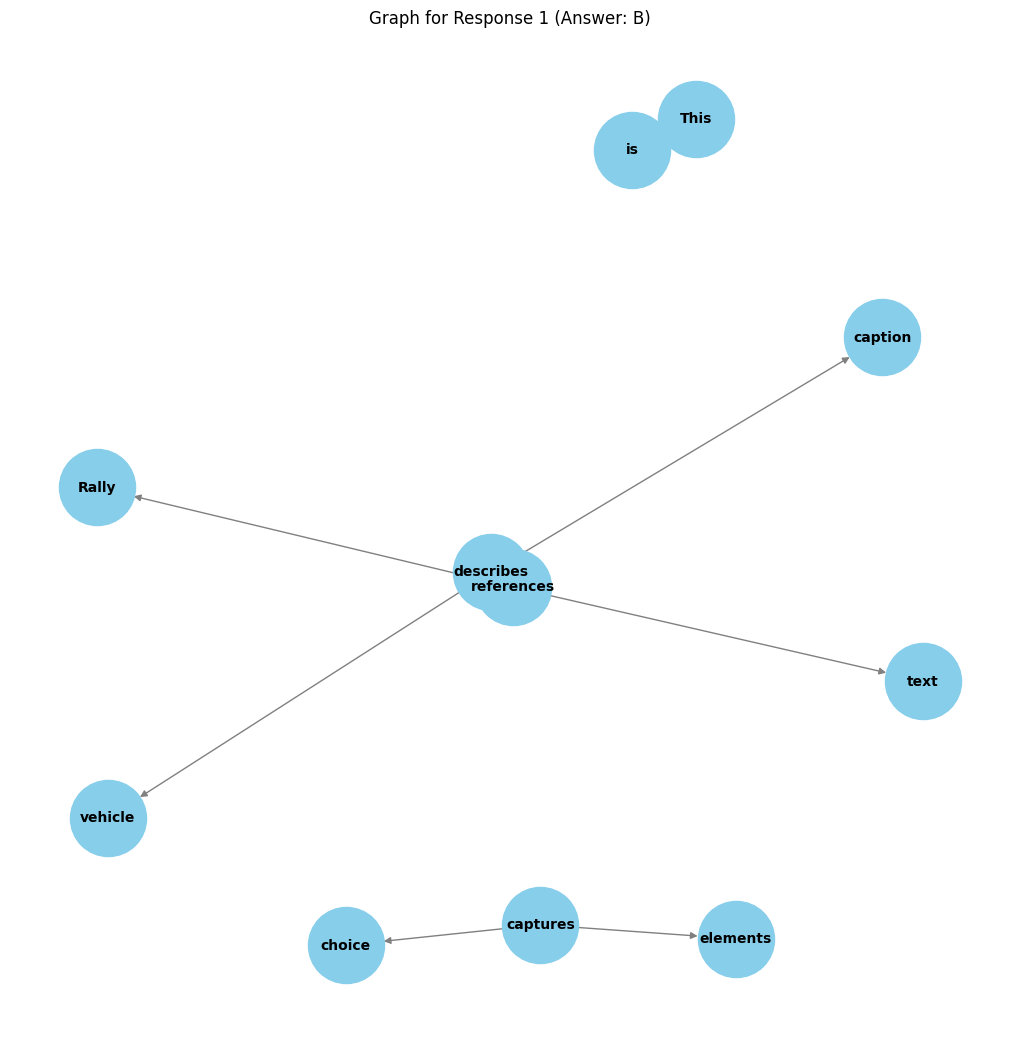

Explanation: The image shows a small, modified car decorated with paint, flames on the hood, and a bathtub on top. It participates in the Mongol Rally, which suggests some level of adventurous spirit. The presence of people and the racing theme indicated by 'Norfolk Race car' is also represented in the caption. Thus, 'A' is the most correct order in terms of constituent presence in the image.


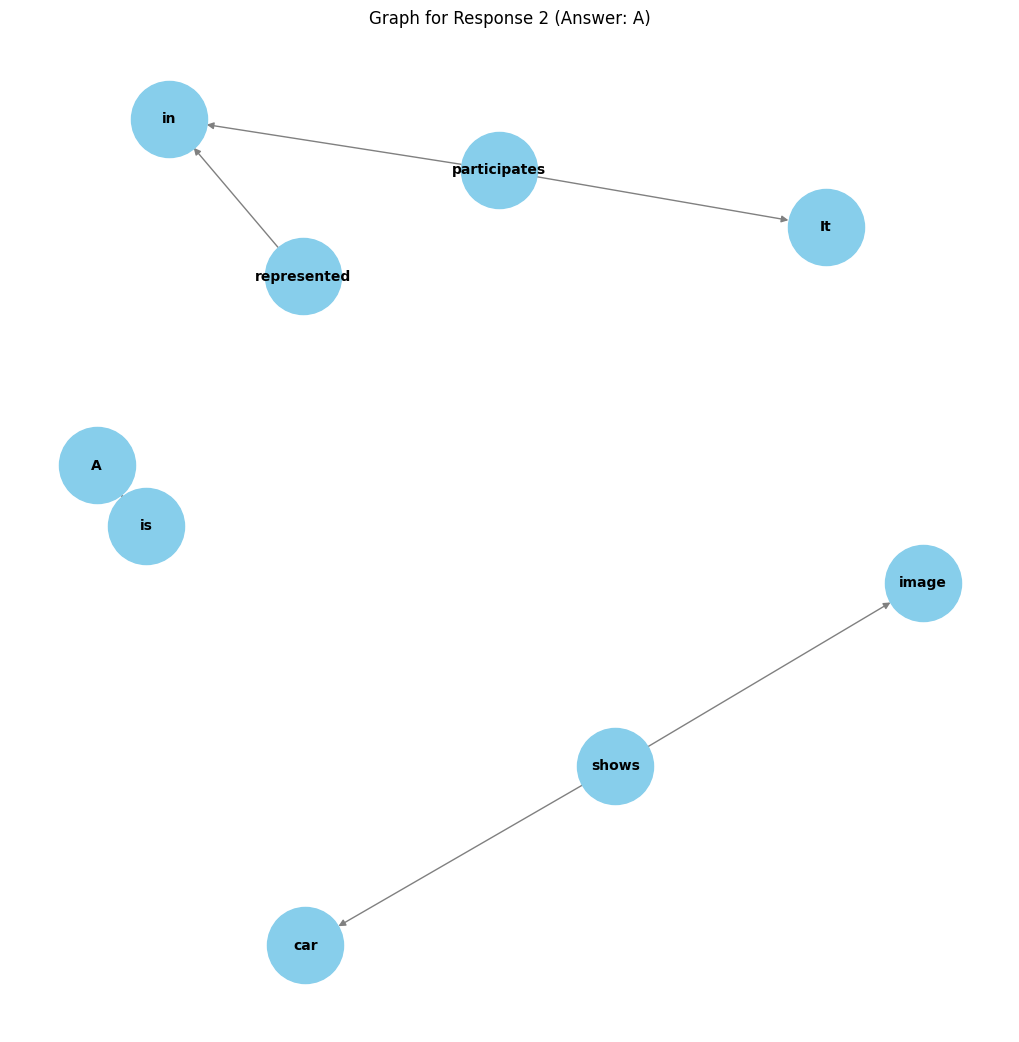

Explanation: The image displays a car that is participating in the Mongol Rally in '09, which refers to an annual charity drive where people drive from one end of the Eurasian landmass to the other. This particular car is also decorated with a bathtub on its outdoor roof, as is common in the rally for decorative purposes, and flags are attached. The presence of the tub and the decorations are distinct features which point to the event the car is participating in, and '09 is likely the year the event took place. Hence, option B is the best answer.


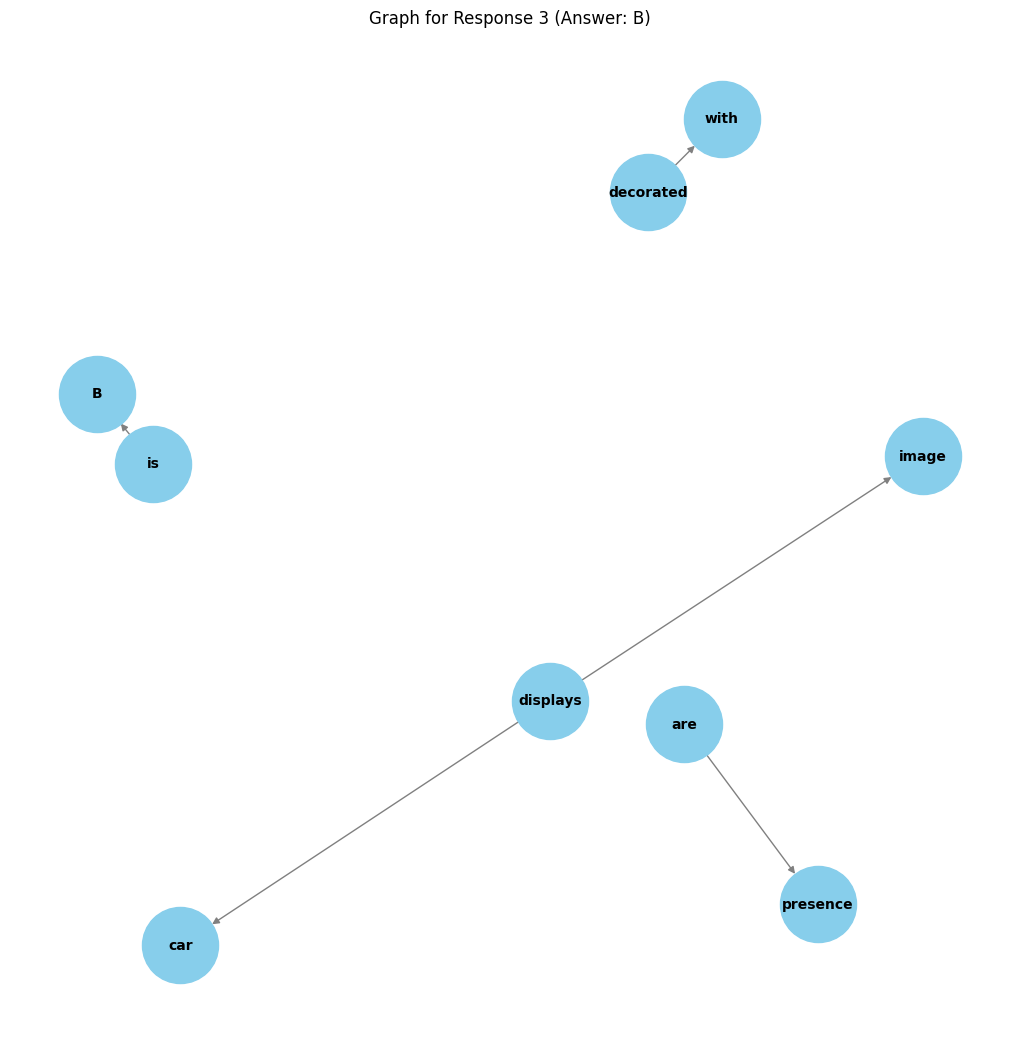

Explanation: The caption correctly orders the constituents as follows: 'A car with a bathtub on top participating in the Mongol Rally in '09.'. The other options have incorrect orders, either describing the visible car with the Mongol Rally context (B and A) or a separate car with flames (D) rather than describing the scene with the bathtub. The car in the specific context of the Mongol Rally is the car with the bathtub on top.


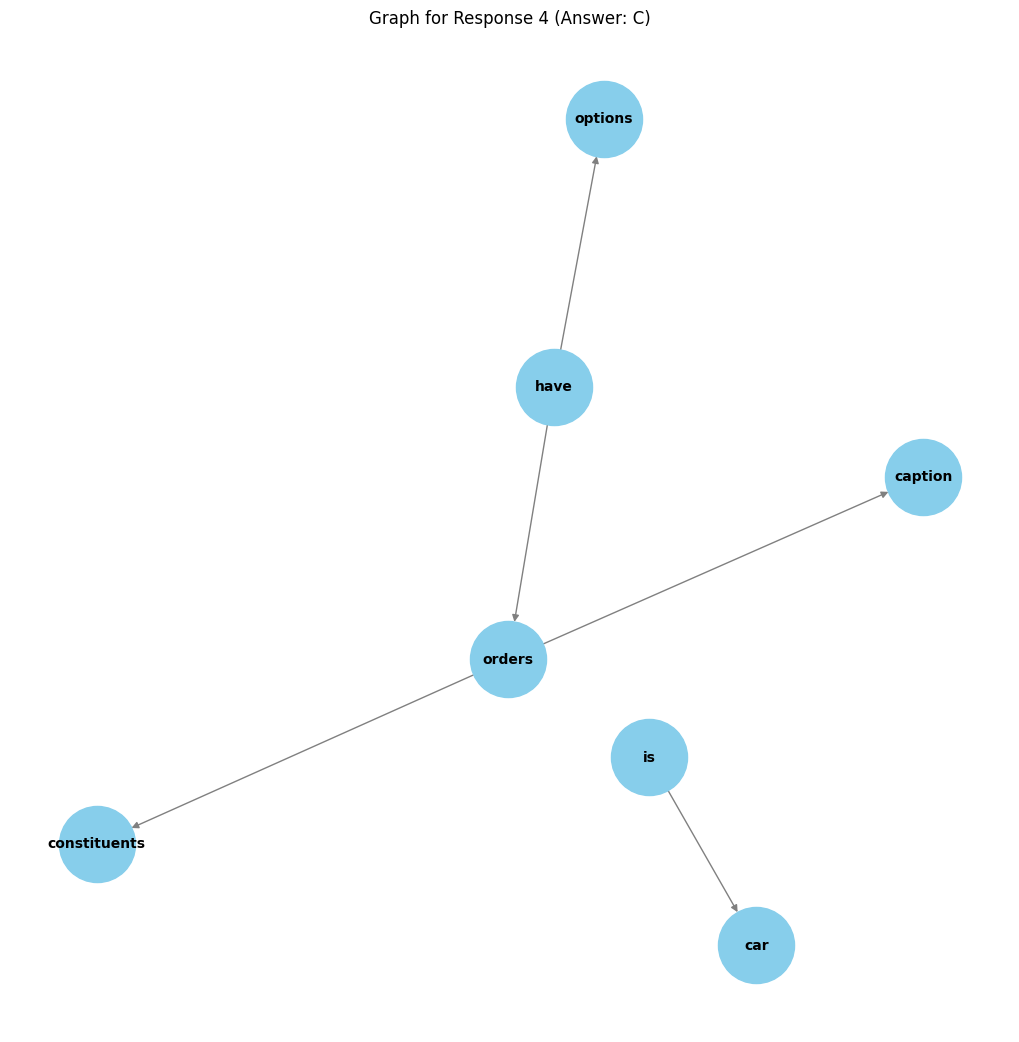

Explanation: The image shows a car with a bathtub on its roof participating in the Mongol Rally in '09. The car has visible paint, particularly the flames on the hood, and appears to be either starting or preparing for the rally. The image's context aligns with option B the most when considering the constituents in their correct ordering: a car, a bathtub on its roof, the Mongol Rally in '09, and any other decorations such as flags.


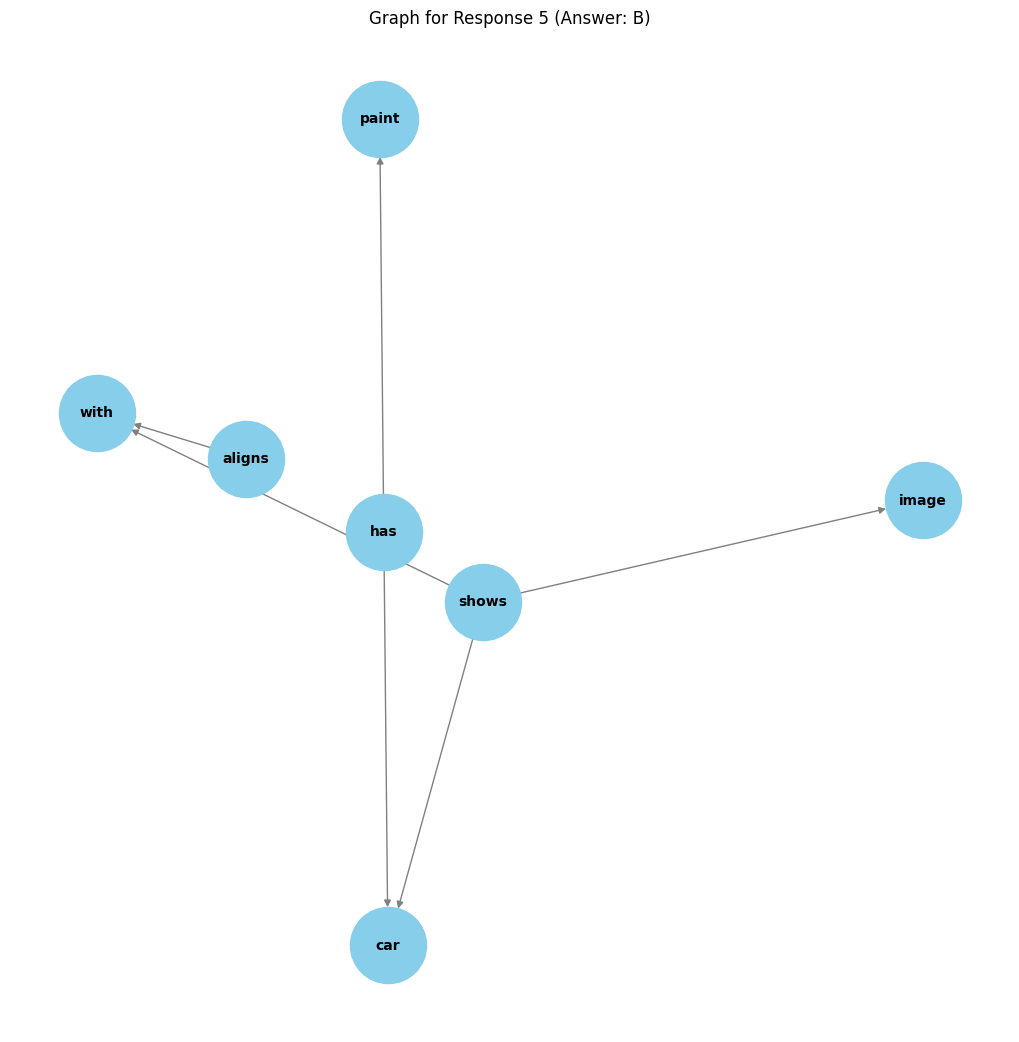

Explanation: The caption that matches the most constituents in the image is 'A car with a bathtub on top participating in the Mongol Rally in '09'. The image shows a rally car with a bathtub on top, which fits the prompt. Flags on the roof and a rally in Mongolia in '09 align well with the events being depicted. The other text descriptions do not appear to correctly match the image's content.


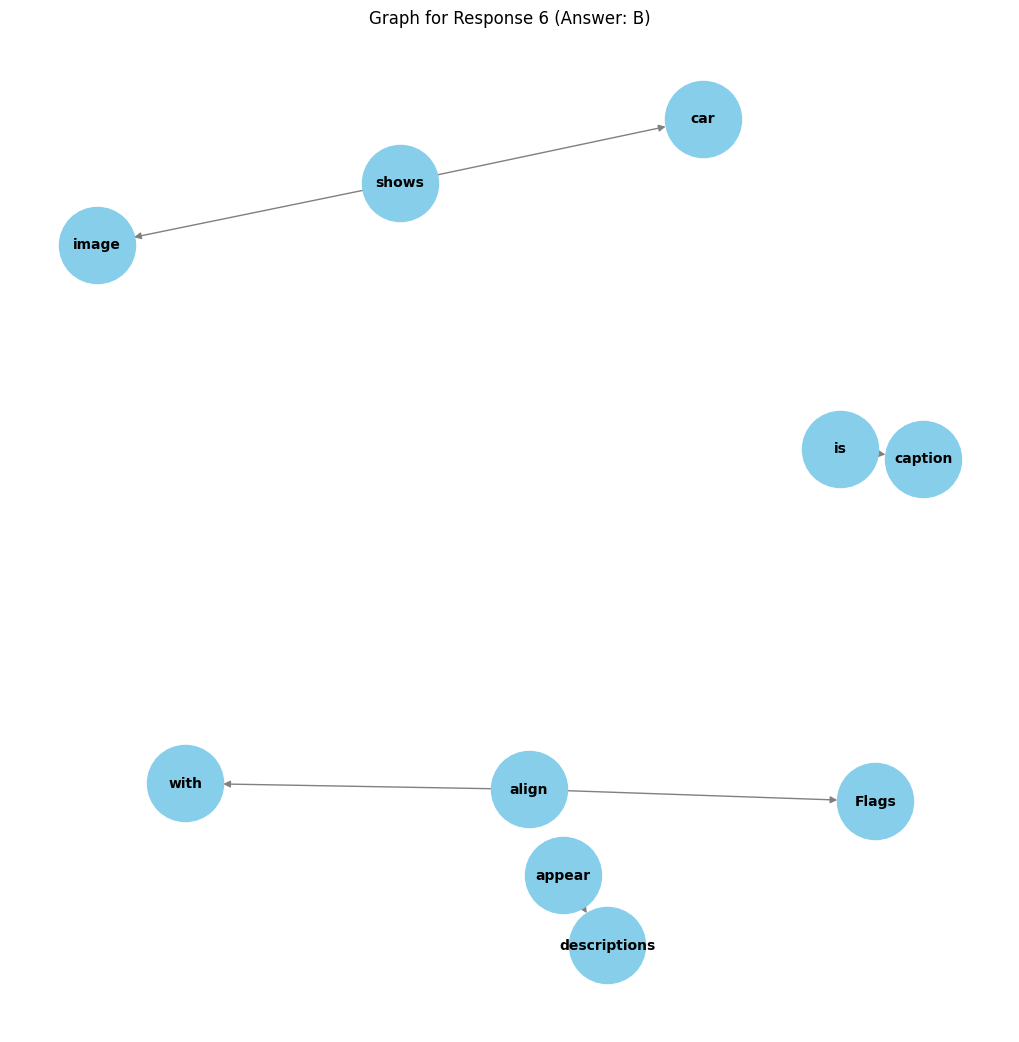

Explanation: The image shows a car decorated for a specific event, in this case the Mongol Rally, with flags on the roof and a bathtub on top. The car is also decorated with flame designs on the hood. This fits most of the criteria in the question, making caption #C the most likely accurate description.


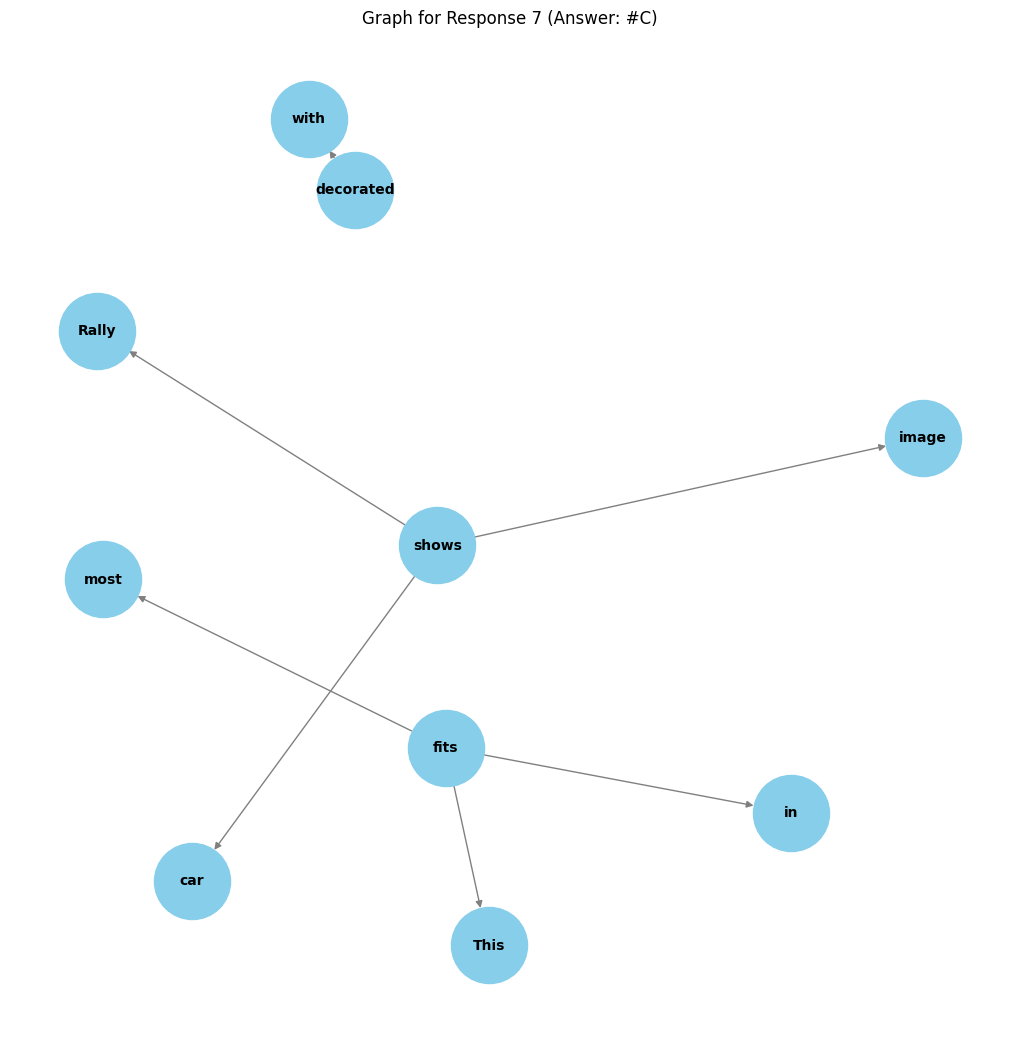

Explanation: The caption 'A car with a bathtub on top participating in the Mongol Rally in '09.' describes the exact arrangement of objects in the image. The car, which is a rally racing vehicle, has a bathtub on the roof. Below the bathtub are a roof rack with attached flags and an inner tub filled with water. There is a group of people in the background who seem intrigued by the car's unique and colorful decorations, as suggested by the presence of both the bathtub and Norfolk Race Car text in the caption. The presence of the crowd indicates that the car is displayed for viewing, which aligns with the activity of a rally event and a competition where decorated cars are showcased. The other captions do not provide an accurate description of the objects in the image.


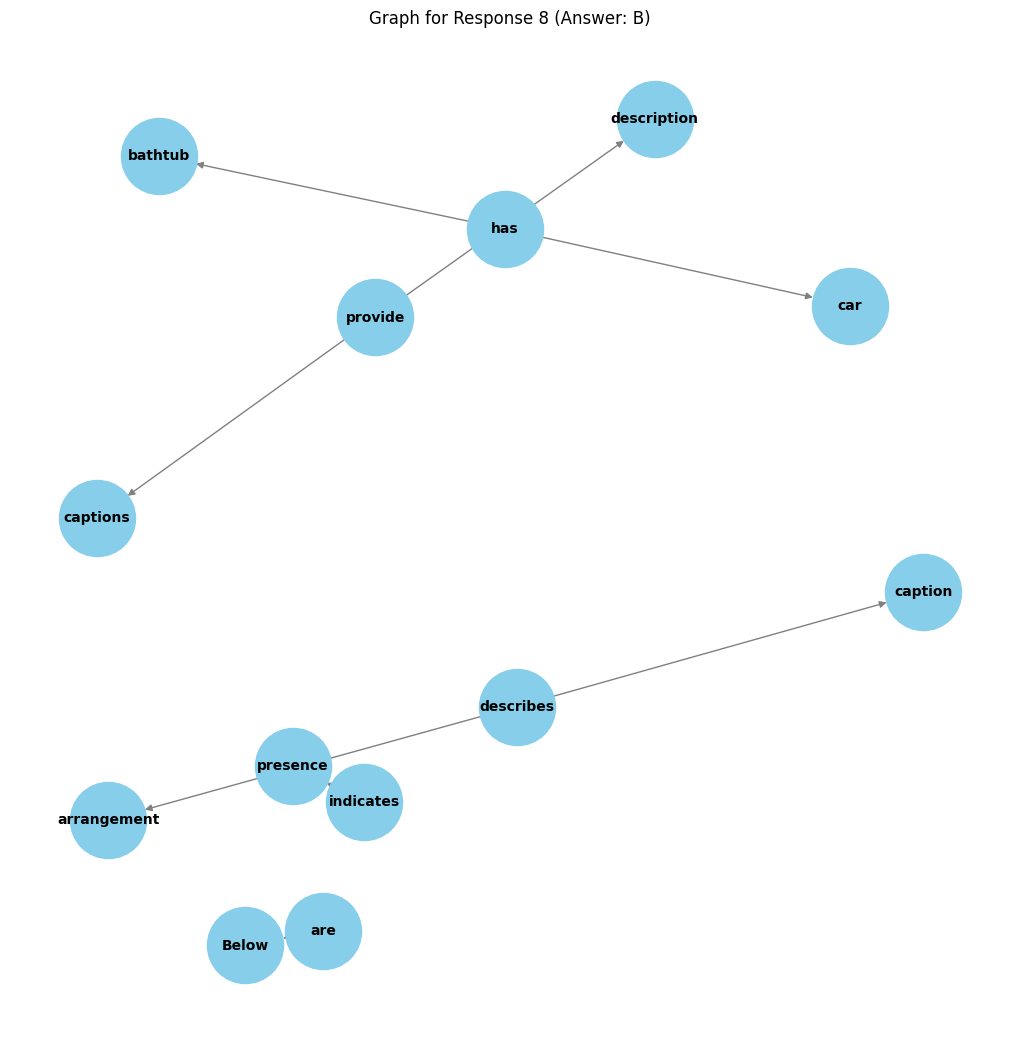

Explanation: With a tub resting on its outer roof, flags attached, the car is ready to take off for the rally. The caption includes the name of the car as 'Norfolk Race car' and mentions the flags and the exterior decor. It accurately conveys the car's appearance and context of participation in an event, which aligns with the other descriptions but has the best structure overall. The other captions do not have the same structure or order the components correctly.


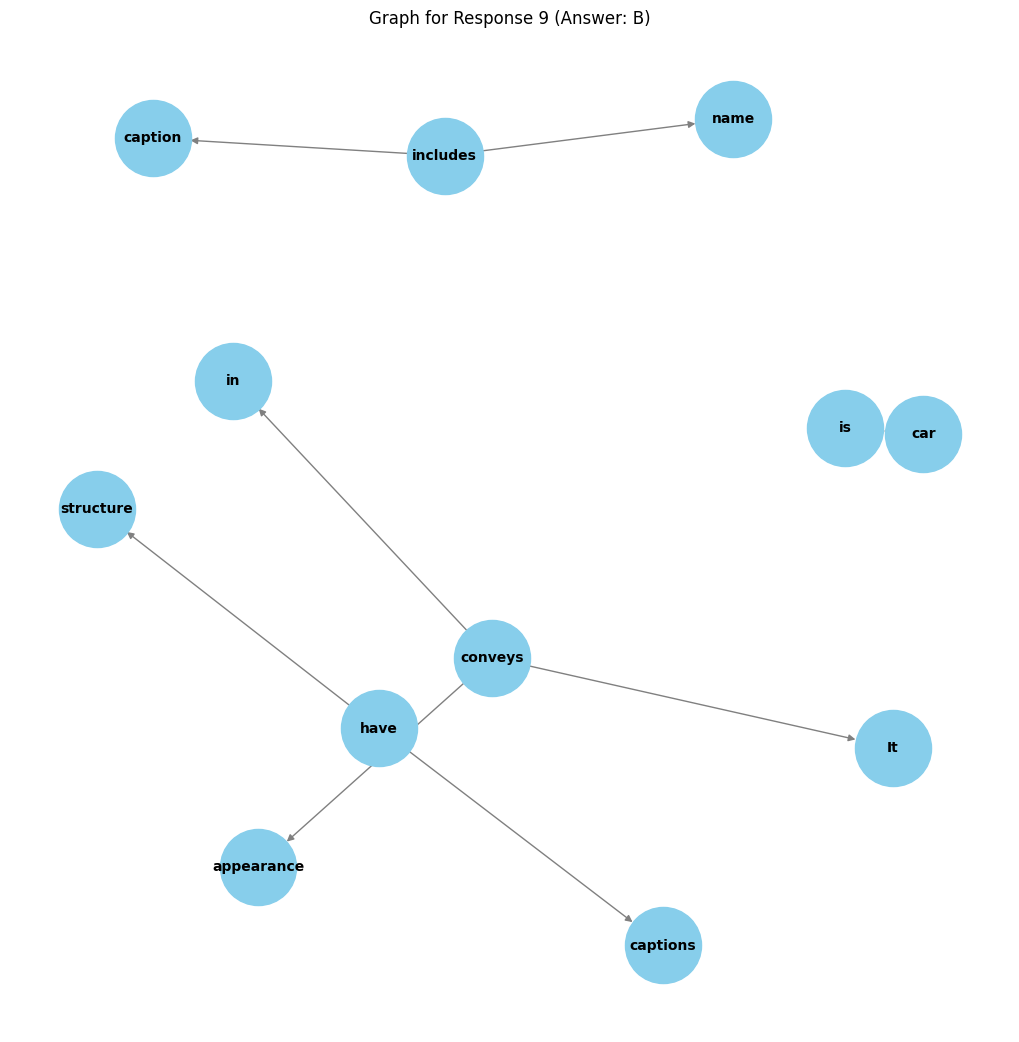

Explanation: The given image shows a car taking part in the Mongol Rally in '09, with the car decorated with flames on the hood, tub resting on top attached to the roof with flags. Option D mentions a Norfolk race car with flames, but the image does not show this. Option A and C both use incorrect names for the car and event. The correct terminology is 'Mongol Rally' and the event should be referred to that specifically without the term 'Norfolk' present. Option B captures the essence of the image's content.


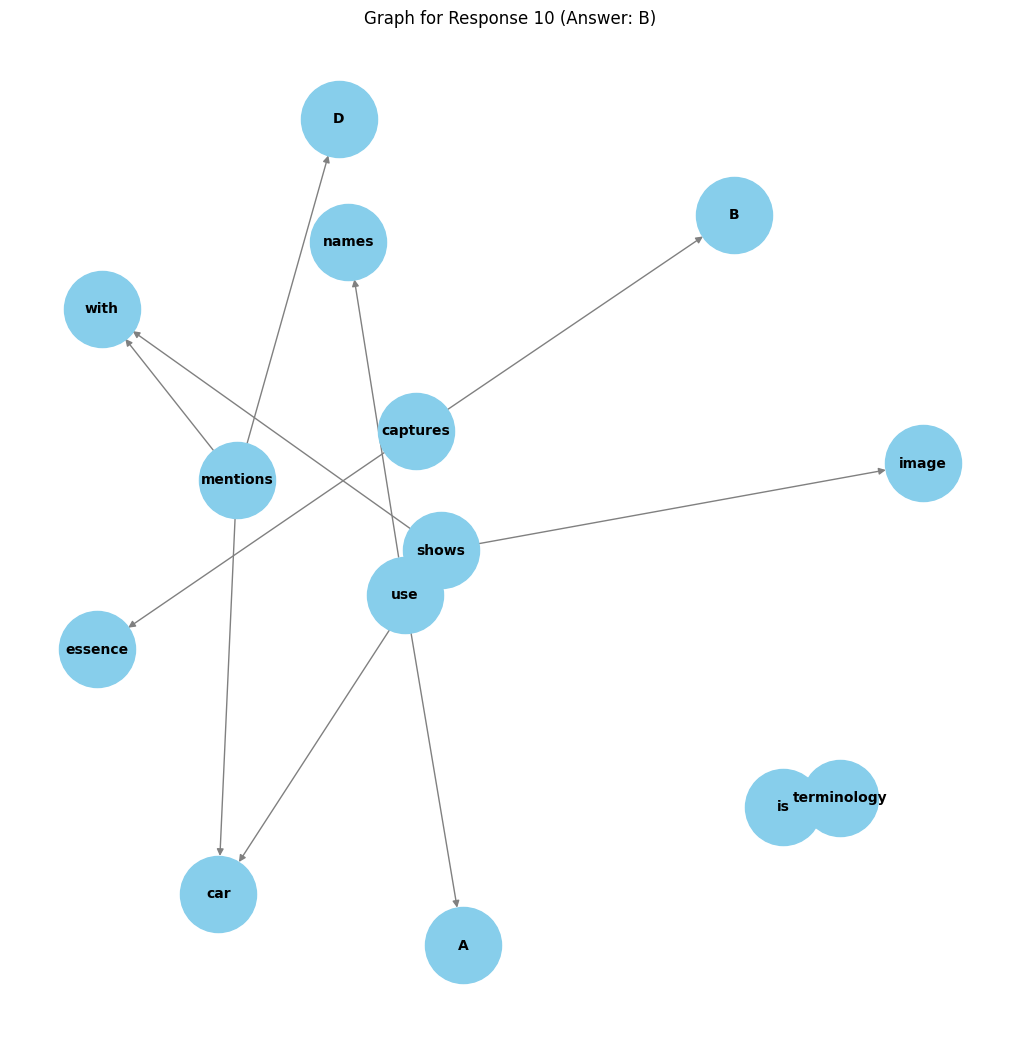

Explanation: The image depicts a car participating in the Mongol Rally in '09 with a bathtub on top and flags attached, which aligns with option B. The other options do not accurately describe the scene in the image.


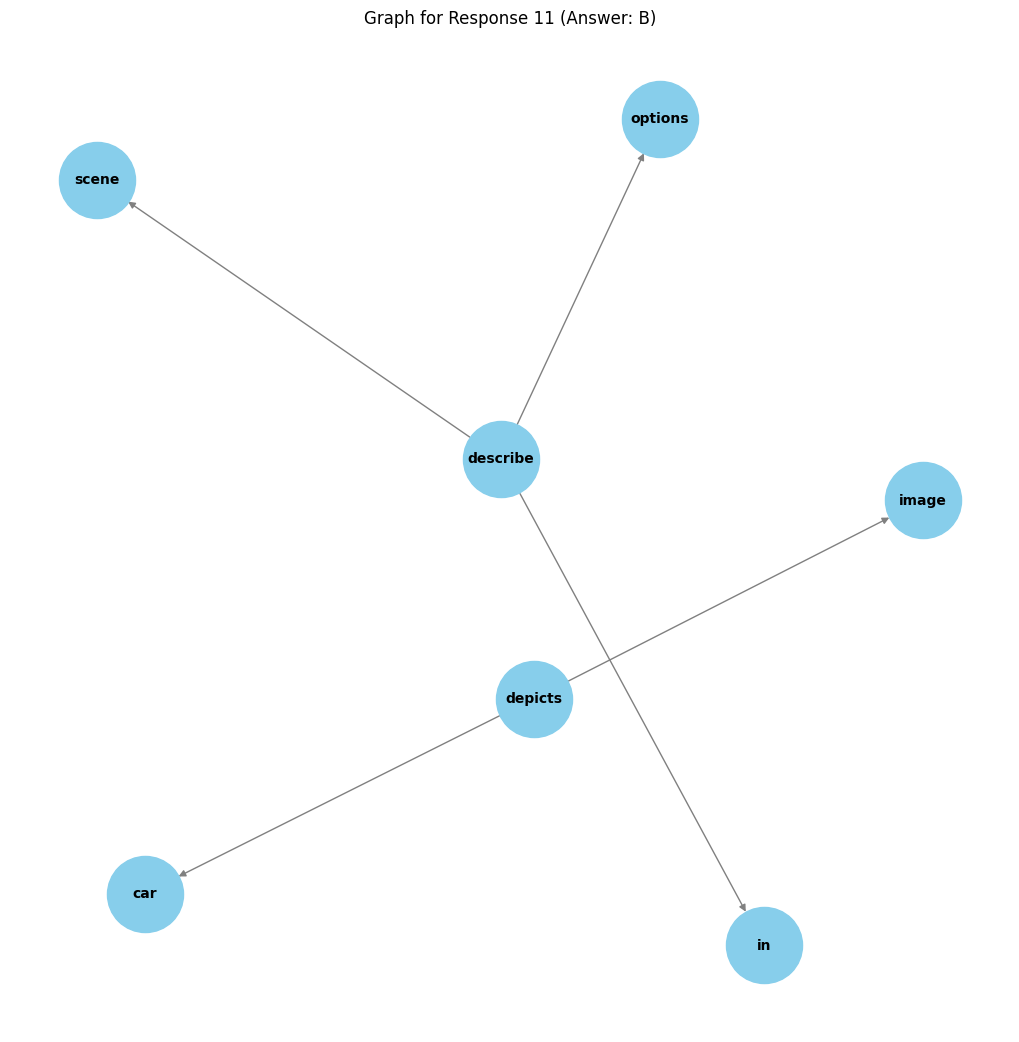

Explanation: In this image, there is a car that has a tub with flags on its roof. Additionally, on the side of the car, the word 'Rally' is visible, which is consistent with the Mongol Rally context. Furthermore, the word 'Norfolk' is visible, suggesting it's a Norfolk car participating in the rally. There are no flames or bathtubs in the image, nor is there a car named 'Orford' which does not match the description given in the options. Option C aligns with the key elements of the image.


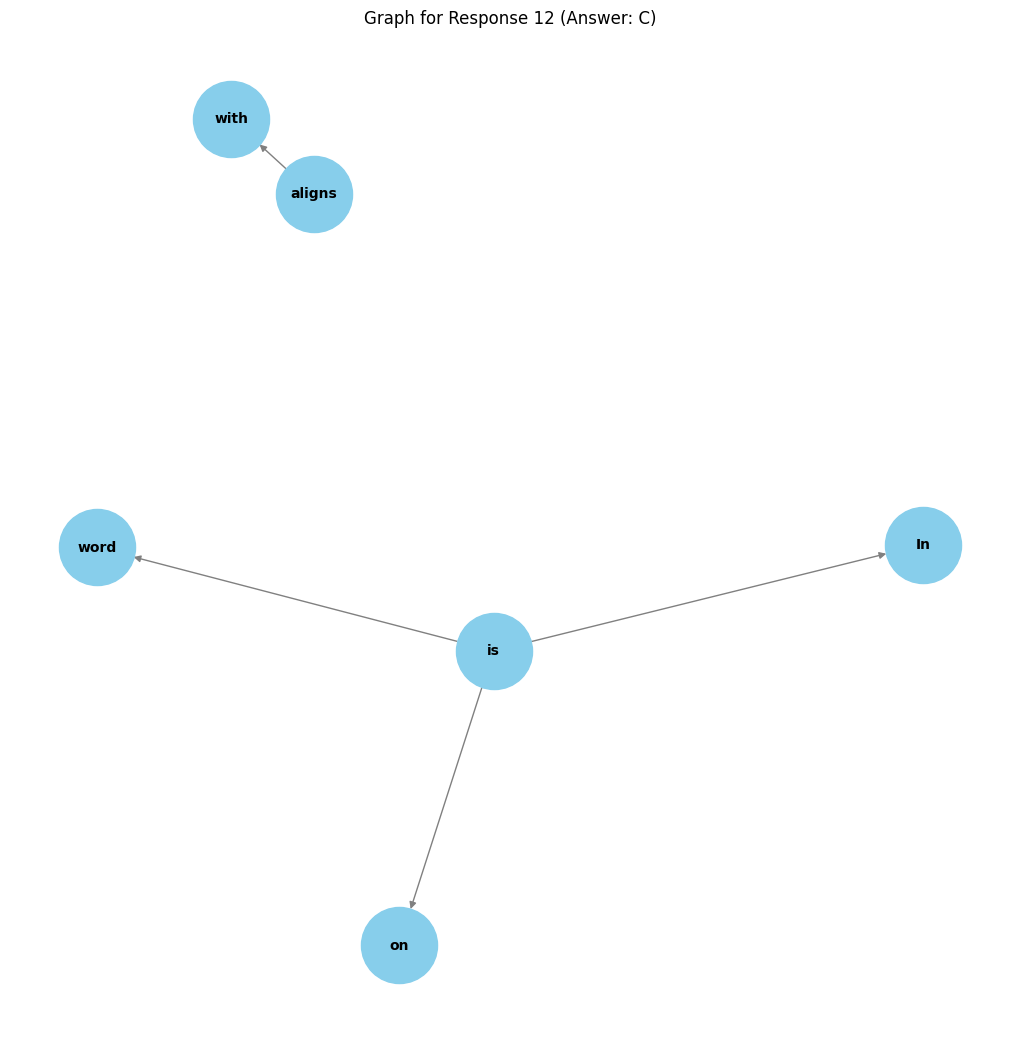

Explanation: The car in the image appears to be a custom-decorated car with a distinctive 'Mongol Rally 2009' decal. This suggests that it could be from the Mongol Rally event in 2009, implying a timeframe rather than a specific car model. The presence of the tub on the roof with flags attached indicates it's a participant car, possibly even a car from the event 'Norfolk Race Car' may also be associated with similar rally events that involve outrageous or custom cars. Option D is more of a general description rather than specifically applicable to this car, and the other options do not seem to fit the car's appearance. Option B seems like a plausible description except for the specific year '09, which is more reliable from the provided choices.


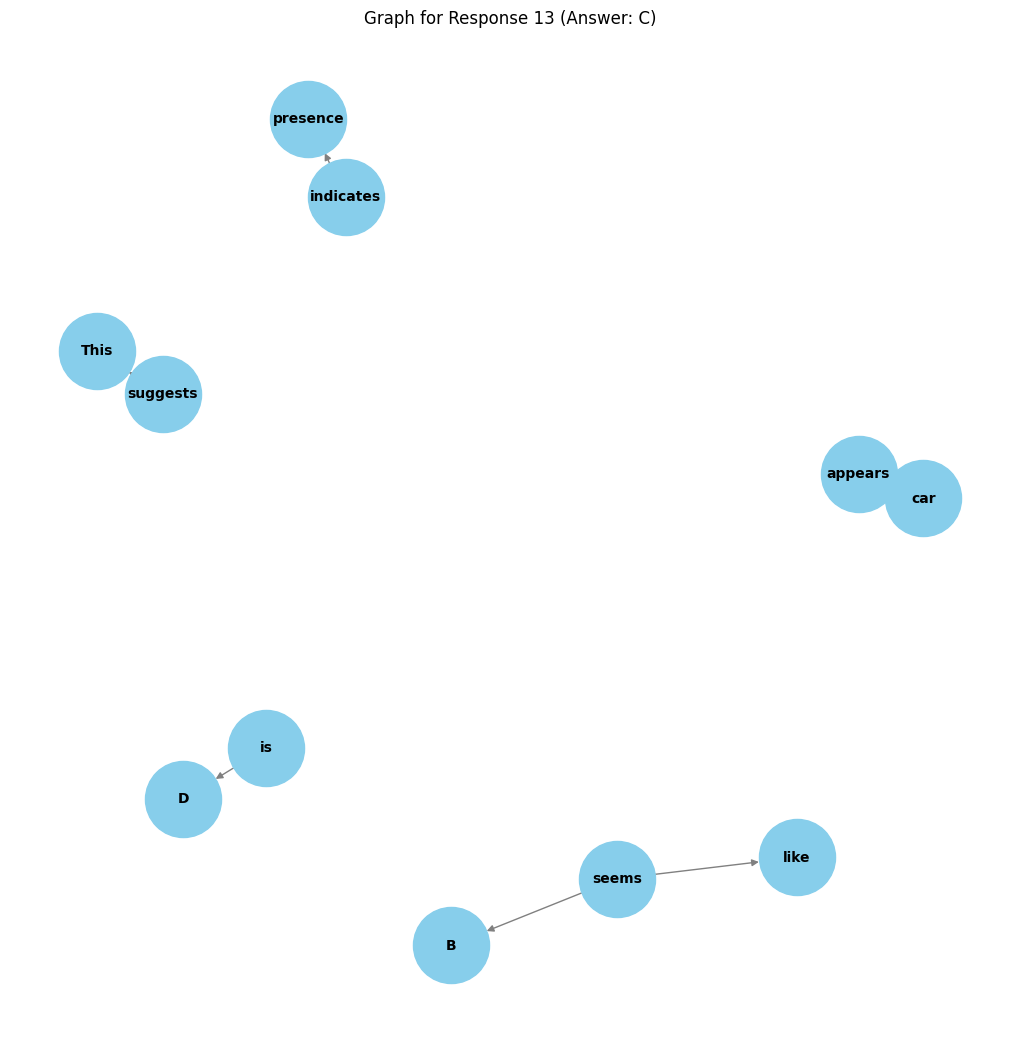

Explanation: This caption is the most accurate ordering of the constituents because it correctly identifies that the car has a tub resting on its outer roof, and there are flags attached.


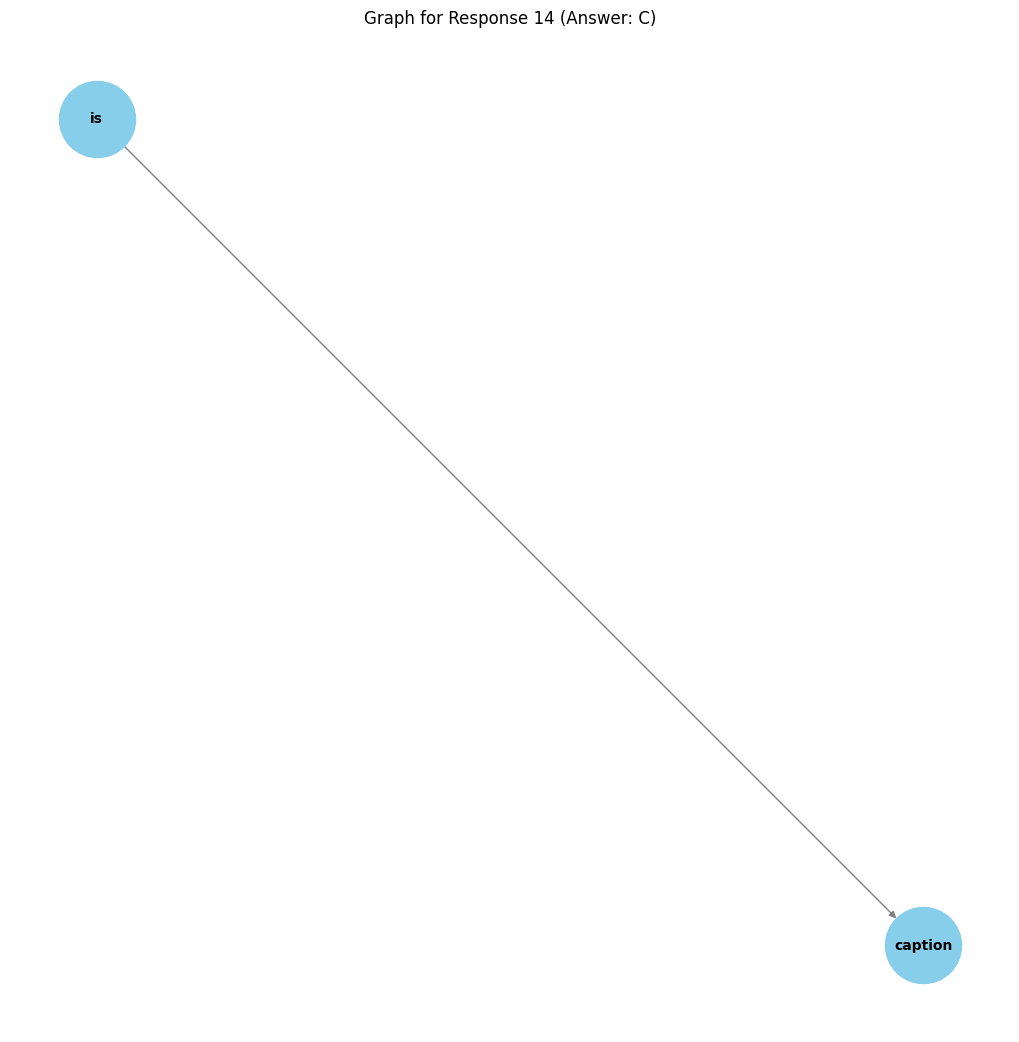

Explanation: This caption accurately conveys the major elements of the image: a car, a tub on its roof, flags, an indication of participation in the Mongol Rally, and a Norfolk racer with flames on the hood. It is the most comprehensive description of the image.


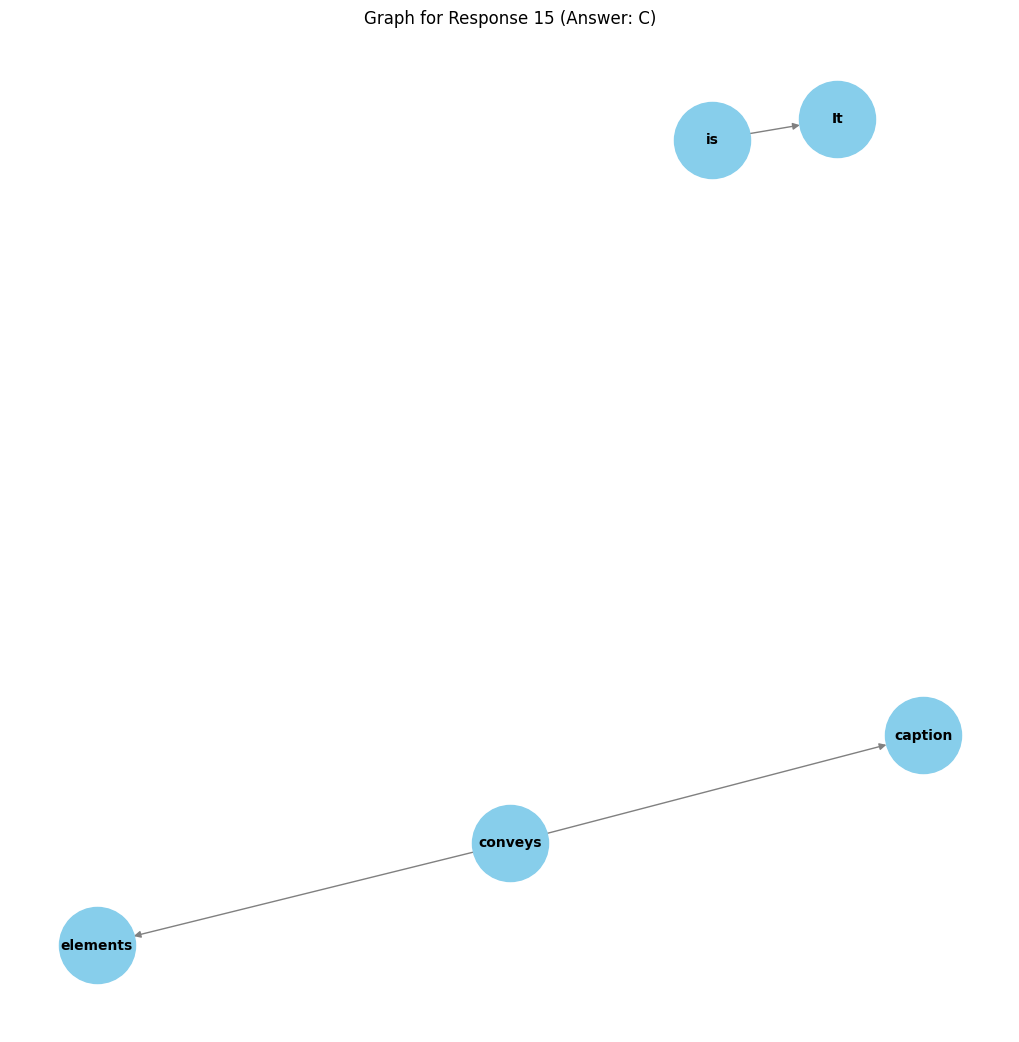

Visualizing for index: 2790
Explanation: The correct order of the constituents is man, standing next to machine(s), and beer sign or wall. The image depicts a man standing near gambling machines, with a beer sign hanging on the wall above one of the machines. The gambling machines are clearly the objects of interest. Therefore, the correct order is 'A', and the remaining options do not accurately describe the elements present in the image.


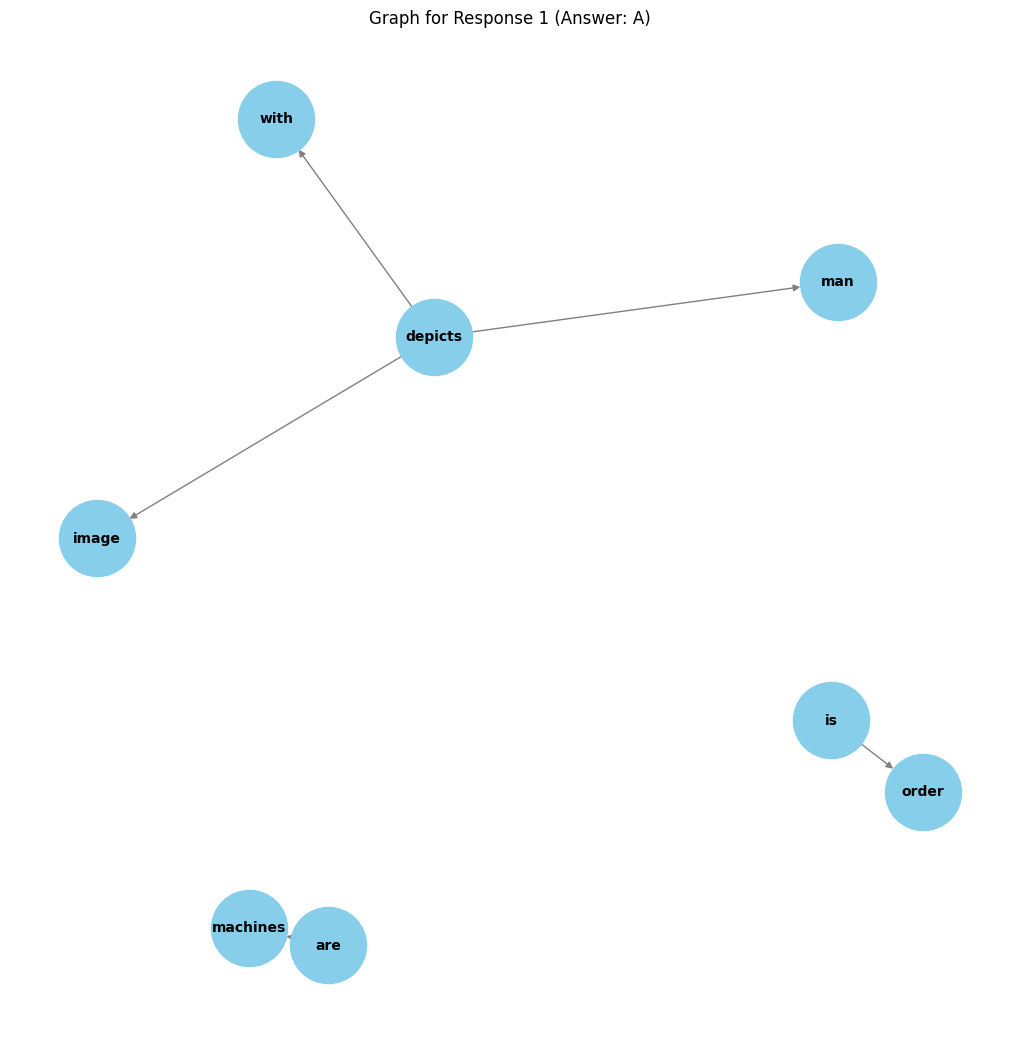

Explanation: The image depicts a man standing in a bar, and there are indeed three video game machines visible, in addition to a neon beer sign on the wall. These descriptions match the contents of the image as provided.


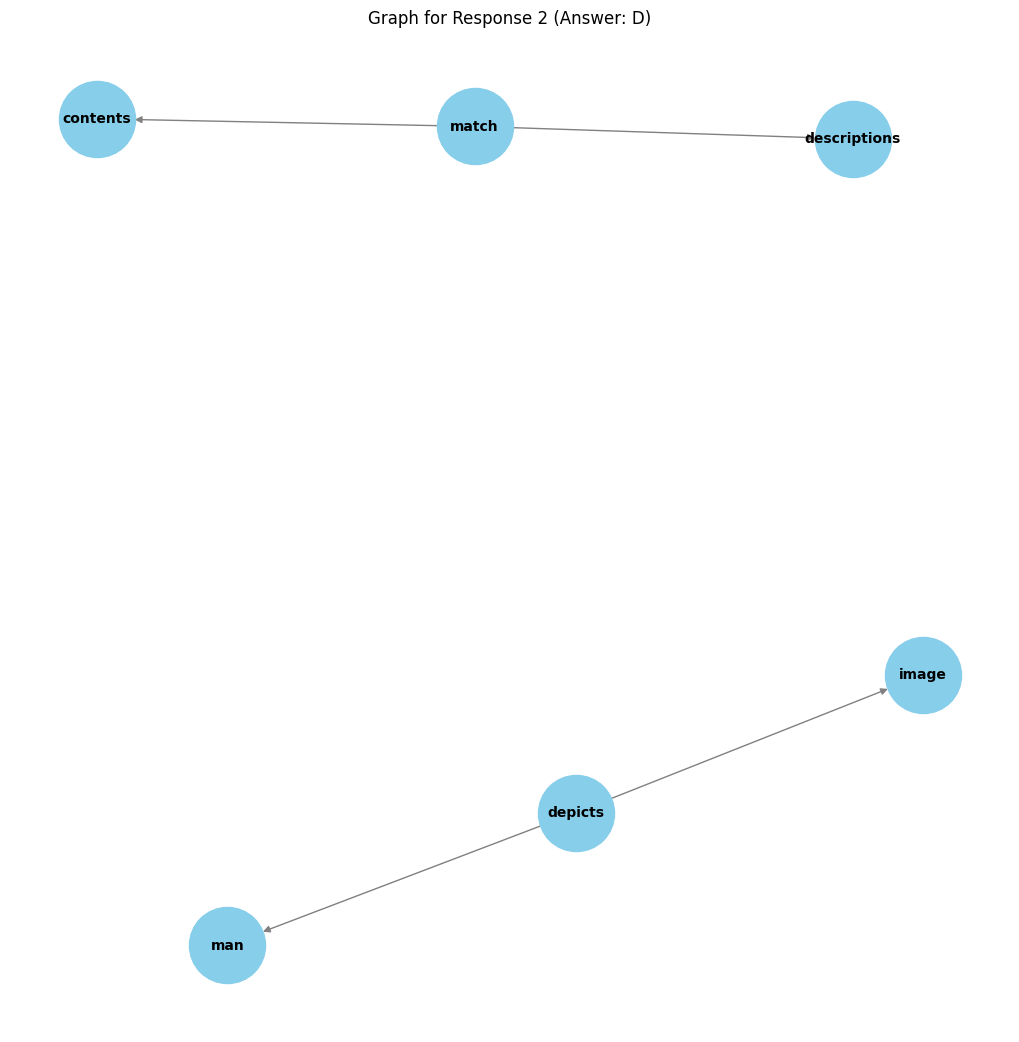

Explanation: The most correct ordering consists of the bar setting with neon beer sign and video games. The image displays a man standing by some video games in a bar-like setting, with a neon beer sign on the wall, which fits the caption 'A man standing in a bar with a neon beer sign hanging on the wall'. The term 'computer gambling machines' implies a higher level of technology than the type of games shown in the image, which are arcade-style video games. Additionally, caption 'A man is standing by a group of video games in a bar' does not match the image, as there is no indication of a group of video games. Neither does caption 'A man stands next to a bank of computer gambling machines' since the games shown in the image are arcade-style video games.


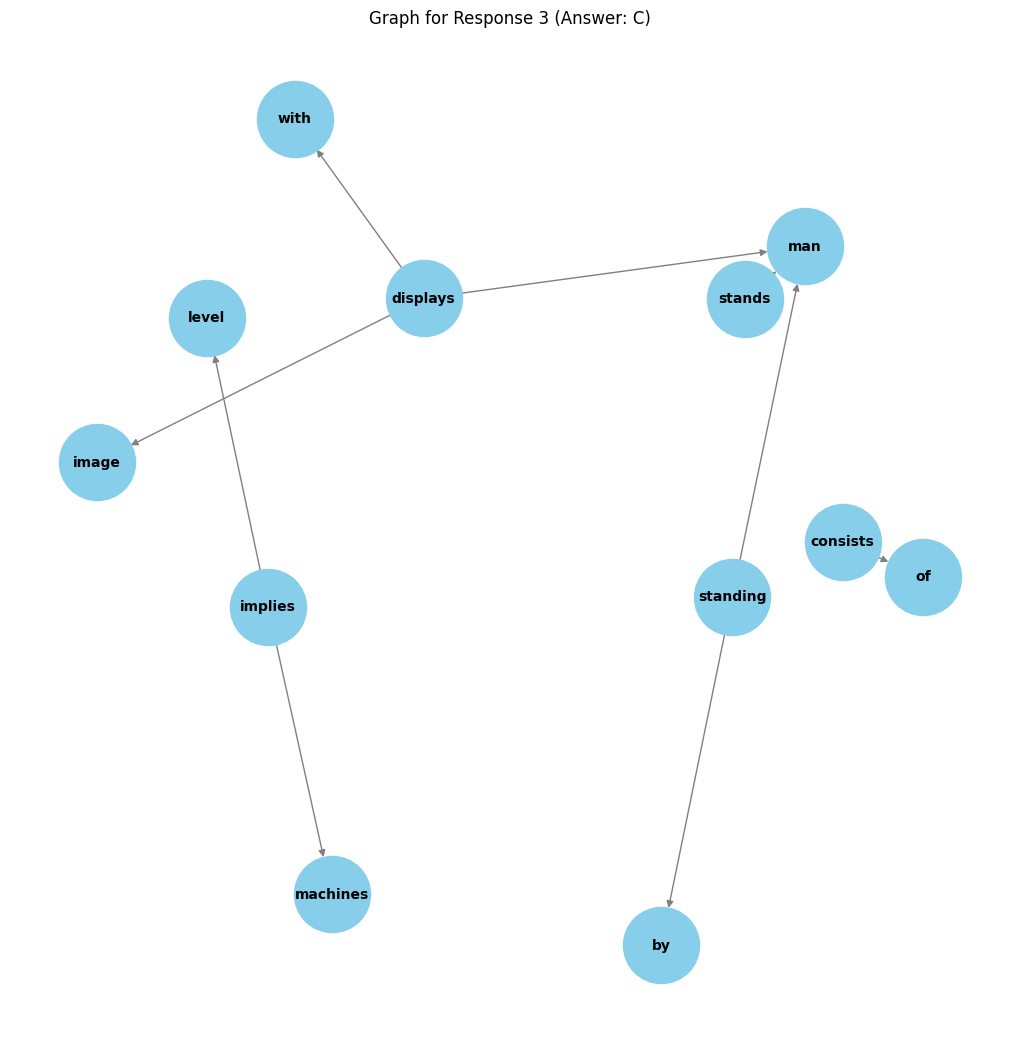

Explanation: The man is standing next to a bank of computer gambling machines, which indicate that the location is most likely a bar. The neon beer sign is also consistent with a bar vibe. Additionally, the presence of several video gaming machines suggests that the place might be focused on both casual gaming and social interactions, which are common findings in bars with games.


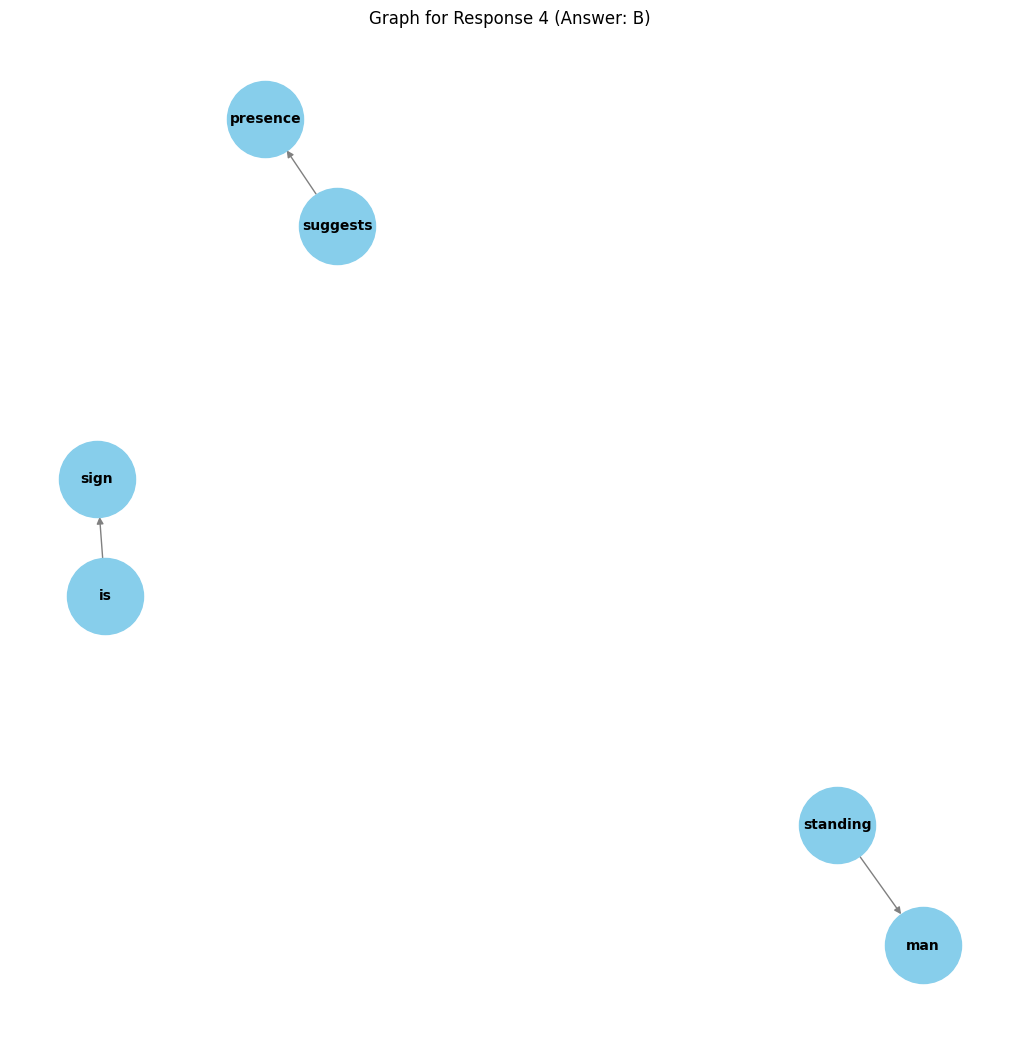

Explanation: Based on the given image, a man is standing next to a group of video games in a bar. The image depicts a gaming area with several gaming machines. There is no neon beer sign or bank of computer gambling machines as described in other options. Thus, the most correct ordering of the constituents should be 'A' as a man is standing by a group of video games in a bar. 'B' and 'D' are inaccurate interpretations of the image. The only mention of computer gaming is in 'C', but it is misleading because the image depicts video games, not computers with video games.


KeyError: 'answer'

In [9]:
import json
import networkx as nx
import matplotlib.pyplot as plt

def adj_list_to_graph(adj_list):
    """Convert an adjacency list to a NetworkX graph."""
    G = nx.DiGraph()
    for node, neighbors in adj_list.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
    return G

def plot_graph(G, title):
    """Plot a NetworkX graph."""
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, seed=42)  # positions for all nodes
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight="bold", edge_color="gray")
    plt.title(title)
    plt.show()

# Iterate over the responses and plot the graphs
for idx, result in bin_1_results.items():
    print(f"Visualizing for index: {idx}")
    for i, response in enumerate(result['responses']):
        try:
            adj_list = response.get('graph', {})
            G = adj_list_to_graph(adj_list)
            print('Explanation:', response.get('explanation', ''))
            title = f"Graph for Response {i + 1} (Answer: {response['answer']})"
            plot_graph(G, title)
        except Exception as e:
            print(f"Error: {e}")
            print(f"Response: {response}")            

Visualizing for index: 2819
Explanation: The man is wearing a pair of shorts in the image. The shorts are beige and have a grey pattern.


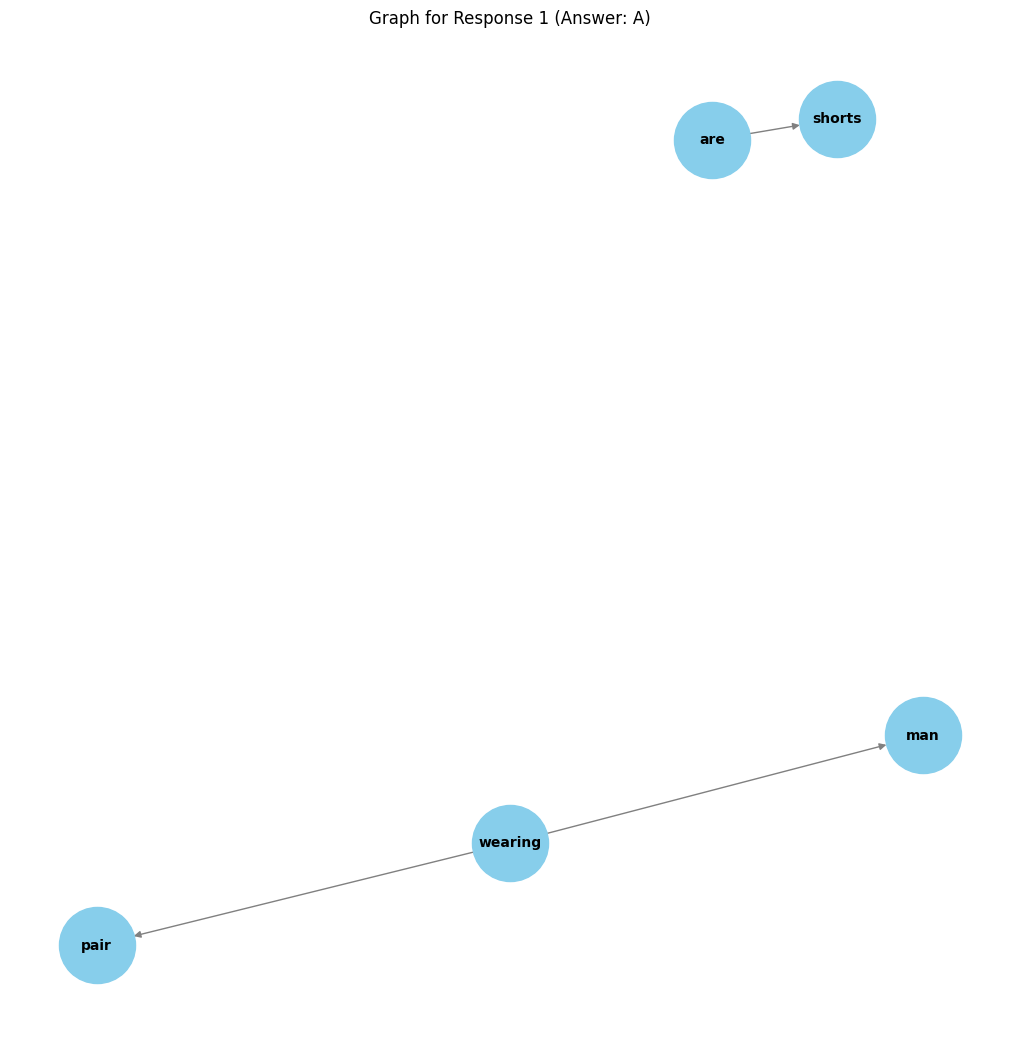

Error: 'NoneType' object has no attribute 'items'
Response: {'answer': {'A': 'shorts', 'B': 'long sleeve shirt', 'D': 'dress', 'E': 'flip flops'}, 'explanation': {'A': 'The man is wearing cargo shorts with patterned fabric. Shorts are an article of clothing specifically designed to cover the lower part of the body from waist to hem.'}, 'confidence': 1, 'graph': None}
Explanation: The image features a person modeling the shorts, which suggests they are a piece of clothing. The shorts seem to be casual and made for comfortable wear. Based on the context of the person wearing them, paired with the visible sandals, it is identified as the type of object that we can call 'A', which stands for 'A. Khaki Khaki Khaki Shorts Khaos Dress Dress Shoes Sandals'. However, without context to distinguish between 'Clothing' and 'Dress', the confidence is rated a 0 (for clarity), which could possibly be interpreted as the 'C' option depending on additional context or additional image content not visible

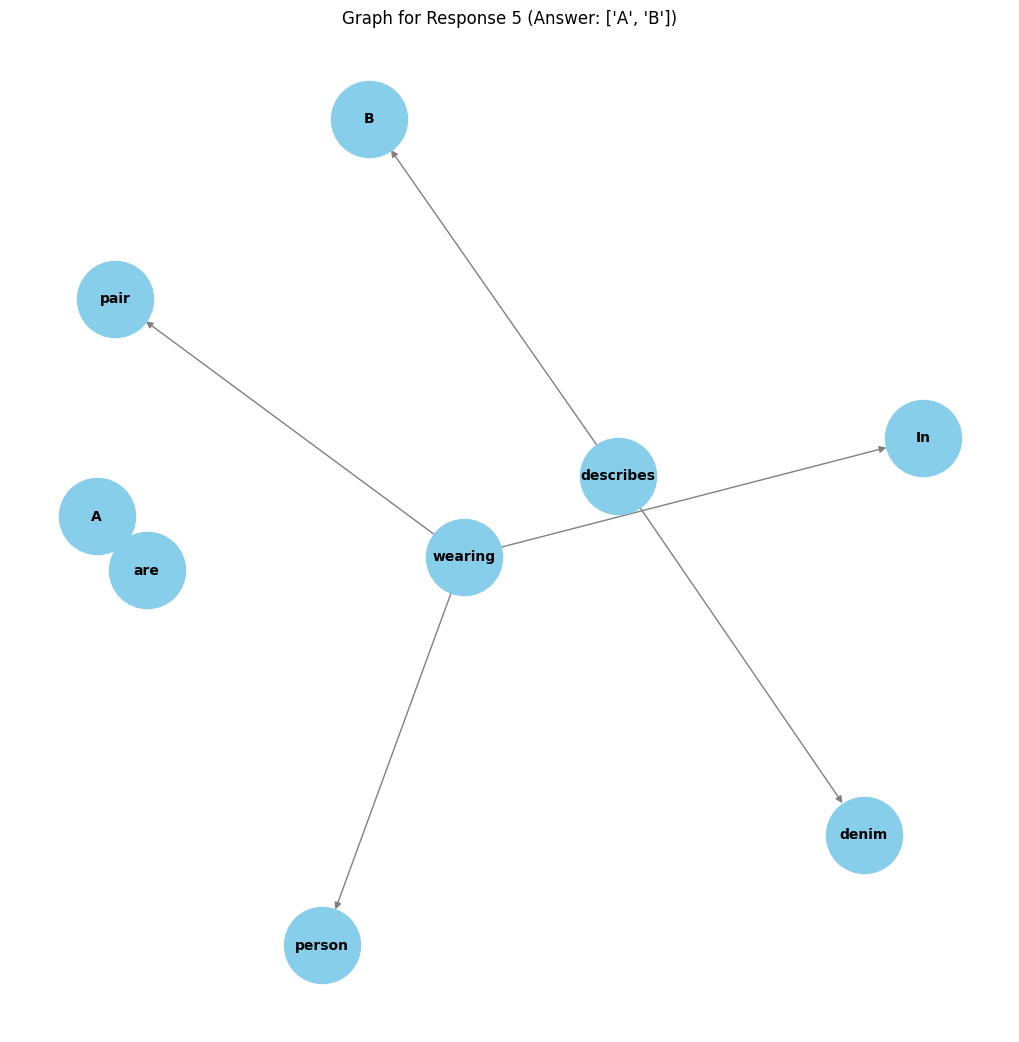

Explanation: The attire in the image is shorts, which are a type of apparel. They are paired with sandals, indicating a casual or relaxed wear style. There are no indications of a denim shirt or a dress in this image.


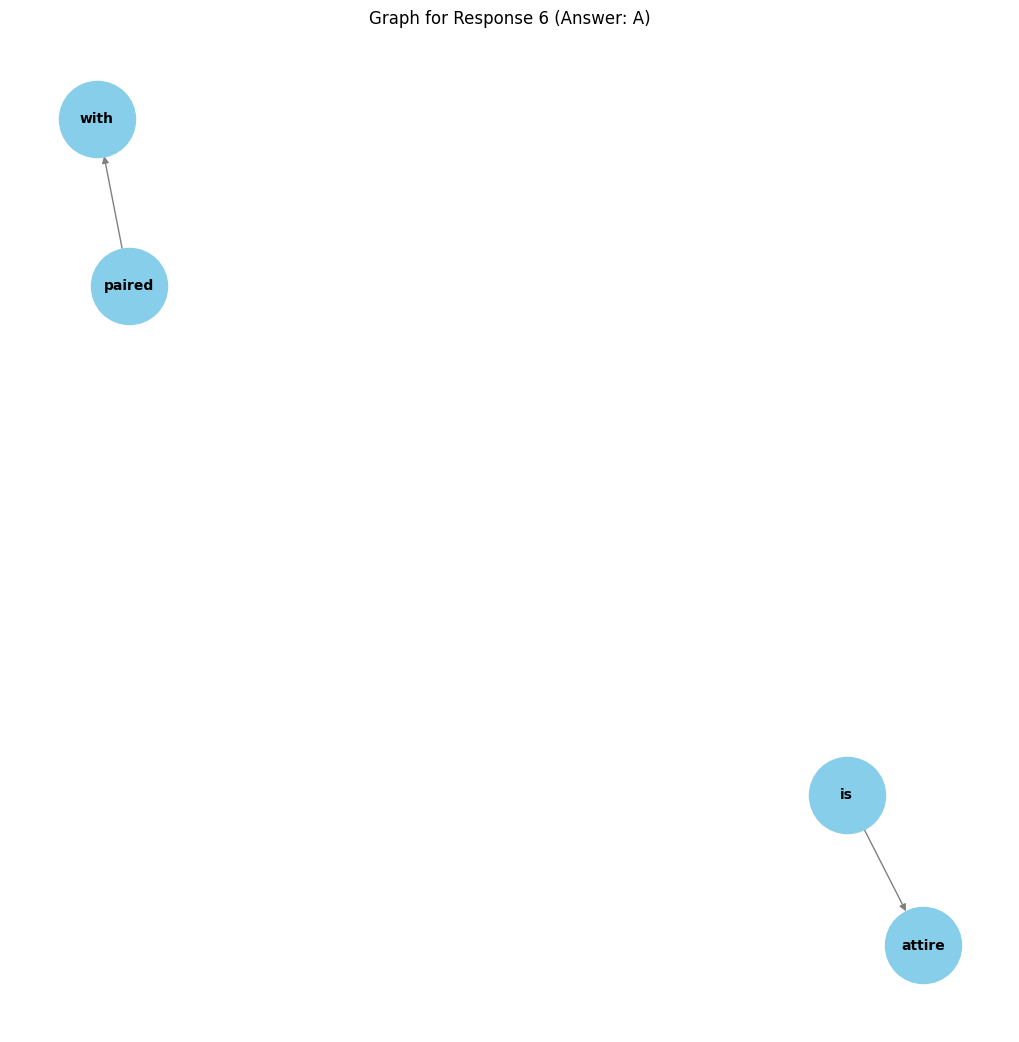

Explanation: The image shows a person looking at the camera while wearing men's shorts. The shorts appear to be casual men's shorts, not denim or a dress, as evidenced by the cargo pocket and cut. Therefore, the correct answer to the generated attribute question is 'A' (Shorts).


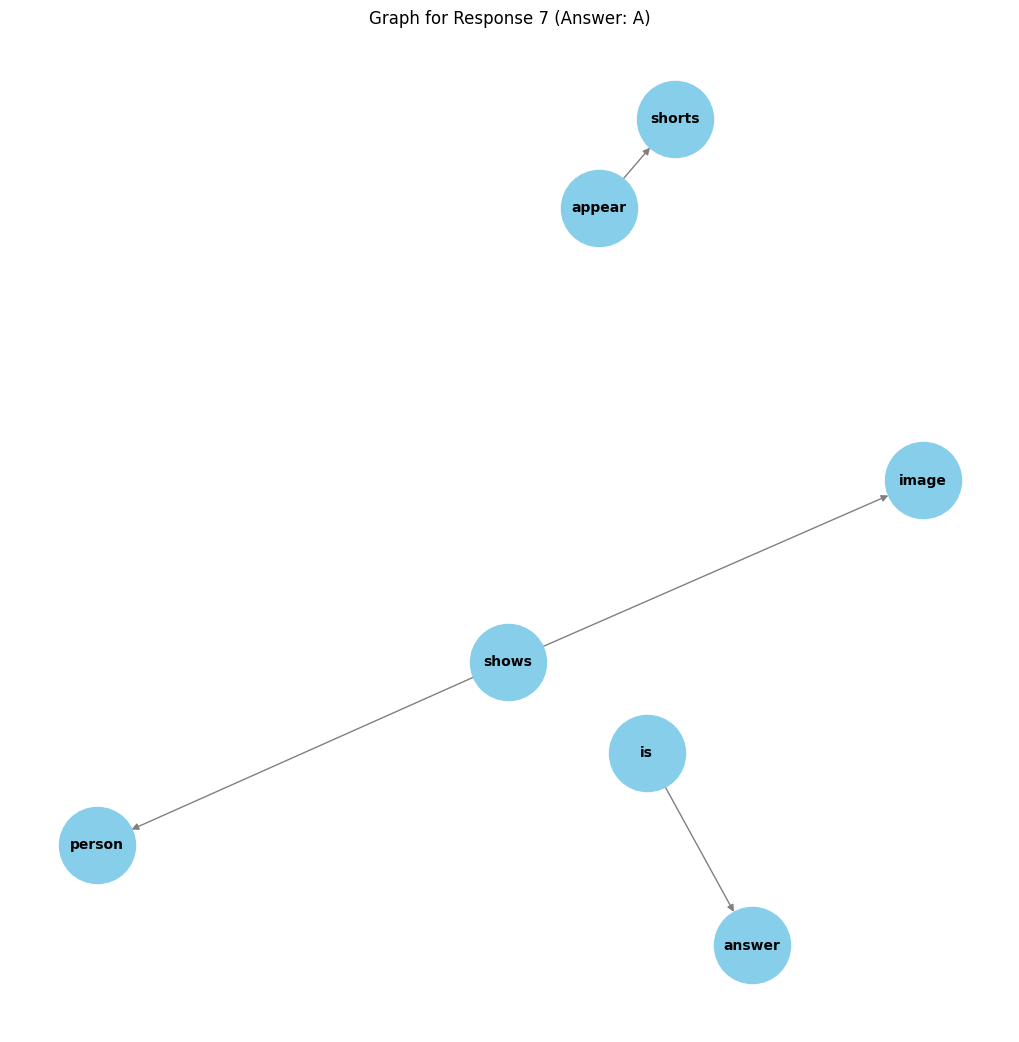

Explanation: The object in the image is a pair of shorts. The man is wearing a light brown or grey-patterned pair, possibly with some sort of stain or decoration visible at the distressed denim patches. The shorts appear to be casual in style, suitable for a warm climate or leisure wear.


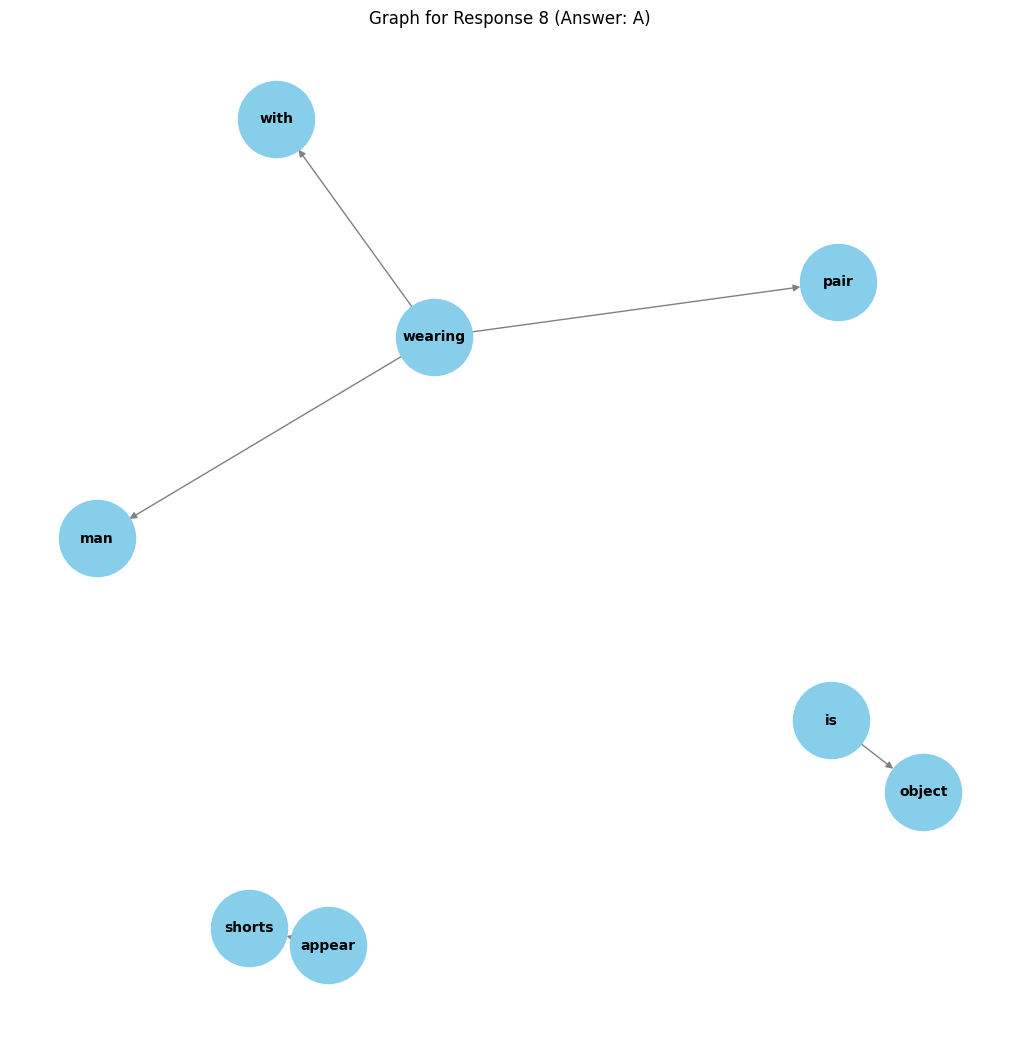

Explanation: The image features a pair of tan shorts worn by a person. The shorts have a pattern on them, and the person is also wearing flip-flops. The image is focused on the lower half of the person's body, but it is clear that they are wearing shorts. Option 'B' and 'D' are not relevant for the image provided as it does not show a person wearing jeans or a dress. Option 'C' is not mentioned in the attributes list provided. The confidence is 1 as the answer is directly related to the objects in the natural image.


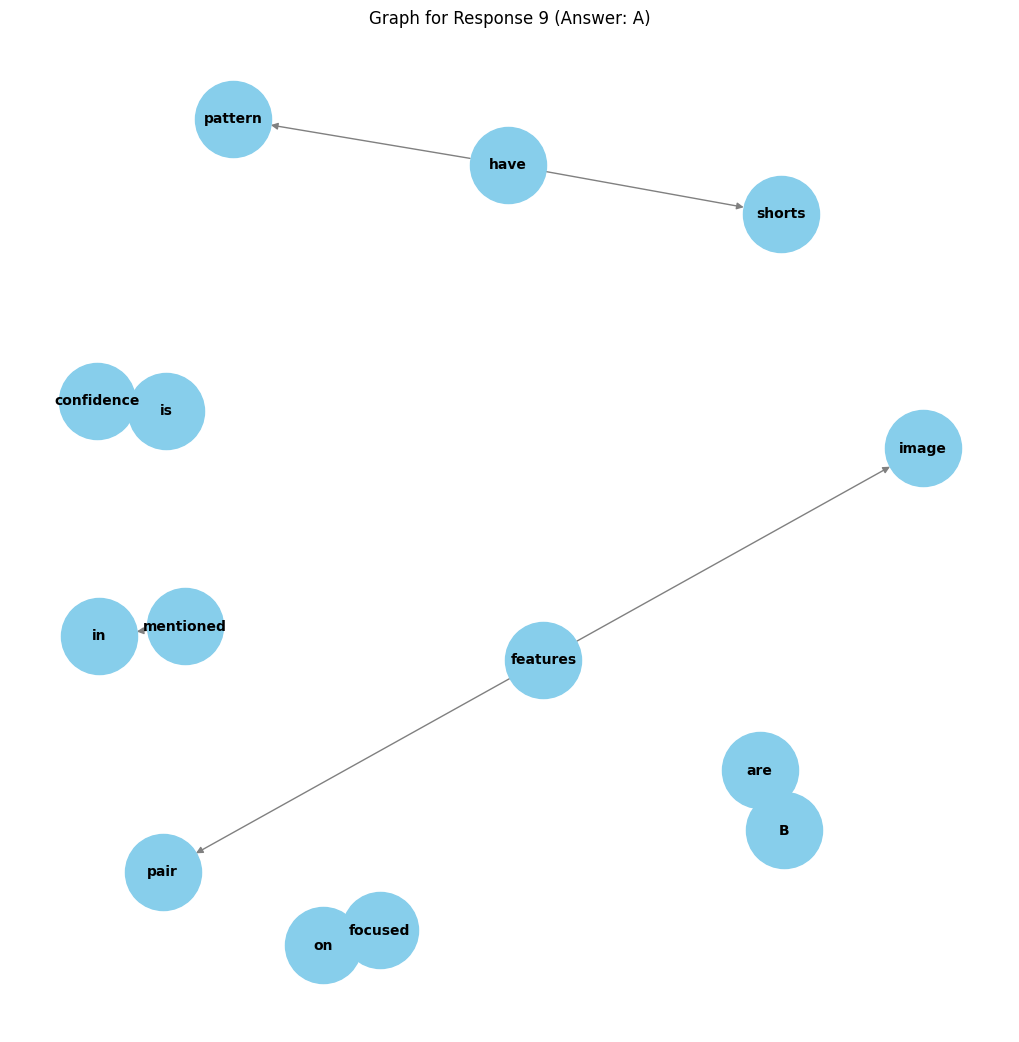

Explanation: In the image, you can see a pair of men's shorts with a grey and white plaid pattern worn by a man. This is commonly referred to as a pair of 'shorts' rather than 'Dress' or 'Denim', which doesn't make sense in this context. The material of the shorts and the pattern indicate it's a denim-like fabric. Hence, the best option is A: 'Shorts'.


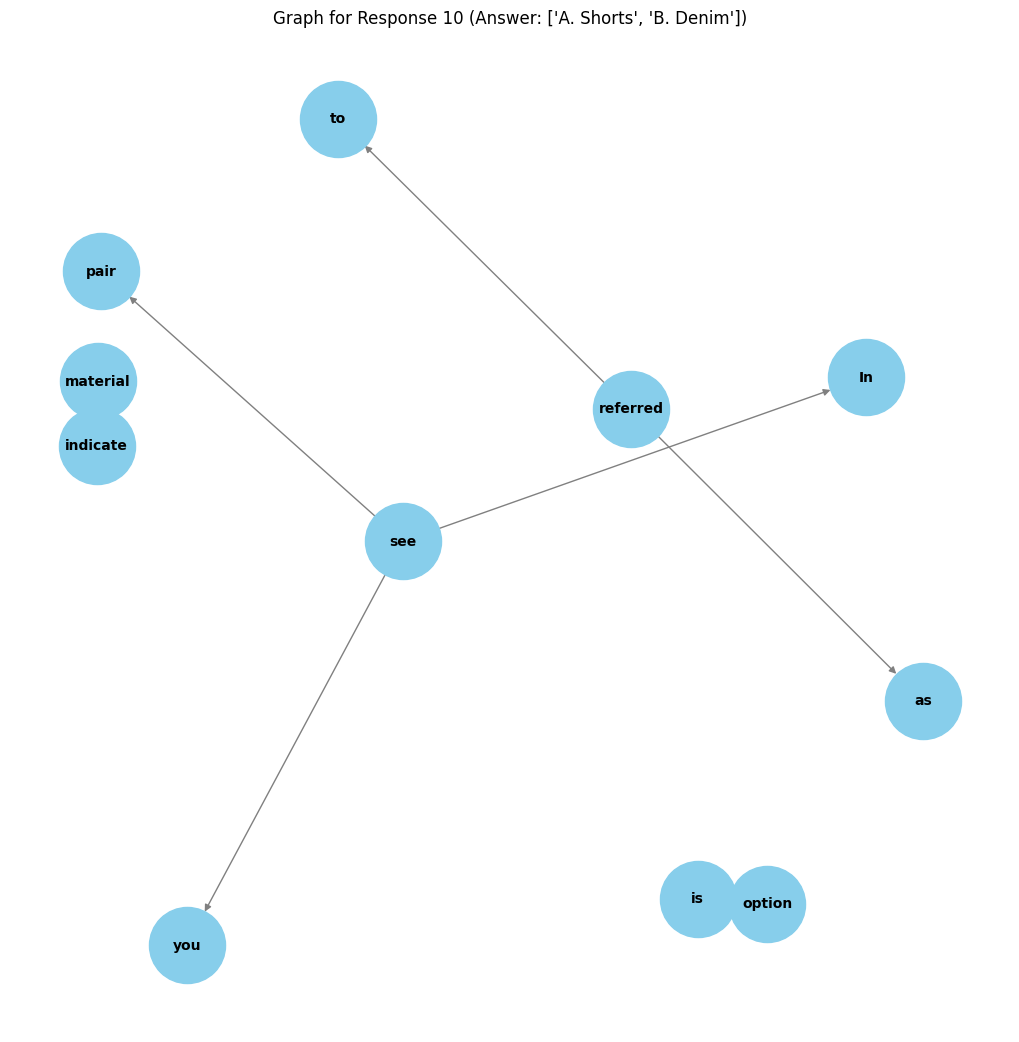

Explanation: Flip flops with a striped pattern on them, often seen in the summertime. These shorts are casual and beach-inspired, perfect for warm weather and can be worn for both formal or informal occasions.


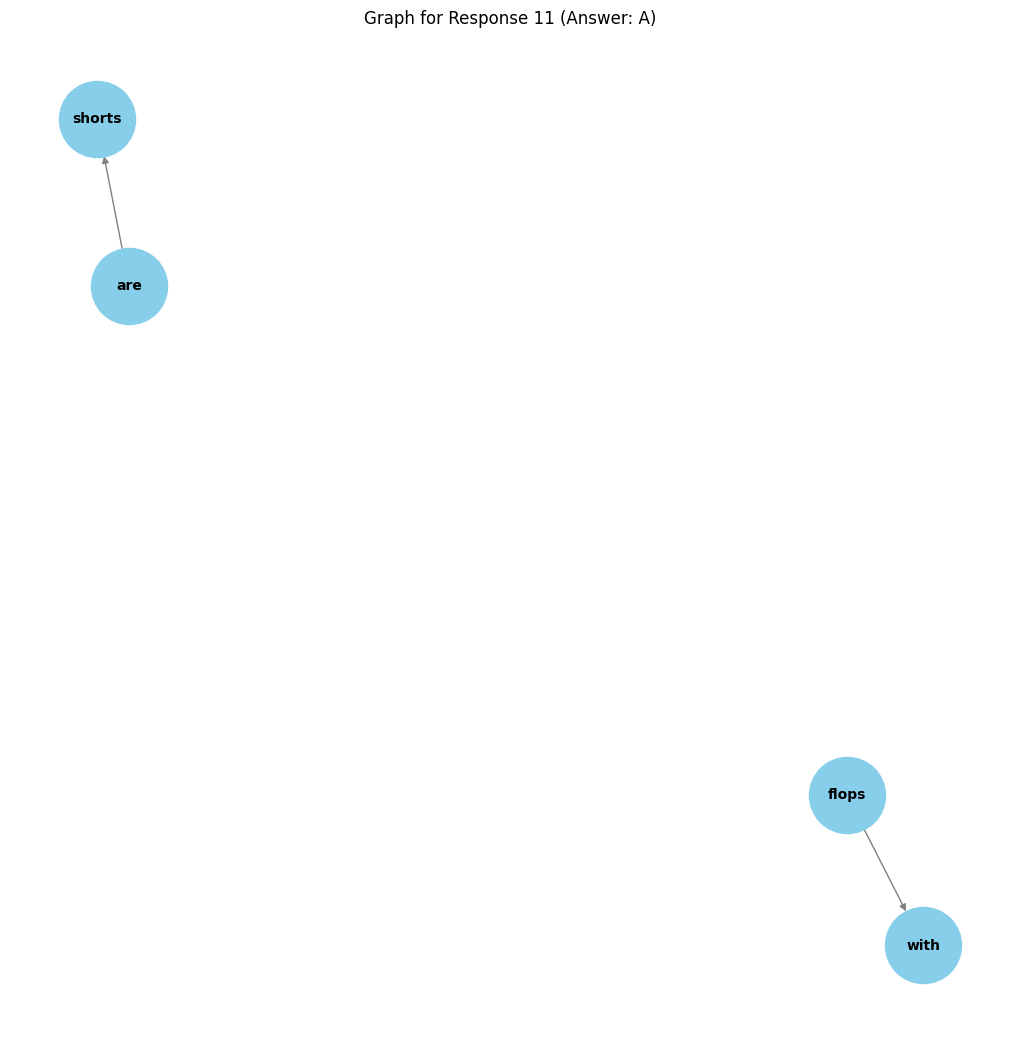

Explanation: 
Error: 'answer'
Response: {'attributes': [{'answer': 'A', 'explanation': 'Pants shown on a male model.', 'confidence_scale': 1}]}
Visualizing for index: 2831
Explanation: No, there is no large vehicle like a truck in the image. The photo shows a bathroom with a mirror reflection of a person and modern bathroom fixtures.


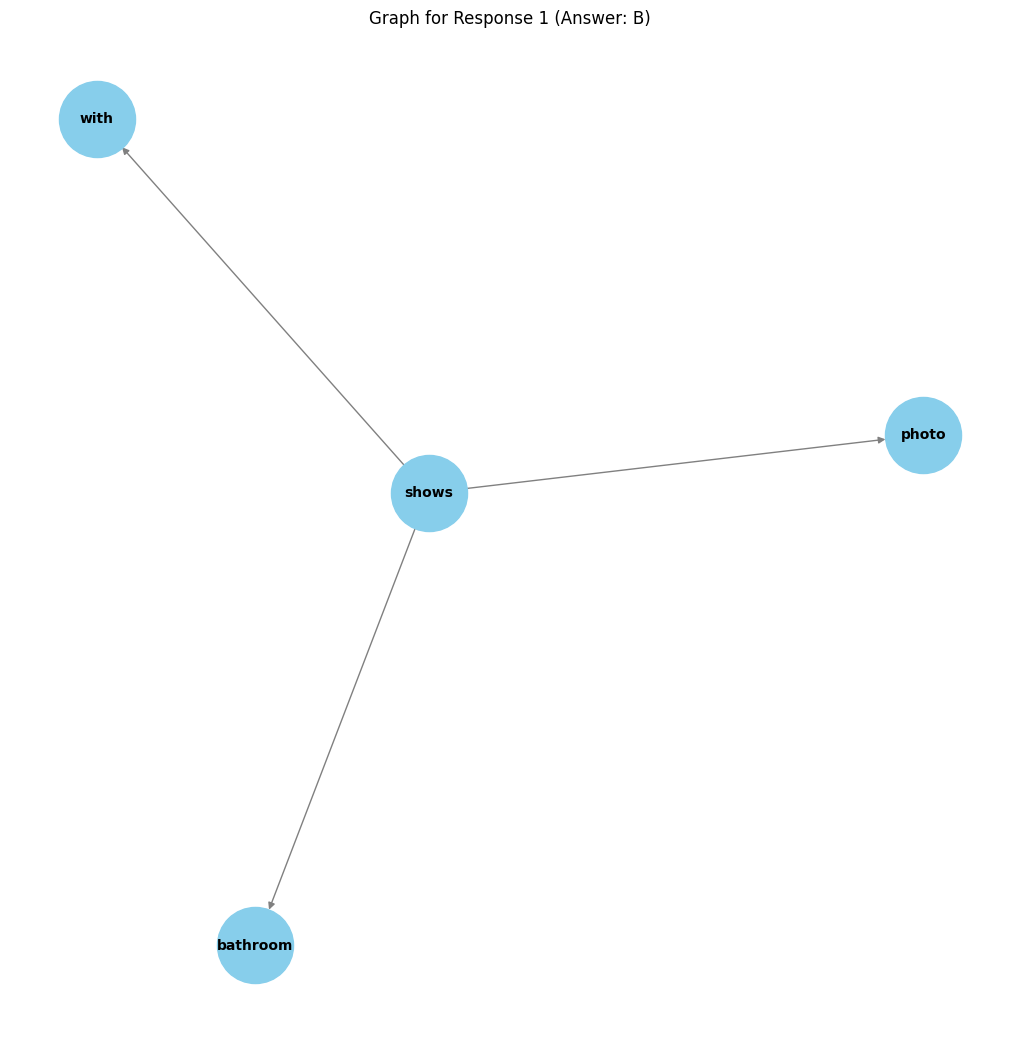

Explanation: There is no truck in the image, just a picture taken inside a bathroom stall. There is no other object that can be identified as a truck by looking at a partial image.


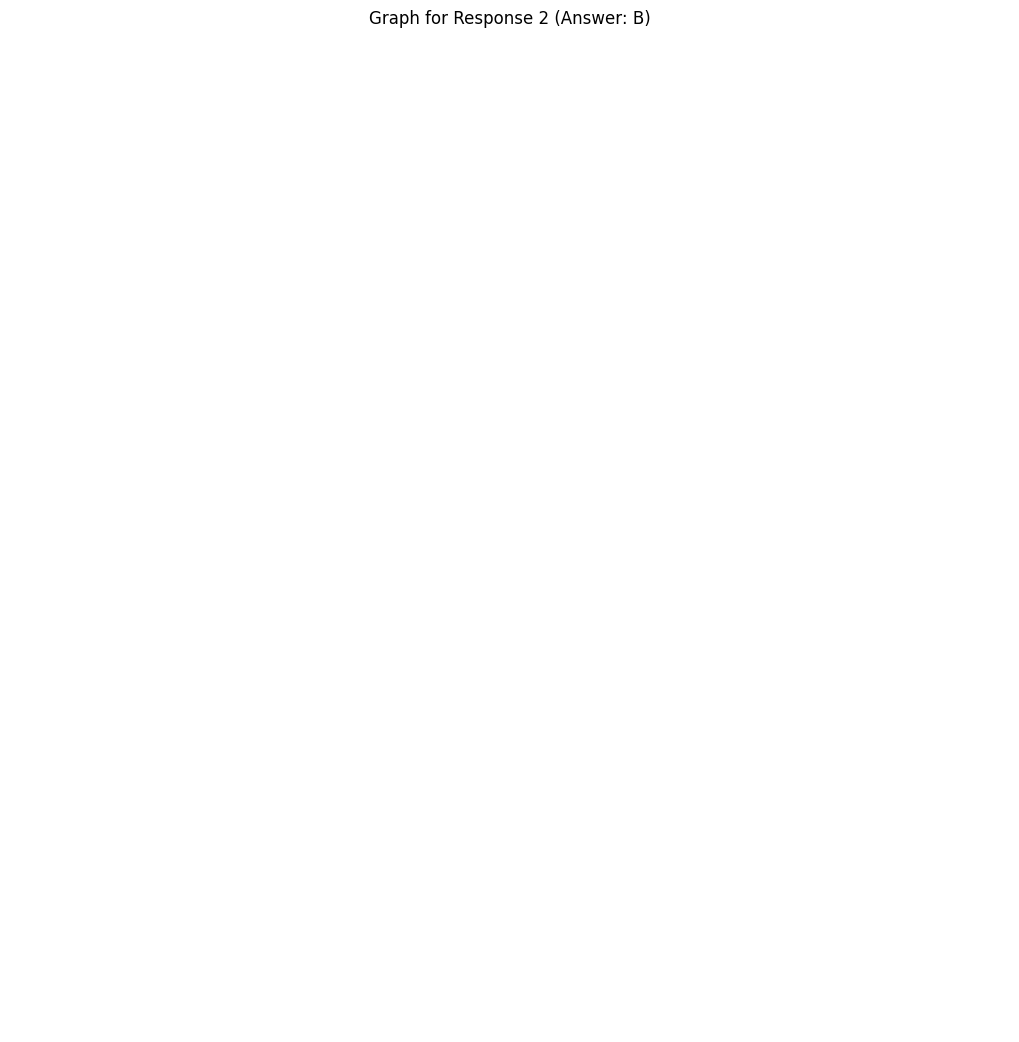

Explanation: From the available options, 'is there a truck in the image' is the most plausible answer. A 'truck' could be interpreted as a variety of objects such as a piece of furniture, vehicles, or items found in a bathroom. The image does appear to show different elements in a bathroom, like a toilet, handicap bar, closet door, and door handle. However, a 'truck' as a concept is more appropriate here rather than a specific object. Additionally, 'a truck' fits the context of the phrase 'look at all the trucks in the restroom'.


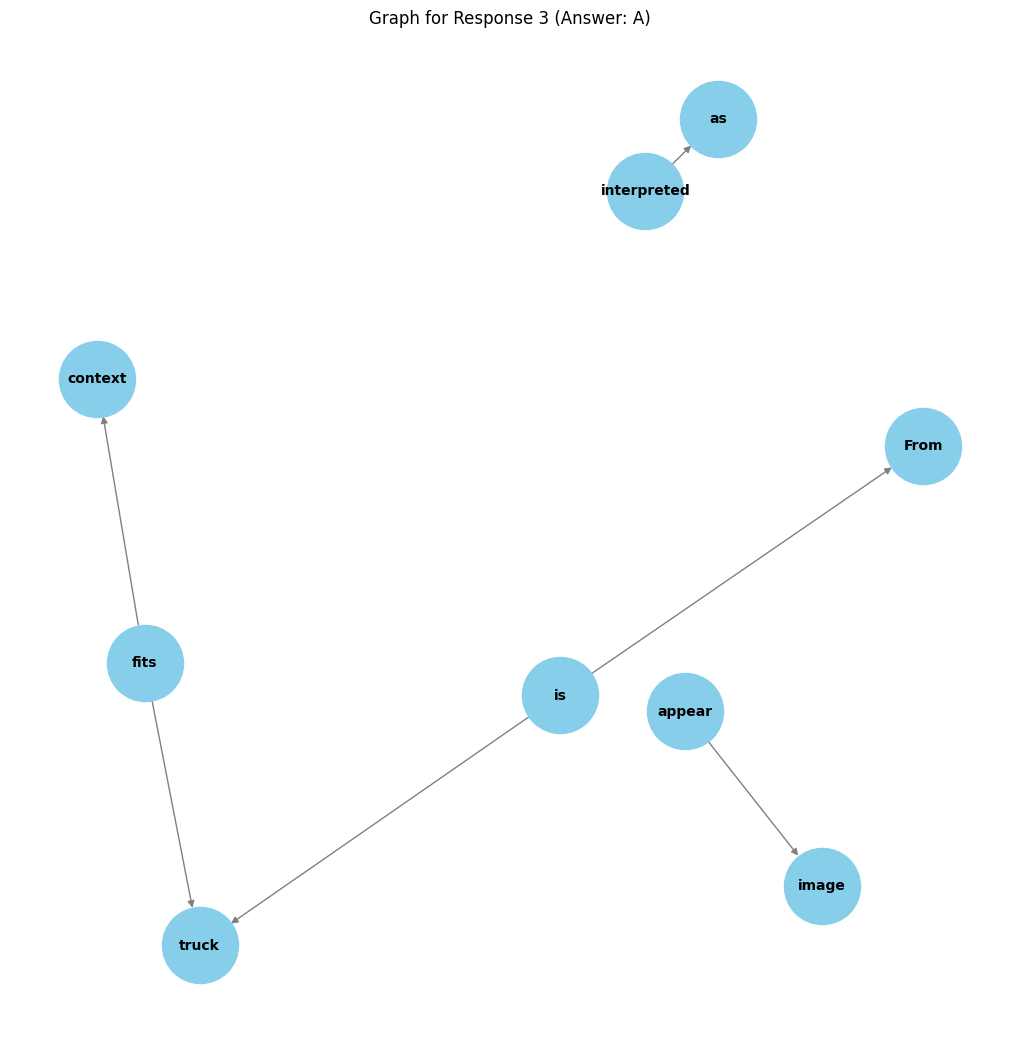

Explanation: The image you provided shows a mirrored view capturing the reflection of a person from behind. The only part of the person that is visible is the lower body, as seen by the foot shown in the mirror. There is no truck in the image as only the lower half of a person's reflection is visible in the mirror


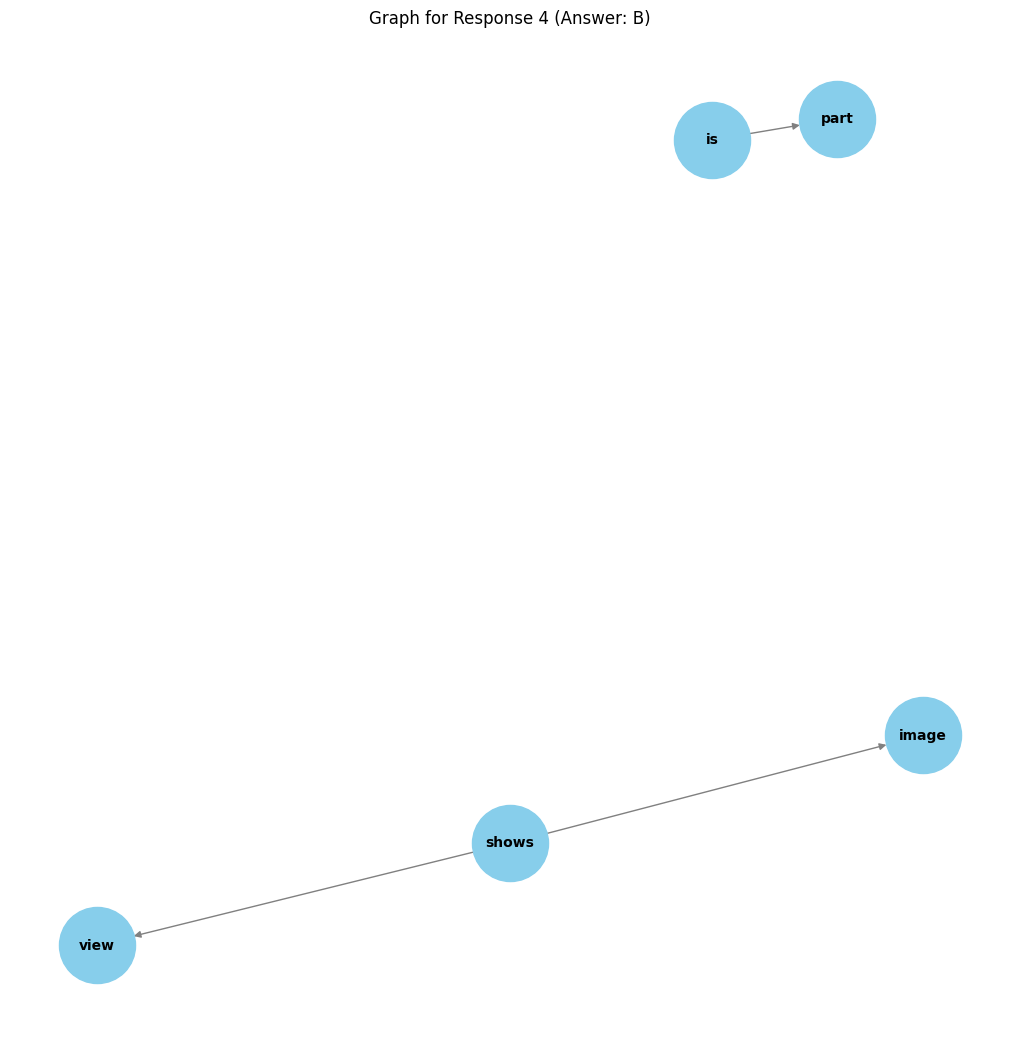

Explanation: While the image does show a truck in a mirror at a slight angle, the focus is primarily on the entrance to the truck bed and the person's lower body, as they approach the truck from outside. In order to better identify the specific area of interest, more context or a closer view would be needed. Currently, it is not feasible to provide a JSON object for this identification.


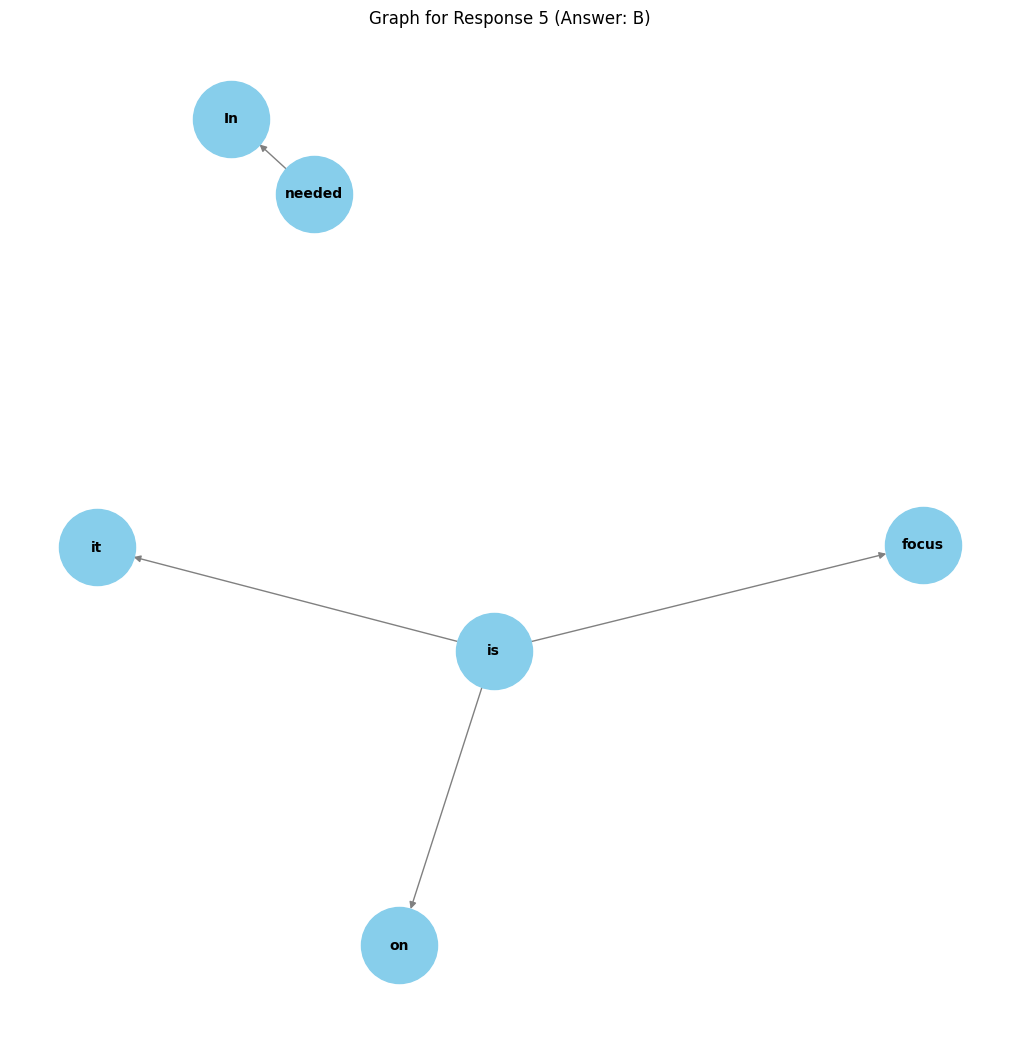

Explanation: There is no truck in the image. The image shows a person inside a bathroom, which is a typical setting where you would expect to see various items, such as toilet paper, toilet brushes, and personal care items. However, there are no heavy objects, like a truck, visible in the image. It is a view of a bathroom vanity with the lower part of the vanity partially cut off by the edge of the image. There is also a person visible wearing pants, shoes on their feet, and a sticker on the left-hand side of the vanity. There's no truck in this scene.


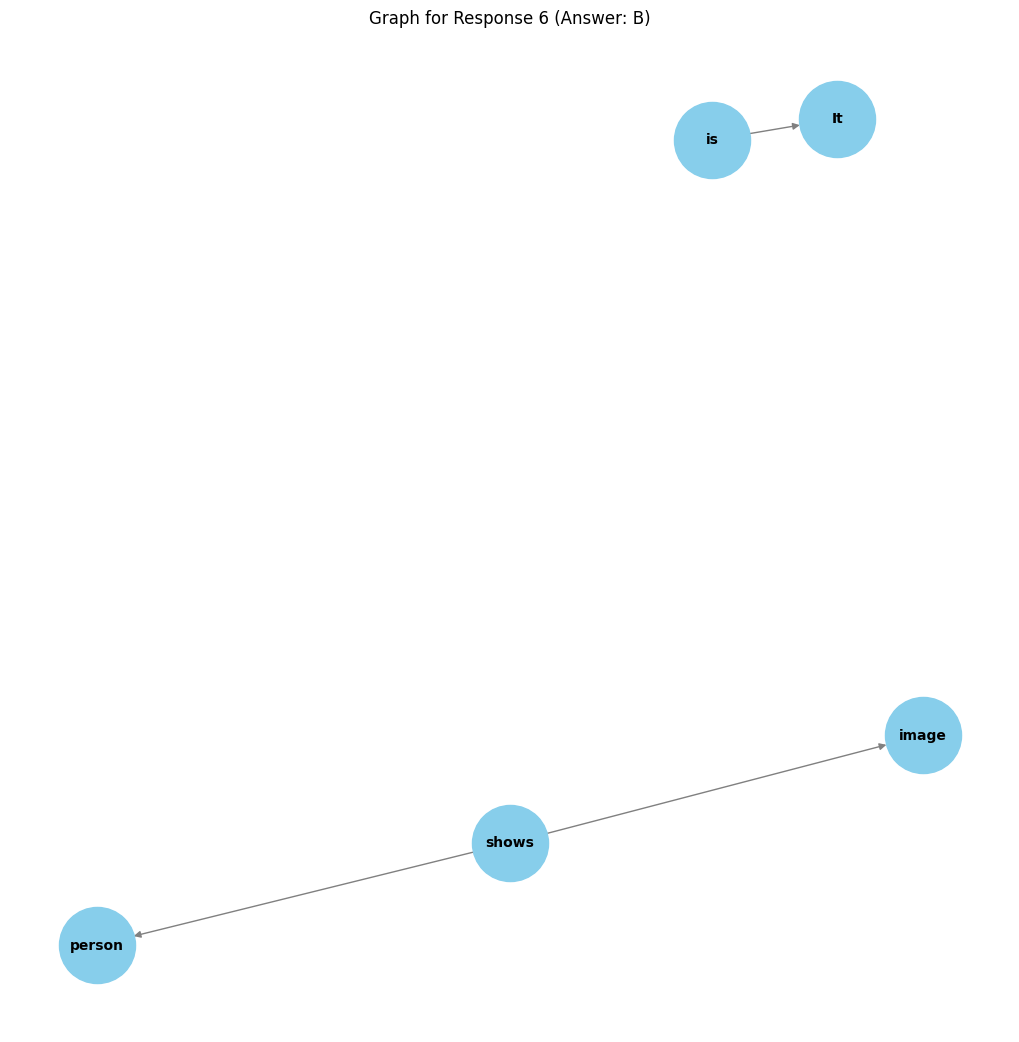

Explanation: While there is a person standing, the image shows a reflection of the person in a mirror, and the reflections are symmetrical, not showing a truck. This indicates that the truck is not present in the immediate vicinity or the image excludes it. Additionally, a truck is not typically associated with the interior of a bathroom, so its absence in the photo supports the fact that it is not present.


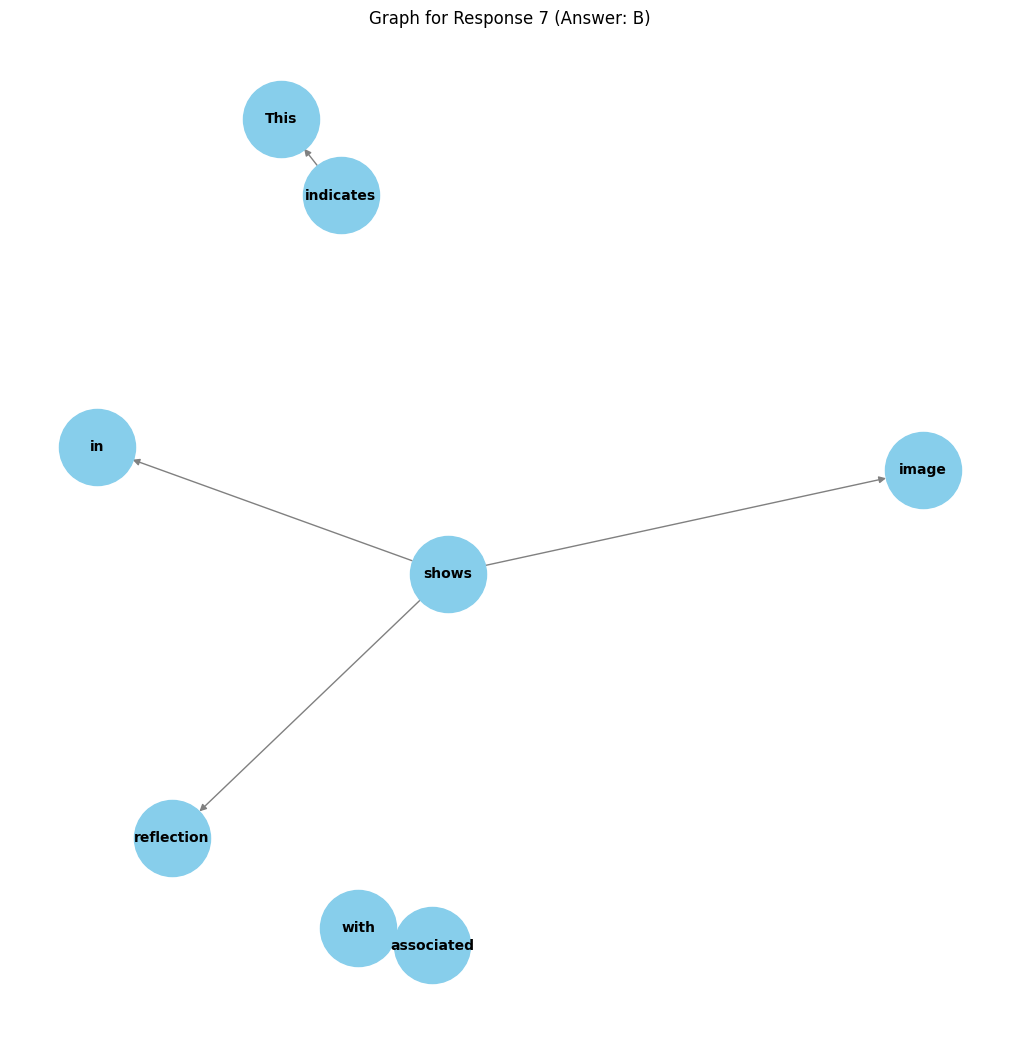

Explanation: The image you provided does not depict a truck. The photo shows a person's reflection in a mirror, which is in a bathroom. There are no vehicles, including trucks, visible in the image.


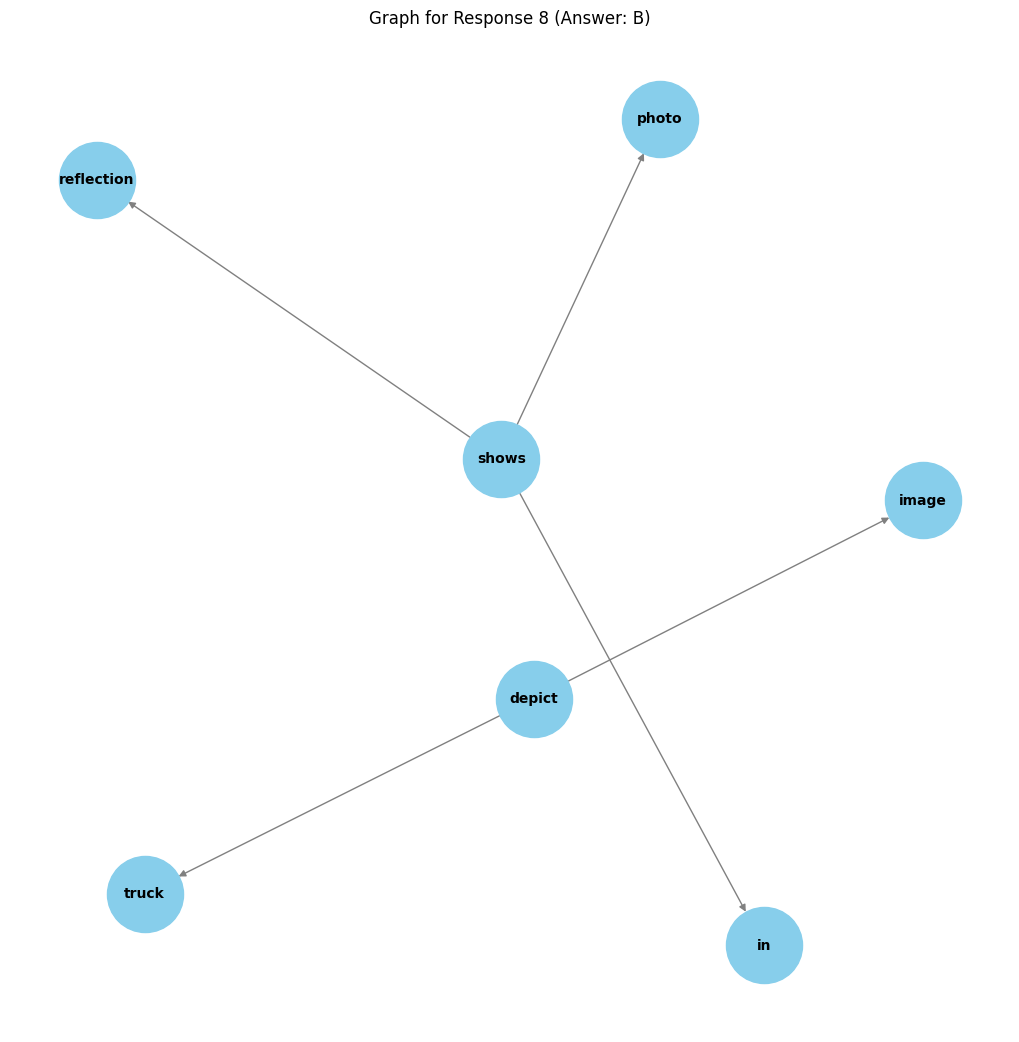

Explanation: There is no truck in the image, as it shows a person in a public restroom with a reflection, a toilet seat, and a card reader. The image does not contain a vehicle like a truck.


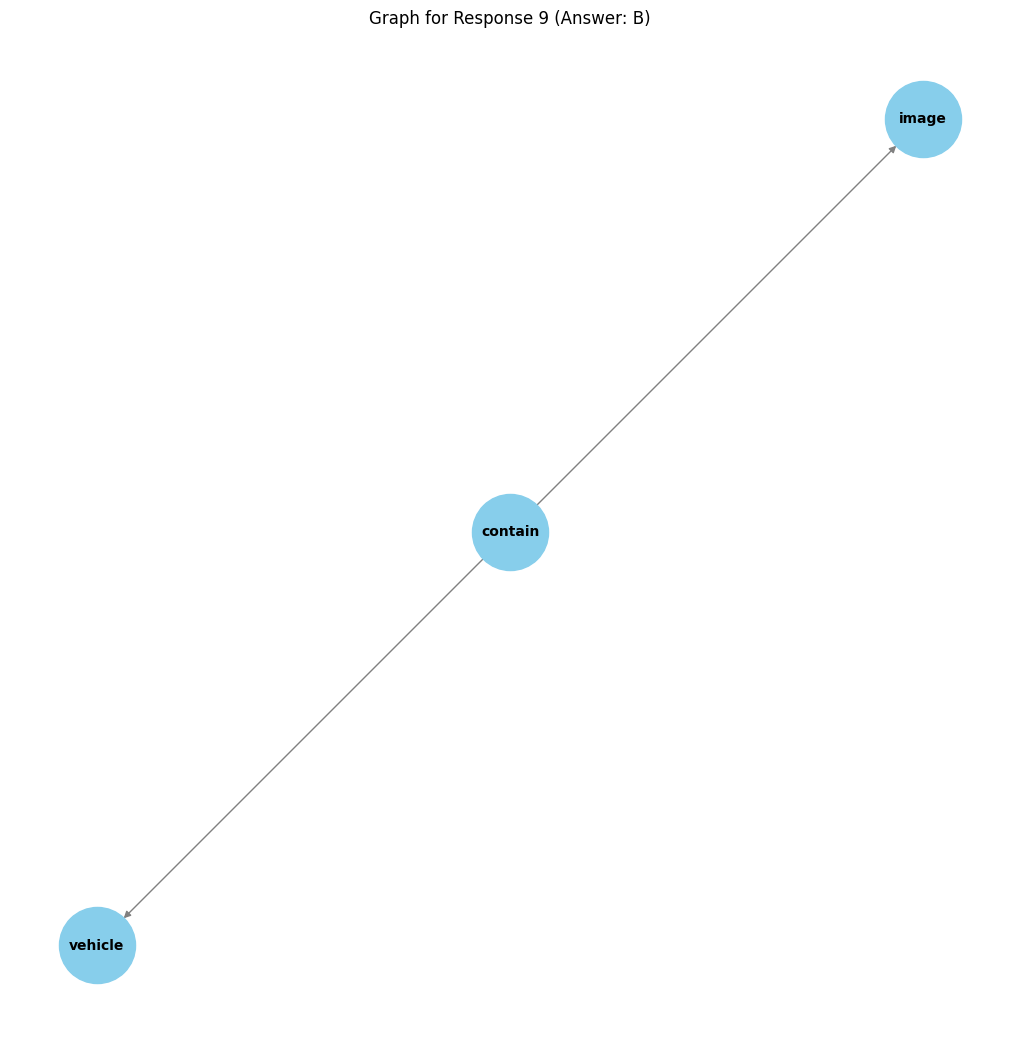

Explanation: There is no truck in the image. It displays a photo that appears to be taken by a camera or an electronic device. The only focus is on a leg and foot in the foreground with a reflection in a silver surface. The person is standing in front of a bathroom fixture, likely toilet paper, and a wall which seems to be carpeted, and not on a truck.


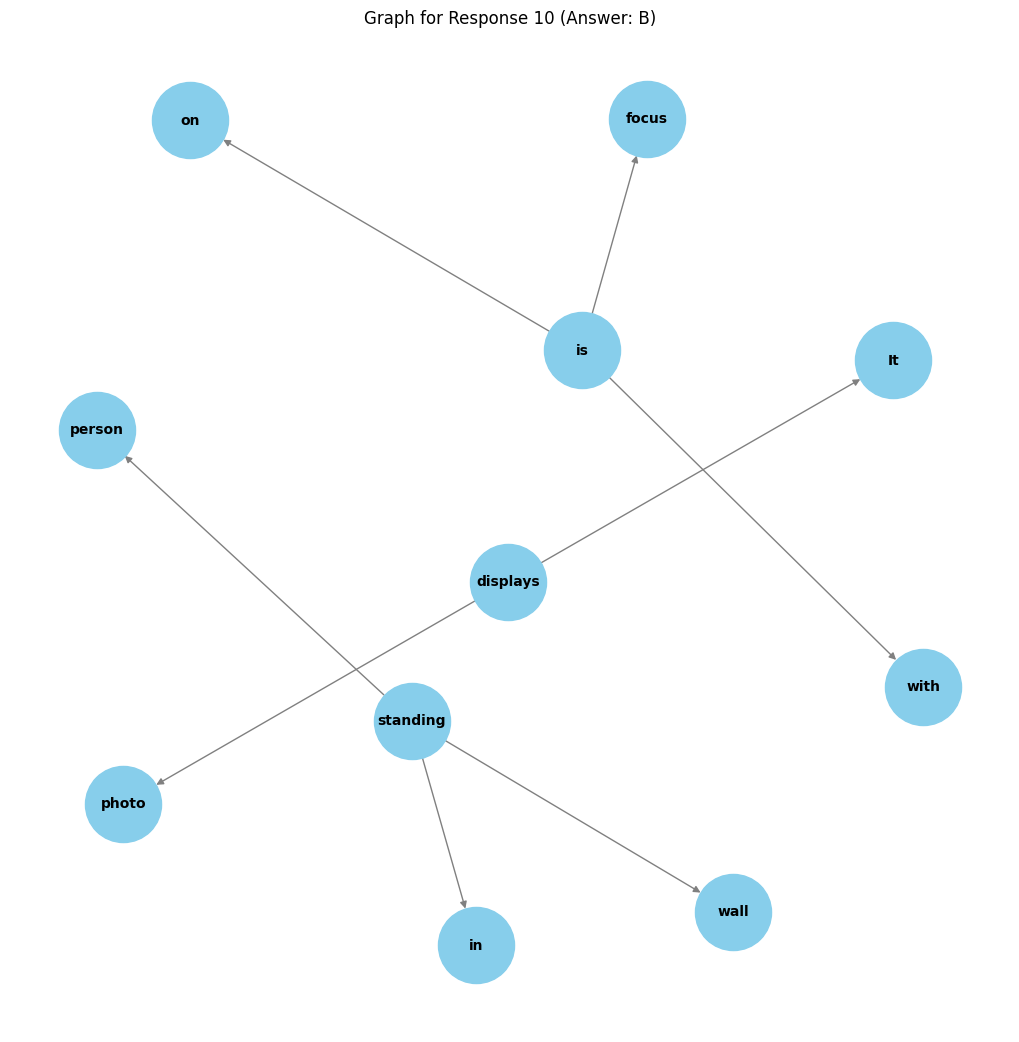

Explanation: The image provided does not contain any elements that resemble a truck. It's a photo of a bathroom, showing a person standing next to it. It has a bathroom fixture or equipment, which implies some aspect of a truck could be involved in its construction or installation, but the visible part in the image does not represent a truck or its parts.


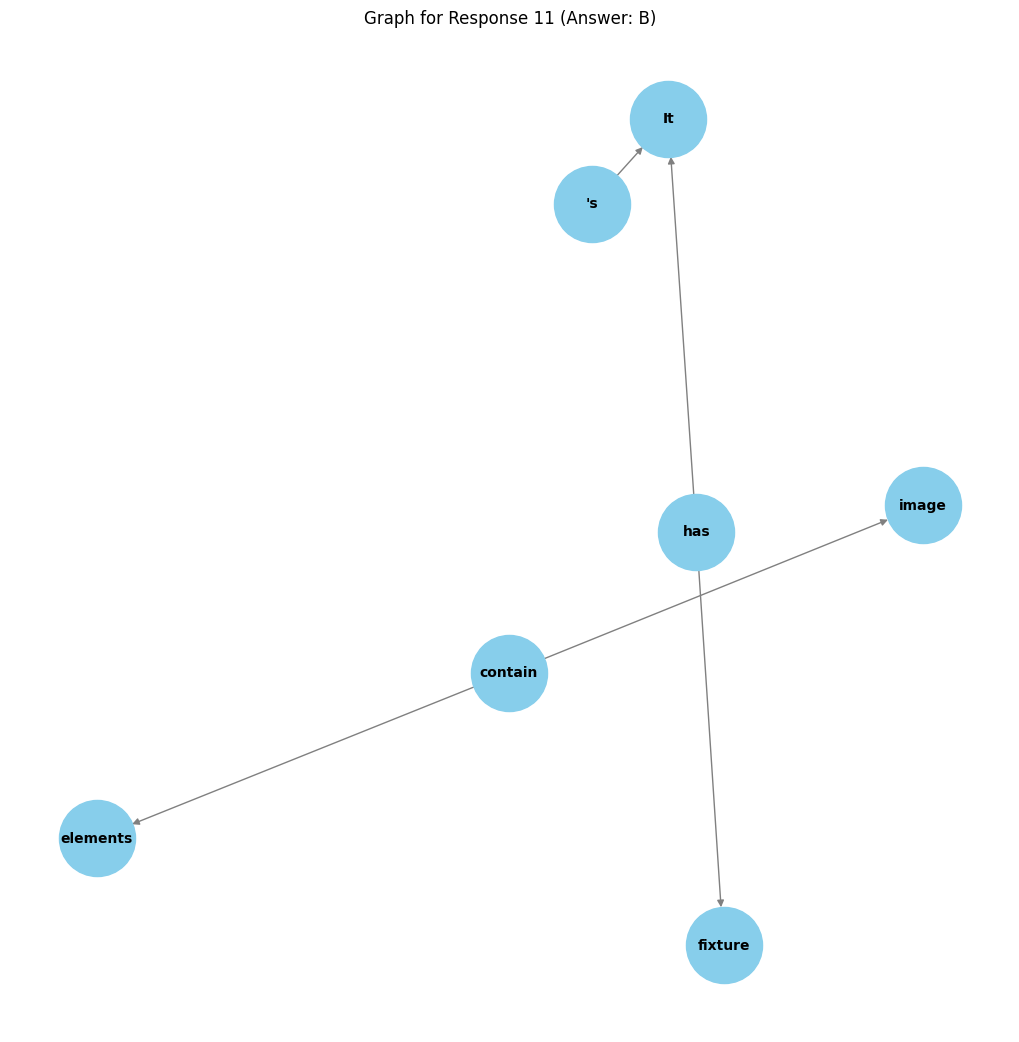

Explanation: The image refers to a public toilet and specifically to the door handle. There is no truck visible in the image, so the correct answer is 'A' (Yes).


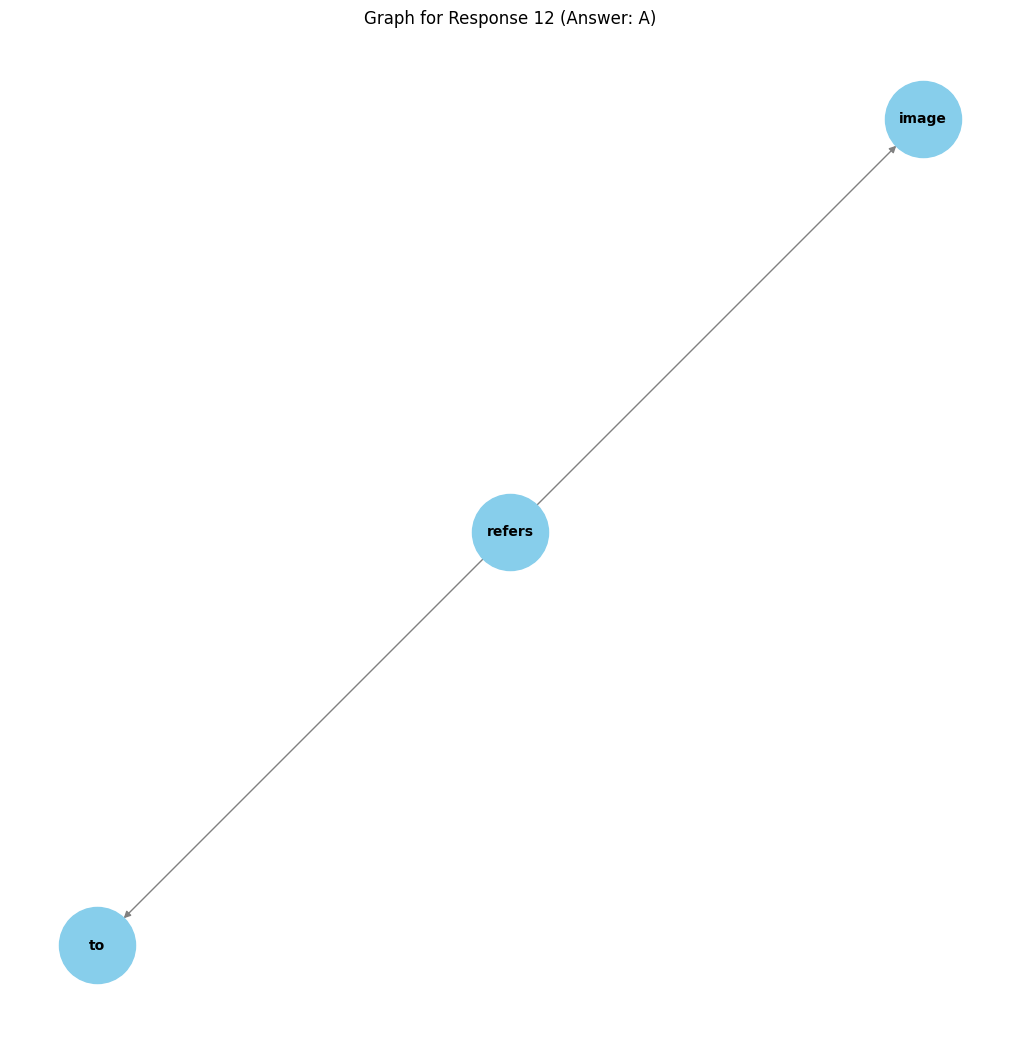

Visualizing for index: 2835
Explanation: There are no skis in the image as it depicts a city bus loading passengers at a bus stop, not skiing activities. The image shows a large building in the background along with pedestrians and a bus on a street.


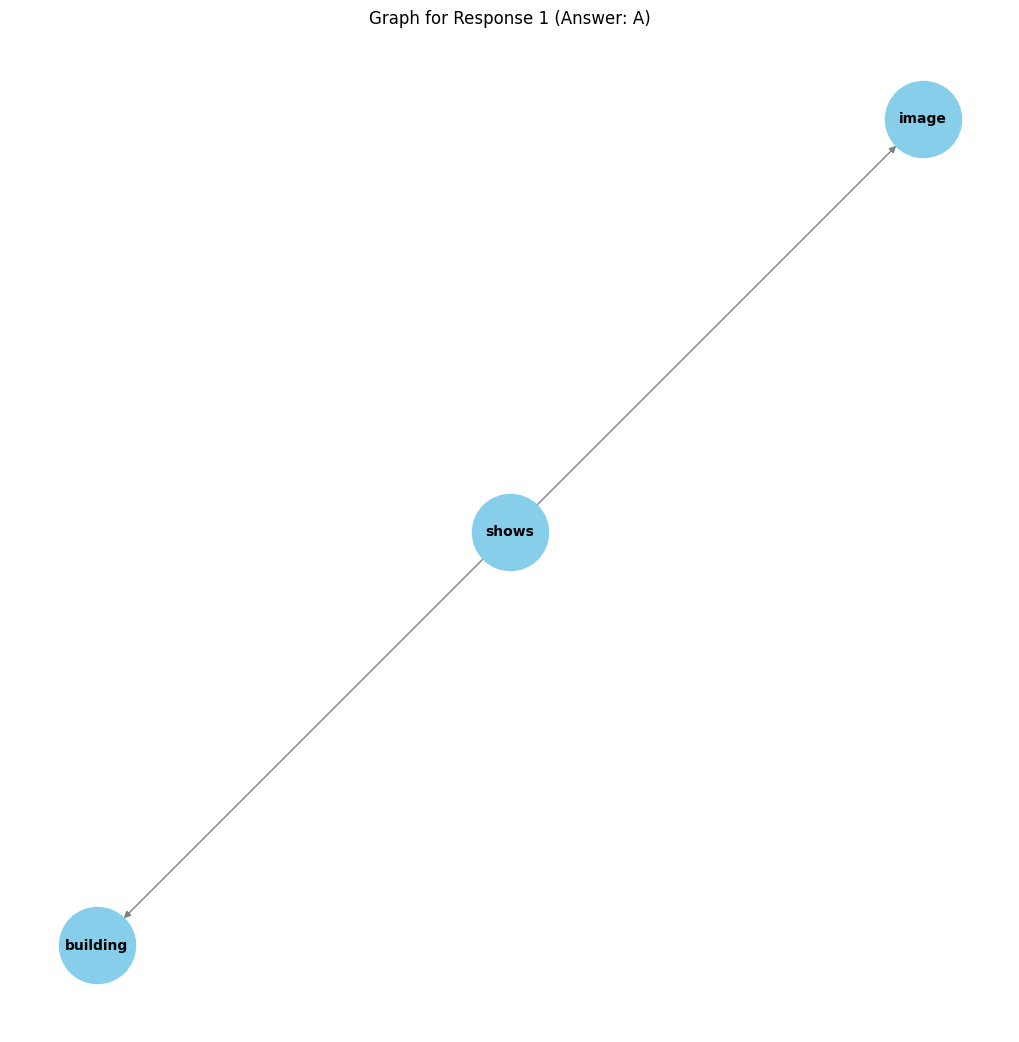

Explanation: In the image provided, there is no skis visible. The bus is next to tall buildings, there are some passengers on the bus, and there are cars in the street. Since skis are not visible in the image, the answer is 'A'.


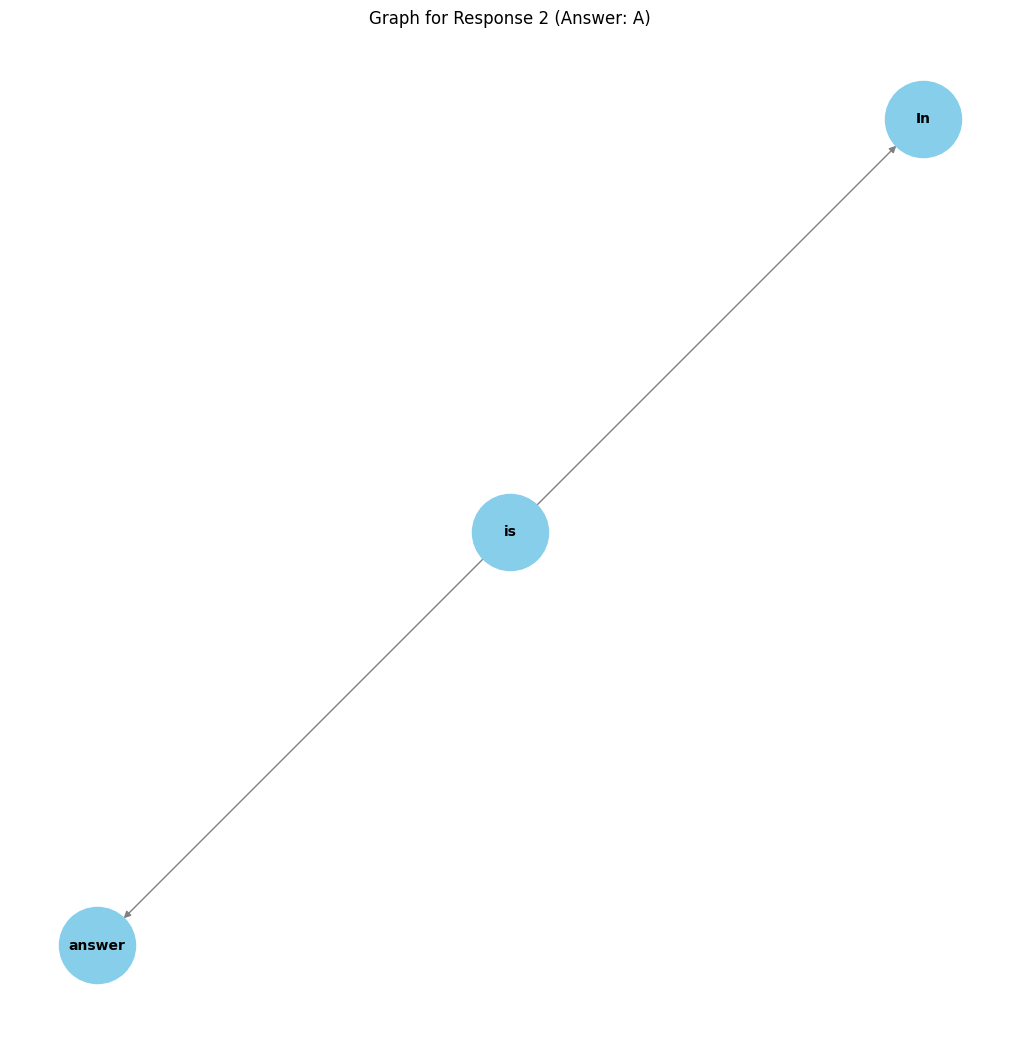

Explanation: There are no skis in the image since the image depicts a city street with a bus, passengers boarding the bus, and tall buildings in the background. It does not show any skiing-related activity or equipment.


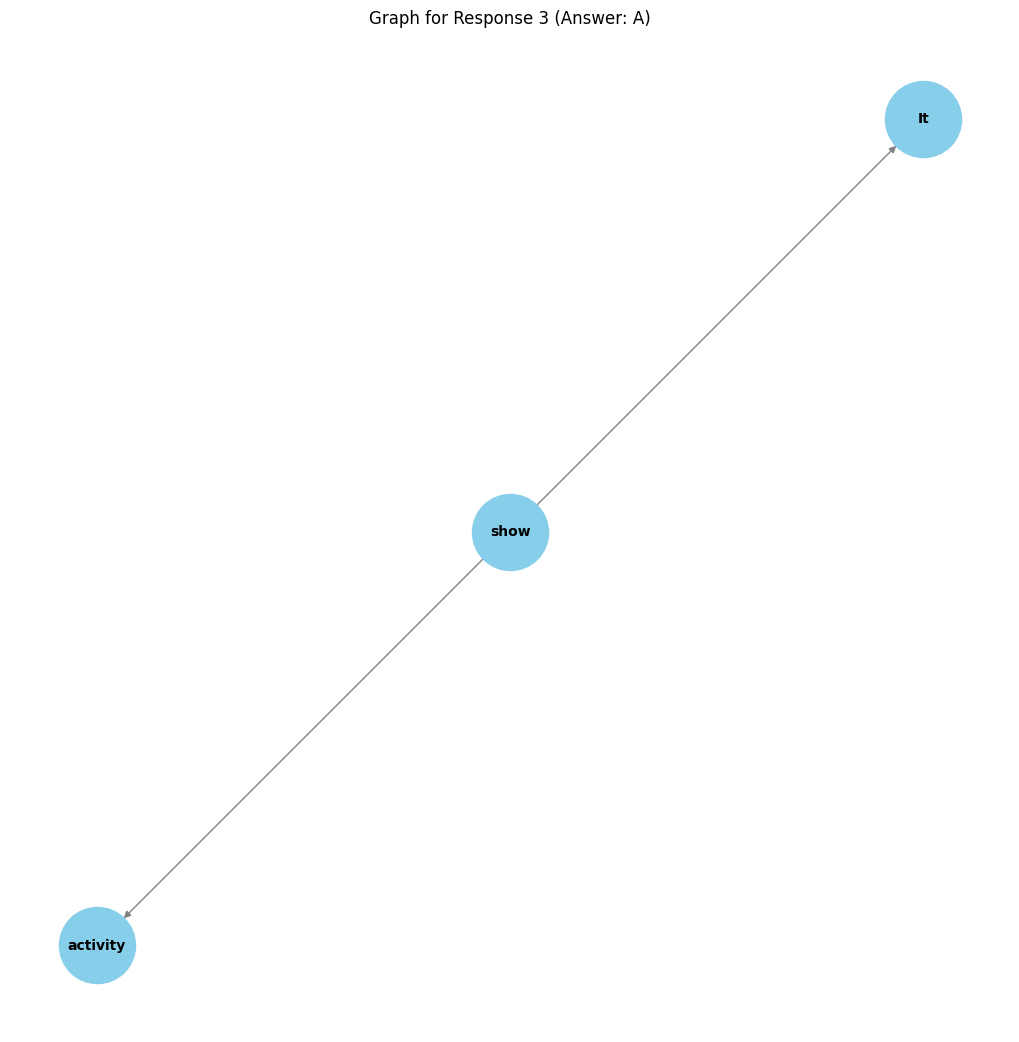

Explanation: The image does not contain any skis. It depicts a city street with a bus, a group of people waiting to board the bus, and tall buildings in the background. The answer 'no' is correct as there are no skis present in the image.
Error: 'answer'
Response: {'question': 'Is there a skis in the image?', 'explanation': "The image does not contain any skis. It depicts a city street with a bus, a group of people waiting to board the bus, and tall buildings in the background. The answer 'no' is correct as there are no skis present in the image.", 'confidence': 0.95, 'graph': {'The image': {}, 'any skis': {}, 'It': {}, 'a city street': {}, 'a bus': {}, 'a group': {}, 'people': {}, 'the bus': {}, 'tall buildings': {}, 'the background': {}, 'The answer': {}, 'no skis': {}, 'the image': {}, 'contain': {'image': {}, 'skis': {}}, 'image': {}, 'skis': {}, 'depicts': {'It': {}, 'street': {}, 'with': {}}, 'street': {}, 'with': {}, 'is': {'answer': {}}, 'answer': {}}}
Explanation: There are no

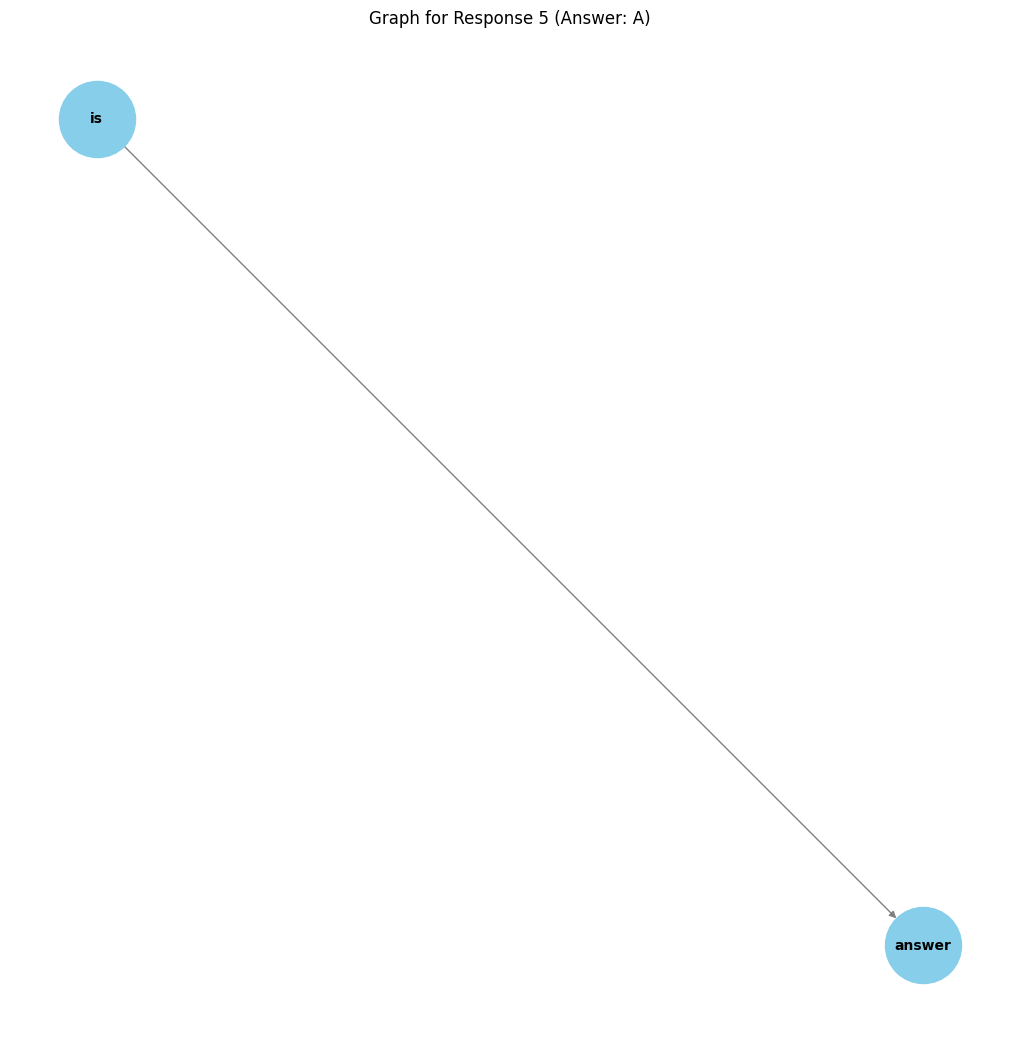

Explanation: No, there are no skis in the image. The image shows a large city street with two buses, passengers boarding a commuter bus, and a crowd of city dwellers walking in the foreground. No skis are visible in the photograph.


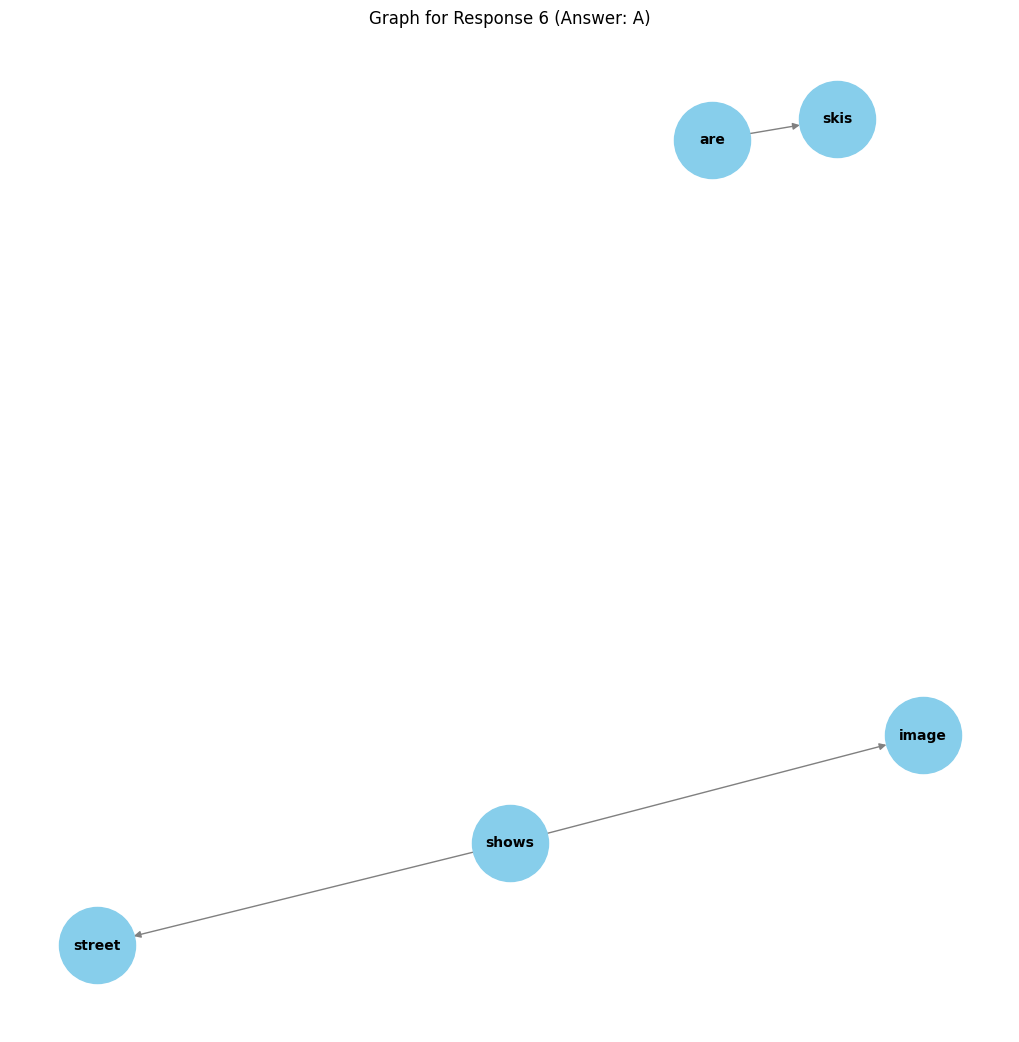

Explanation: There are no skis visible in the image. It's an urban street scene with a bus, people boarding, and tall buildings. The focus of the image is on the public transit scene and pedestrians, not on skiing.


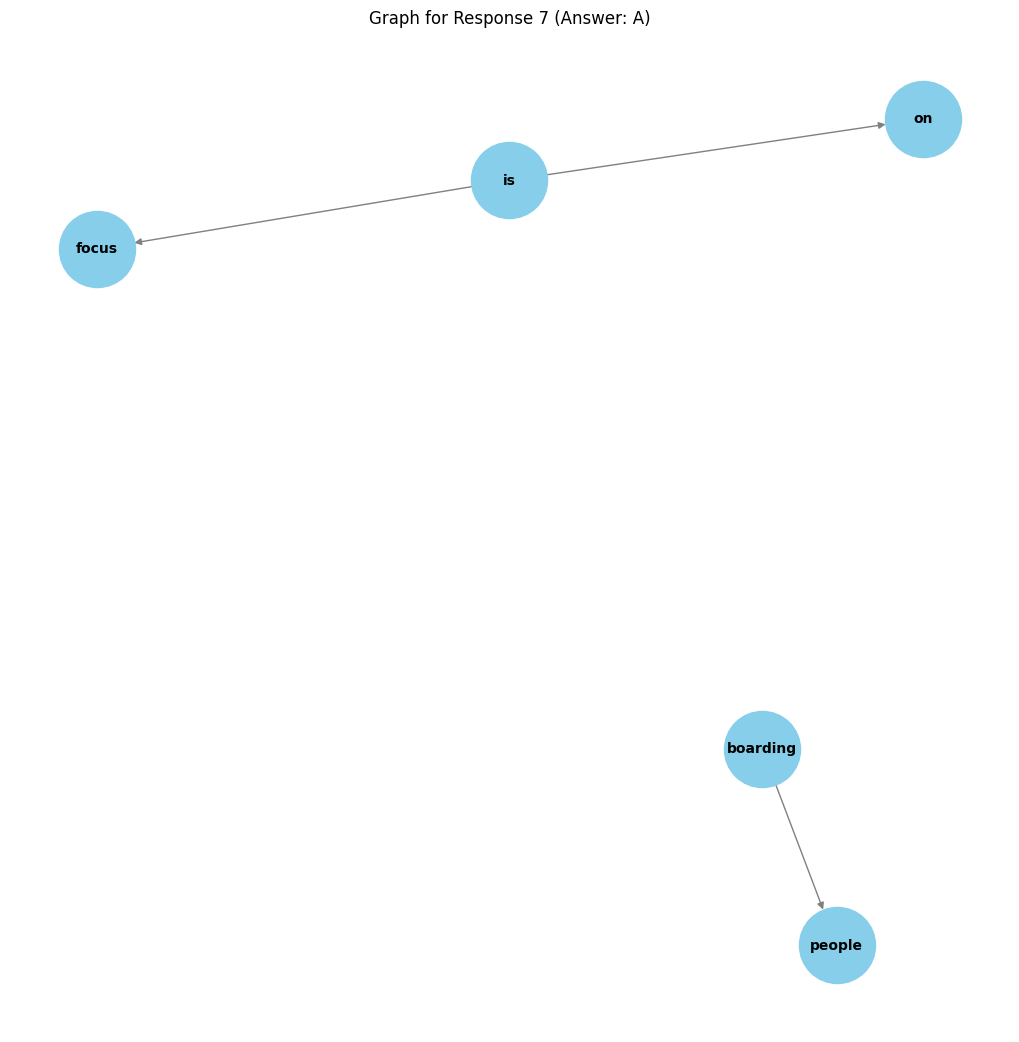

Explanation: The image is of a city street scene with city buses and pedestrians. There are no skis visible in the image.


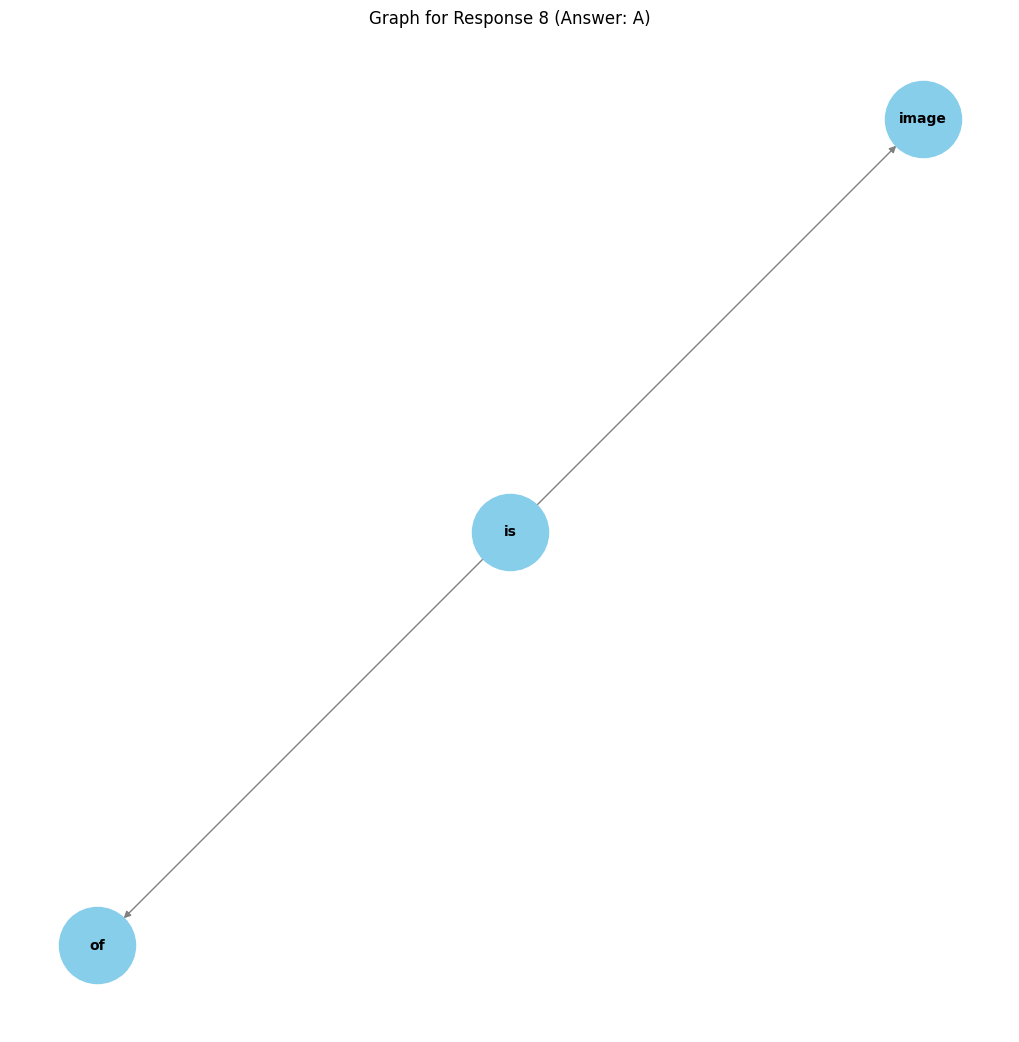

Explanation: There are no skis in the image. It shows a city bus pulling away from a bus stop with people waiting to board. It doesn't have any ski-related objects, thus the answer is 'A. no' and the confidence is 1 because it's an accurate description of the image content.


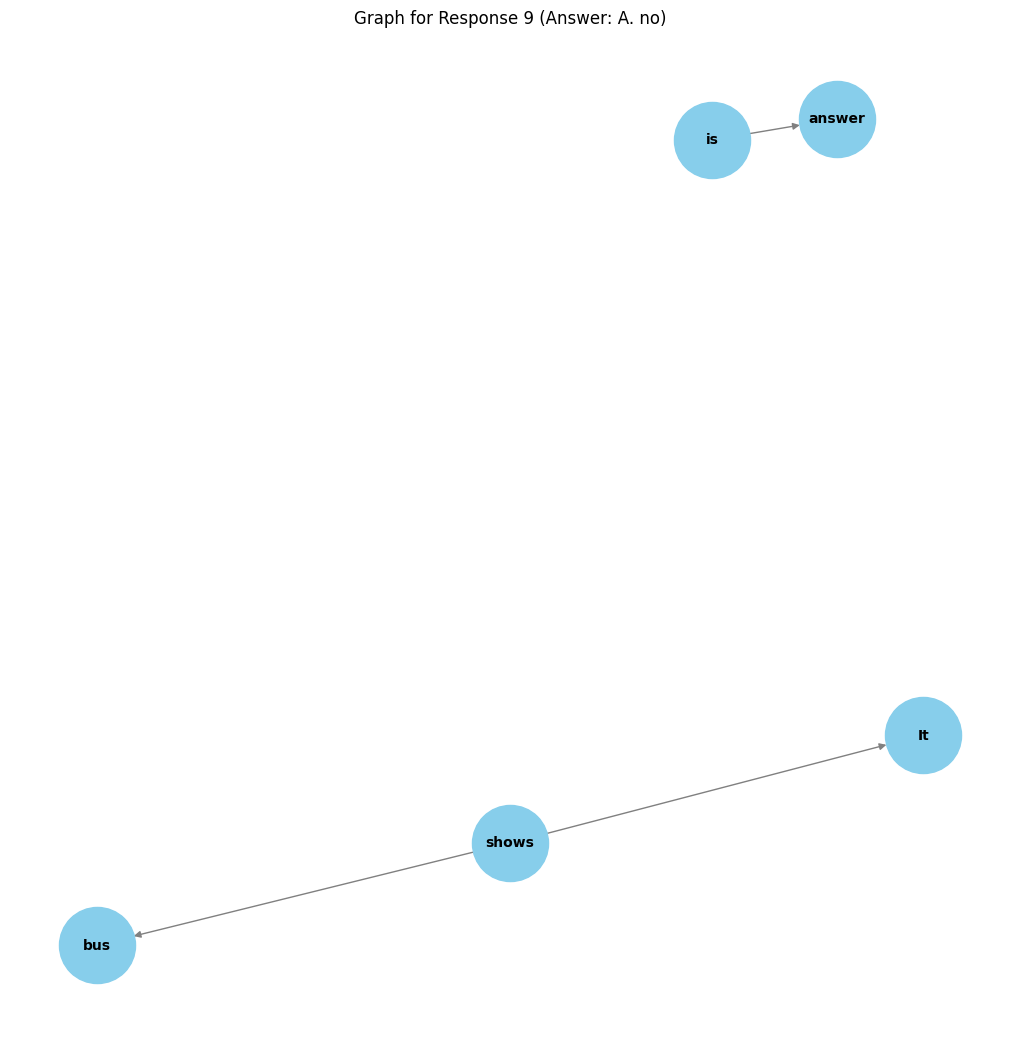

Explanation: The image you've provided is a city scene with a bus stopped and a few passengers waiting to board. There is no skis visible in this image. The presence of a street, a bus, a sidewalk, and a row of buildings suggests an urban setting, but there are no indicators of skiing activity.


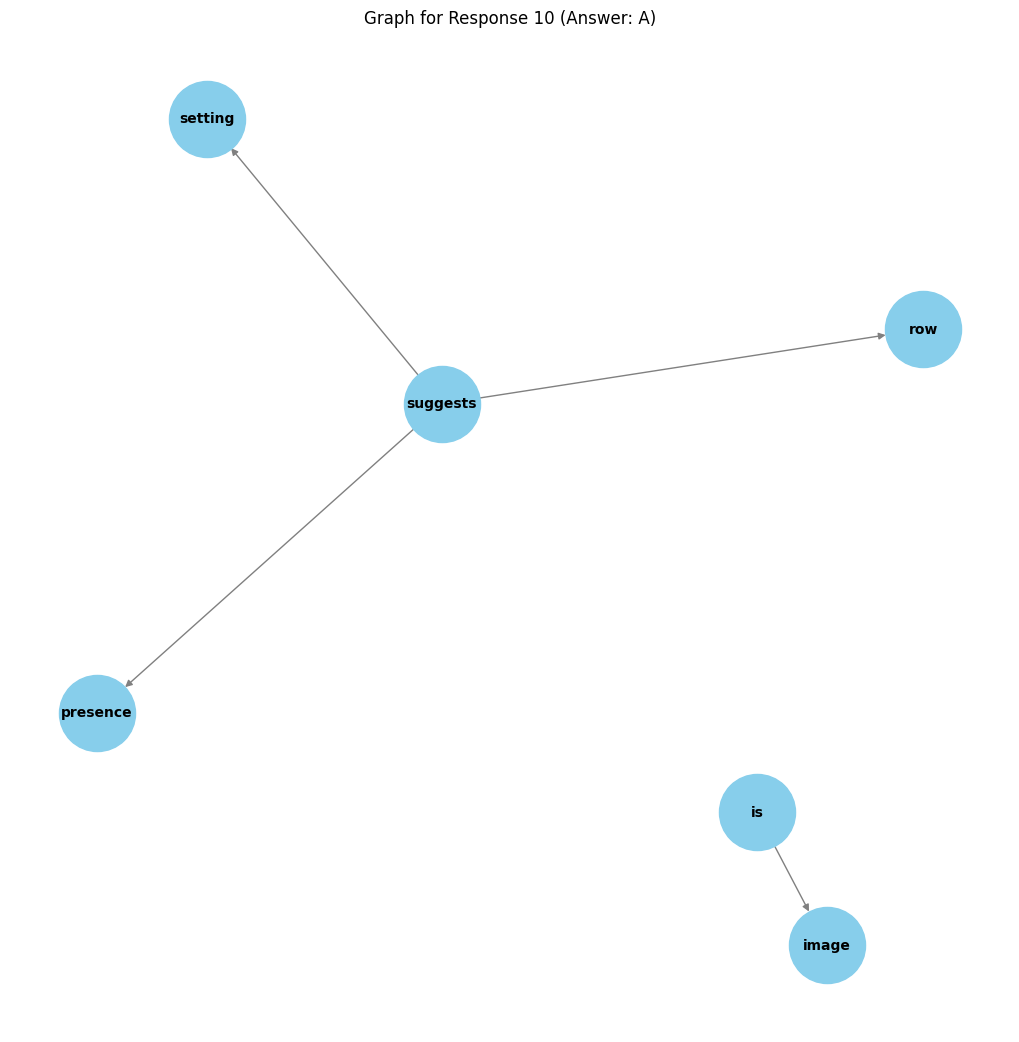

Explanation: There are no skis in this image. It depicts a bus with passengers loading into it on a city street with nearby buildings. Therefore, the answer is 'A' for 'no' since there are no skis in any part of the image.


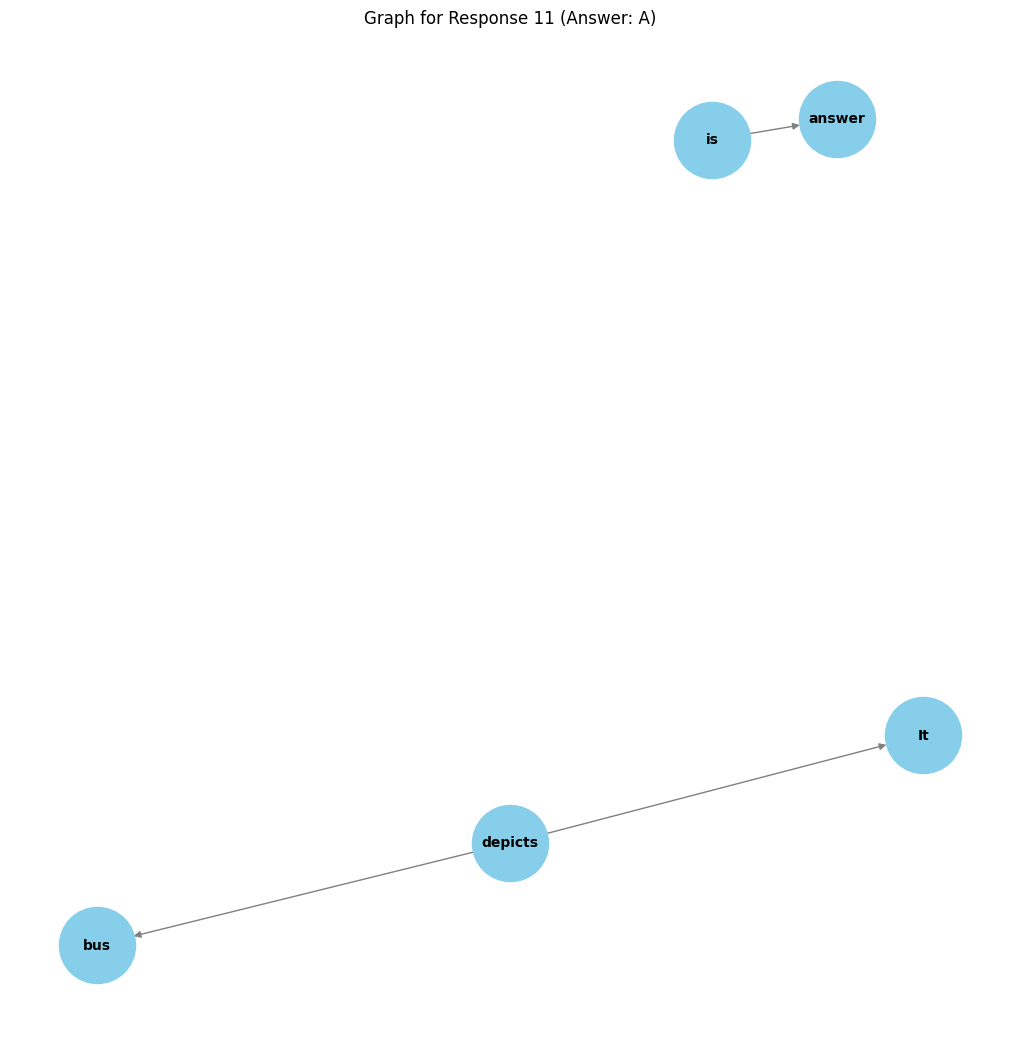

Explanation: The image does not depict skis as it is a urban scene with a city bus, people waiting to board, tall buildings, cars, and signs. There are no indications of skiing equipment or outdoor mountains in this photograph, so the JSON answer should be 'A' ('no').


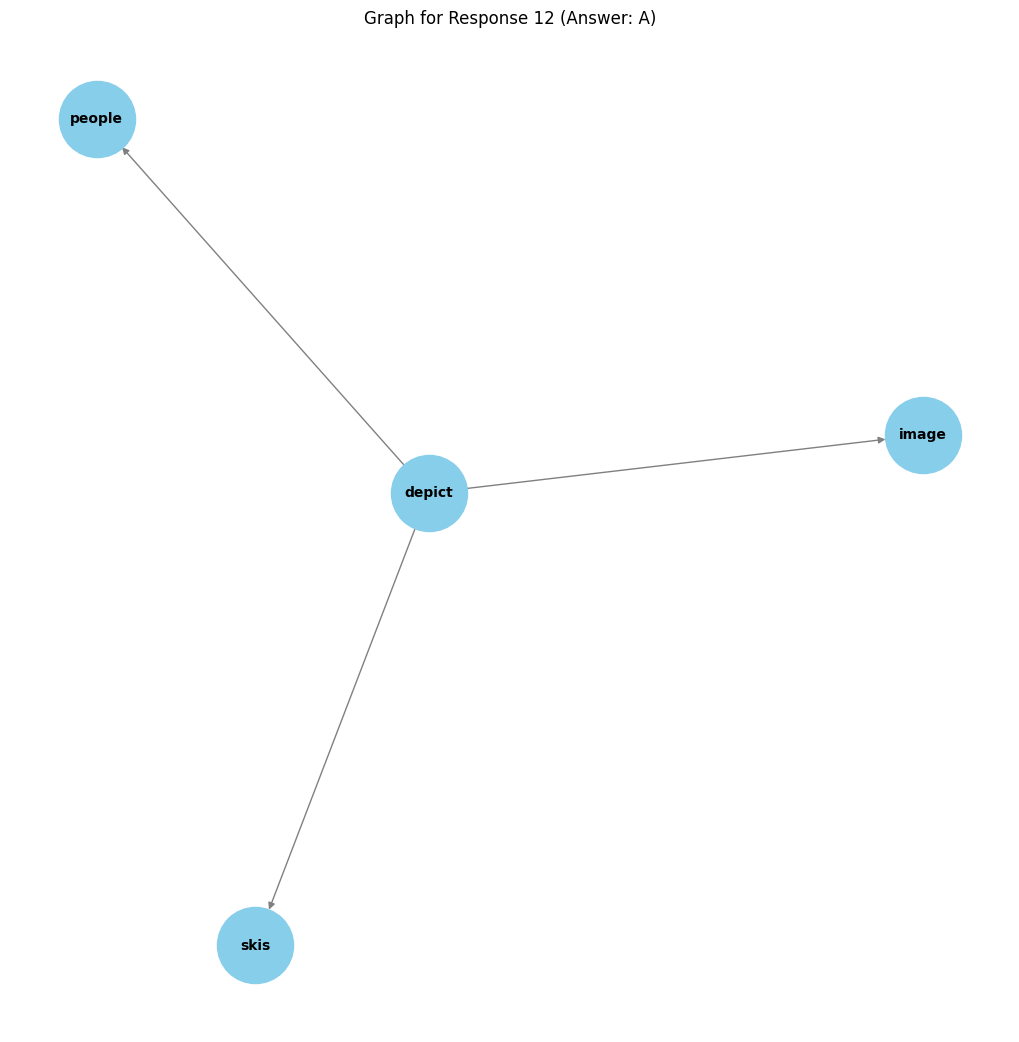

Explanation: There is no ski in the image. It depicts a busy city street with public transit buses and a group of people standing or exiting one vehicle.


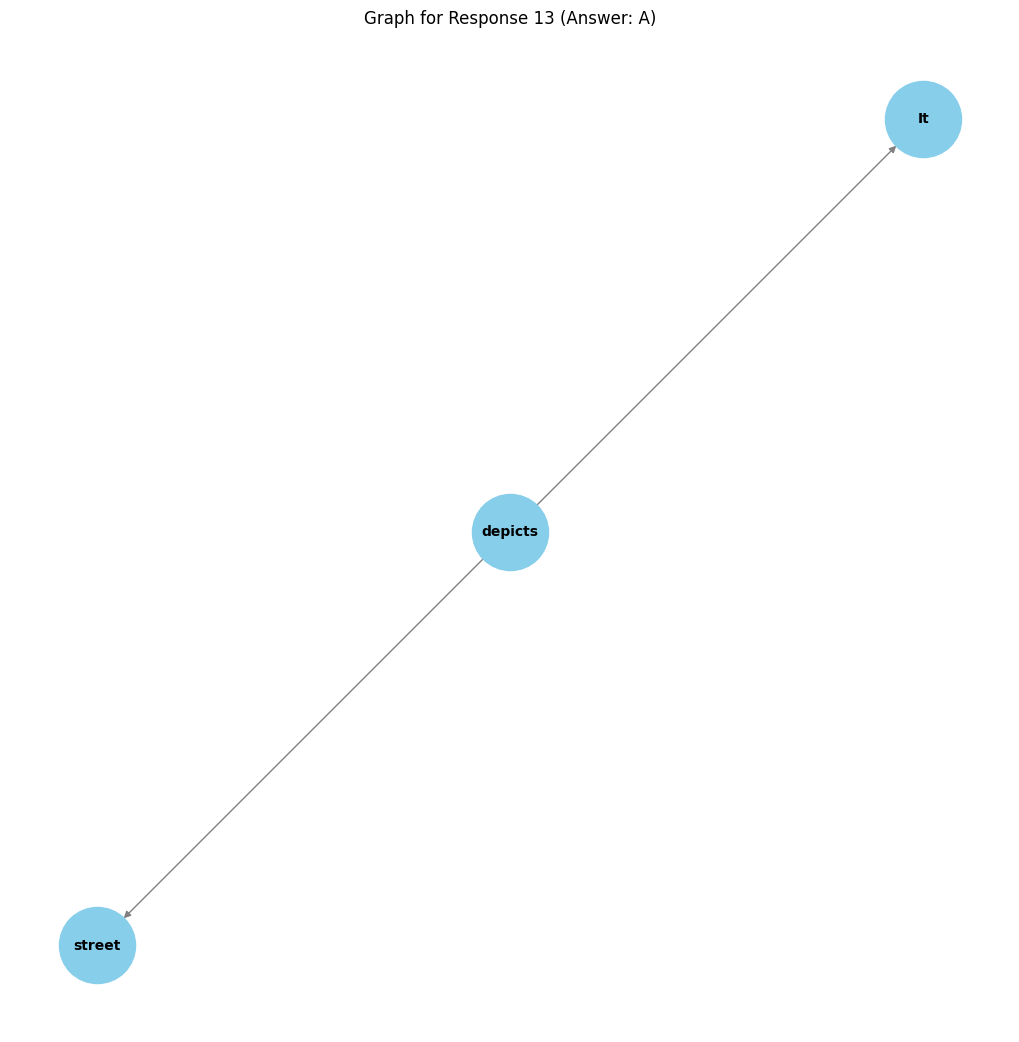

Visualizing for index: 2844
Explanation: There are two zebras in the image. They are grazing in a zoo enclosure. The zebras are standing on a dirt patch with trees in the background.


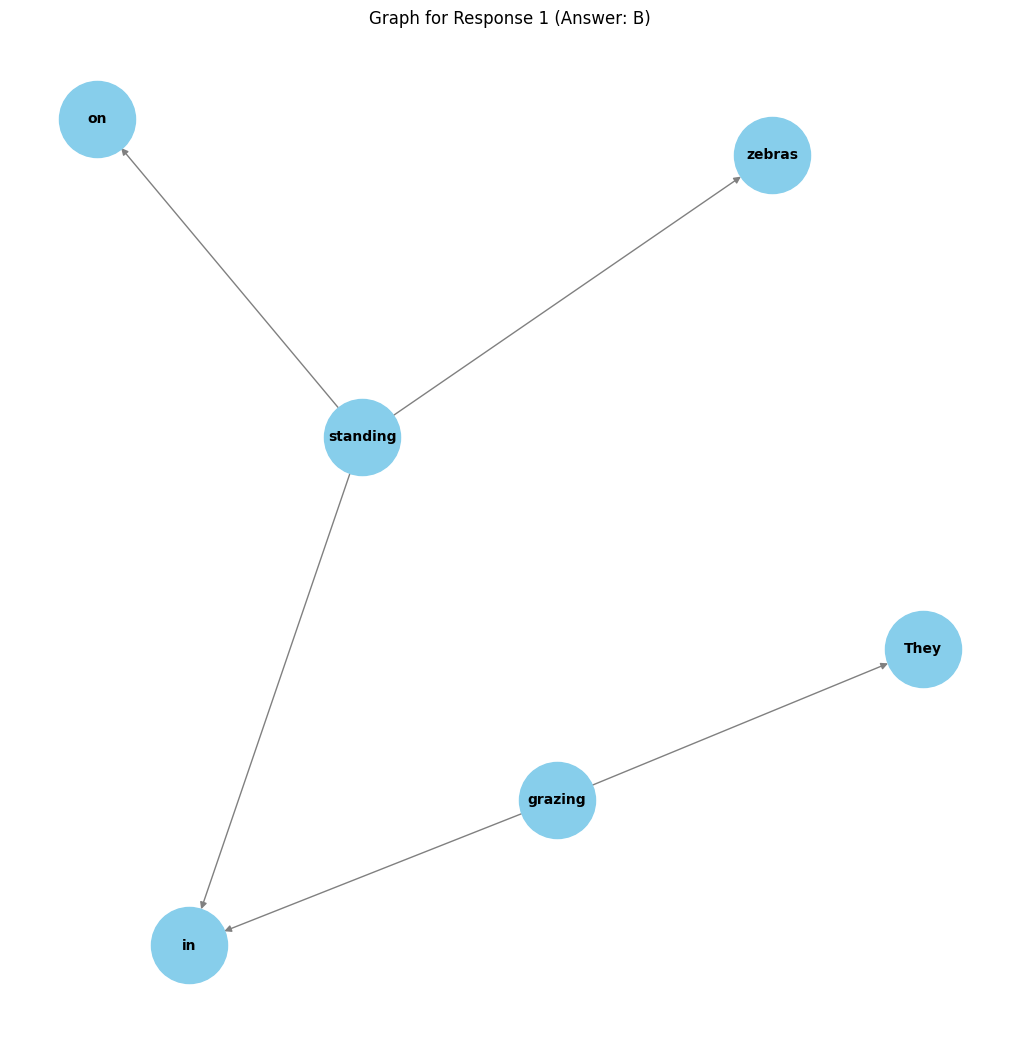

Explanation: Yes, there are two zebras in the image, eating some type of food provided by the zoo near a gate. This is not a 'nan' in the sense that it is an object, but rather it refers to the two animals being in the scene, which would be a part of the environment. Their presence does not signify an absence of an answer to the question as they are clearly part of a scene that includes both zebras and a 'nan' which is the feeding hay or food in the enclosure.


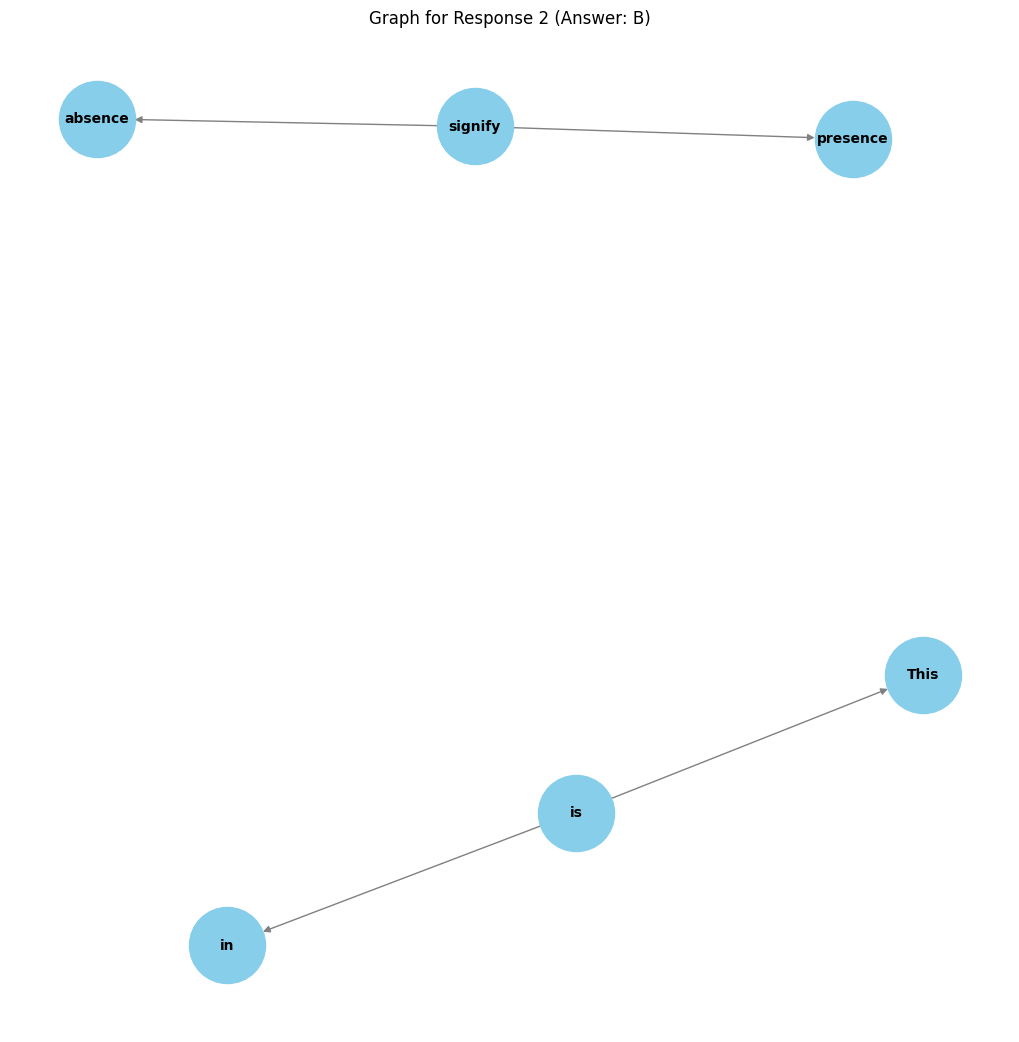

Explanation: 
Error: 'answer'
Response: {'is_image_available': True, 'questions': [{'question': 'Is there a zebra in the image?', 'answer': 'B', 'explanation': 'The image shows a couple of zebras. One zebra is in the foreground, and the other is slightly behind, but both are clearly visible. There are no other animals such as goats in the image.', 'confidence': 1}], 'graph': {'zebras': {}, 'the image': {}, 'A pair': {}, 'a zoo enclosure': {}, 'grazing': {'pair': {}, 'in': {}}, 'pair': {}, 'in': {}}}
Explanation: Yes, there are zebras in the image. A pair of zebras is grazing together in a zoo enclosure.


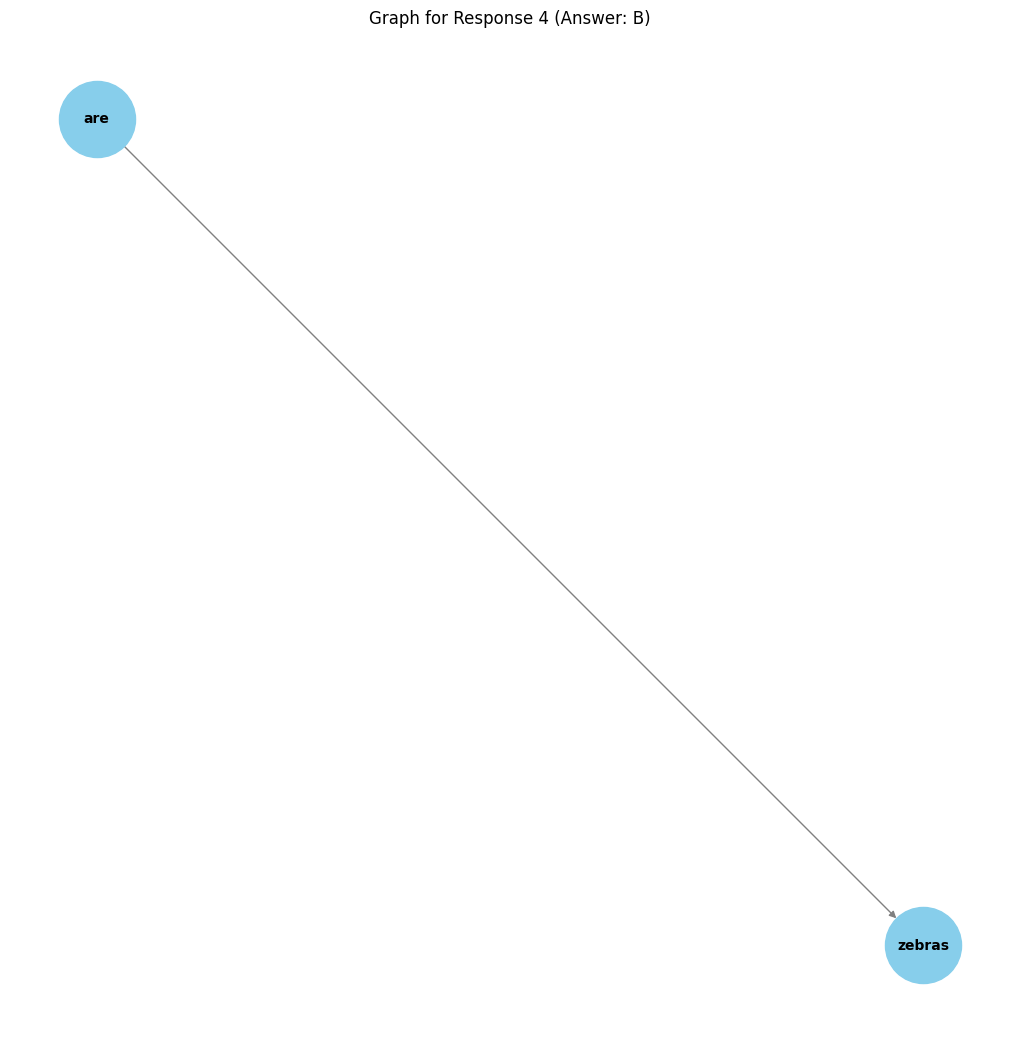

Explanation: Yes, there are zebras in the image. Two zebras are visible grazing in the barren field with a fence behind them.


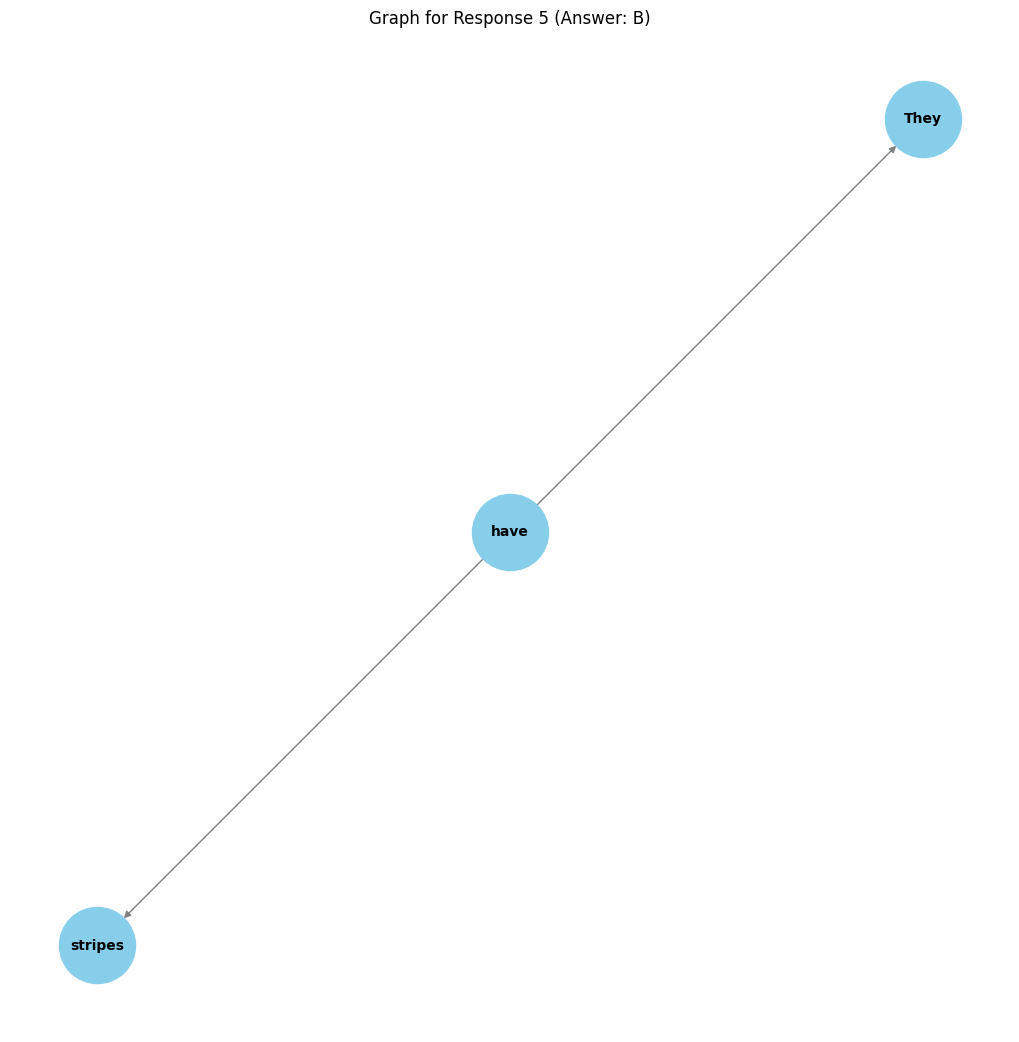

Explanation: Yes, there is a zebra in the image. There are three zebras eating grass in a field. They have distinct white and black stripes and appear to be eating from a ground feed trough.


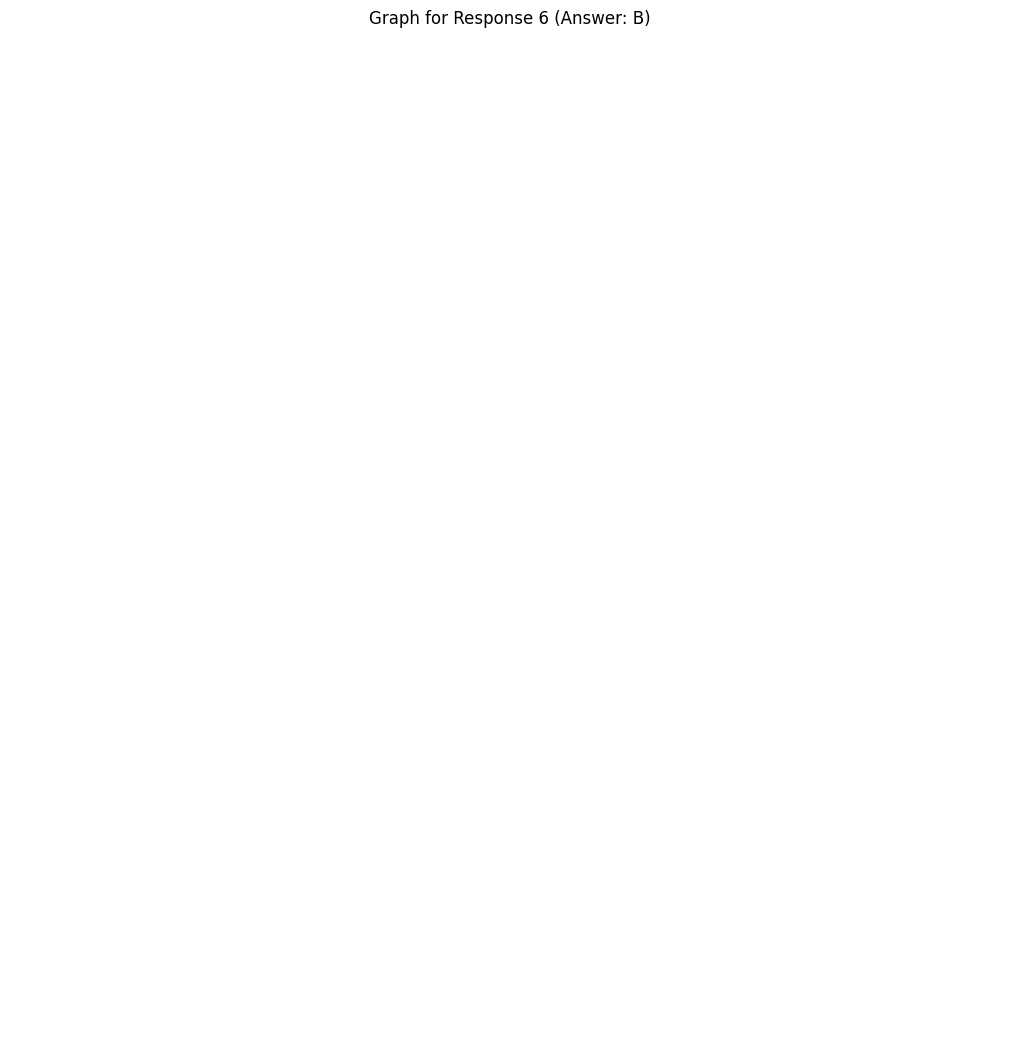

Explanation: There are two zebras in the image, actively grazing in a zoo enclosure. Both the zebras are captured and seem to be in a safe environment.


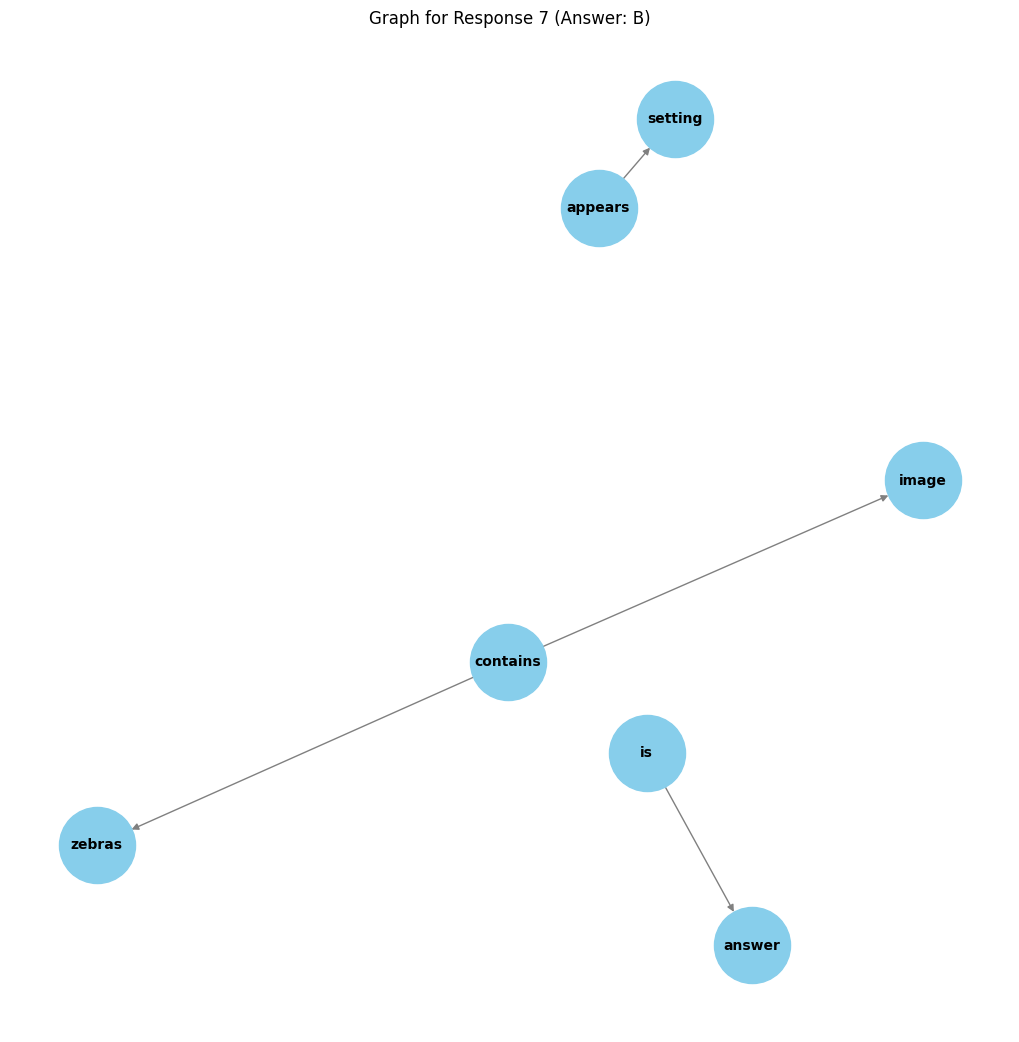

Explanation: The image contains three zebras - one zebra is standing to the left and is eating with its head to the ground, and a second zebra is standing in the rear-left position. There is a third zebra in the background. There are no animals like goats, sheep, or animals with horns. The setting appears to be a dirt field within a fenced area, with a tree trunk and a wooden fence. Consequently, the answer is 'B'


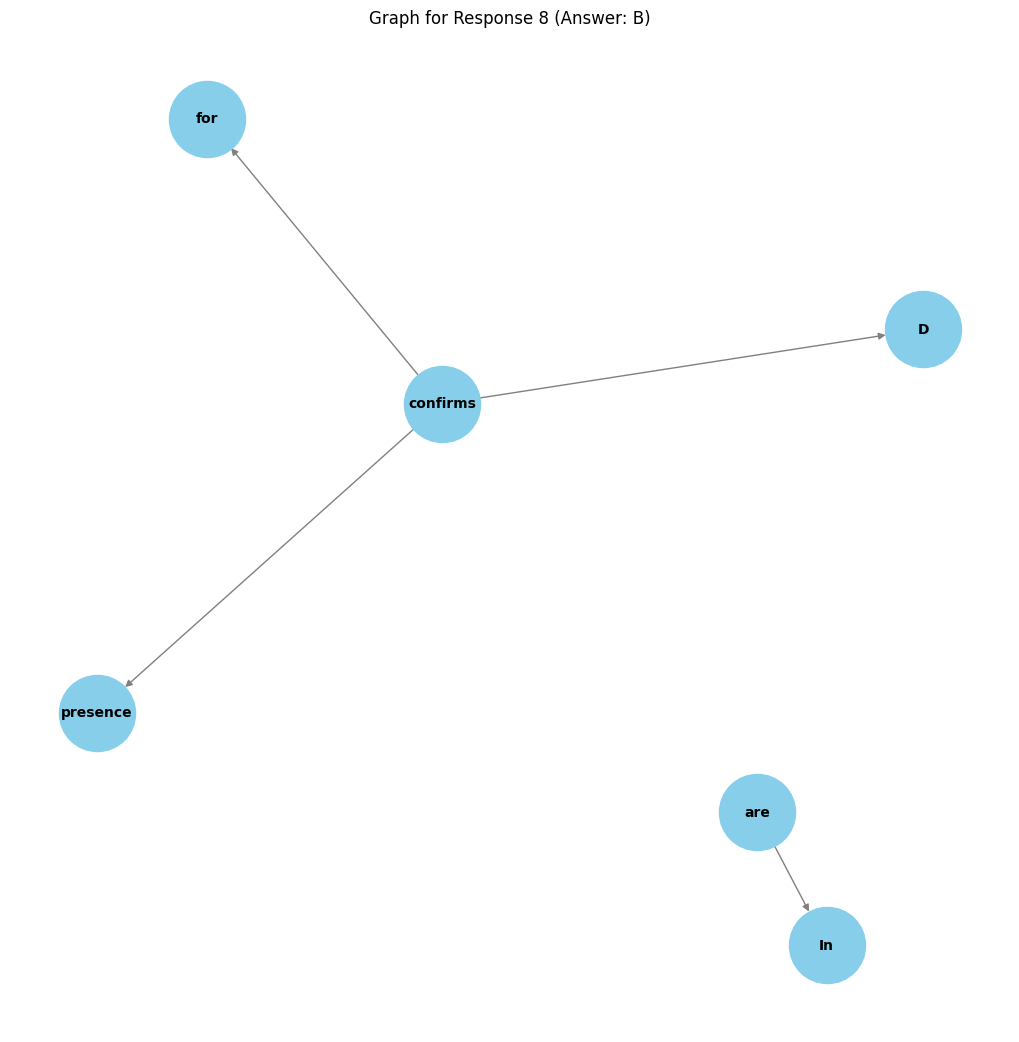

Explanation: In the image, there are indeed two zebras standing in an enclosure next to a trunk of trees. The presence of the zebras confirms option D for the answer, and the description of the image does not provide any indication that zebras are not present, so no other option matches the statement.
Error: 'answer'
Response: {'question': 'Is there a zebra in the image?', 'answers': [['B', 'Yes'], ['A', 'No'], ['C', 'No'], ['D', 'Yes'], ['E', 'Yes'], ['F', 'No']], 'explanation': 'In the image, there are indeed two zebras standing in an enclosure next to a trunk of trees. The presence of the zebras confirms option D for the answer, and the description of the image does not provide any indication that zebras are not present, so no other option matches the statement.', 'confidence': 1, 'graph': {'Africa': {}, 'are': {'Zebras': {}, 'They': {}, 'behind': {}}, 'Zebras': {}, 'known': {'for': {}}, 'for': {}, 'seen': {'In': {}}, 'In': {}, 'They': {}, 'behind': {}}}
Explanation: There is a zebr

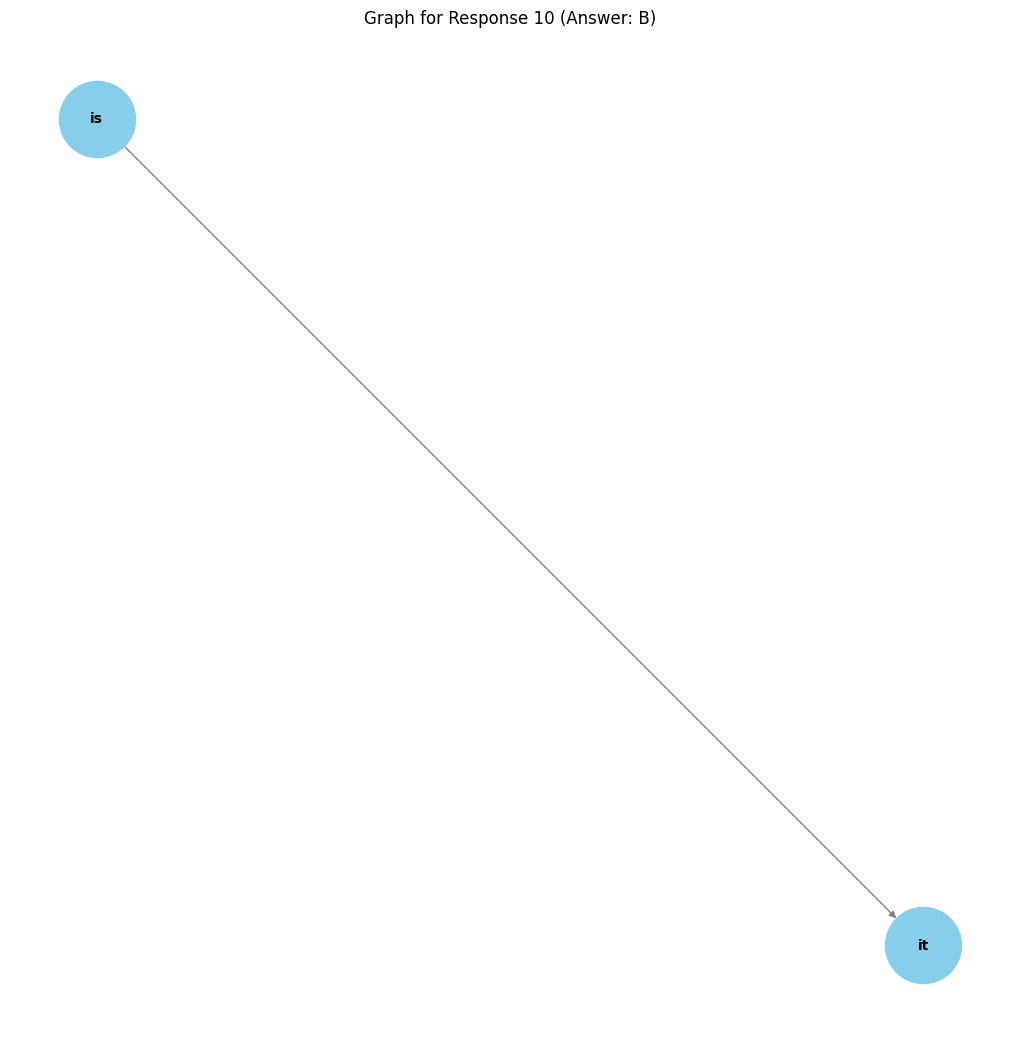

Explanation: Yes, there is a zebra in the image. There are two zebras visible in the photo. Additionally, the photo shows a baboon in the background, suggesting that this might be a part of a wildlife reserve or a zoo, but zebras and baboons are native to the same regions, so it is consistent that a zebra is present.


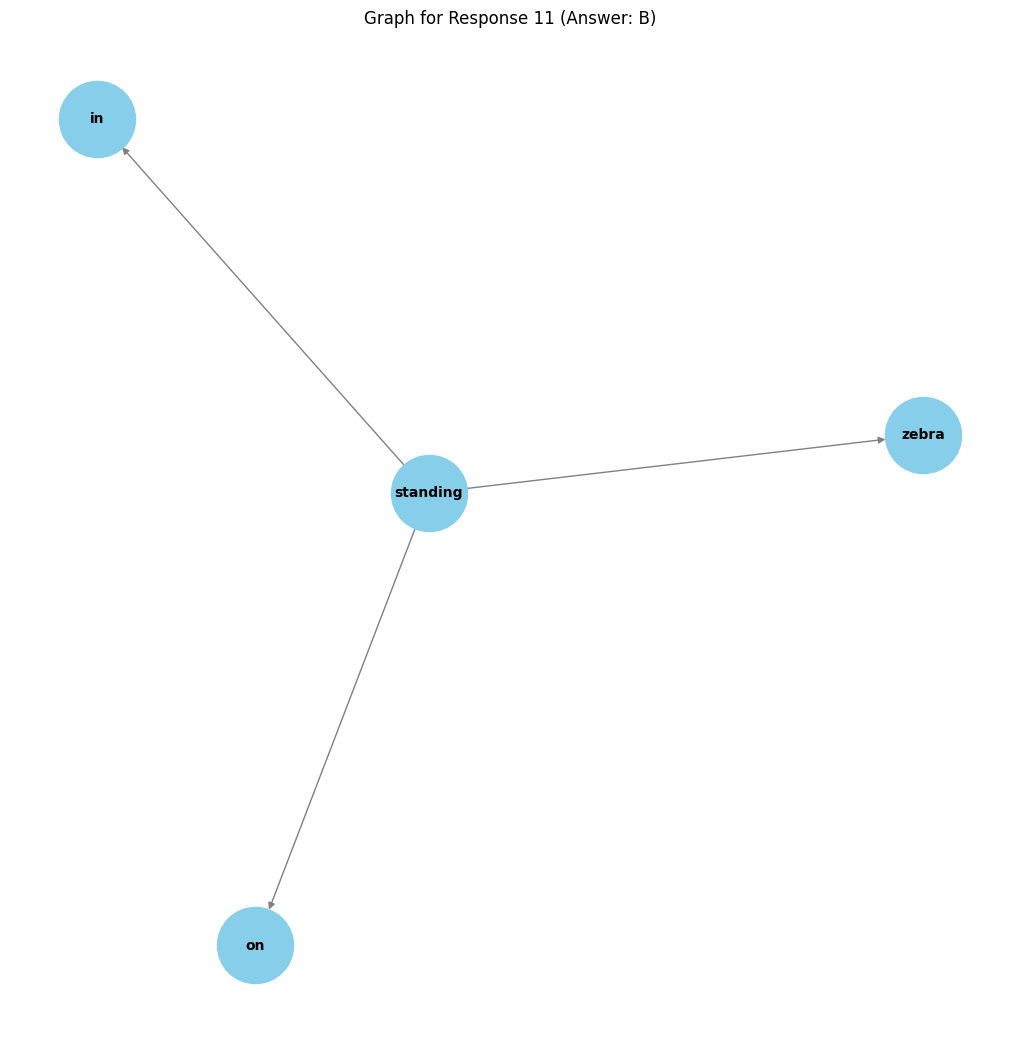

Explanation: Yes, there is a zebra in the image. The zebra is standing on the ground in an enclosure with another zebra in the background and a fence nearby.


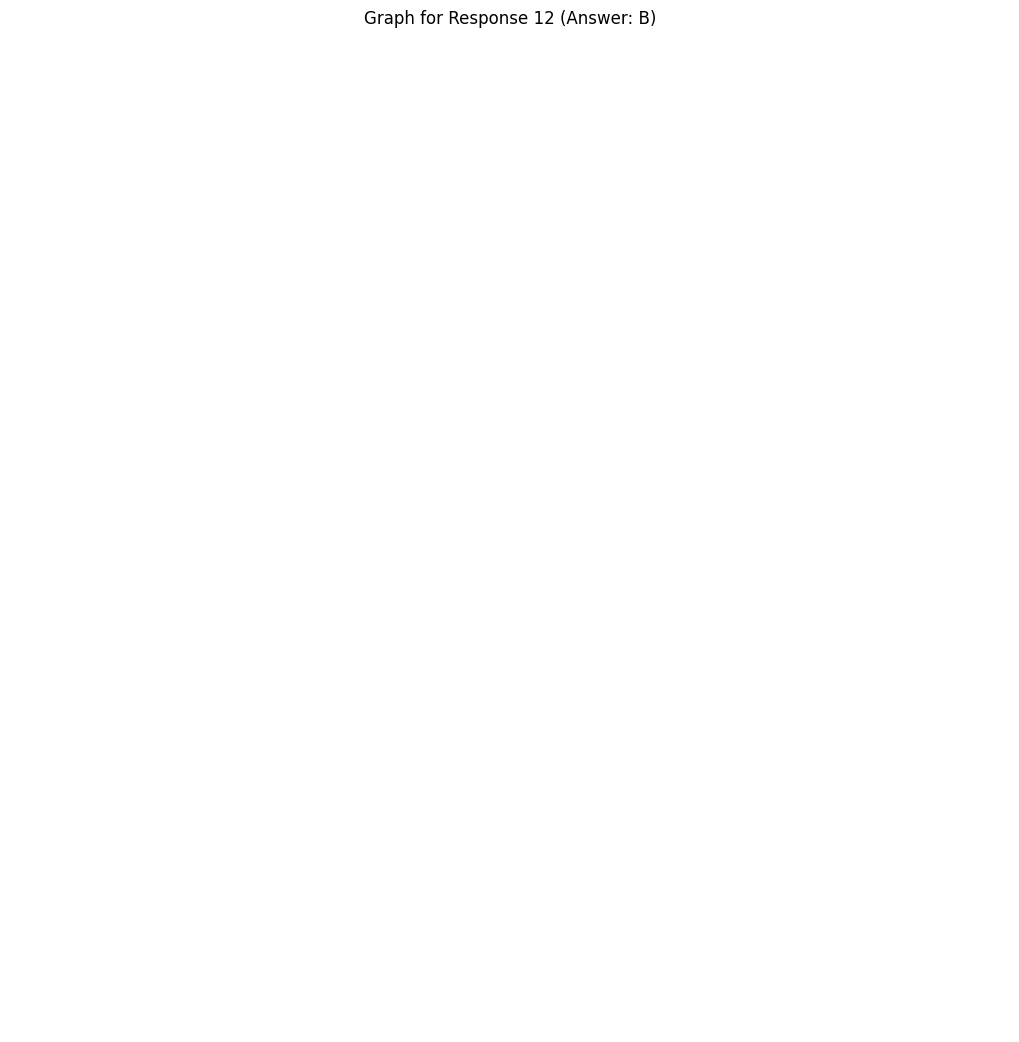

Visualizing for index: 2851
Explanation: It may not be obvious, but given the context of the image which shows people skiing, the word 'on' makes sense in relation to 'the snow.' The right translation of the word 'on' in the context of this image would be 'the snow is on the people,' as the people are riding down the snow-covered slopes on their skis. Option B would be a sentence fragment, as 'the people' cannot be the direct object of the verb 'is on.' Option C is not appropriate since the subject 'the snow' is singular, not a group of people. Option D is not correct, as 'on' usually means 'atop' rather than 'inside,' which doesn't apply here since it doesn't make sense referring to the context of people on skis. Thus, 'A' is the most likely option from the given choices.


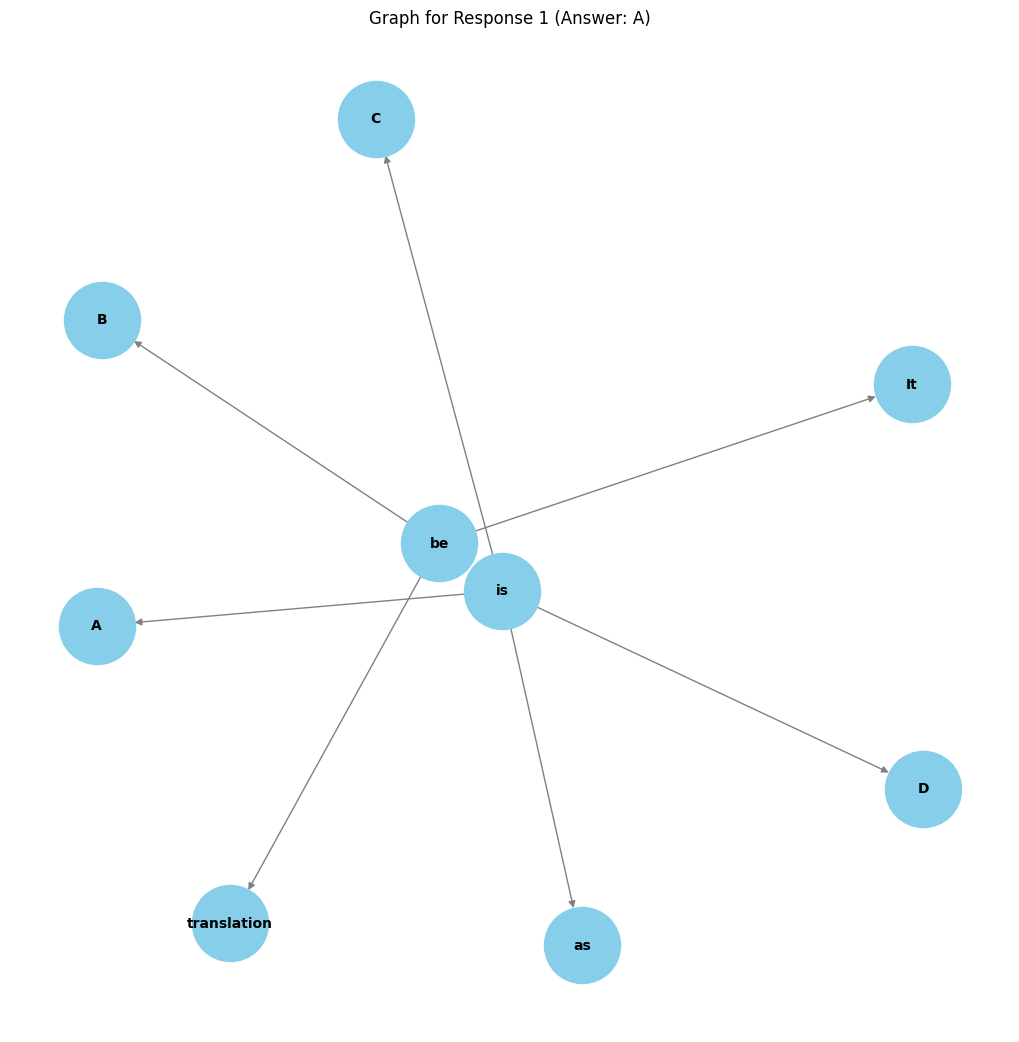

Explanation: The correct caption is 'the snow is on the surface,' as there is a tunnel in the image and it makes more sense that way. The phrase 'on the people' would not apply here since they are going through a tunnel and the focus is on the environment rather than their clothing or themselves in this context.


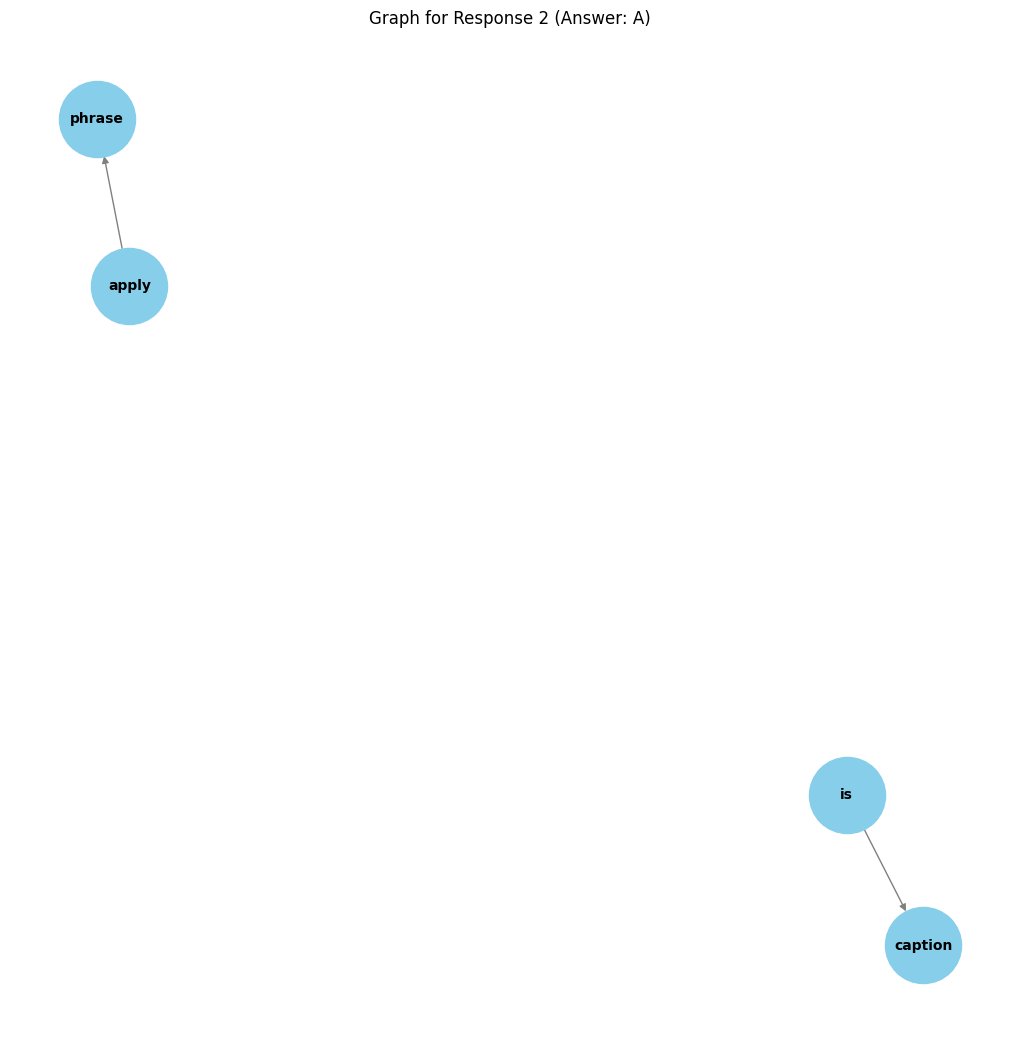

Explanation: The snowy environment and the fact that people are engaged in winter sports like skiing and snowboarding indicate that the 'on' relationship holds true for the snow. It's a typical scene at a ski resort or snow park where snow is the natural setting and not in the context of a person, so option A is the most relevant caption in this context. Option B is incorrect because people are not inanimate objects to be 'on' in the context of a location.


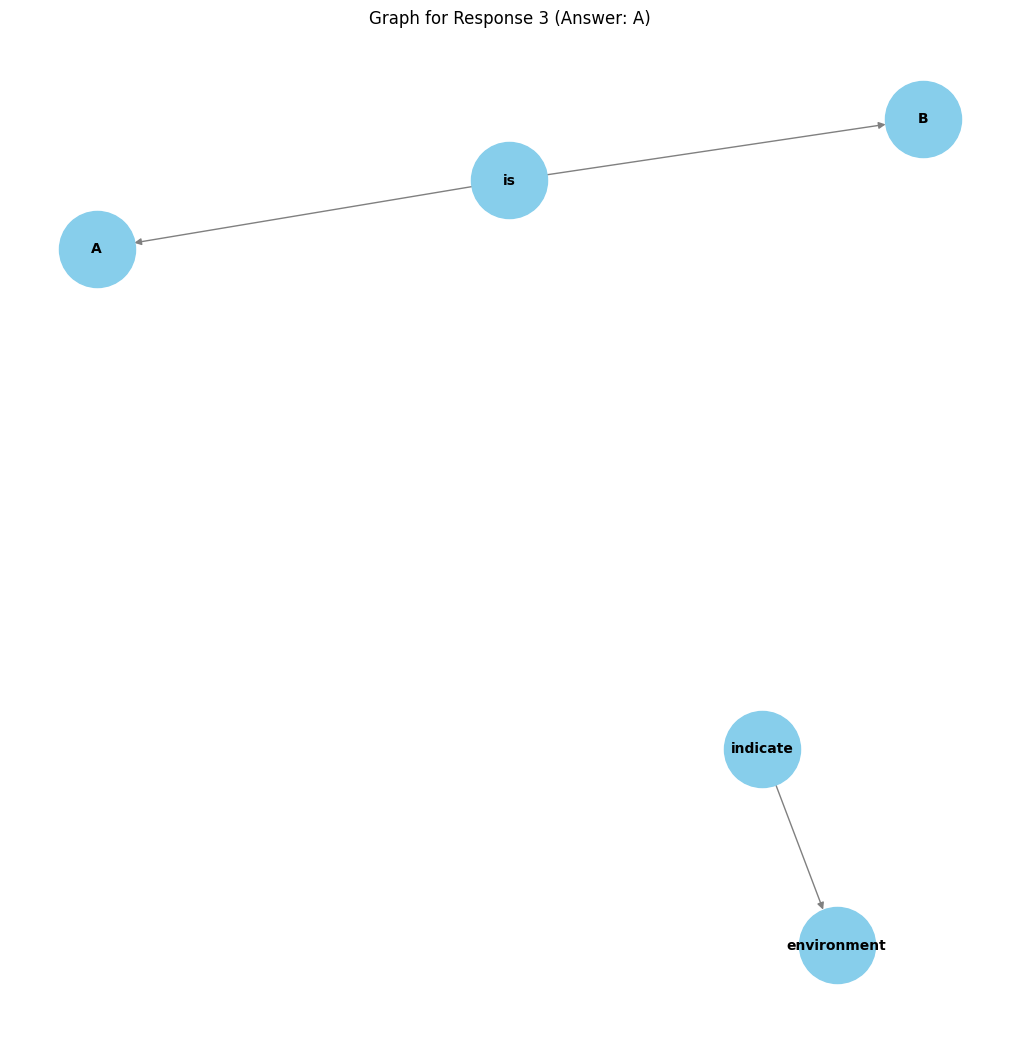

Explanation: The snow is on the snow


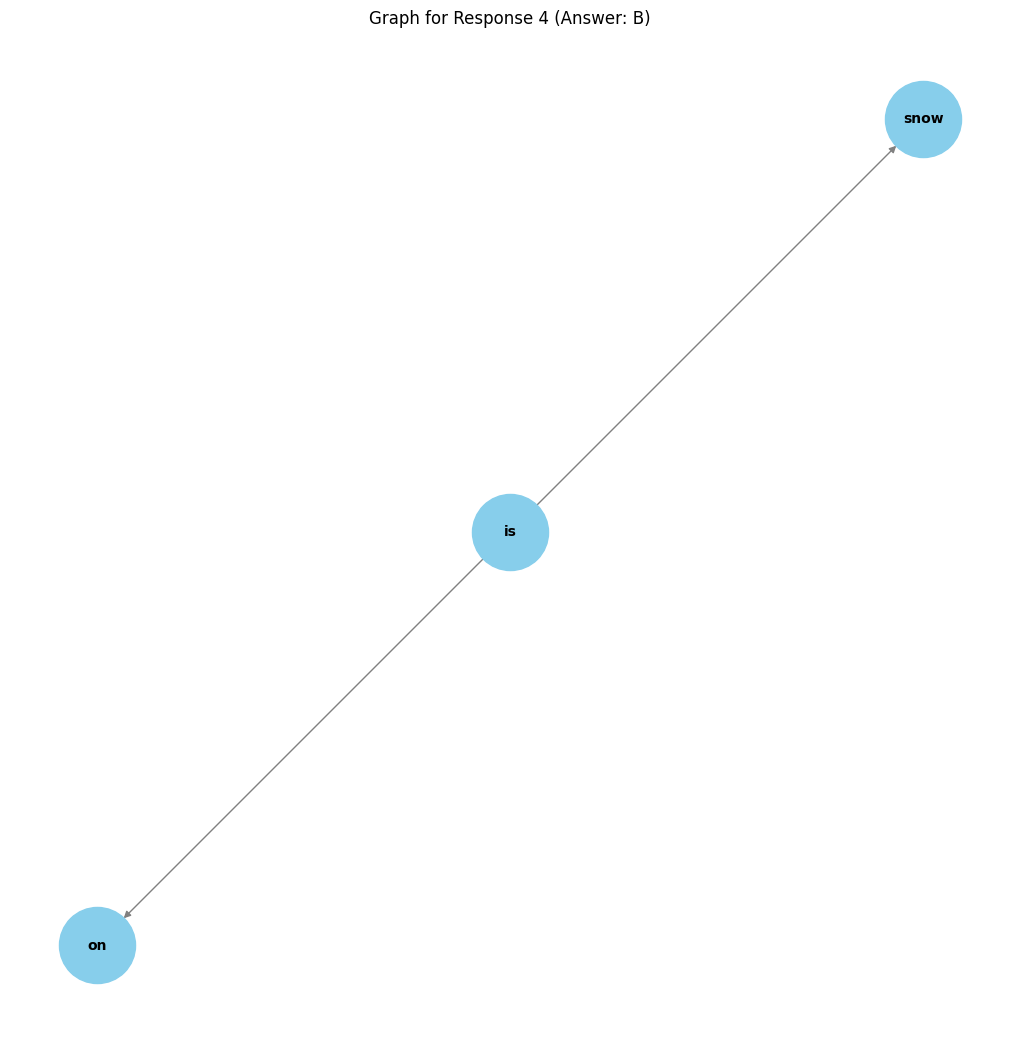

Explanation: In the given image, there are people standing on a snow slope. There are at least 13 people depicted who are on skis or snowboards. All of them are in a state of motion, either falling or gliding down the slope. The phrase 'on the snow' is directly relating to the people and their actions in the image. Option B indicates that the people are indeed on the snow. The other options given in the captions are not supported by the image.


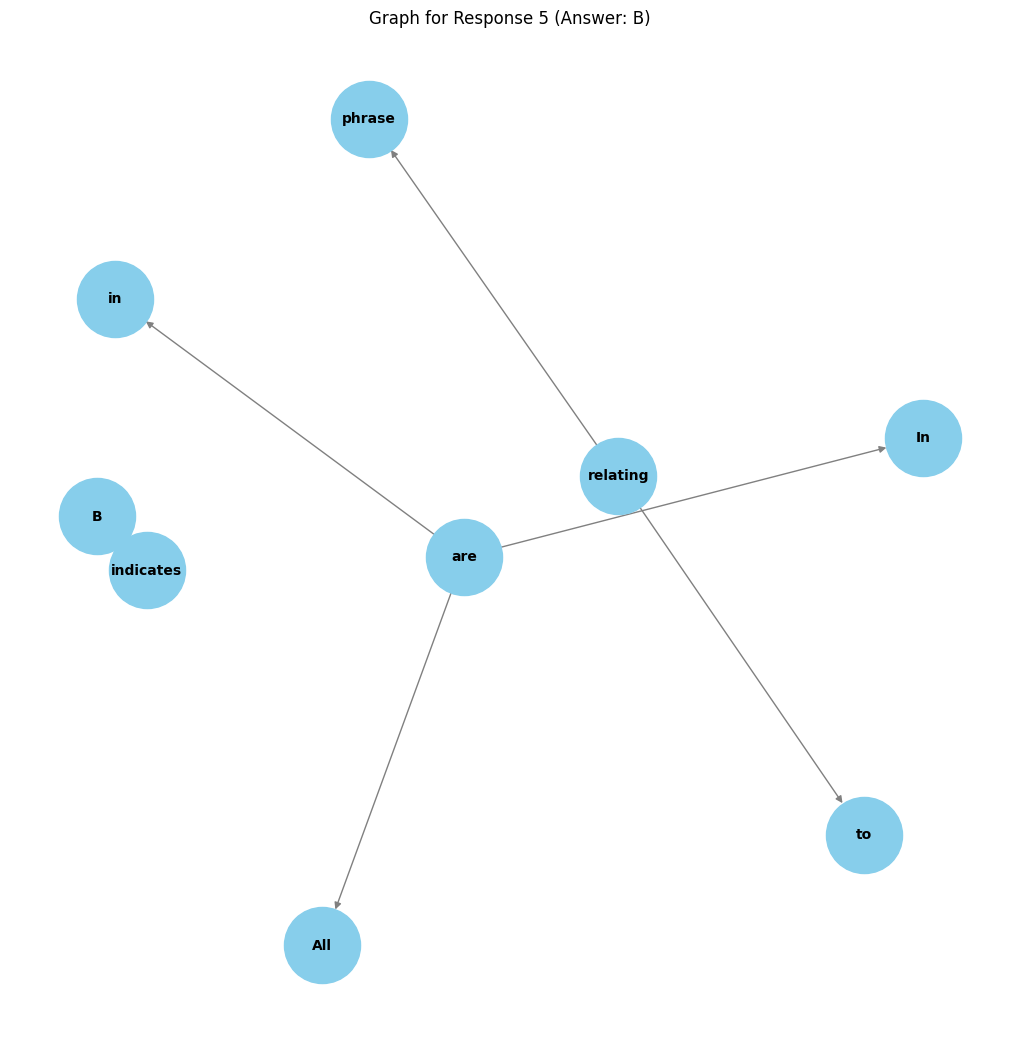

Explanation: In the image provided, we can see a snowy hillside with people on skis. The people are not on the snow; they are riding on the skis, which suggests that the skis are on the snow. The snow is not on the skis, as skis are typically made of materials that do not allow snow to stick to them. Therefore, the correct answer is 'A' ' the snow is on the people.'


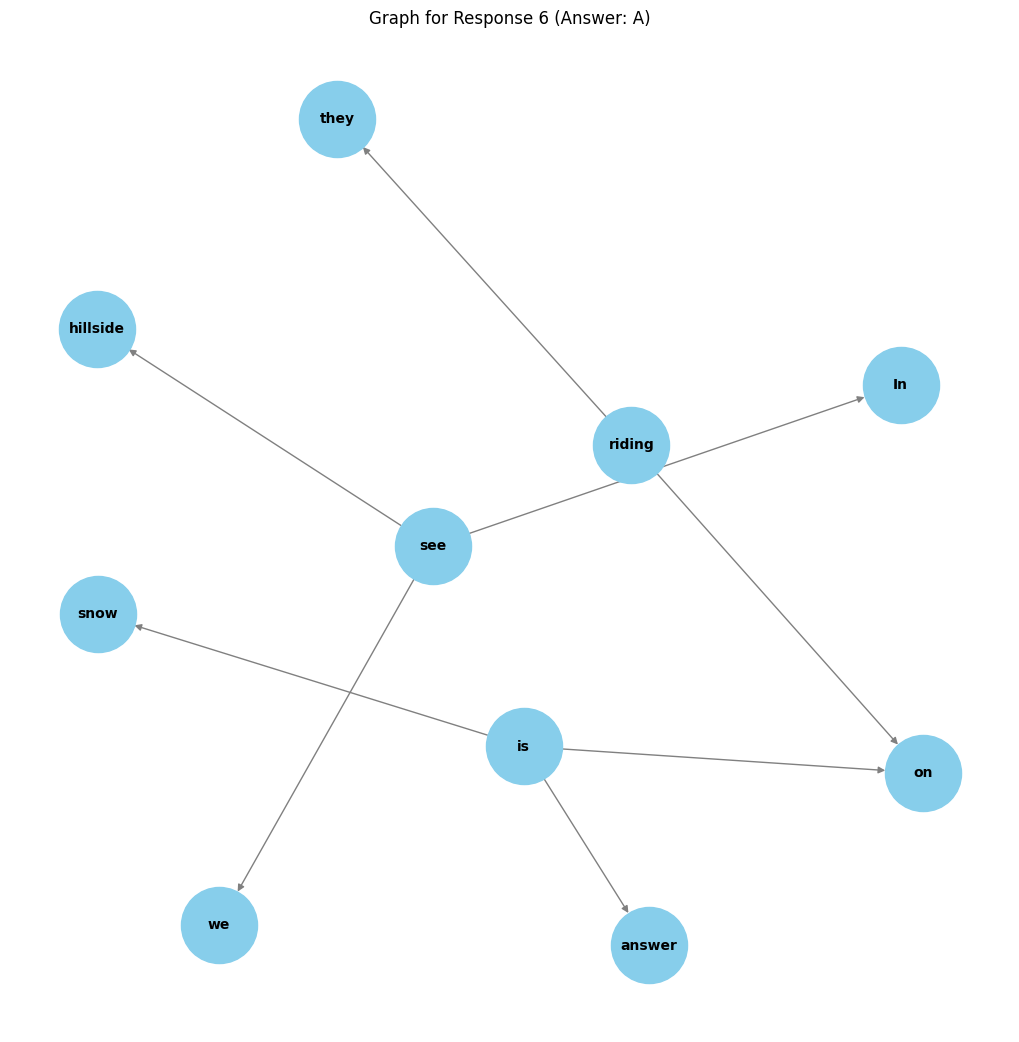

Explanation: In the given captions, 'on' generally refers to adornment or presence. In this context, the correct caption is 'the people are on the snow', as there is a group of people skiing, which indicates they are either equipped with or actively using the snow as their medium. The other options are not consistent with the correct use of 'on' in the context of this image.


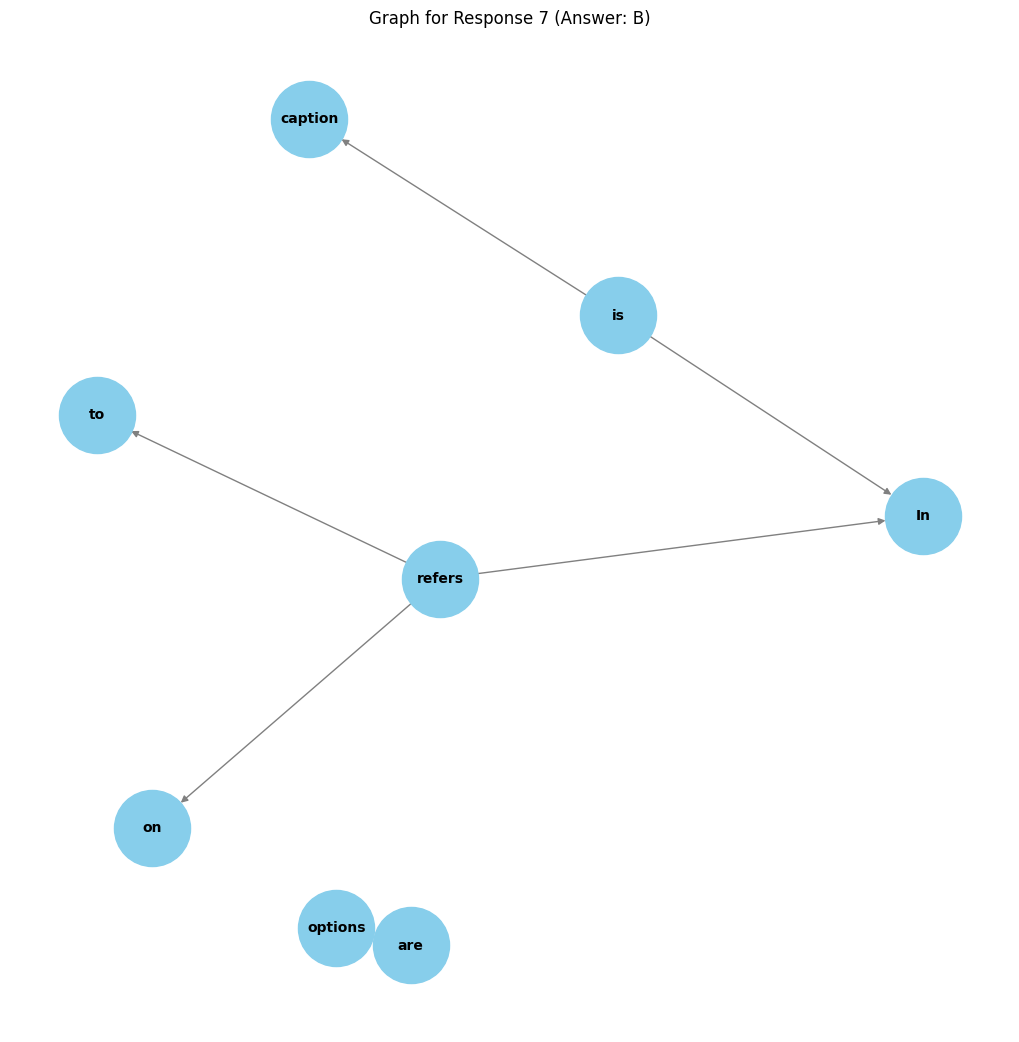

Explanation: The correct relation 'on' applies to both the people and the snow. In this context, the people are standing on the snow, engaged in snowboarding activity. This is the most consistent with the given image.


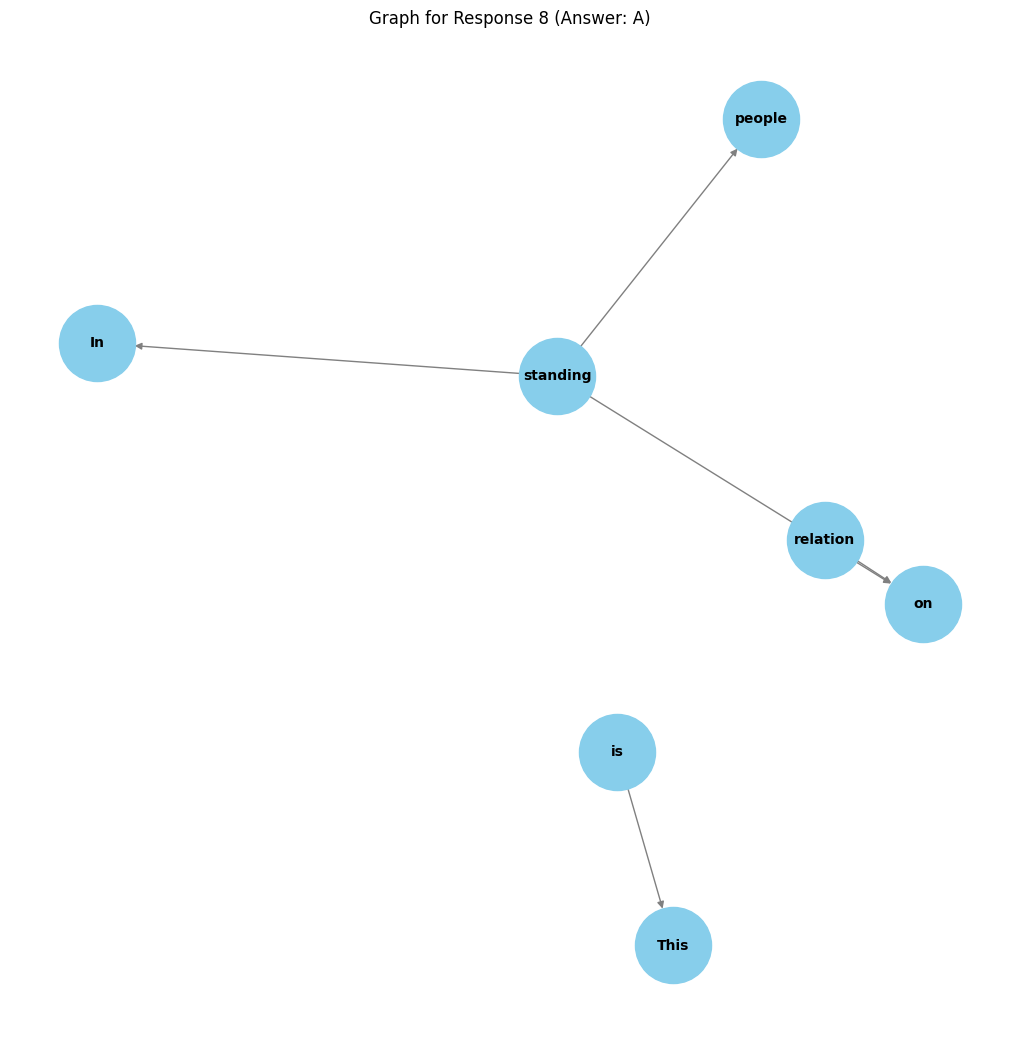

Explanation: The people are on top of the snow, and that is likely what the term 'on' in the context of an image means, i.e., the people are engaging in winter sports, likely snowboarding and skiing, as evidenced by their snow gear and the fact that they are going through a tunnel to reach a snow-covered area where they can participate. The image depicts an active and vibrant scene related to snow sports, which aligns with the correct caption 'on'.


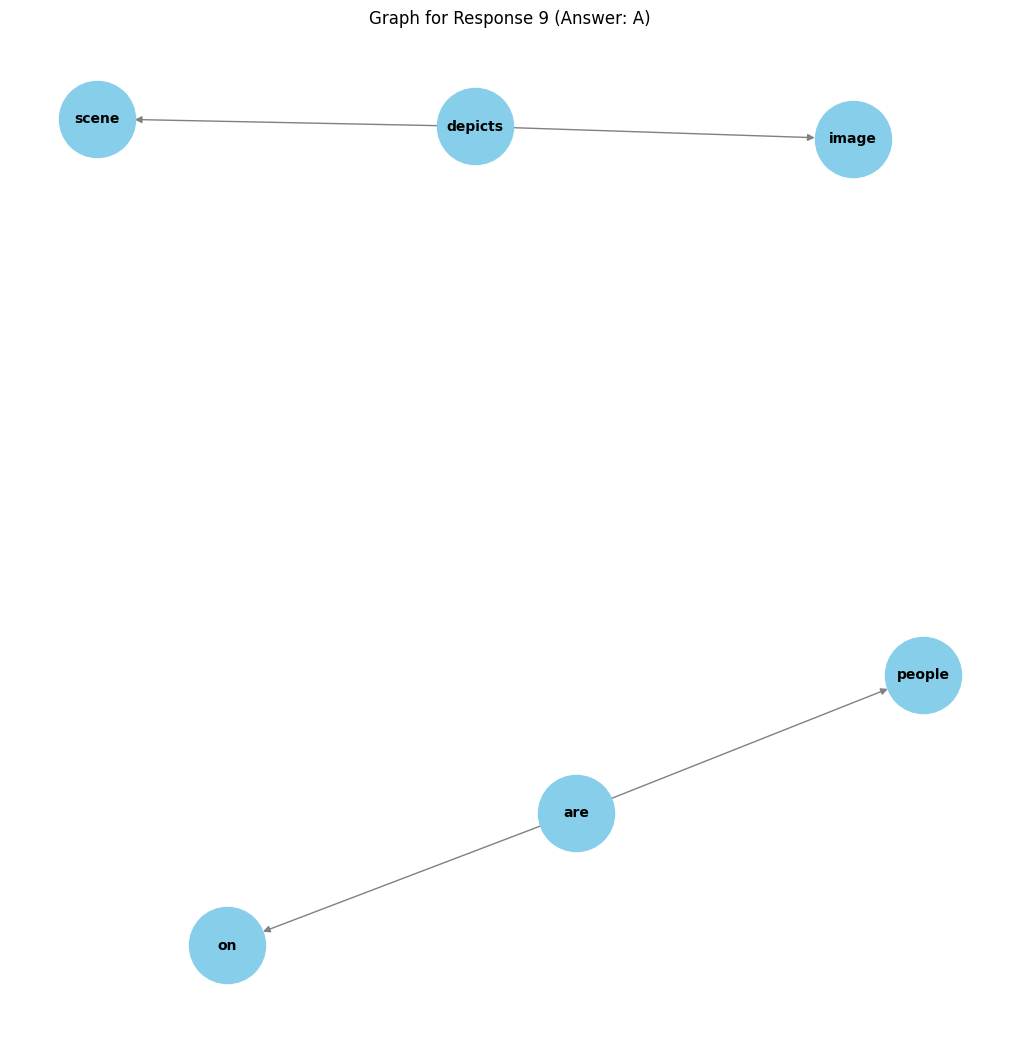

Visualizing for index: 2833
Explanation: Yes, there is a decorative glass vase in the image.


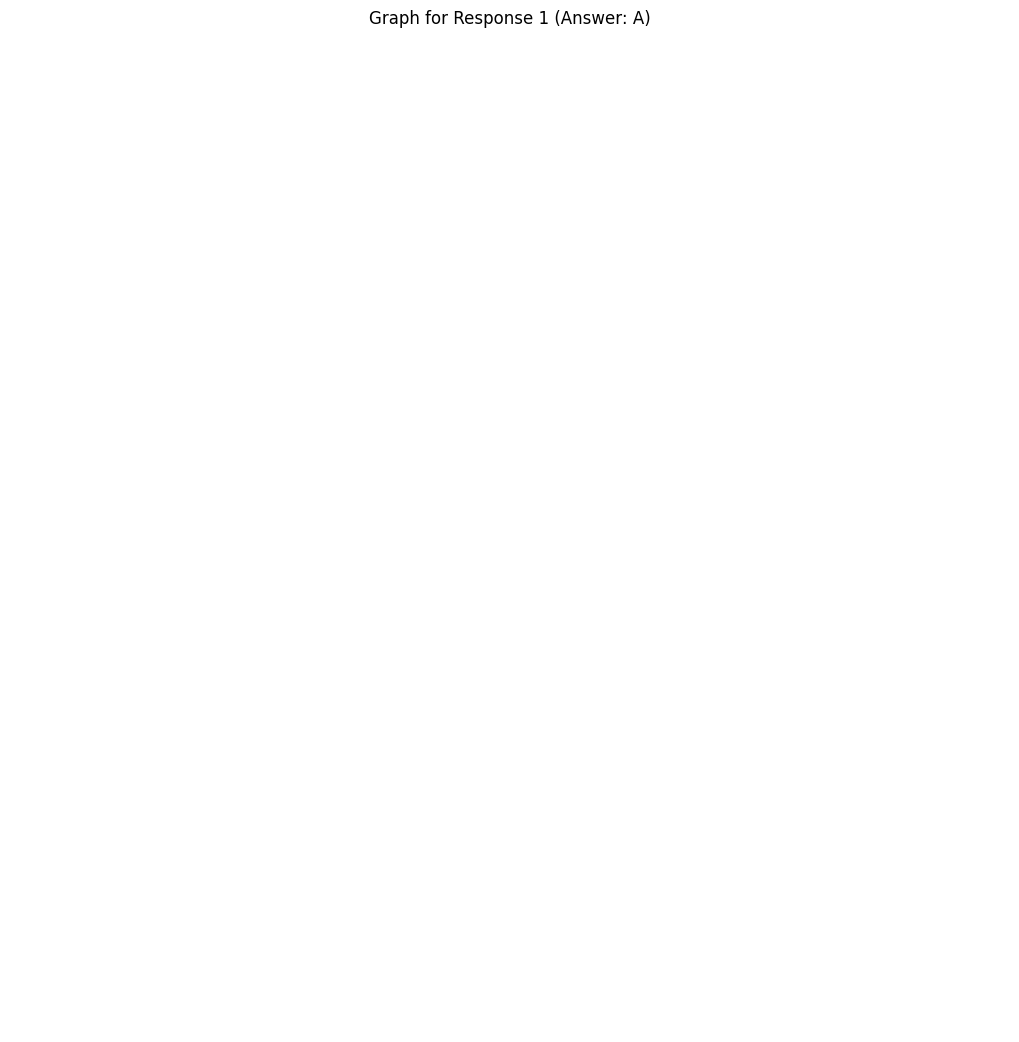

Explanation: There is a vase holding the flower in the image. Typically, a vase is defined as a container used to hold a stemmed plant, and in this case, it is serving that purpose. The vase appears to be made of glass or a similar medium, as indicated by its color and shape. It is placed on a table, further confirming its function as a home decoration piece.


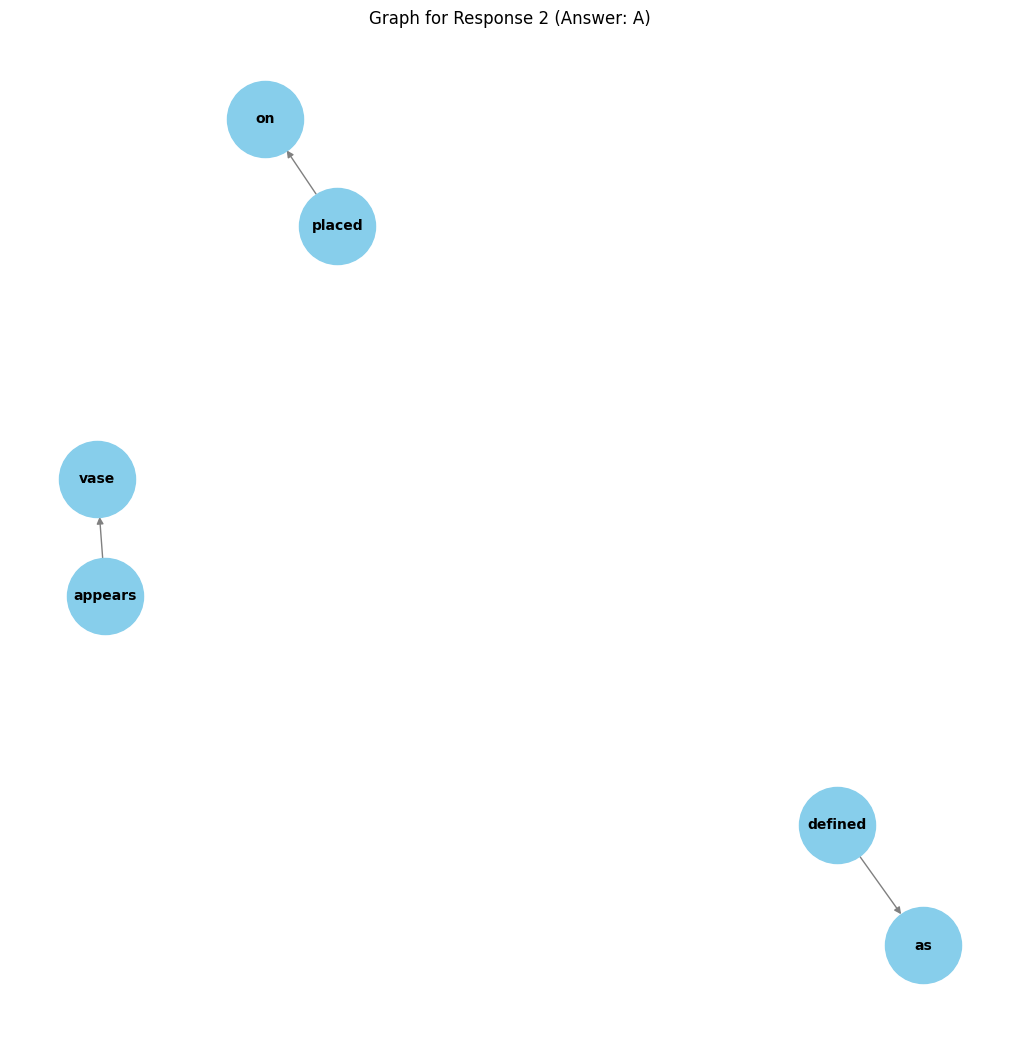

Explanation: Yes, there is a glass vase in the image. It contains a red flower and is placed on a tabletop.


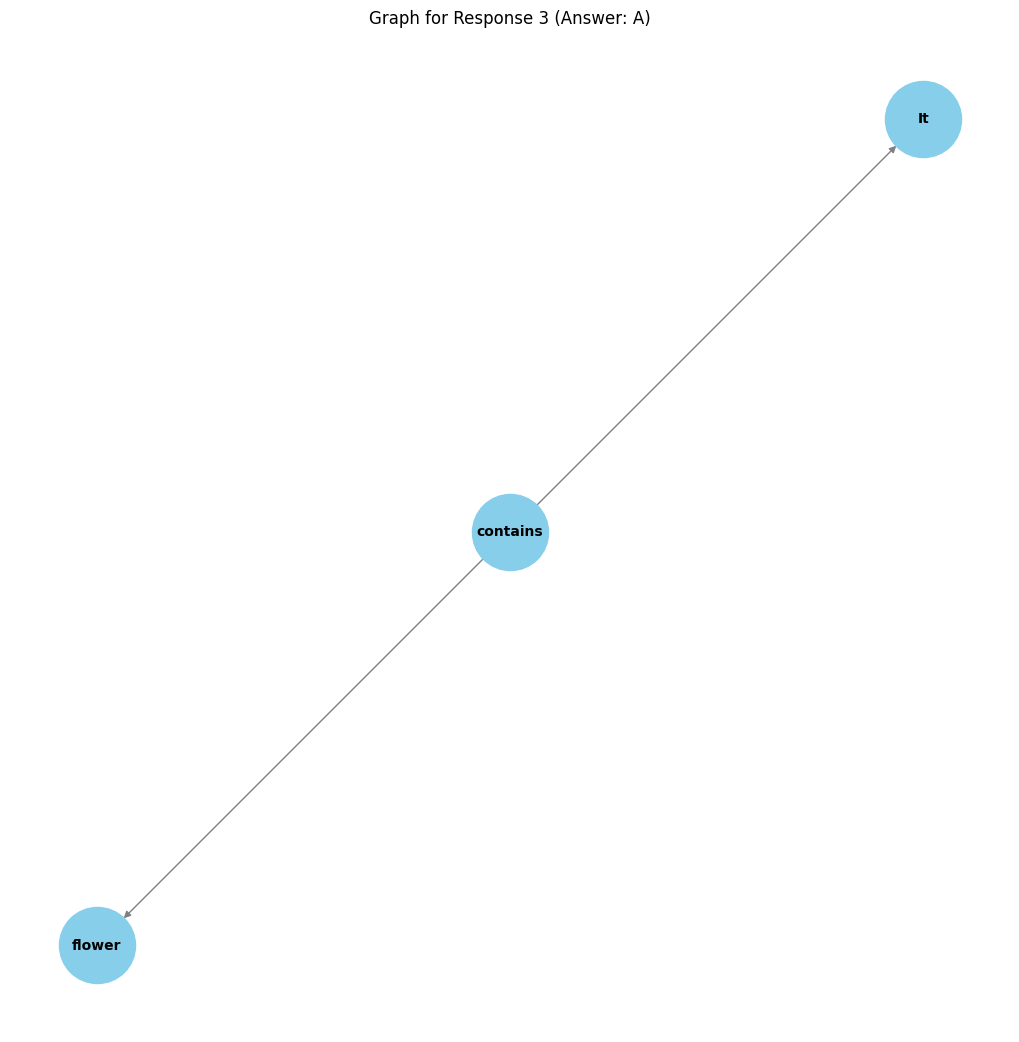

Explanation: There is a vase containing a flower in the image. The vase is green and stands on a circular dark table. The flower is tall and orange in color, which also appears to be artificial.


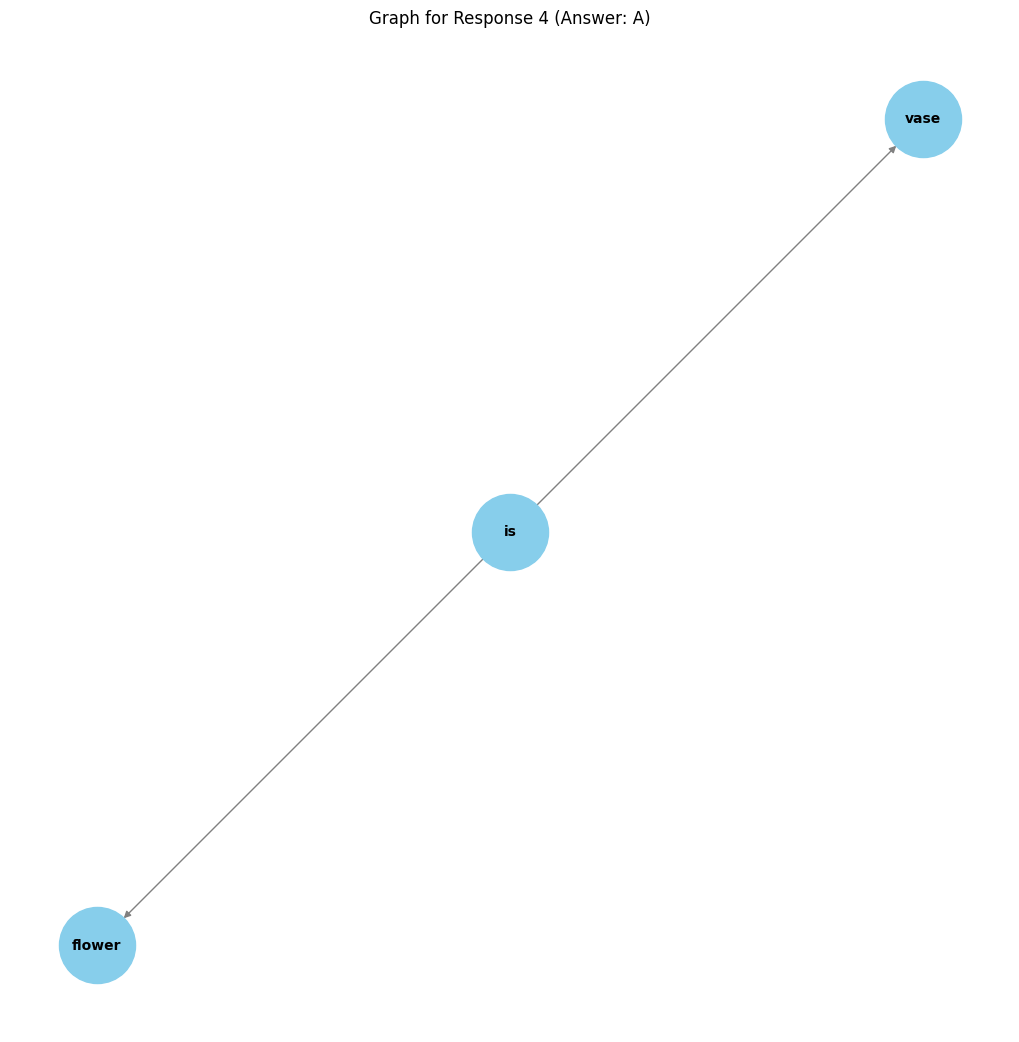

Explanation: Yes, there is a vase in the image. It is a decorative green glass or glass bottle containing an orange flower (which could be a banana leaf).


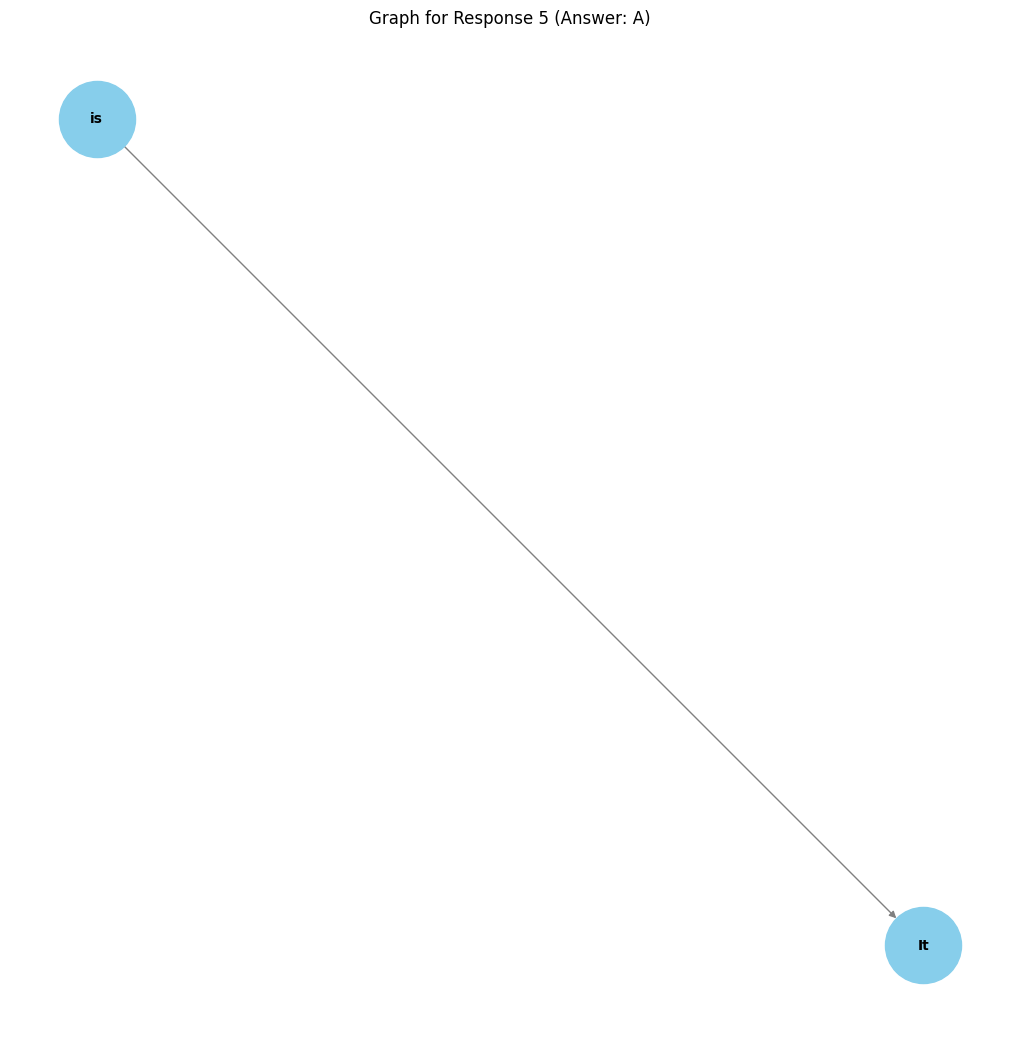

Explanation: There is a vase in the image, it is a green glass vase that is holding a flower, which is an orchid with some red petals. The flower is sitting on a table, and the vase appears to be a reused glass bottle with decorative pieces on the front. The confidence level is high because the word 'vase' is used to describe the green glass container holding the orchid and the flowers are clearly visible in the image.


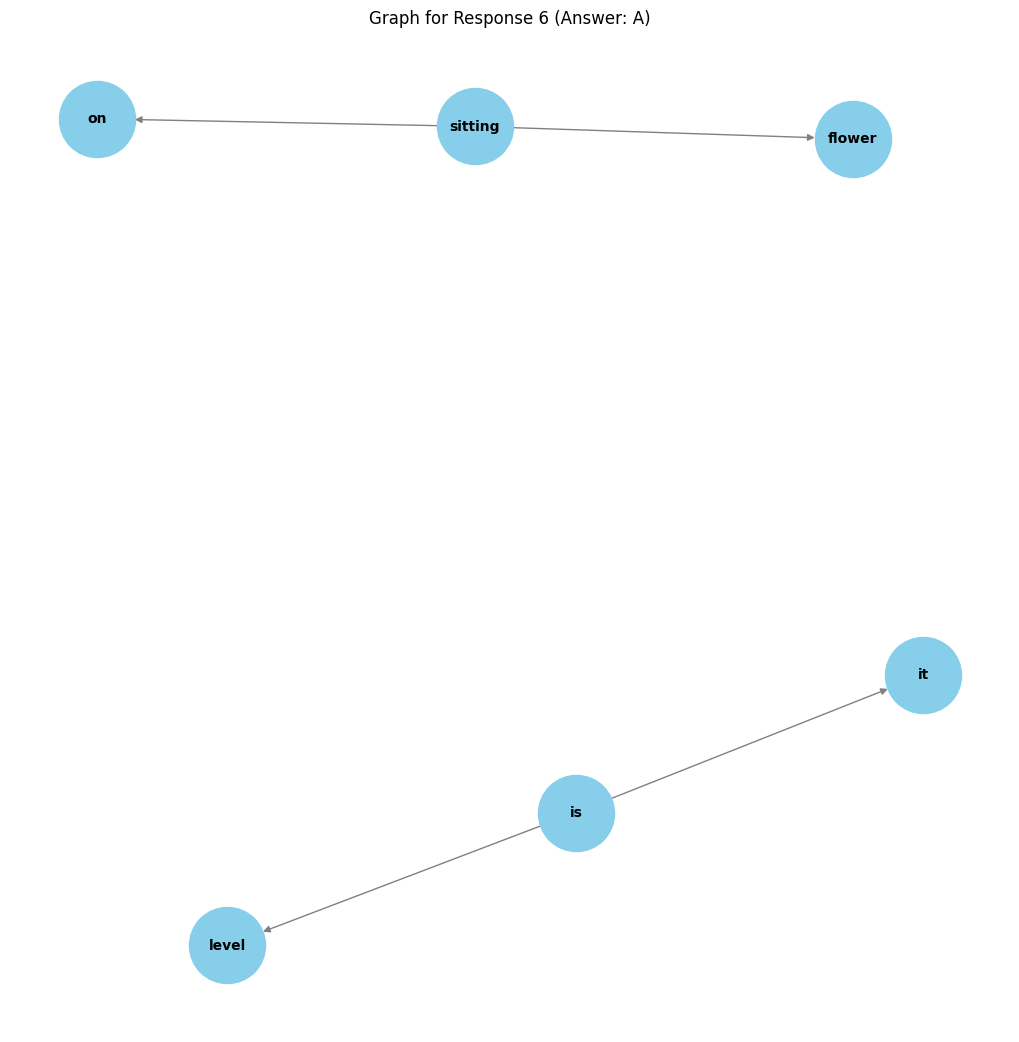

Explanation: The image displays a green glass bottle with floral designs, standing on a table with no clear vase visible. The bottle is holding a flower in it, which is typically what a vase is used for. Bottles can also have decorative elements like floral patterns but without a container that holds the plant, this object serves a different purpose. Because of the clear and unambiguous view of a flower in a glass bottle, the answer 'B' is the correct one.


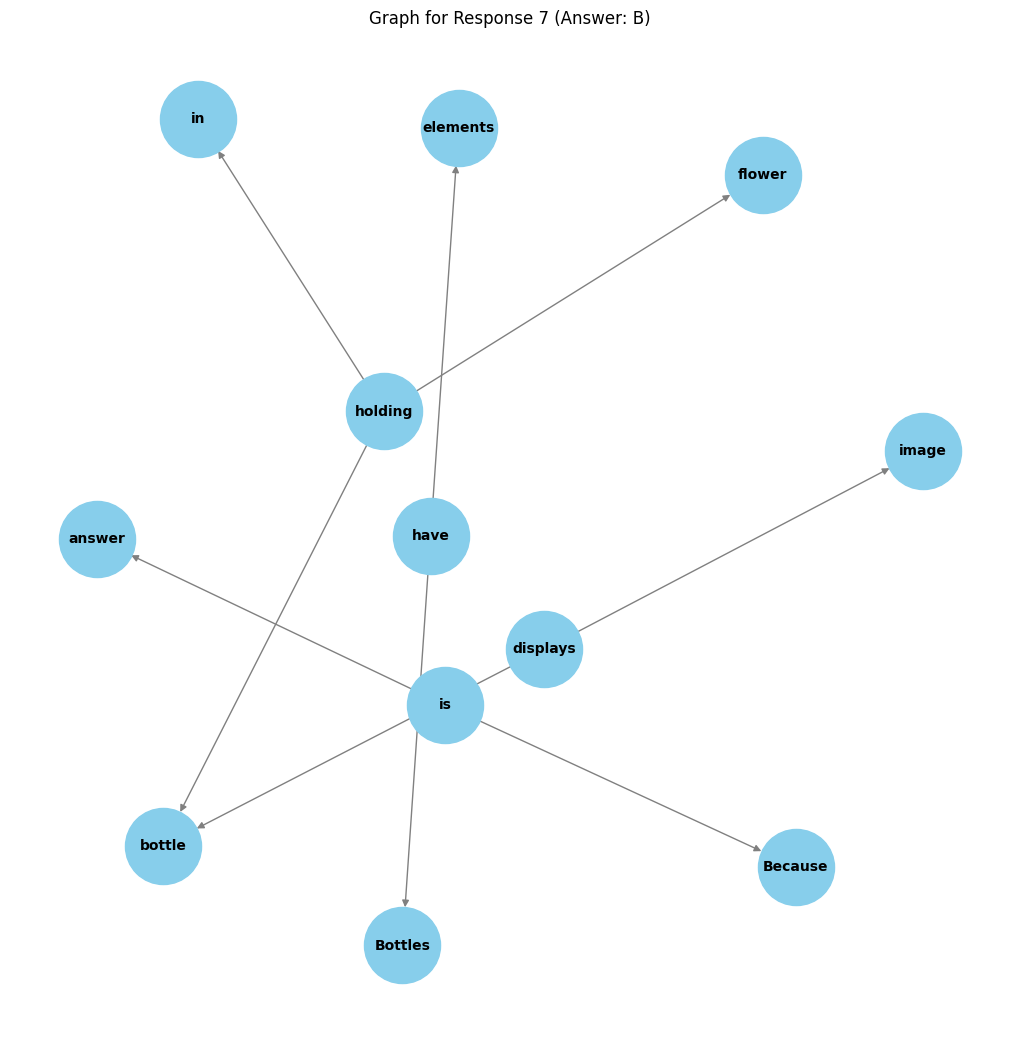

Explanation: There is a green vase in the image, which is commonly used as a vessel for flowers or decorative art. The vase is holding the red flower, thus serving the purpose of a traditional vase.


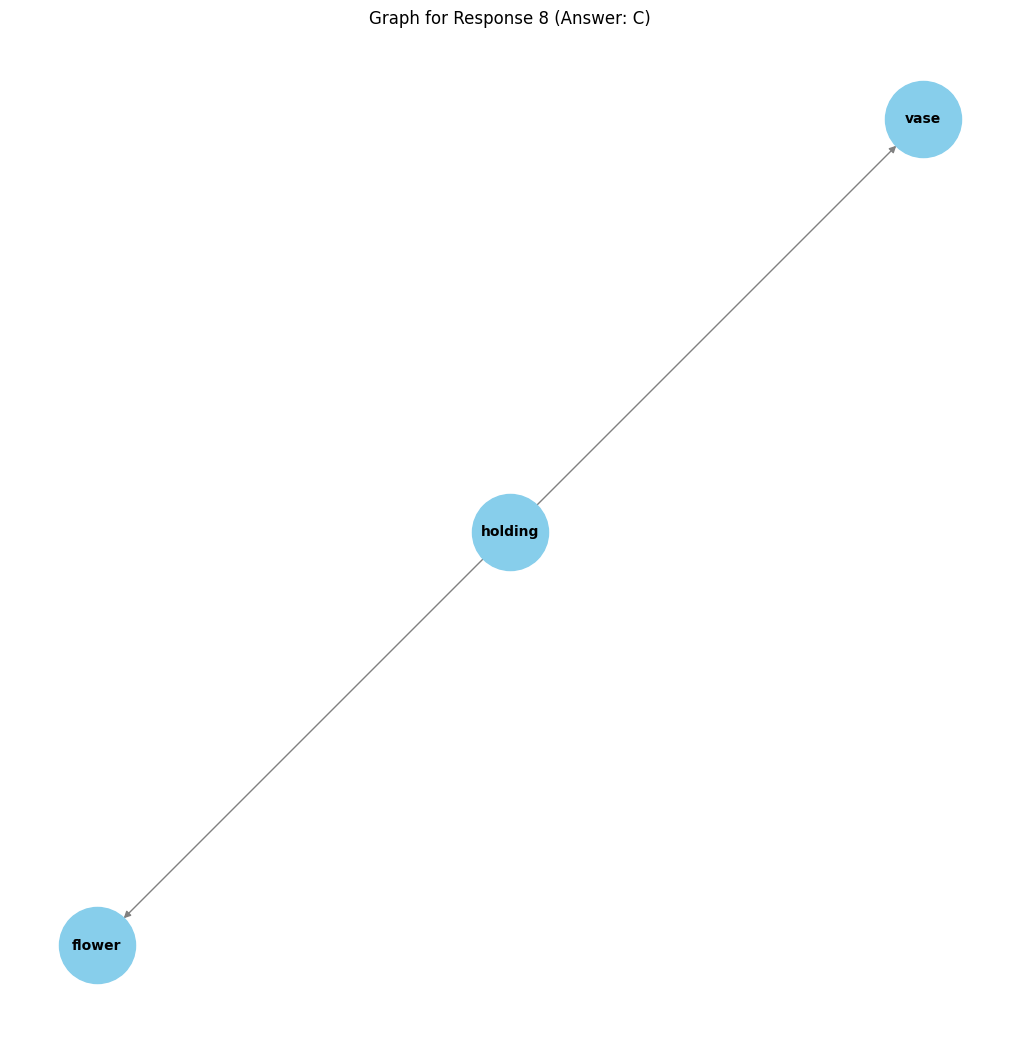

Explanation: Yes, there is a vase in the image. A small flower with red and yellow petals is blooming from the base of a glasse bottle vase that is placed on a table on a sunny day.


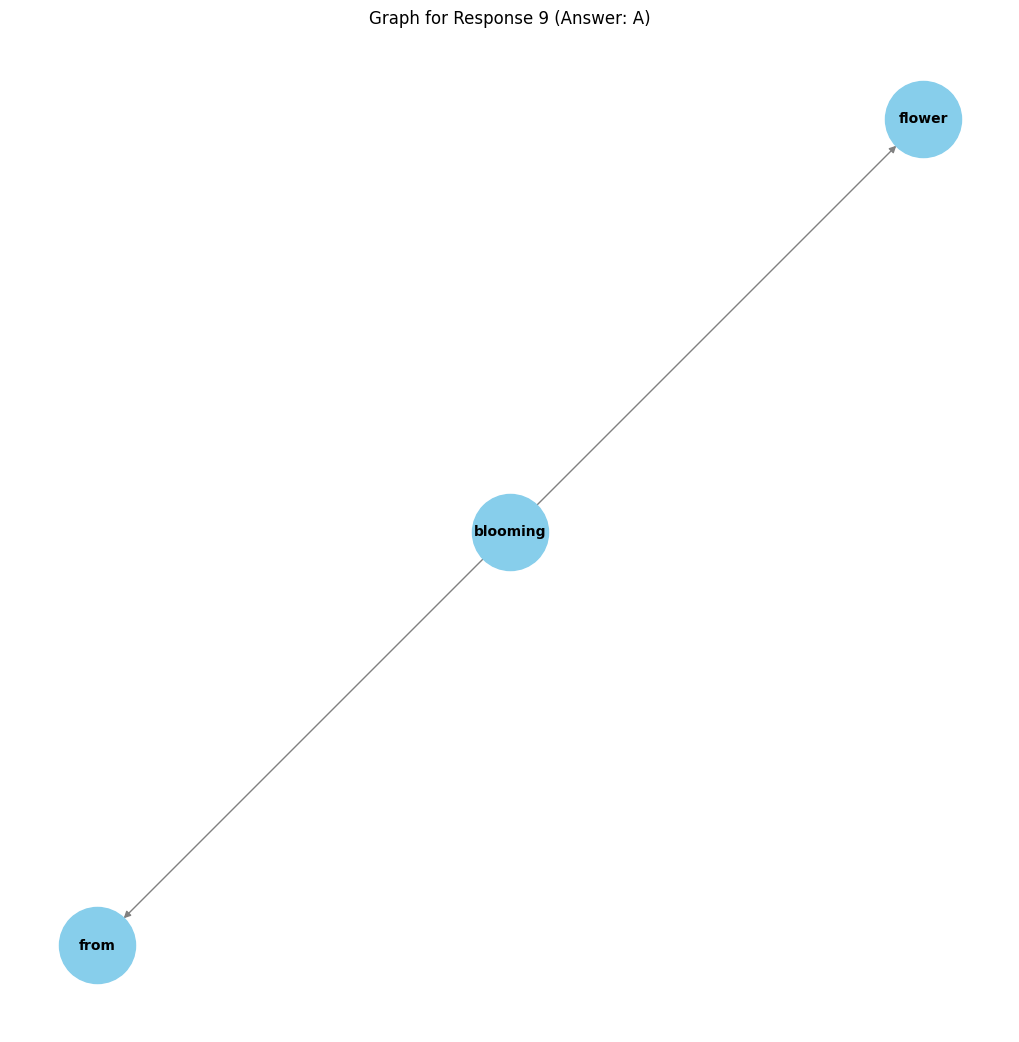

Explanation: There is a vase in the image containing a stem. The vase is placed on a plate or a board. There are also bottles in the background, but they are not the focus and do not have stems in them.


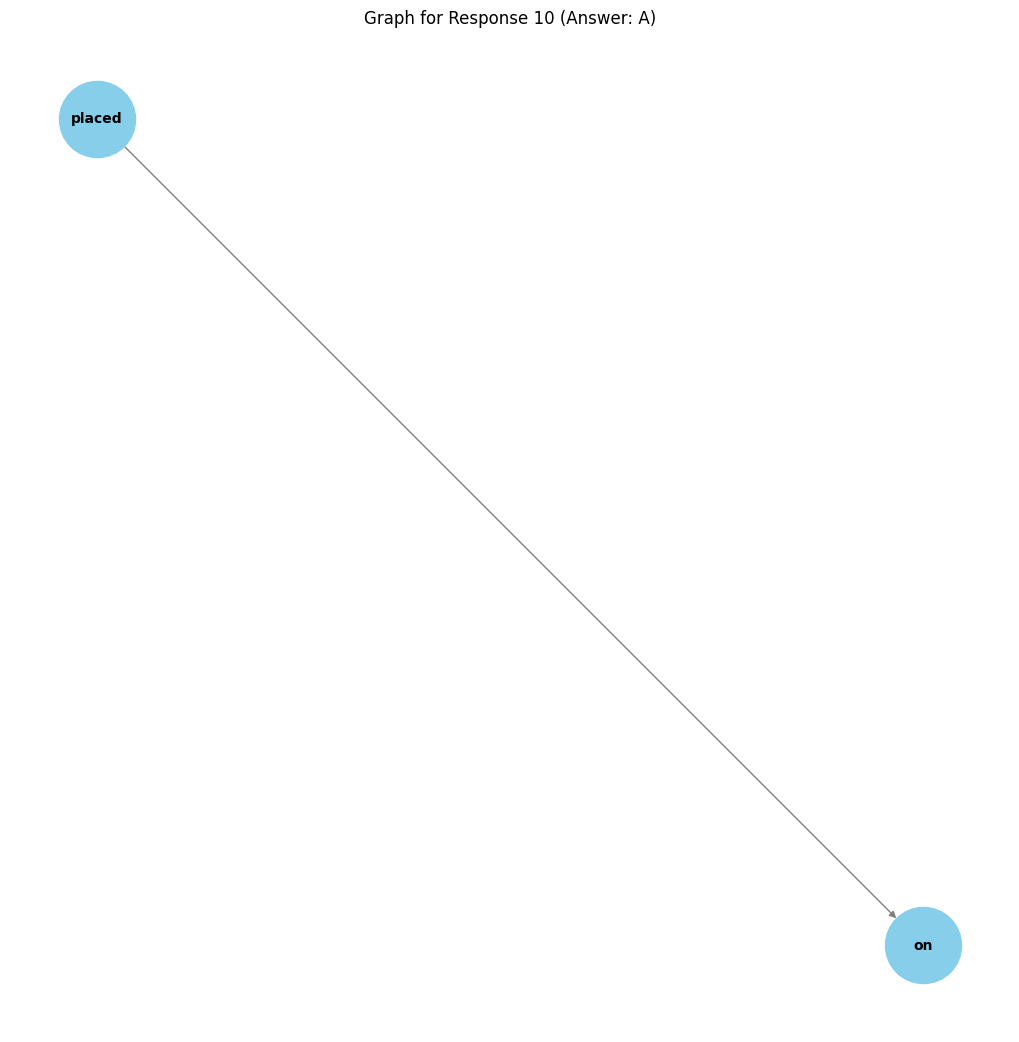

Visualizing for index: 2836
Explanation: The image does not contain any car. It features a baseball game with players in uniform.


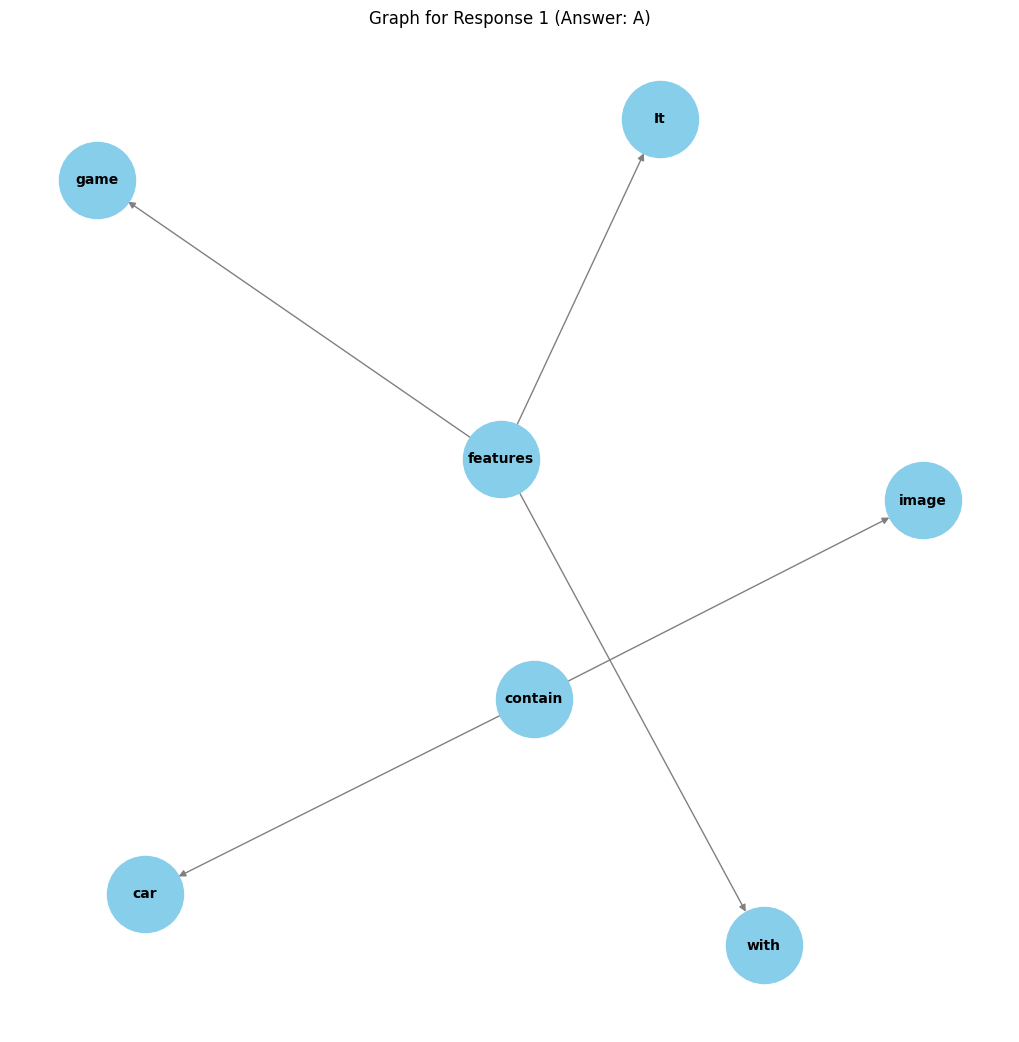

Explanation: There is no car visible in the image as it primarily depicts a baseball diamond and players, while a car would be an unexpected object in this context.


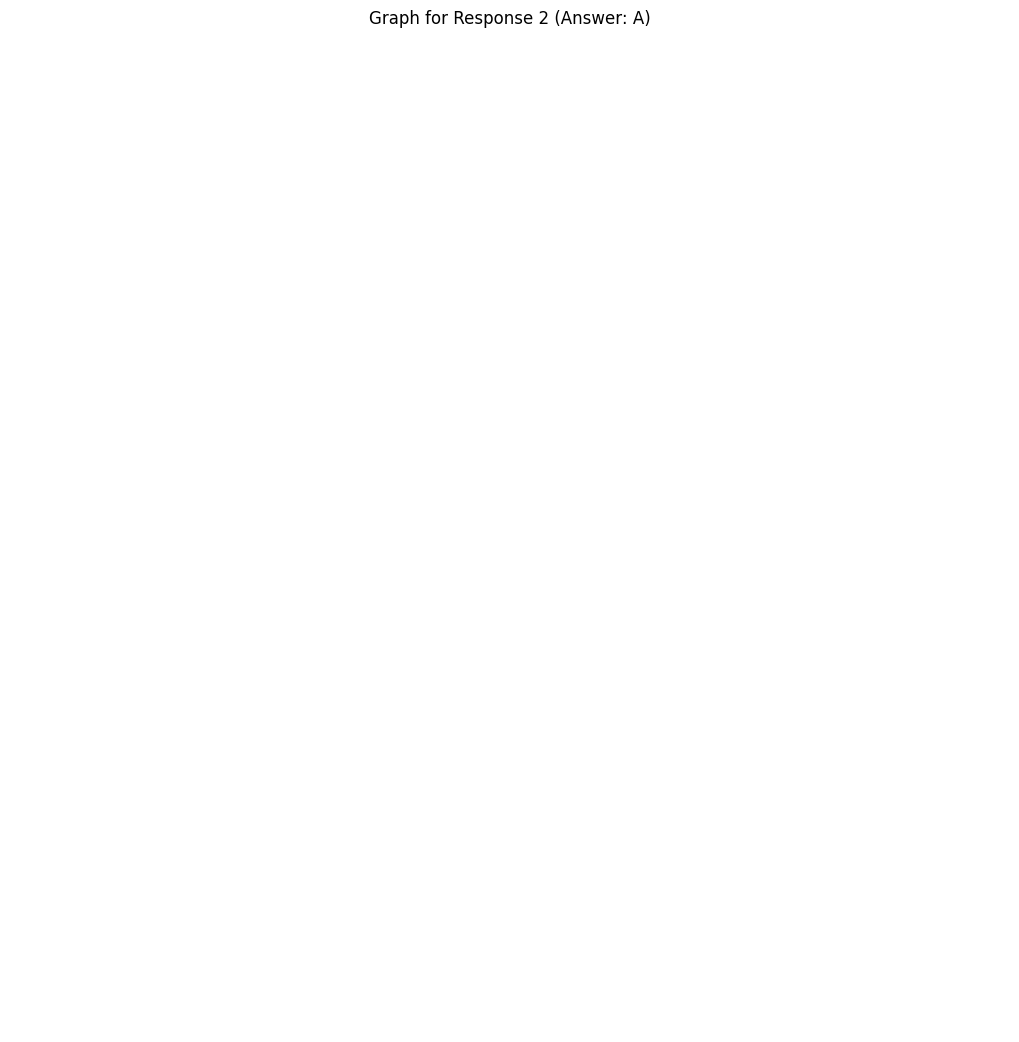

Explanation: There are no cars in the image. The setting appears to be a baseball field with a batter taking a swing. The image is of a sports-related nature involving either a baseball or softball player.


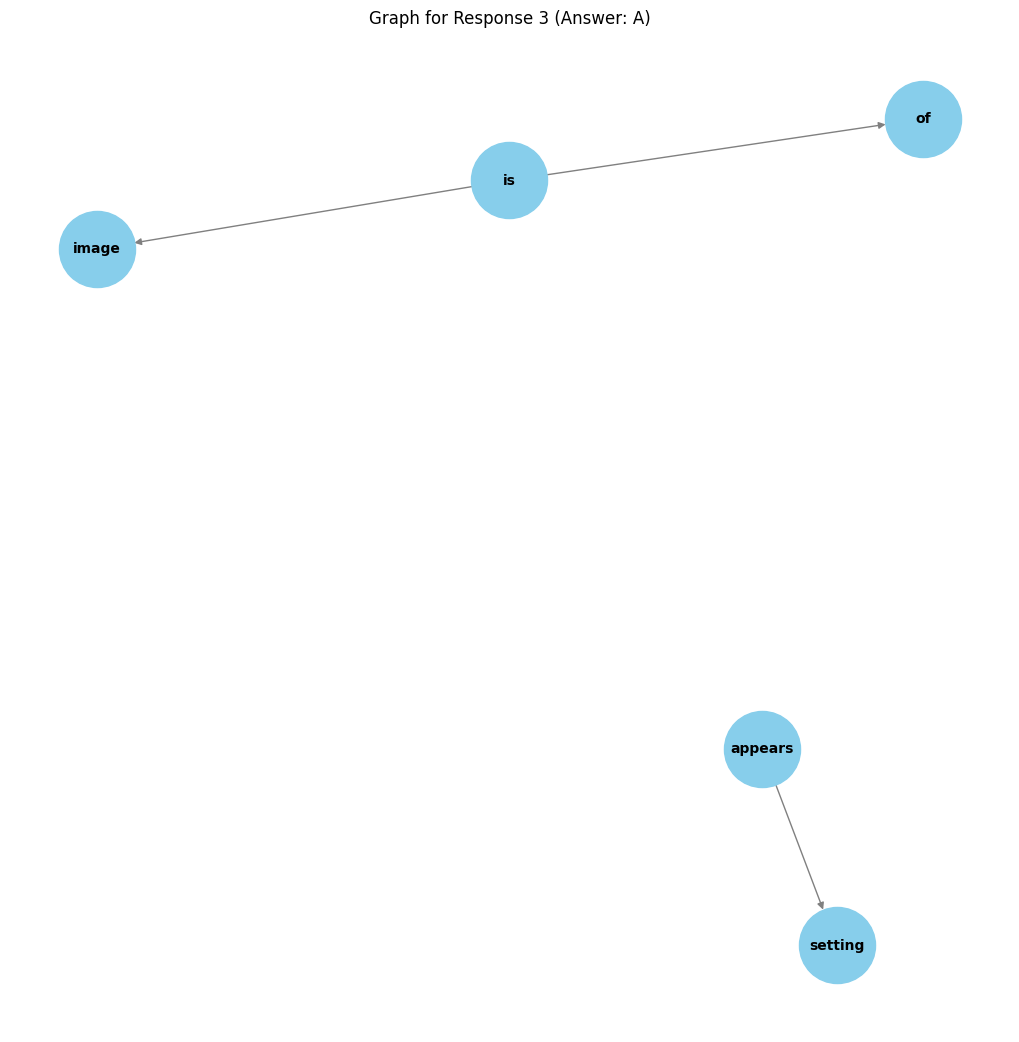

Explanation: There are no cars visible in the image provided, which features a baseball player during a game. The image is focused on the action of the baseball player in front of the teammates watching from the dugout.


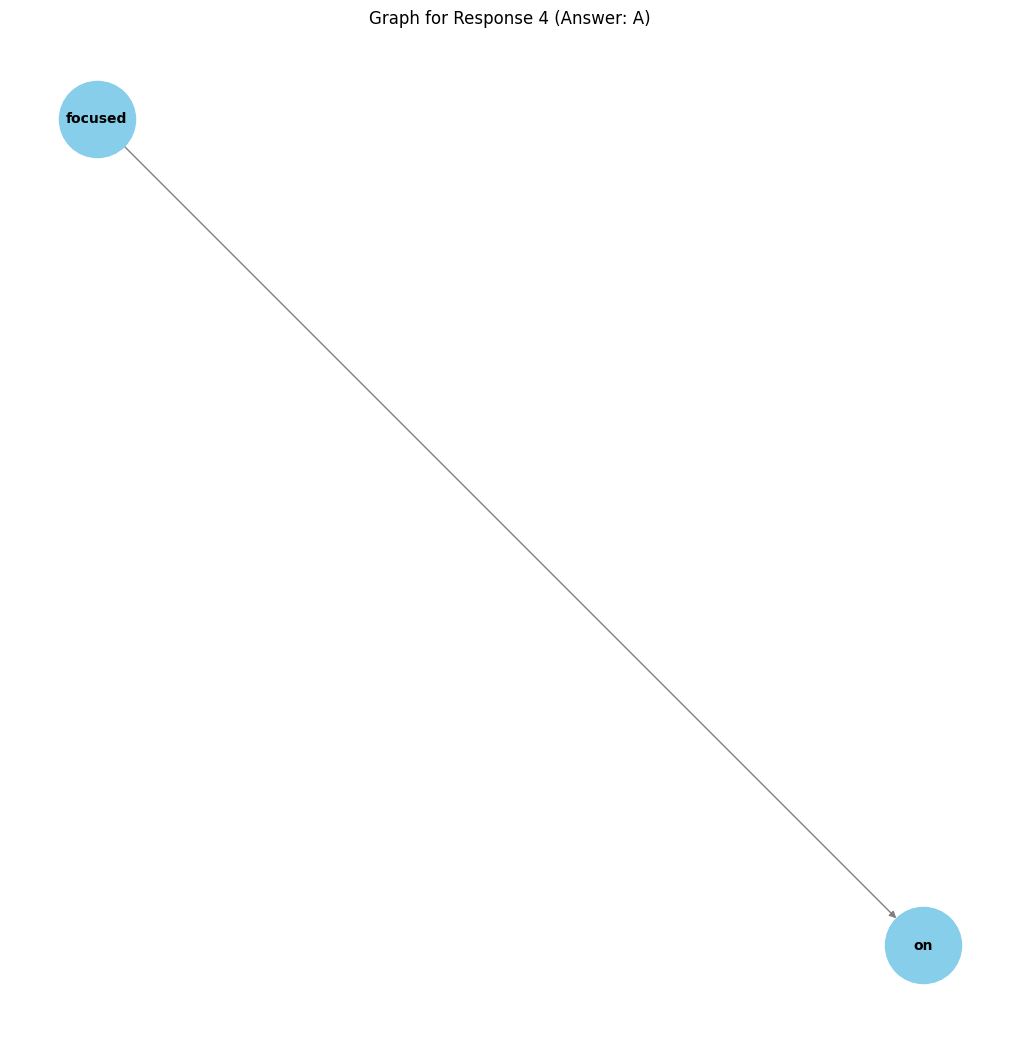

Explanation: There is no car in the image. The focus is on a baseball player up to bat during a baseball game.


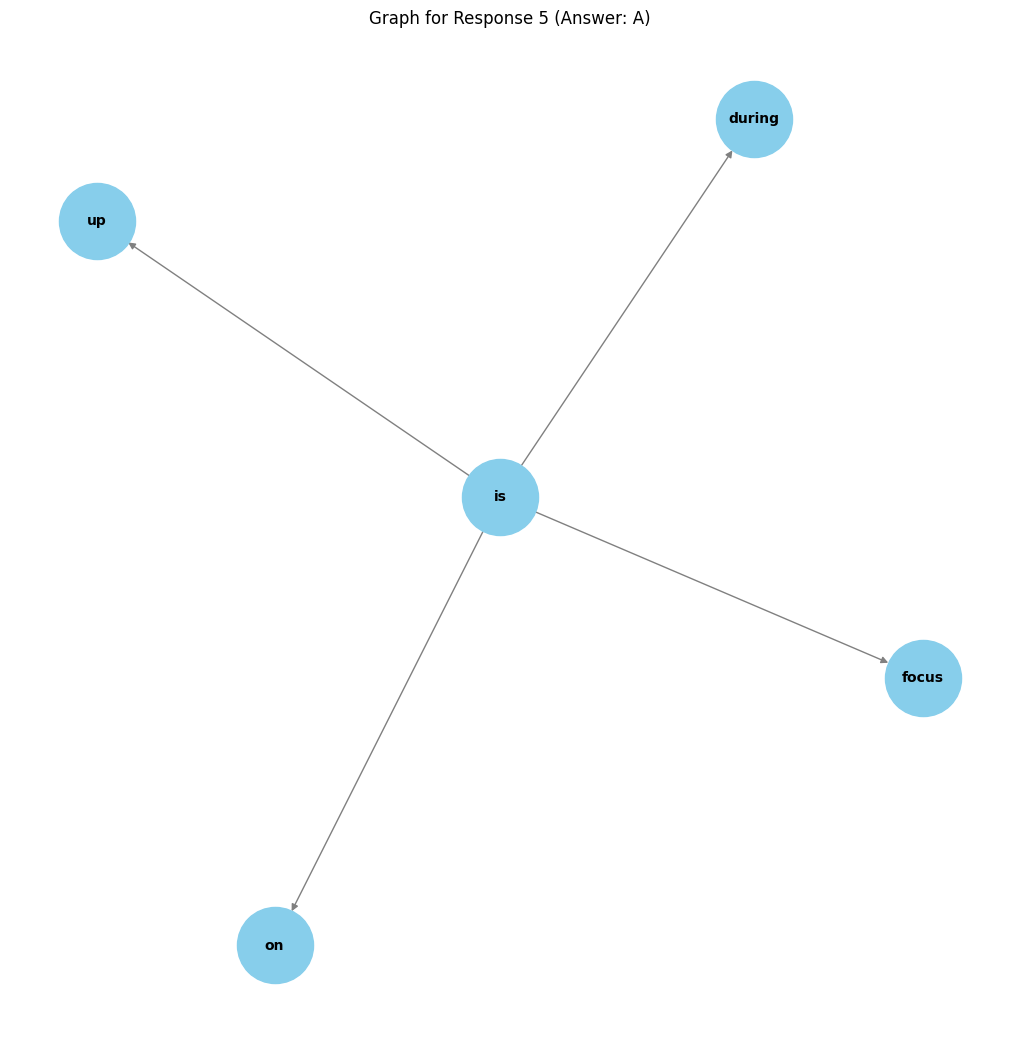

Explanation: The object at the very top left corner of the image is indeed quite small, and it has a shape that could be interpreted as a piece of a vehicle. However, it's in such an obscure location and is not the main focus of the image that it's considered an unrecognizable part of the scene. The car would be at a significant distance and in an unusual place to view it from the perspective of this image.


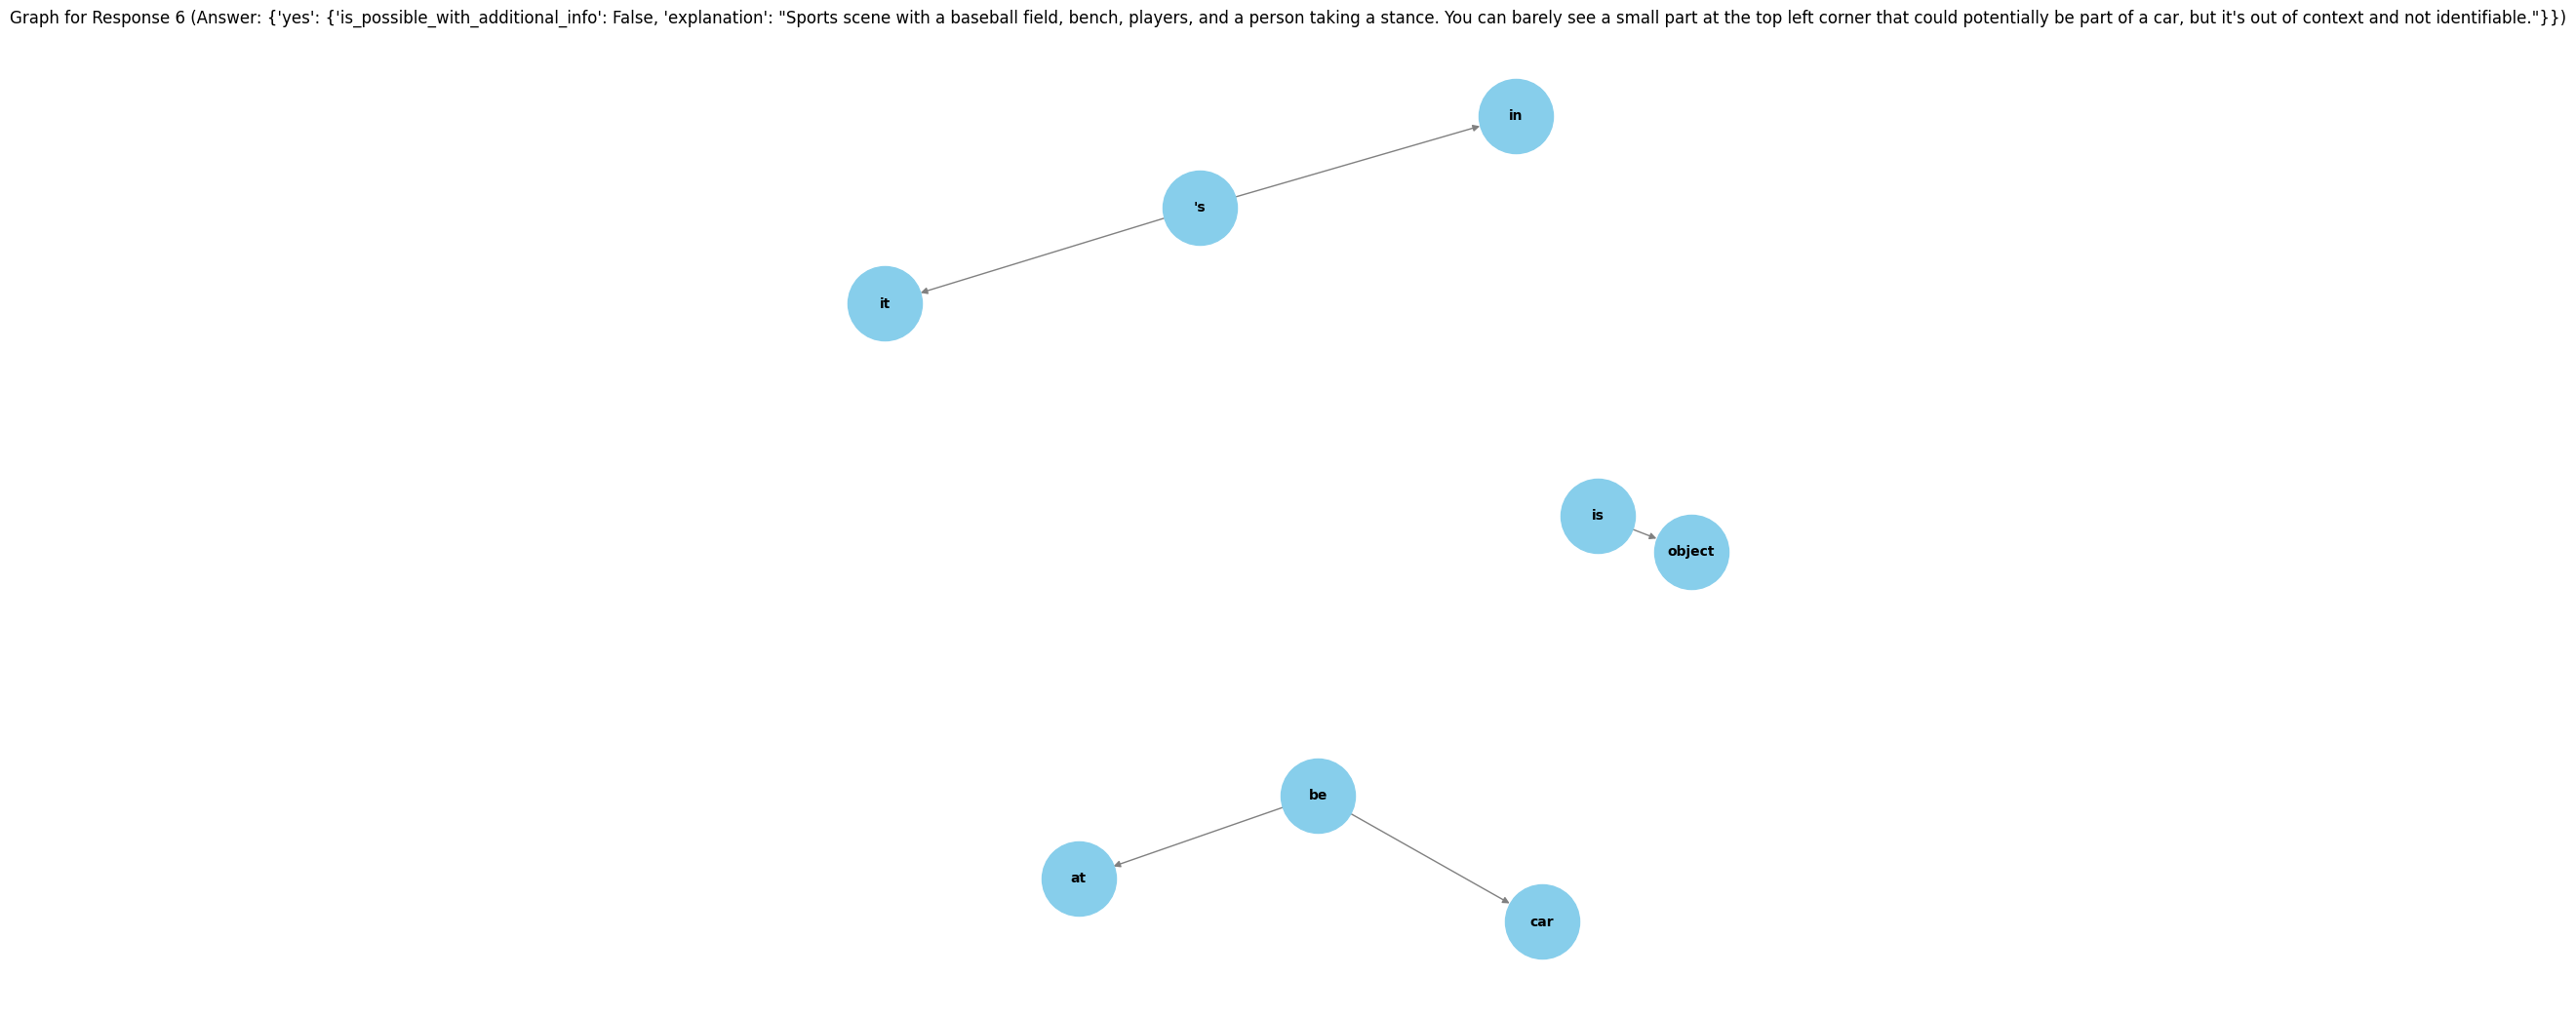

Explanation: The image shows a baseball player actively hitting a ball, and a baseball batter's bat. However, there is no car visible in the image. The main focus of the image is the team baseball event, with players and a batter waiting for a play. The term 'pitch' in this context refers to a baseball pitch, usually made by the team's pitcher to the batter from the mound.


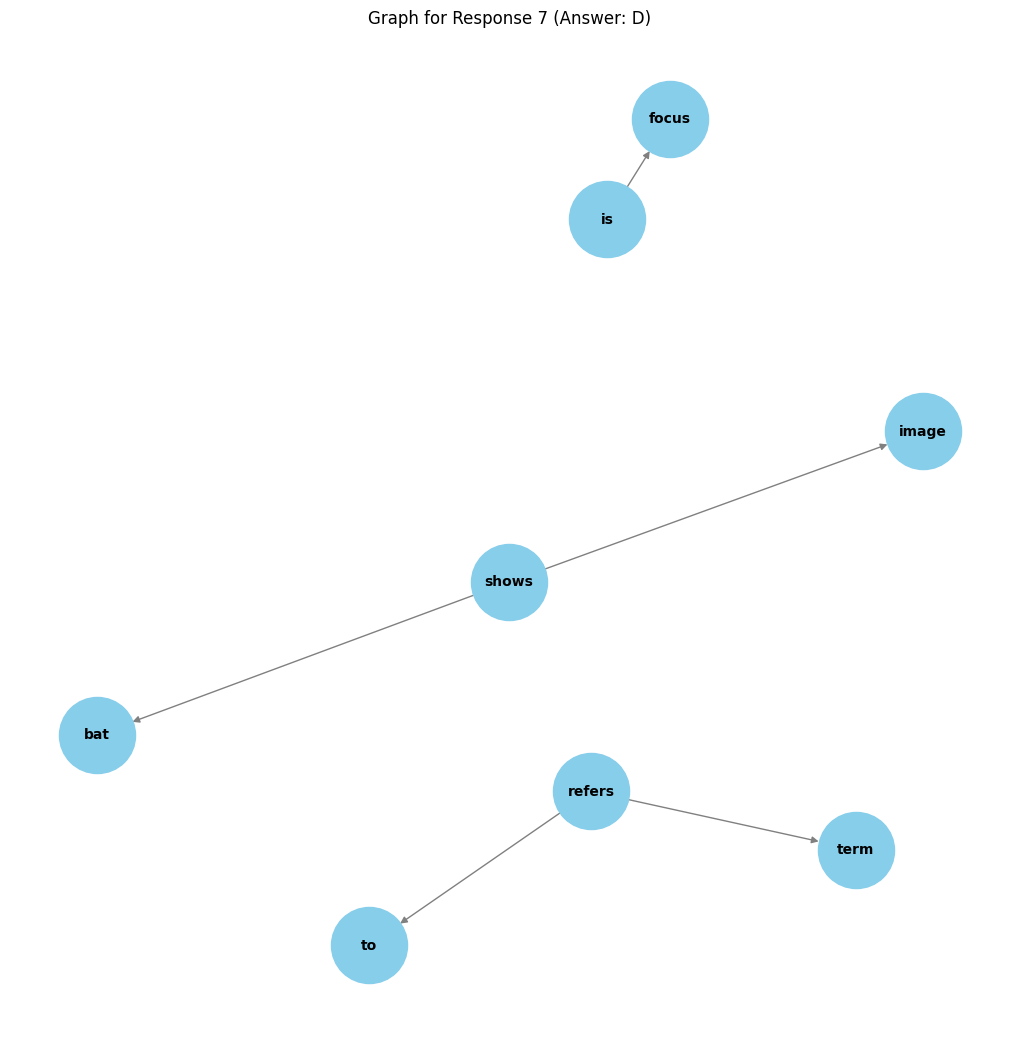

Explanation: No, there is no car in the image. The picture shows a baseball player at the plate in a baseball game, with teammates and opponents watching.


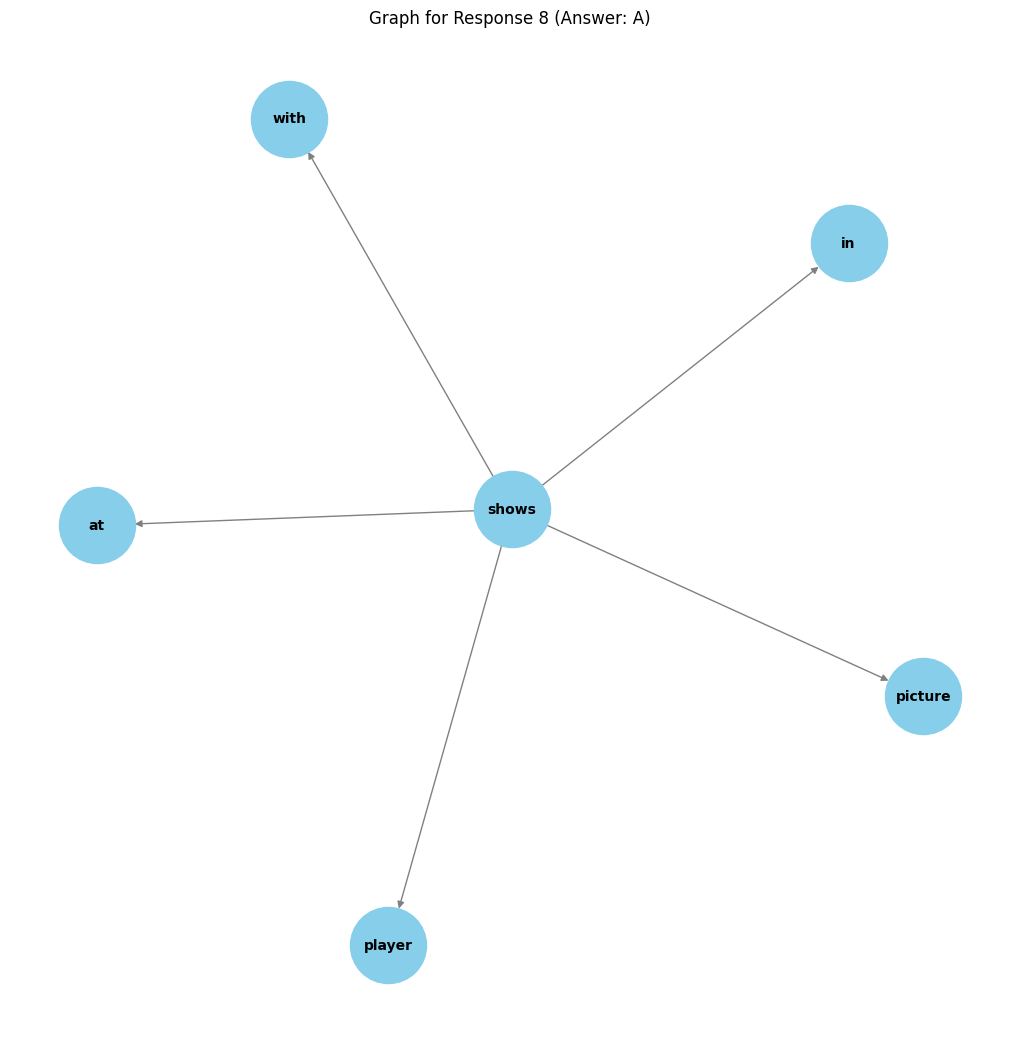

Explanation: There is no car in the image. It depicts a baseball game where the batter is swinging at a pitch over home base.


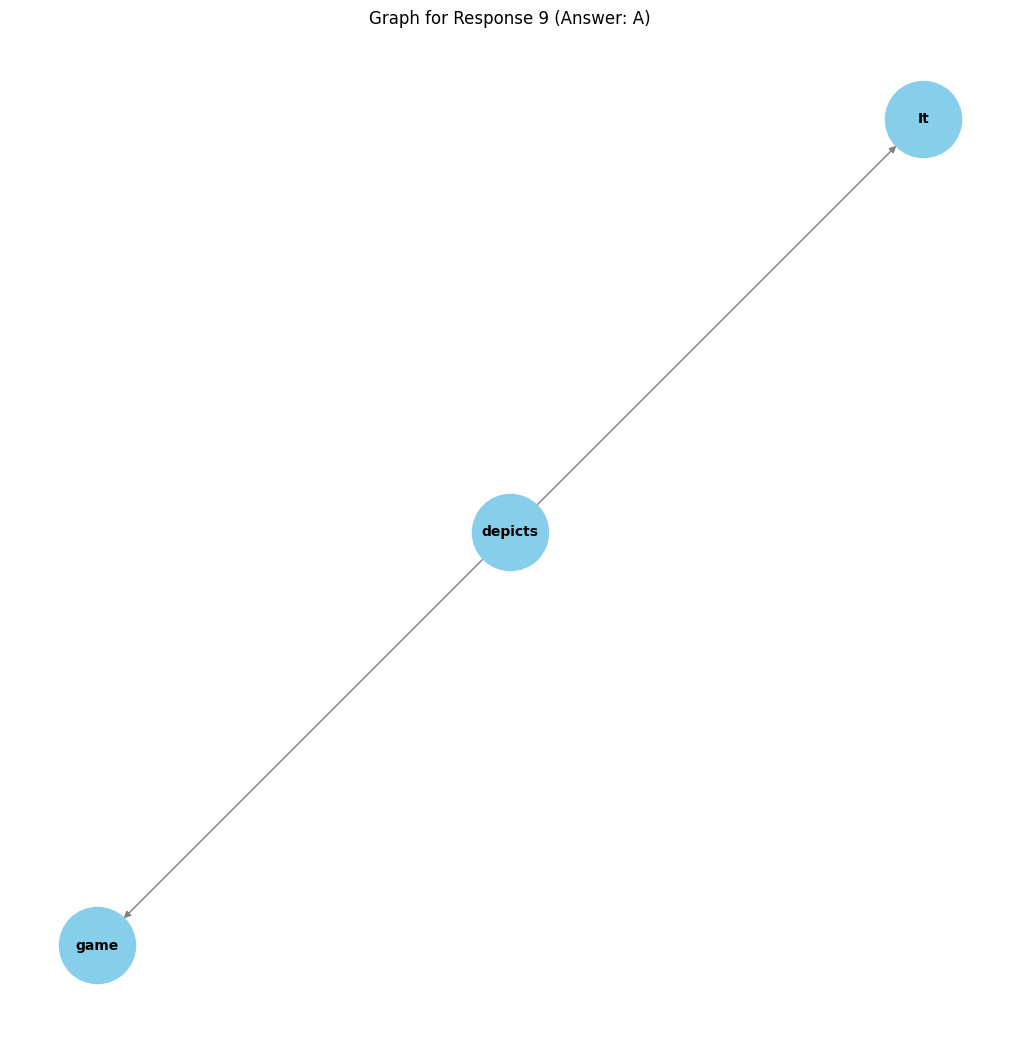

Explanation: There are no cars visible in the image shown, as it is a ballpark with a baseball player preparing to take a swing. The environment does not include a car.


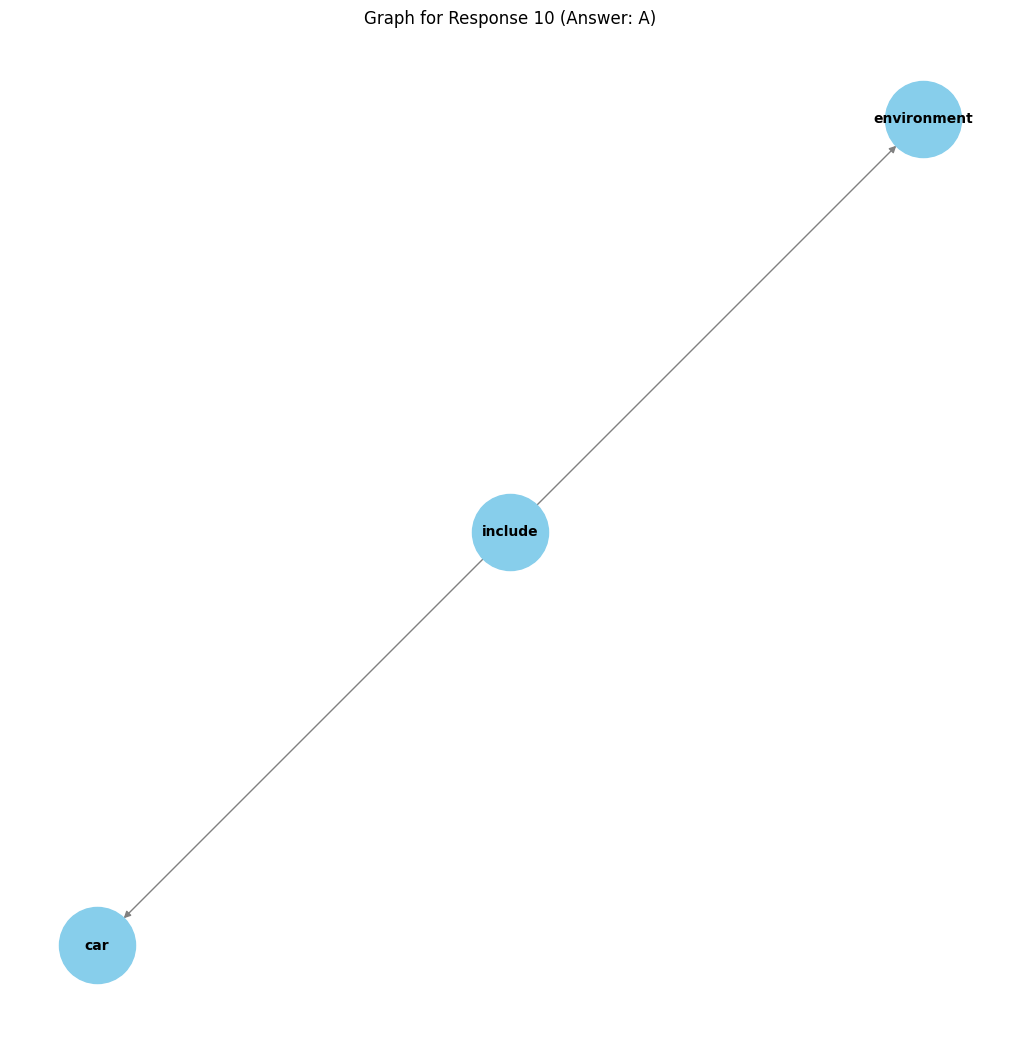

Explanation: The image does not contain a car. It features a baseball player ready to swing at a ball with onlookers in the background. The scene is focused on the player and his action on the baseball field, which does not include any cars. So, the answer is 'A' as there is no car present in this image.


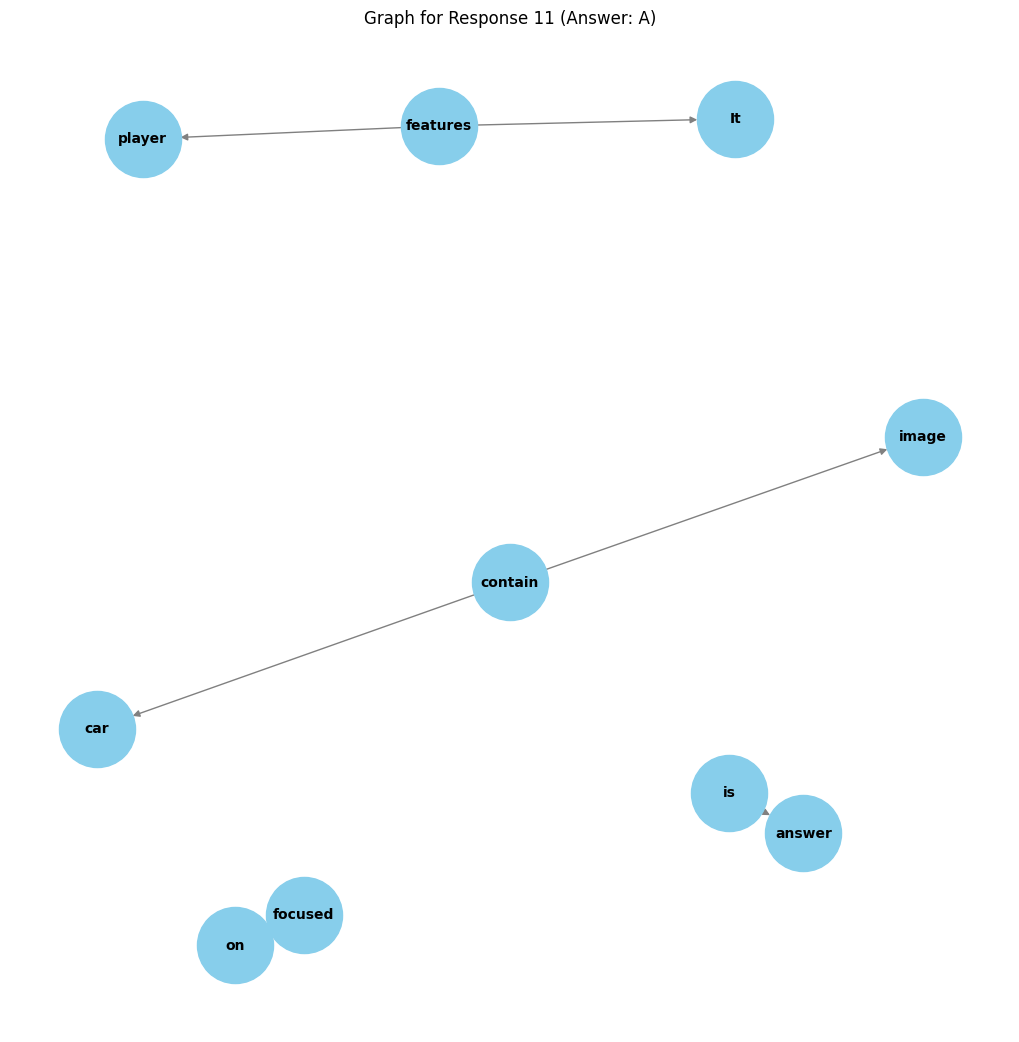

Explanation: There is no car in the image. It only contains a baseball field, baseball bats, players, and a bench. The setting is all about sports activities, specifically baseball.


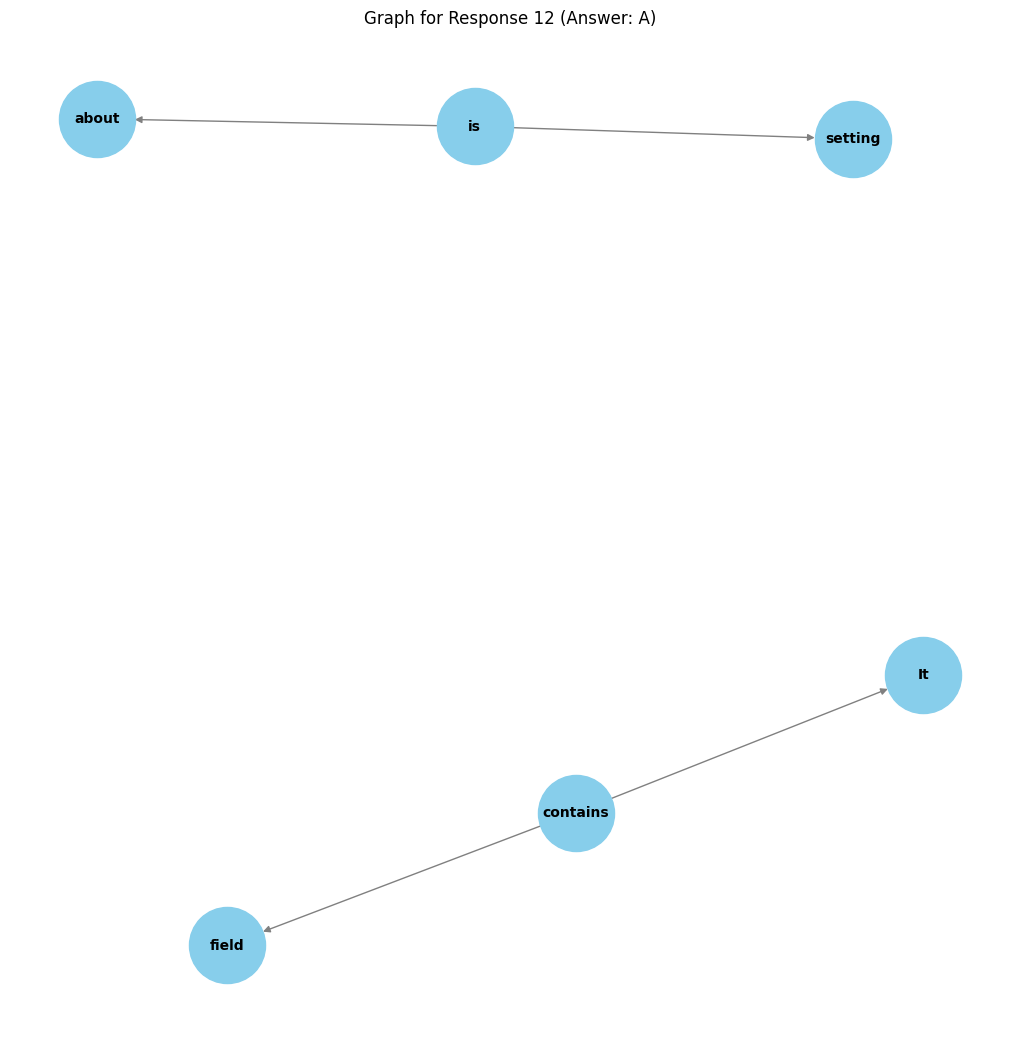

Explanation: There is no car in the image. The description is about a person playing baseball, and no vehicles are visible, thus the answer is 'A'.


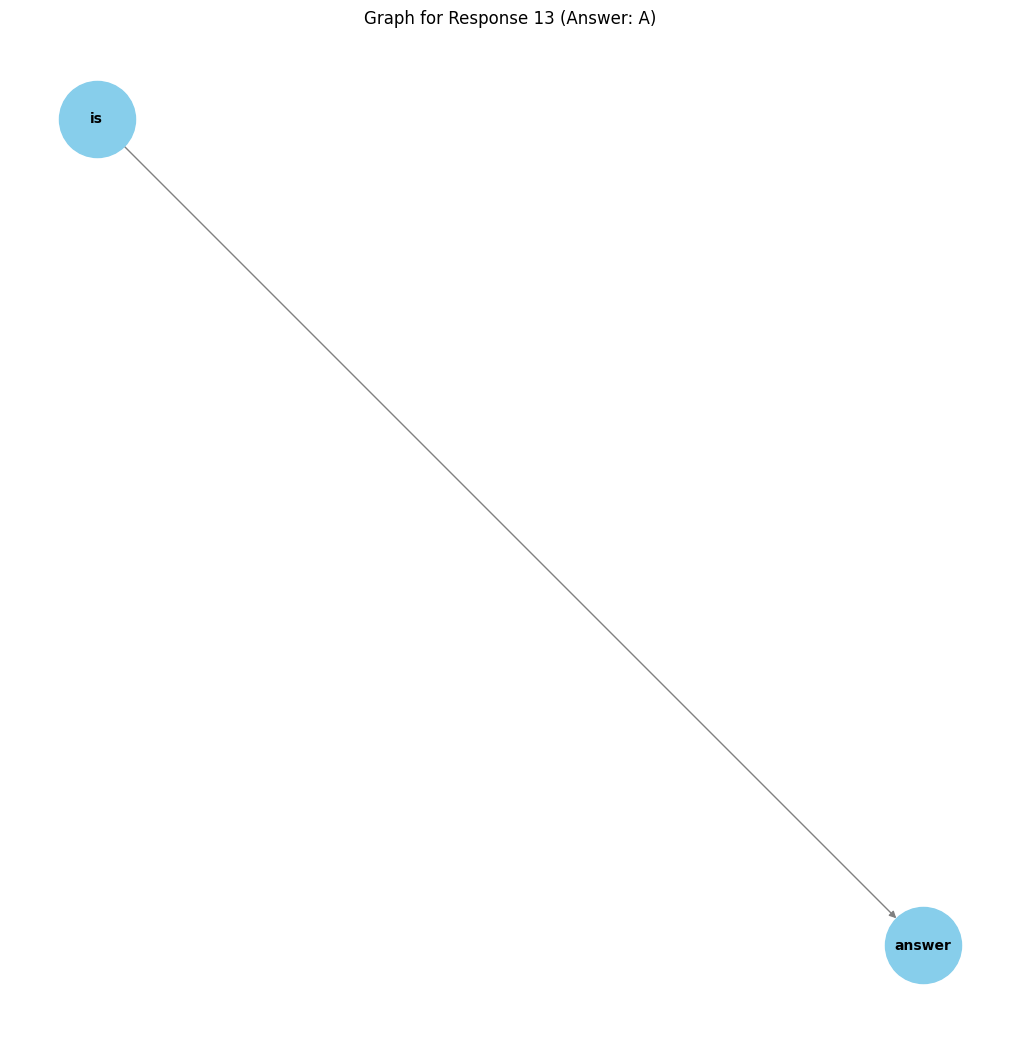

Explanation: While there are multiple baseball players in the image, there is no car visible in the scene as the primary focus is on the baseball game being played. Every element in the image is related to the sport of baseball.


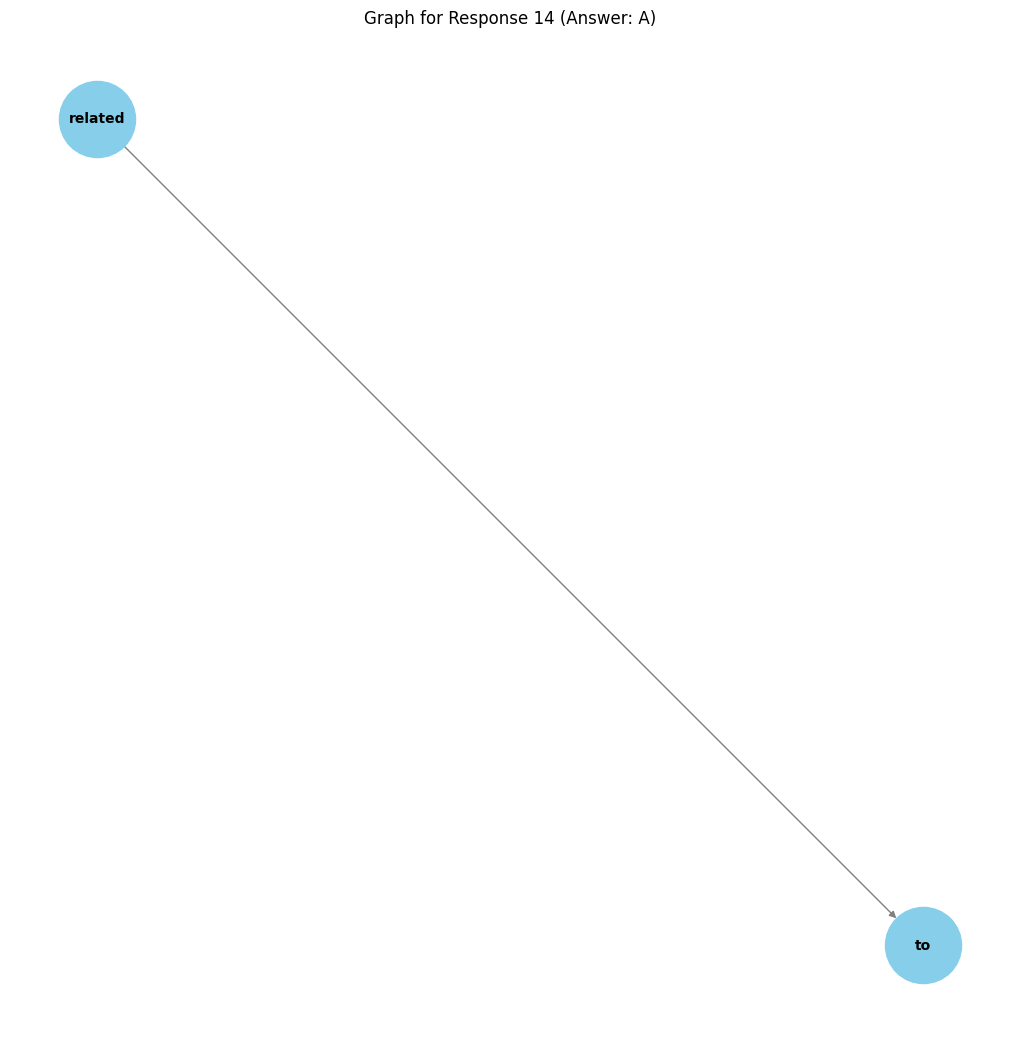

Visualizing for index: 2837
Explanation: 
Error: 'answer'
Response: {'is_correct:': False, 'reasoning': 'The image does indeed show a bed, which is a piece of furniture used for sleeping. It is depicted with a duvet and two bed pillows visible, indicating that it is setup for resting. There are no other items visible that could pass as a bed in this context, nor are there any nan-like objects that do not exist. Therefore, the correct answer would be A.', 'confidence_score': 0.98, 'graph': {'The image': {}, 'a bed': {}, 'a person': {}, 'it': {}, 'an actual object': {}, 'the question': {}, 'the image': {}, 'the dog': {}, 'the answer': {}, 'your question': {}, "'B": {}, 'those': {}, 'the actual objects': {}, 'be': {'answer': {}}, 'answer': {}}}
Explanation: The image shows a bed with a person sleeping on it, so there is an actual object for the question about whether there is a bed in the image. Since there is a bed and the dog is laying on it, the answer to your question cannot be 'B' or

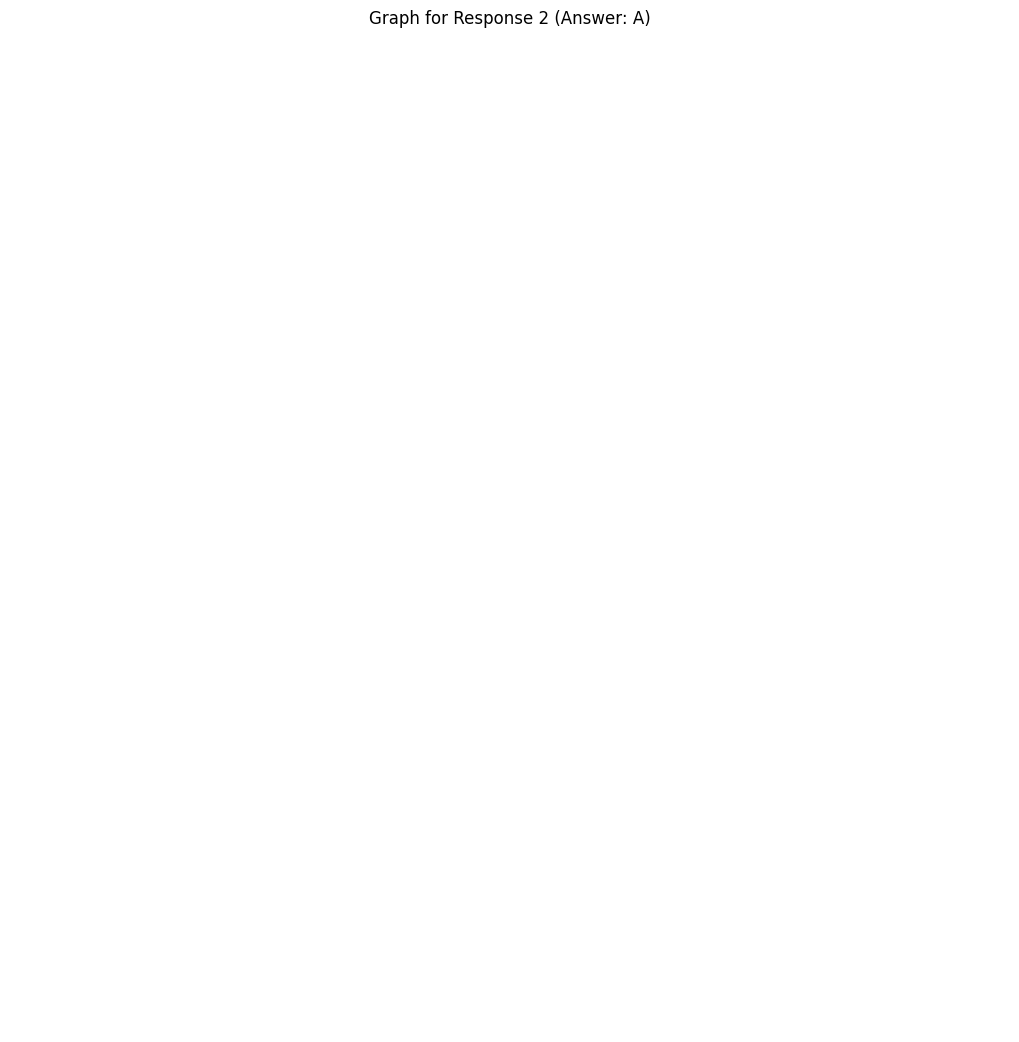

Explanation: There is no bed in this image, as the scene depicts a person and a dog lying on a green blanket on the floor that looks like a carpet or a bed without a mattress. There is no bed frame or box spring that is typically associated with a bed.


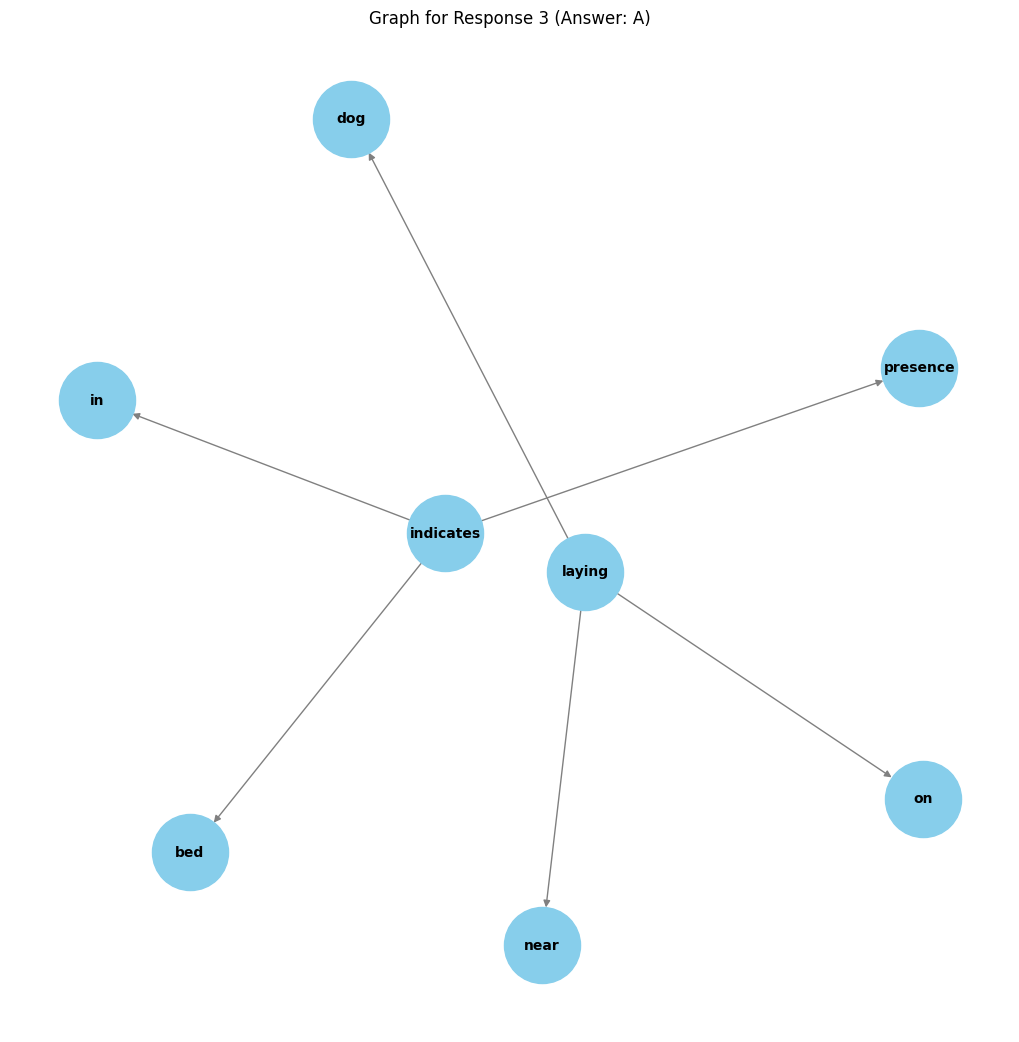

Explanation: Yes, there is a bed in the image. The presence of a sleeping person lying on top of a pillow on the bed indicates a bed in the photo. The dog is laying on the bed near the person too.


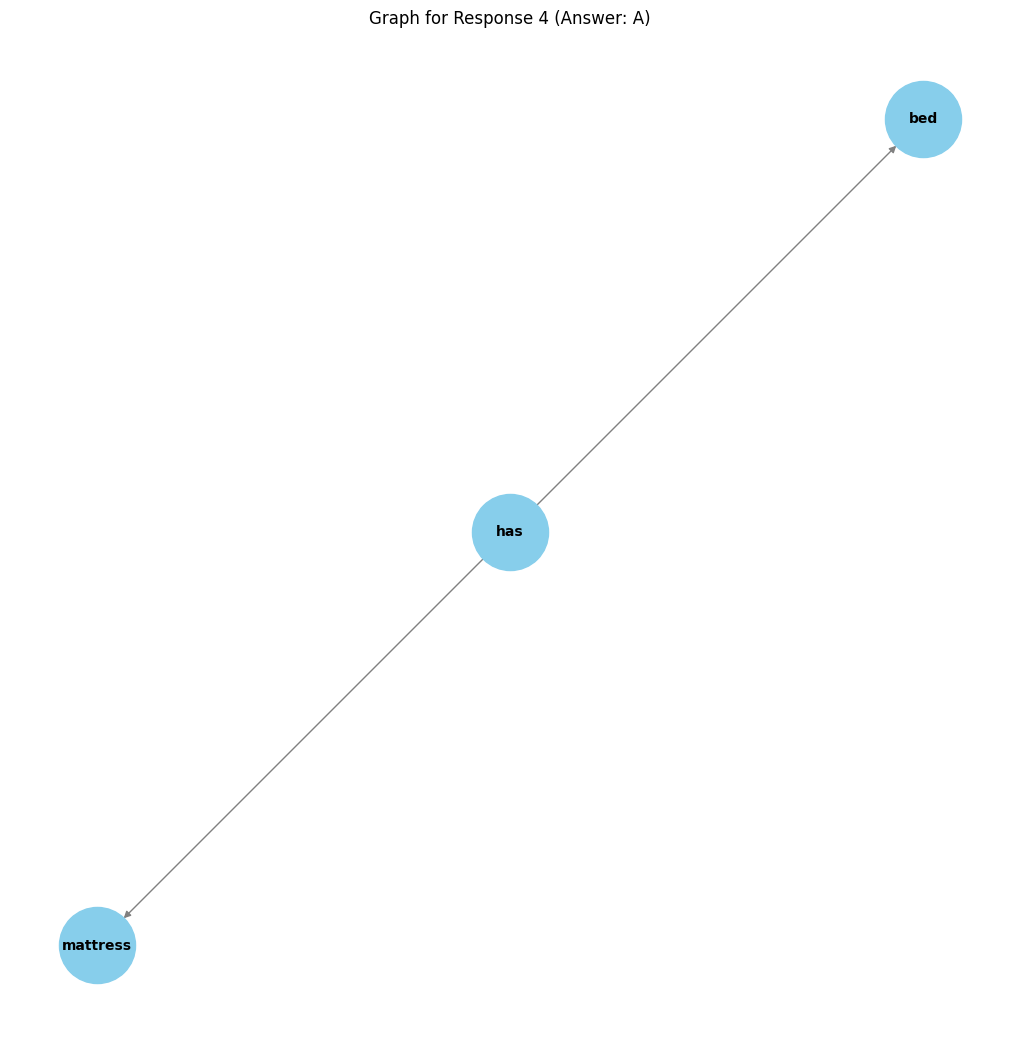

Explanation: Yes, there is a bed in the image as it appears to be a well-made bed with occupants sleeping on it. The bed has a visible mattress and pillows, and the pets are likely on it, resting as they commonly do near their human companions.


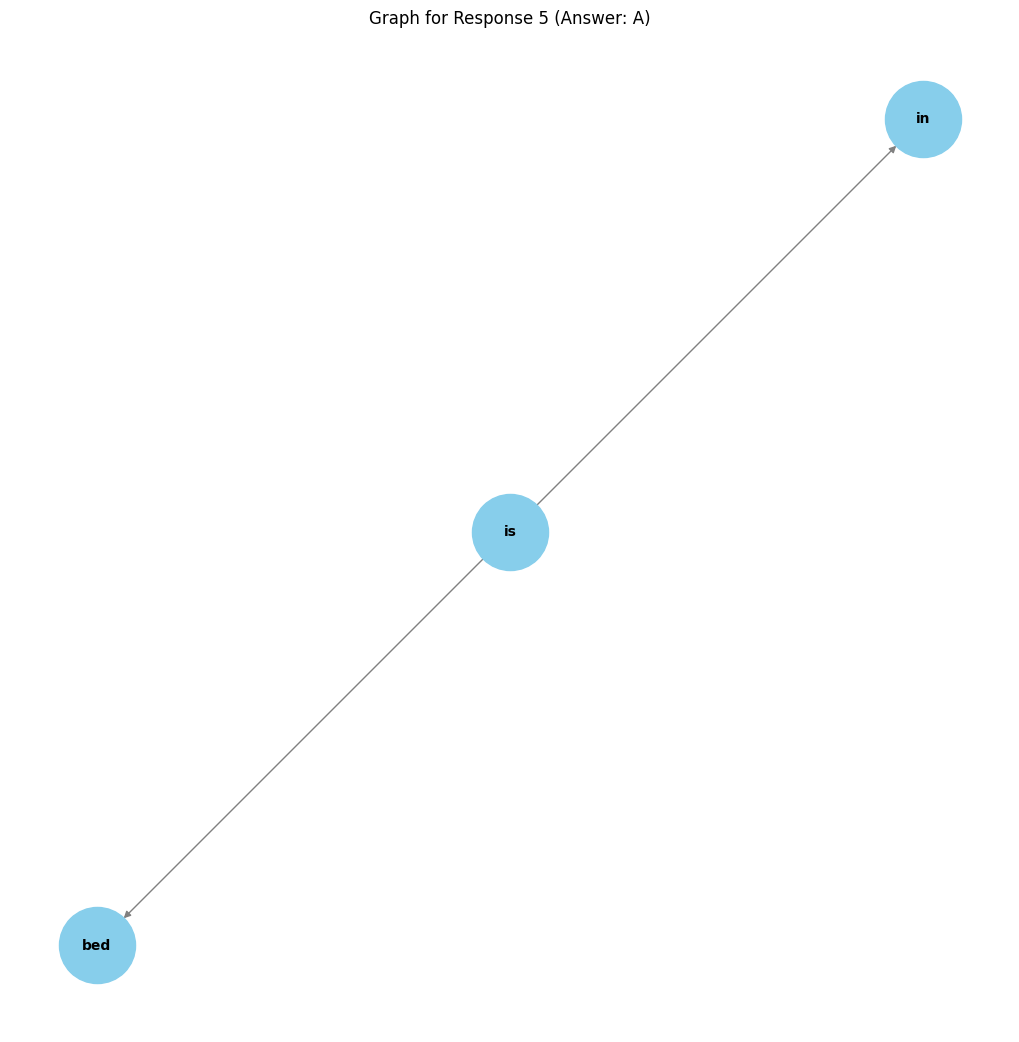

Explanation: There is a bed in the image as it has a mattress with two pillows on it where a person and a dog are sleeping. A bed is an elevated surface that is typically used for sleeping and has some form of mattress, sheets, or other bedding.


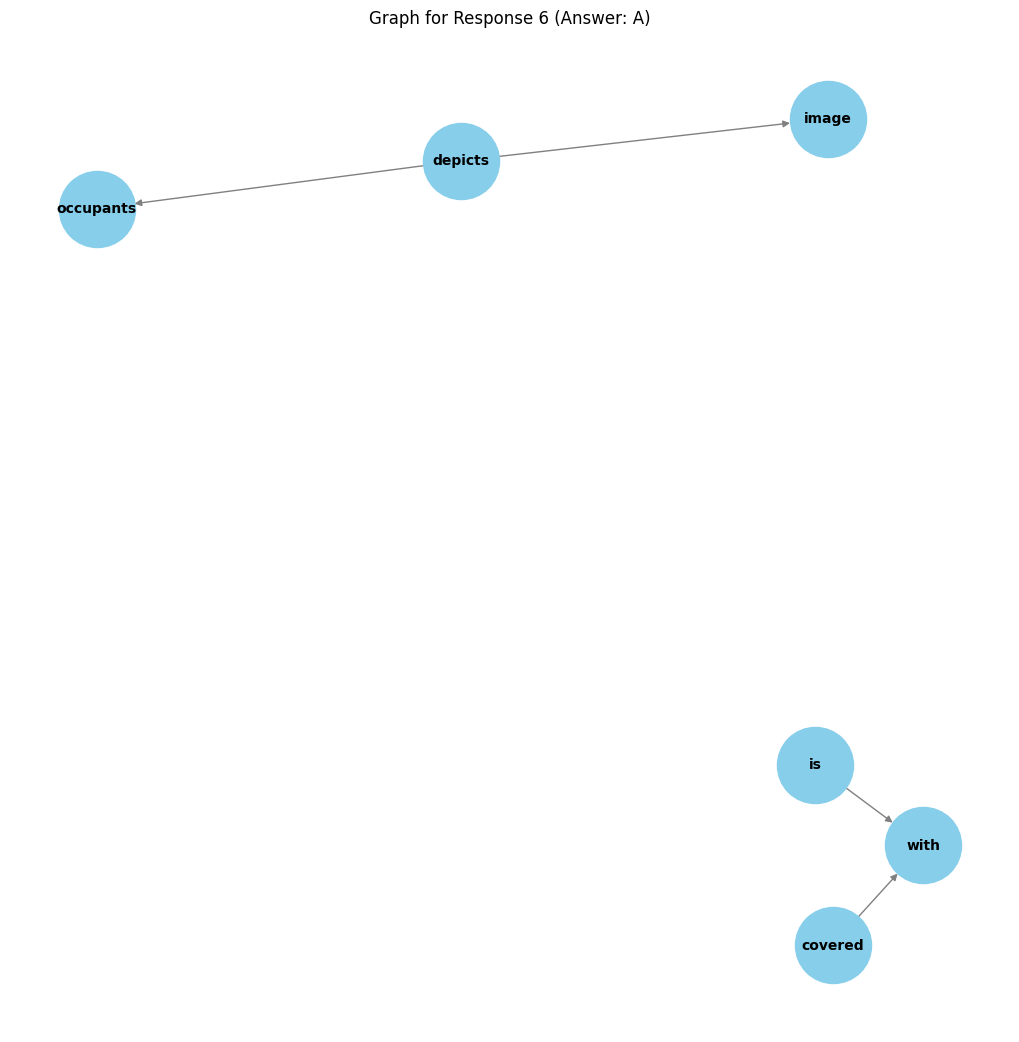

Explanation: Yes, there is a bed in the image with a man and a dog lying on it. The bed is covered with green comforters, and the dog appears to be playing or asleep. The image clearly depicts the two occupants of the bed.


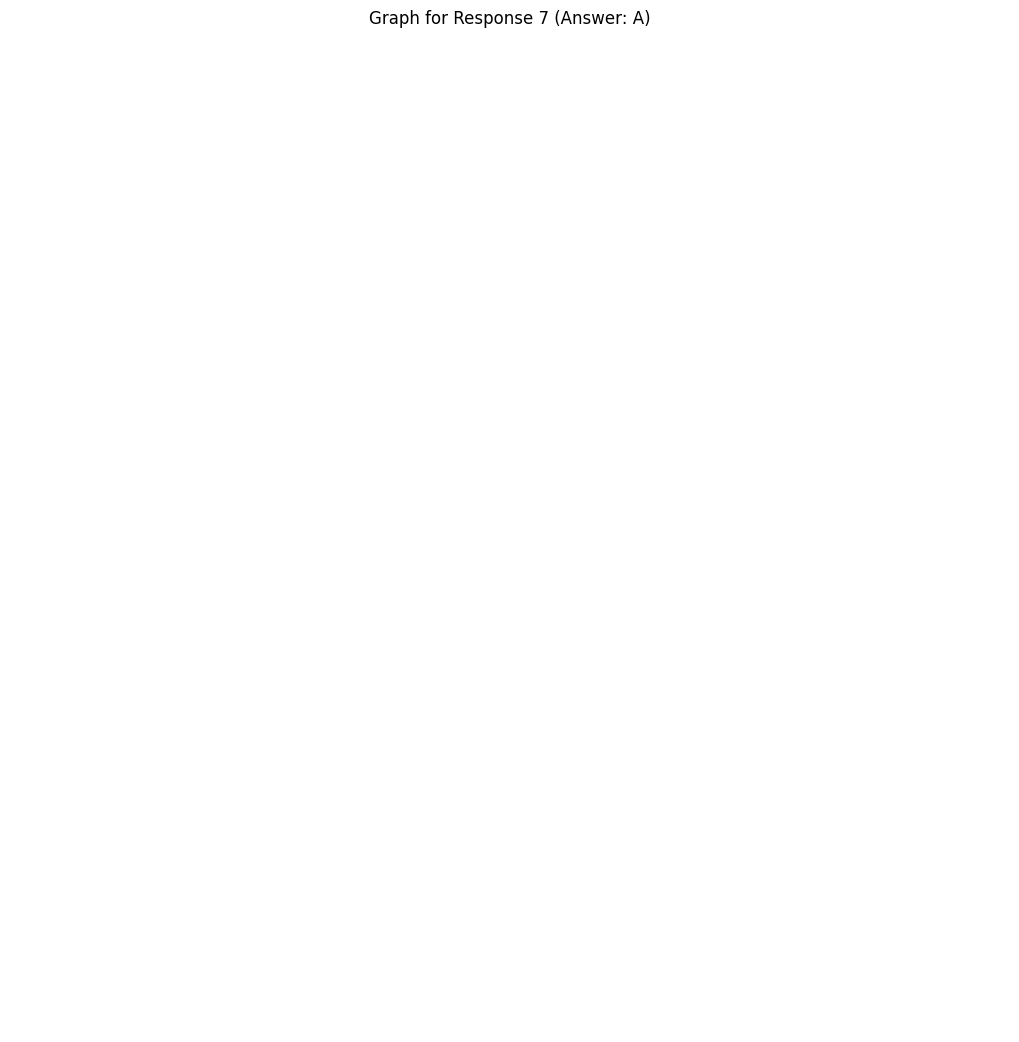

Explanation: There is a bed in the image, shown by the presence of a person and a person's legs in bed. Additionally, there is a pillow and another pillow, indicating a typical bed setup.


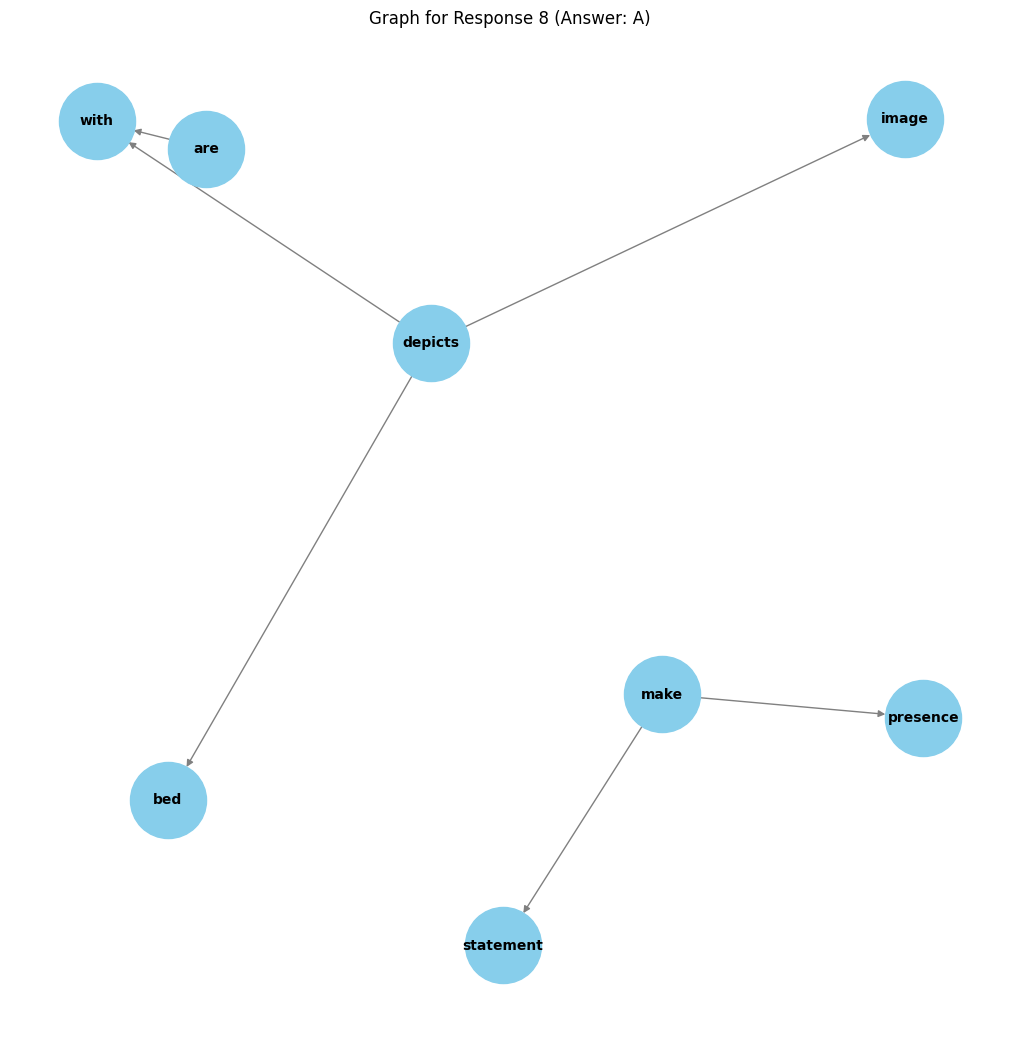

Explanation: The image depicts a bed with a sleeping person and a dog lying next to them. There are two pillows visible, one on both sides of the bed, with the person's head leaning on one. The presence of a person and a dog, along with the bedding, make the statement 'There is a bed in the image' a fact.


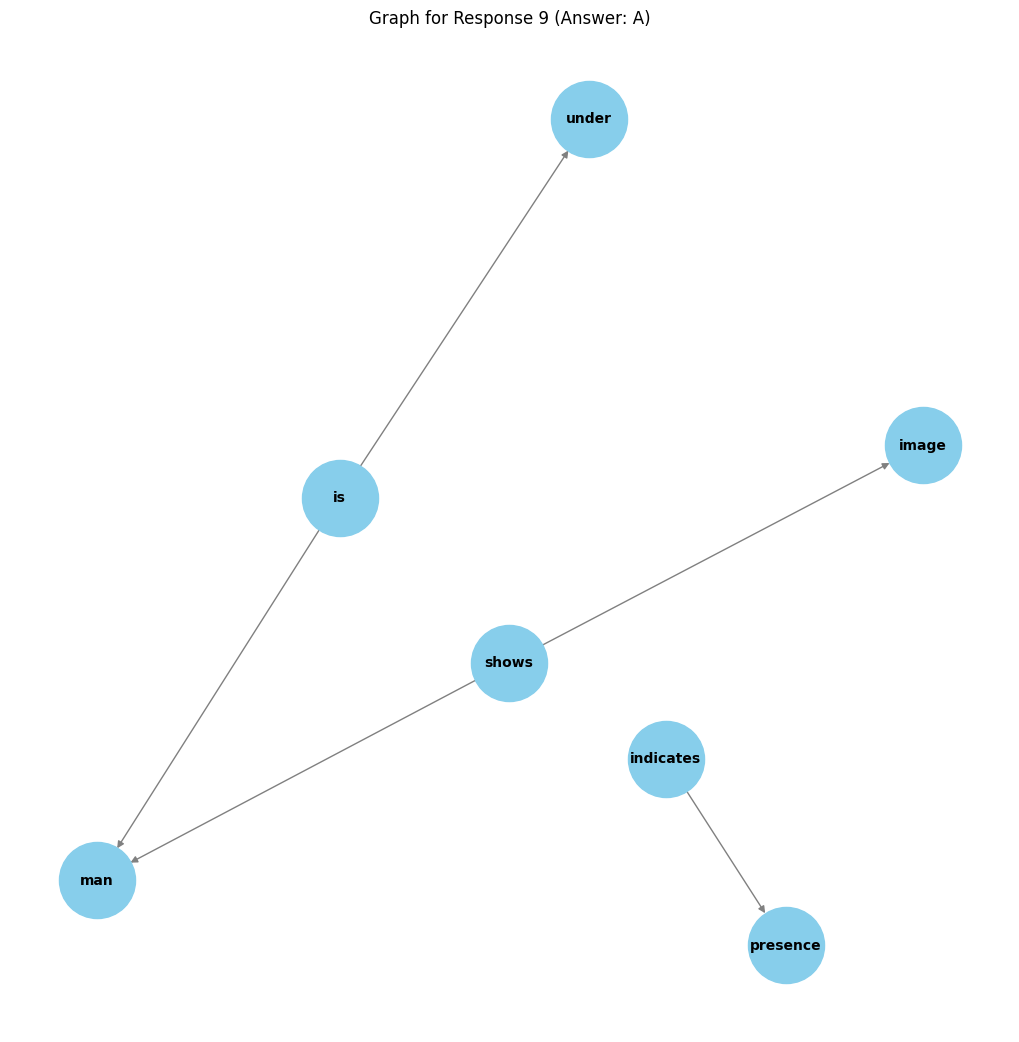

Explanation: The image shows a man sleeping in a bed with a pillow and a person lying next to him on the same bed. There is no separate bed or separate resting area in the image. The man is fully under the covers, suggesting they sleep together, which is characteristic of a single bed for more than one person. The presence of pillows indicates it is a bed. The person next to the man is covered by the bed's cover sheet and sleeping in a restful position, further supporting that this is a bed in the context of the image.


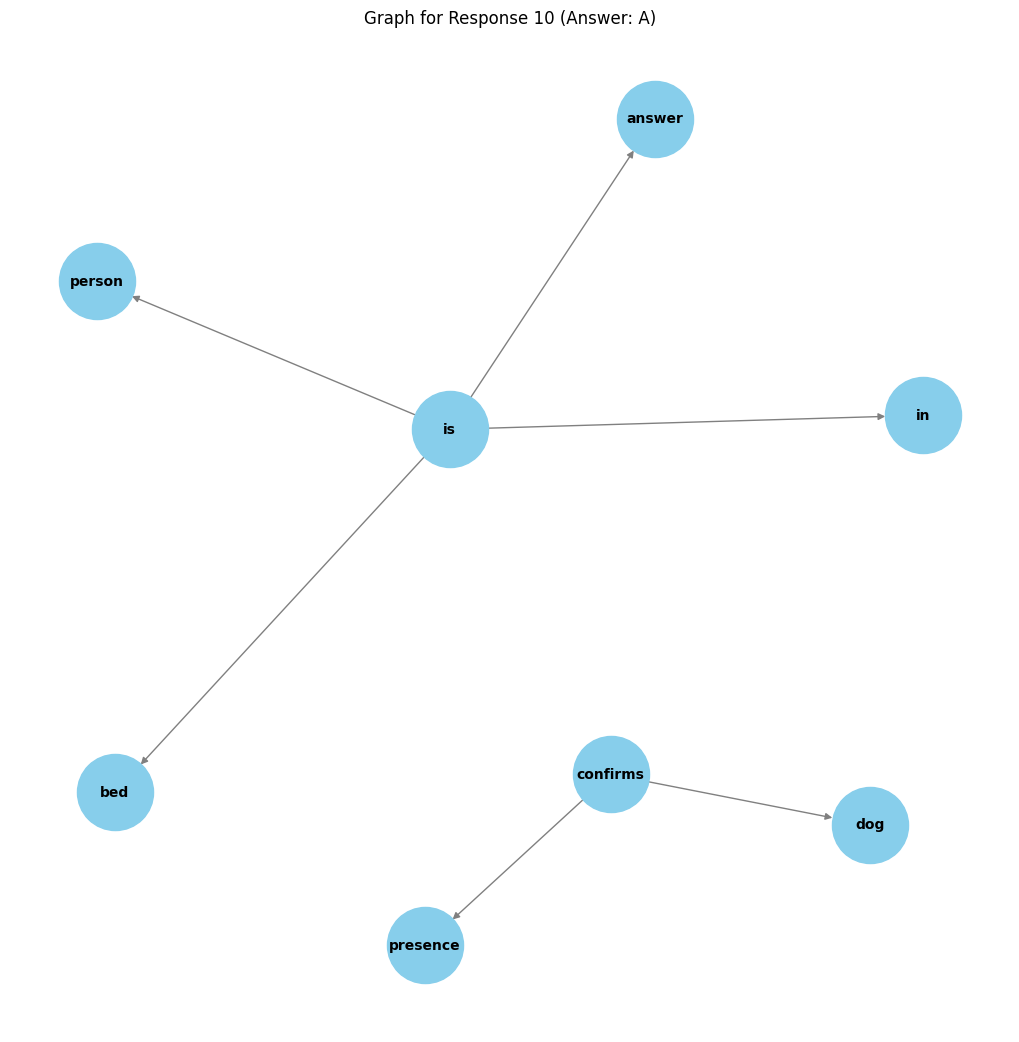

Explanation: There is clearly a bed in the image. A bed is a piece of furniture, often used for sleeping. The person in the bed is visible and appears to be resting. The dog sleeping next to the person on the bed also confirms the presence of a bed. Since there is clearly a bed in the image, the correct answer is 'A'.


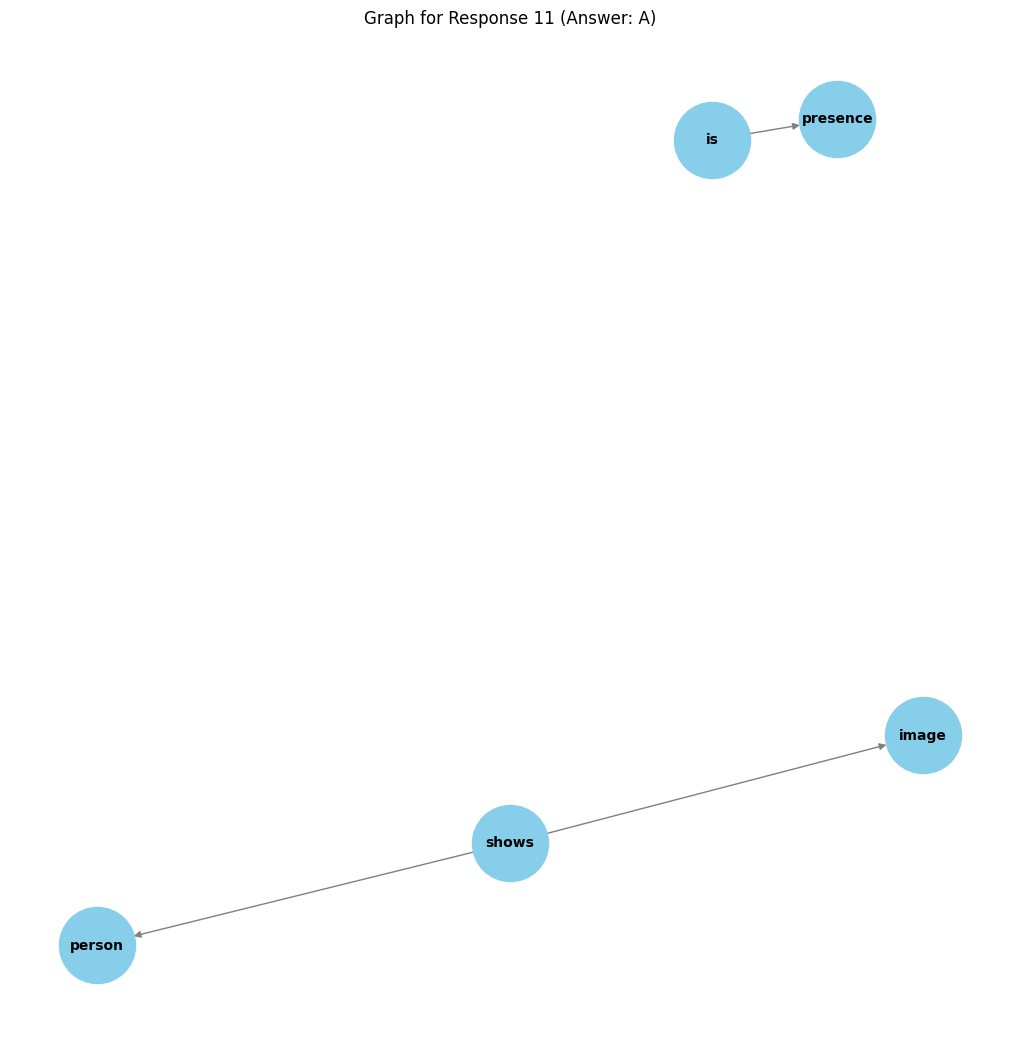

Explanation: The image shows a person sleeping in bed along with a dog lying on the bed as well. The presence of a bed is the most accurate description, as it provides comfort for both the person and the dog in resting positions. While there is no specific detail that completely excludes the possibility of other scenarios, 'bed' is the most relevant answer given the context of the image.


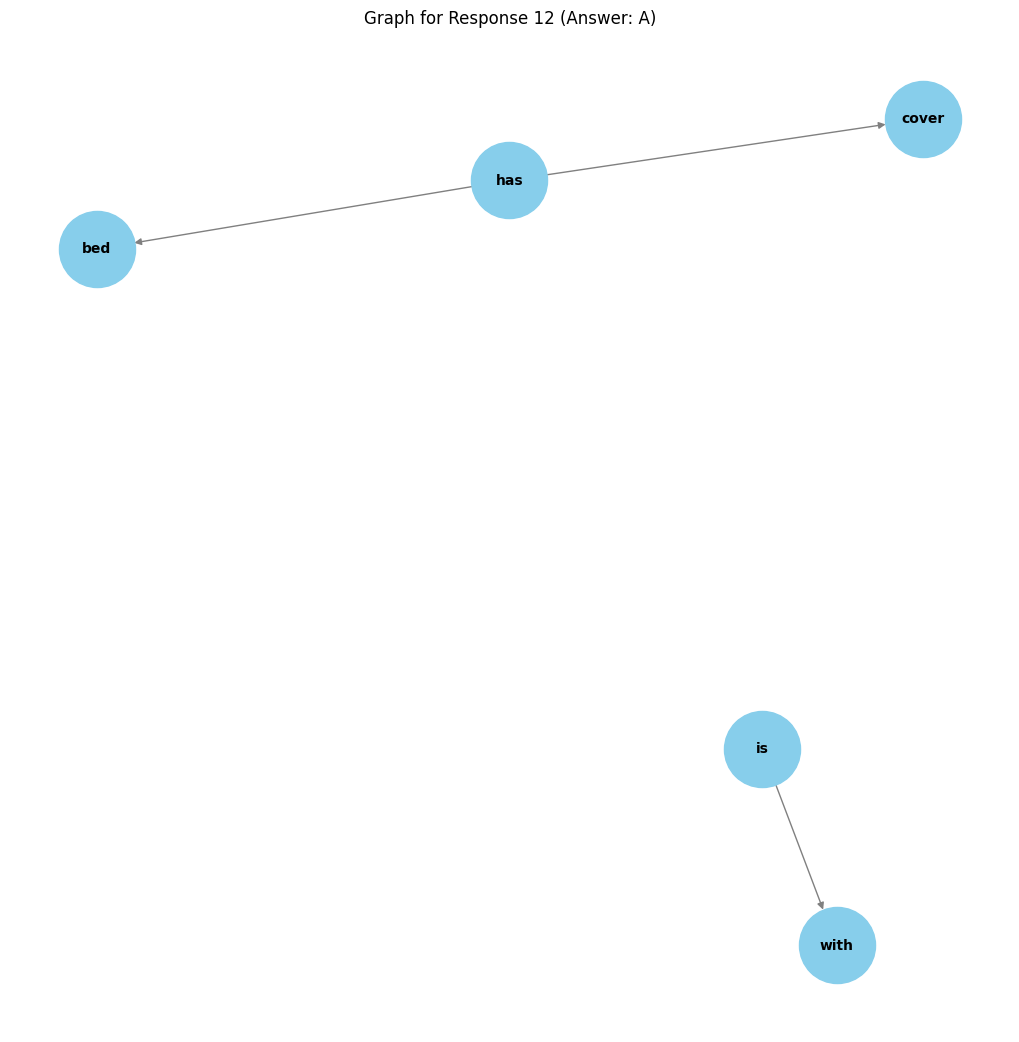

Explanation: Yes, there is a bed in the image with a man and a dog lying on it. The bed has a green or blue cover, and it is the main piece of furniture in the image.


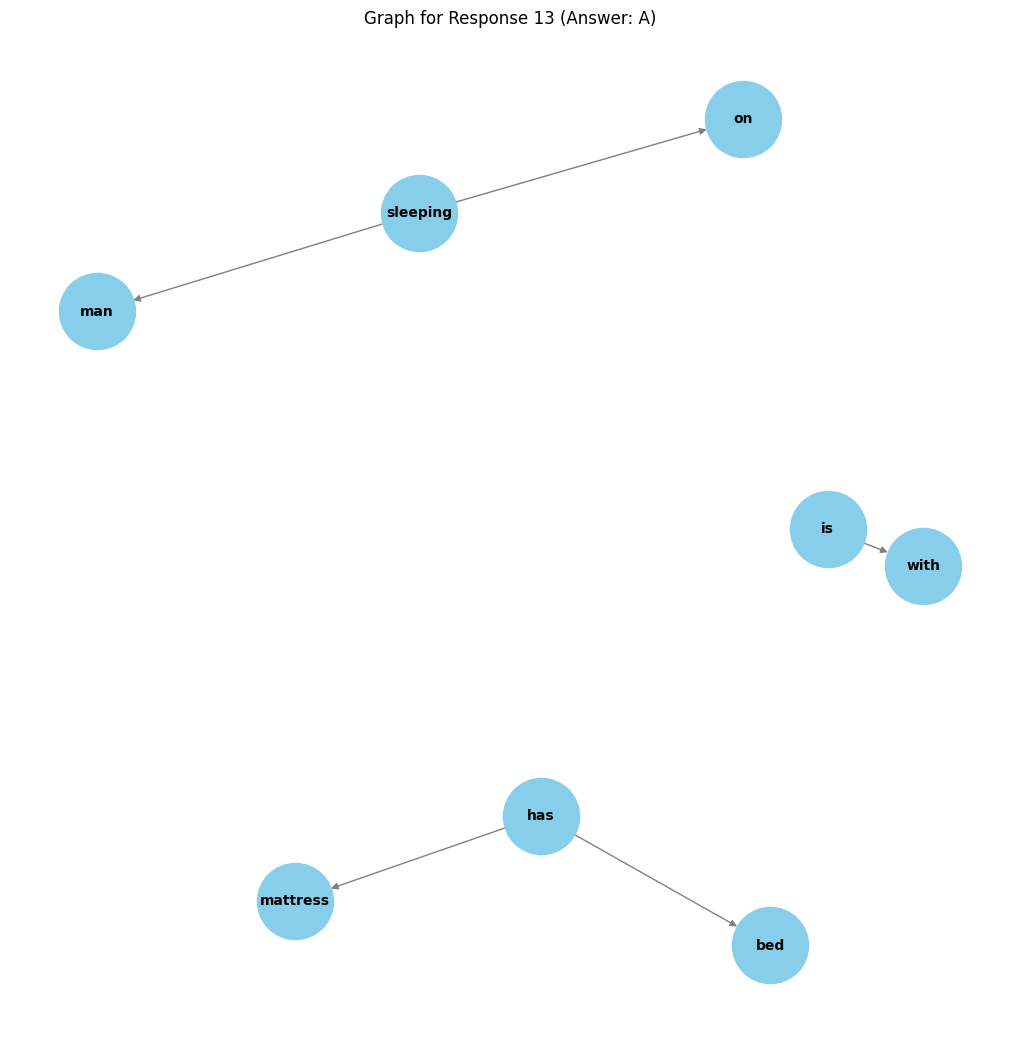

Explanation: There is a bed visible in the image with at least one side covered with a blanket. The man is sleeping on the bed, and a dog is lying on a pillow nearby on the foot of the bed. The bed has a mattress, a pillow, and a sheet with a blanket on top of it.


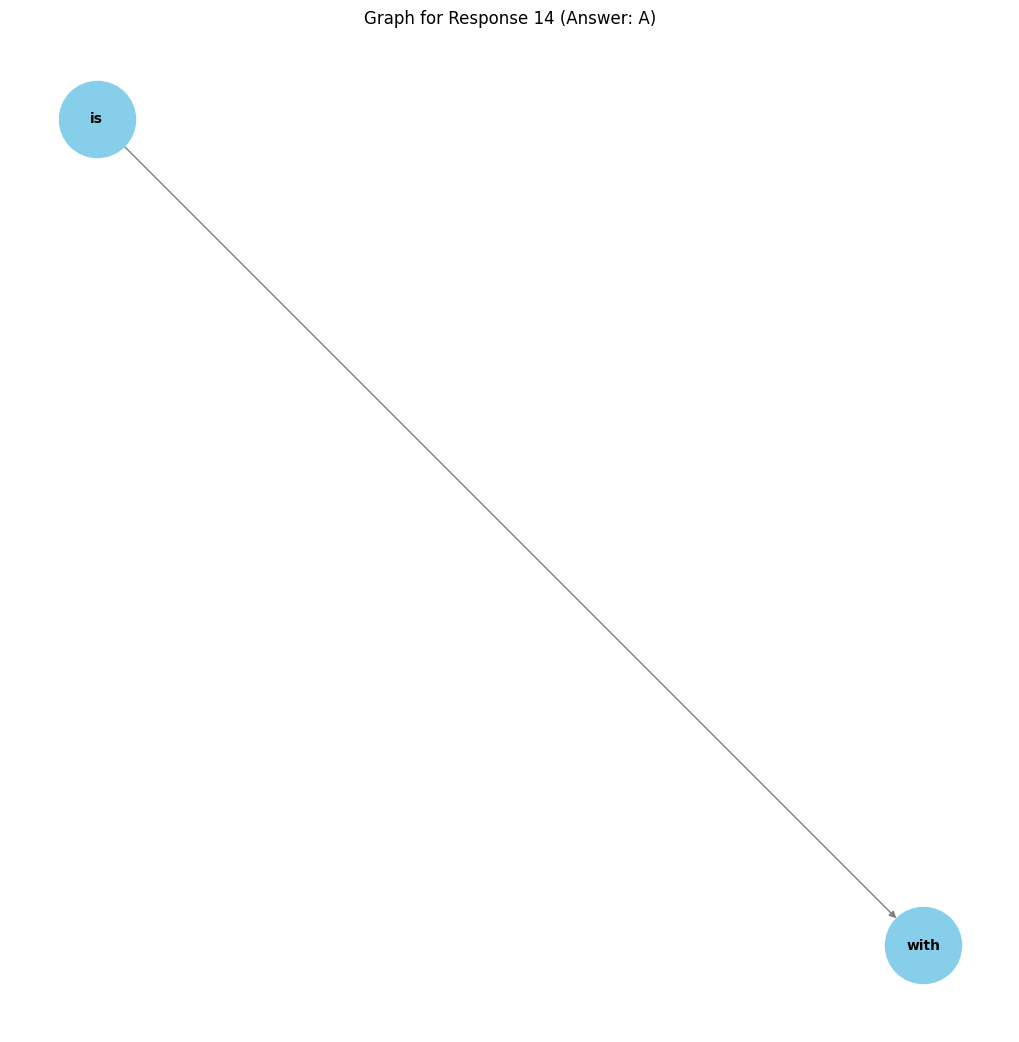

Explanation: Yes, there is a bed in the image with a man and a dog lying on it.


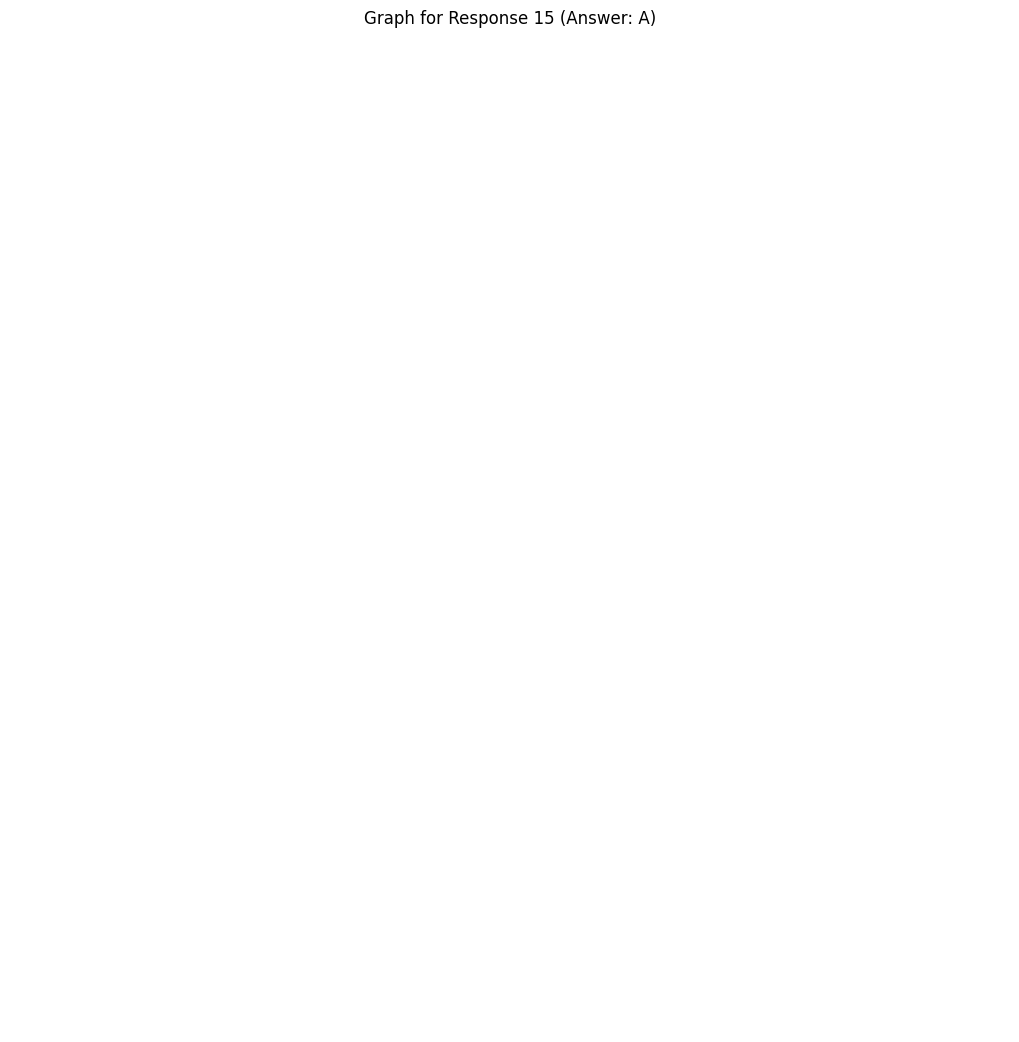

Visualizing for index: 2852
Explanation: In the given image, you can see a statue of a cow (or bull, as it could be interpreted as a bovine) with a fountain in the background that is spewing water. This suggests that the statue can be considered as being 'in' the fountain, as it is likely that the water jet is coming from the statue's body or water basin.


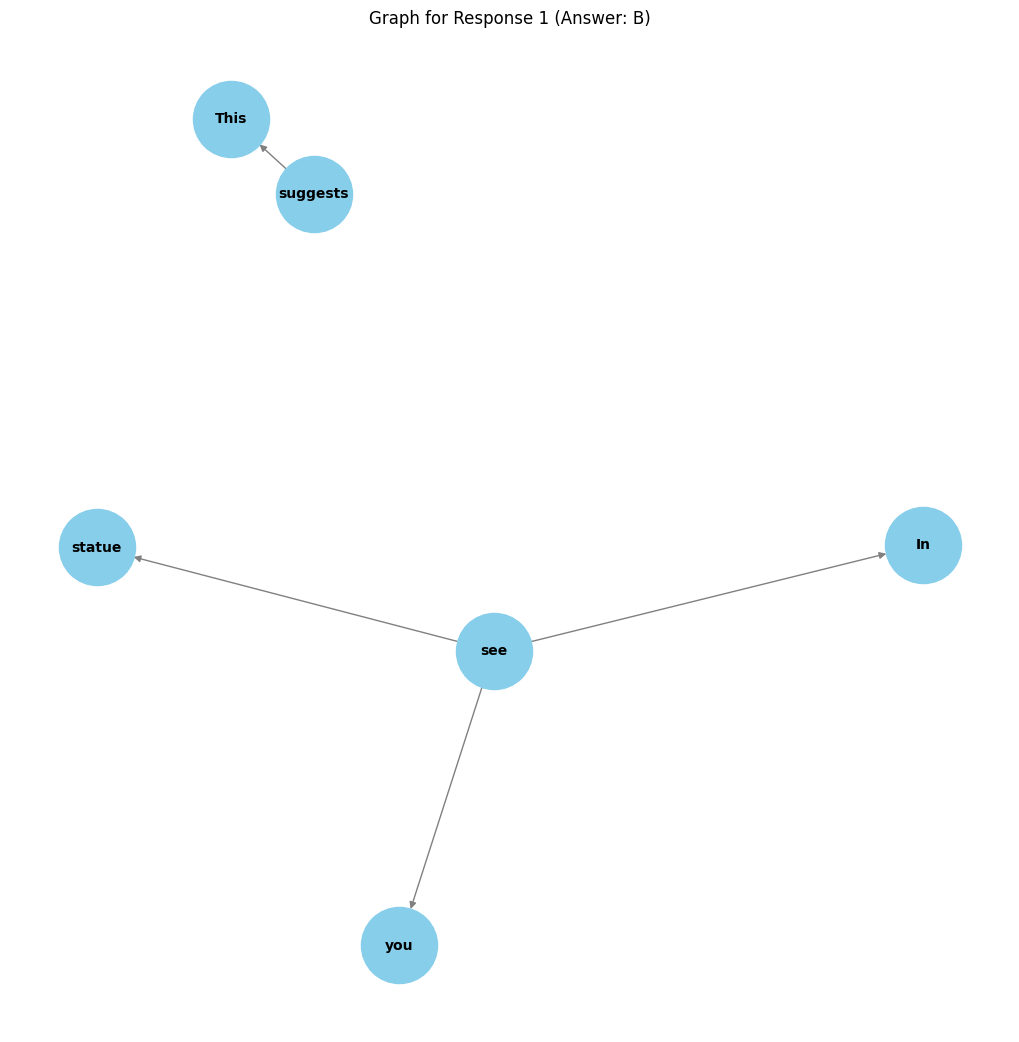

Explanation: The fountain is spraying water onto the statue of a horse rider, which is part of the image. The horse rider statue appears to be a large sculpture of a man riding a horse, with water spraying out from under the rider's legs to create the appearance of water flowing around them. Thus, the correct caption description is 'the statue is in the fountain' as the horse rider is not only part of the fountain but actually part of an art installation, which is not an inanimate object.


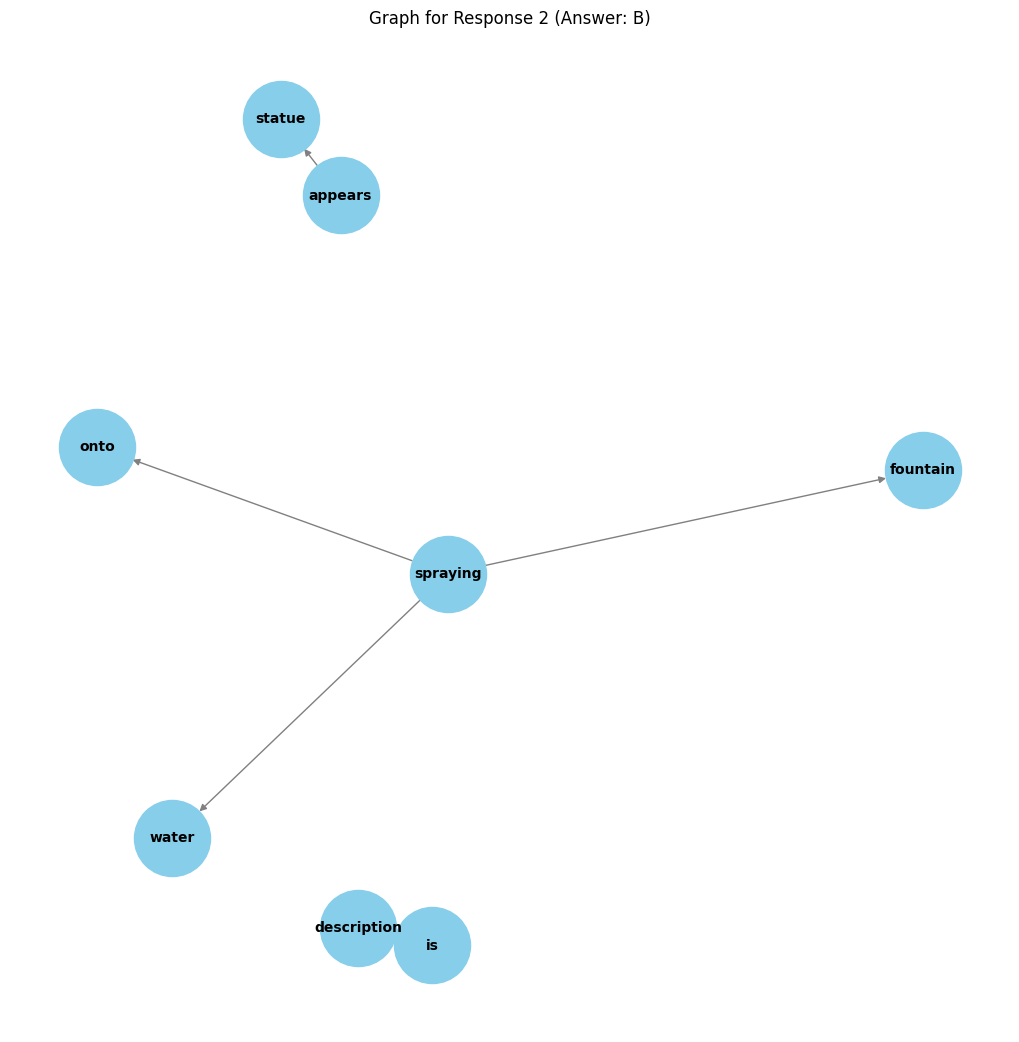

Explanation: In the given monochrome image, the statue appears to be 'in' the fountain, as the water surrounds the figures and the positioning and perspective suggest that the fountain water fills the entire area the statue and its surroundings usually occupy. While there is a statue sitting 'in' the water, that would be more typical and the word 'in' is not a good match for that. So, the correct answer is 'A' as the water seems to be in the space meant for the statue and its surroundings.


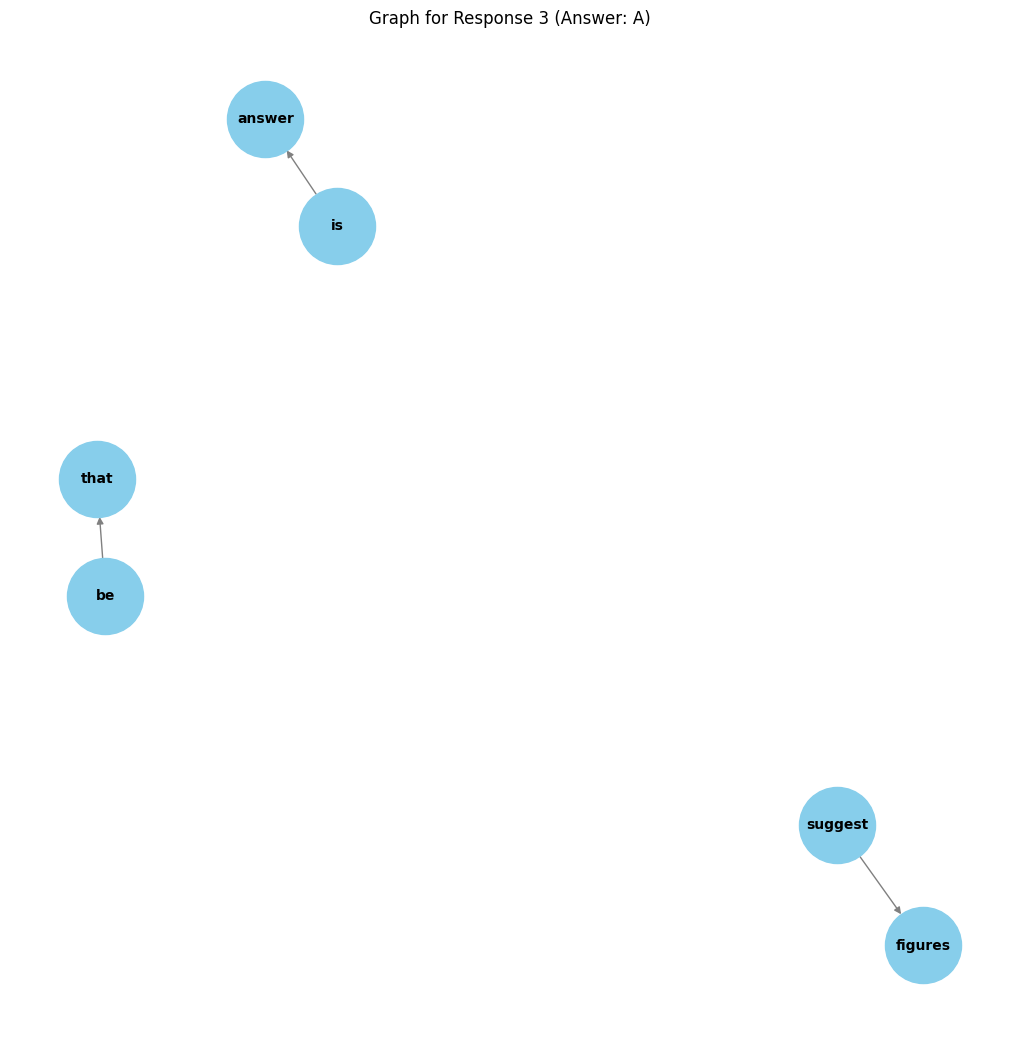

Explanation: The correct caption for the given image is 'the statue is in the fountain'. This can be inferred from the photo showing a statue with water flowing around it, indicating that the statue is physically positioned within the fountain. The statue is not just on top of the fountain - it is indeed an integral part of it. The flowing water creates a dynamic and integrated effect with the statue itself, which is being used as a design element of the fountain.


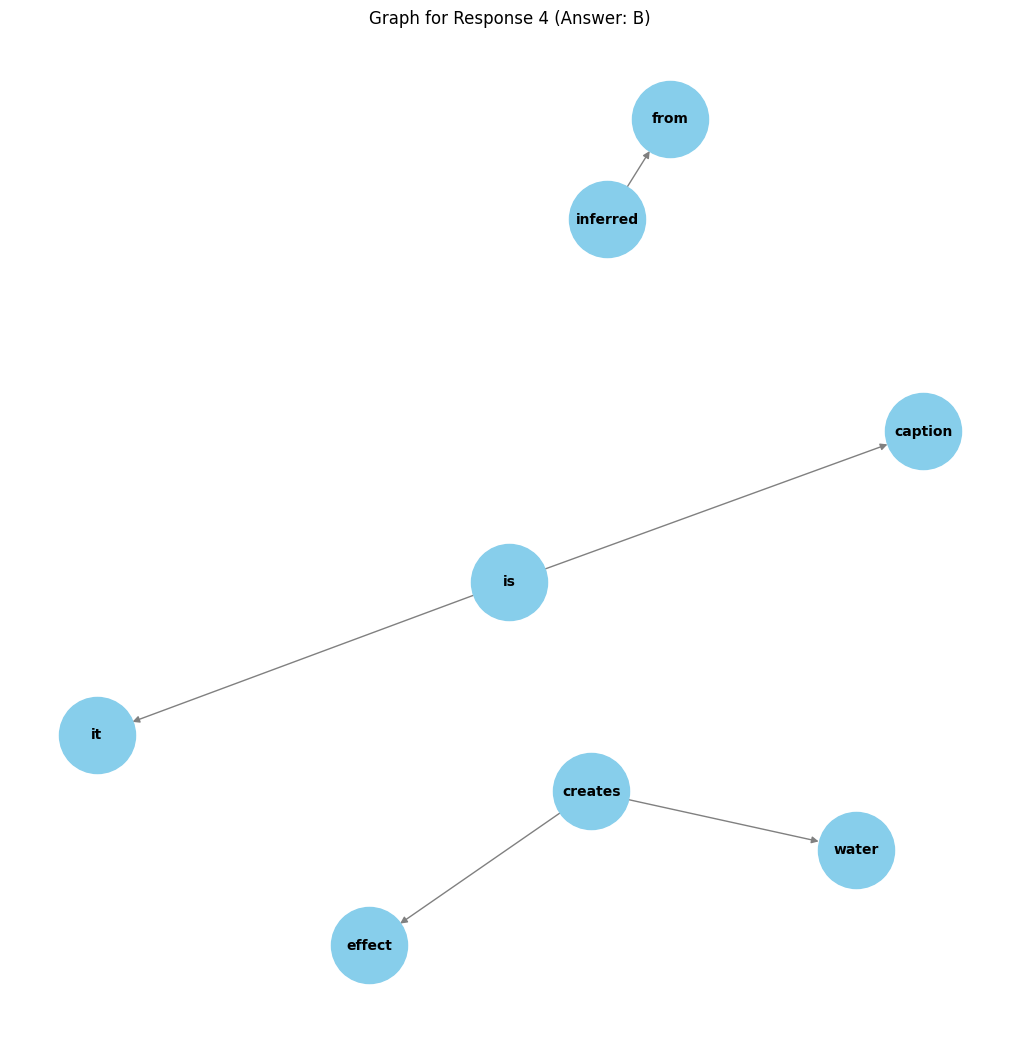

Explanation: The image shows a fountain spouting water around and interacting with the statue. This action suggests that the statue is placed within the fountain, as water is flowing around it. Hence, 'the statue is in the fountain' is the most likely answer.


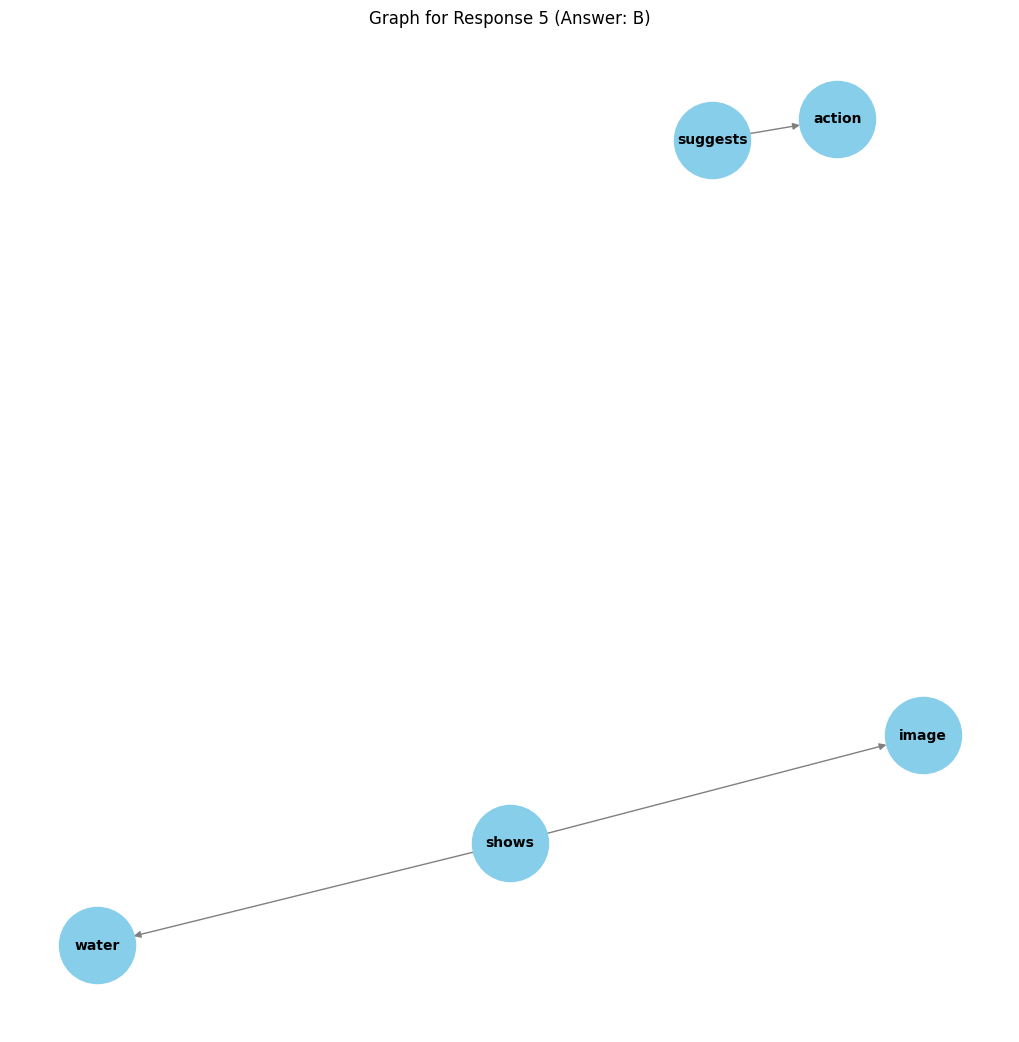

Explanation: The word 'in' refers to the relation between the statue and the fountain. The context implies that the fountain is in itself made up of the statue, rather than the statue being inside the fountain. In the caption descriptions 'being inside the fountain' is also referred to as 'in the water', and it is not a common interpretation of the word 'in'. Therefore, the correct explanation of the relation 'in' in the caption is 'being in the water' for option B, while the other options do not hold the correct interpretation. The confidence in this answer is 1.


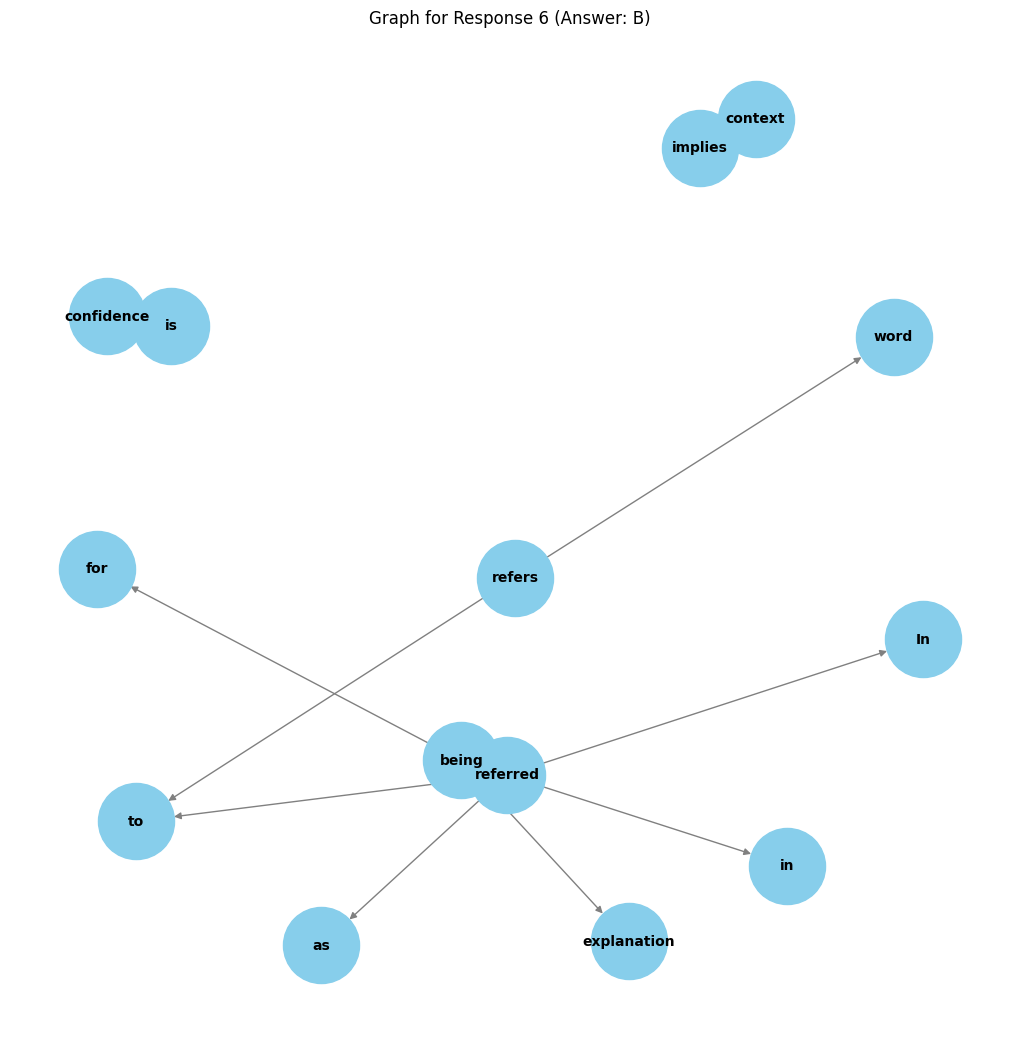

Explanation: The image shows a statue of a bull with water coming from its mouth, which appears to be a fountain integrated into the statue itself. It's not a case of a separate object (fountain) being located in a sculpture (statue). Therefore, the correct caption should be 'the fountain is in the statue'.


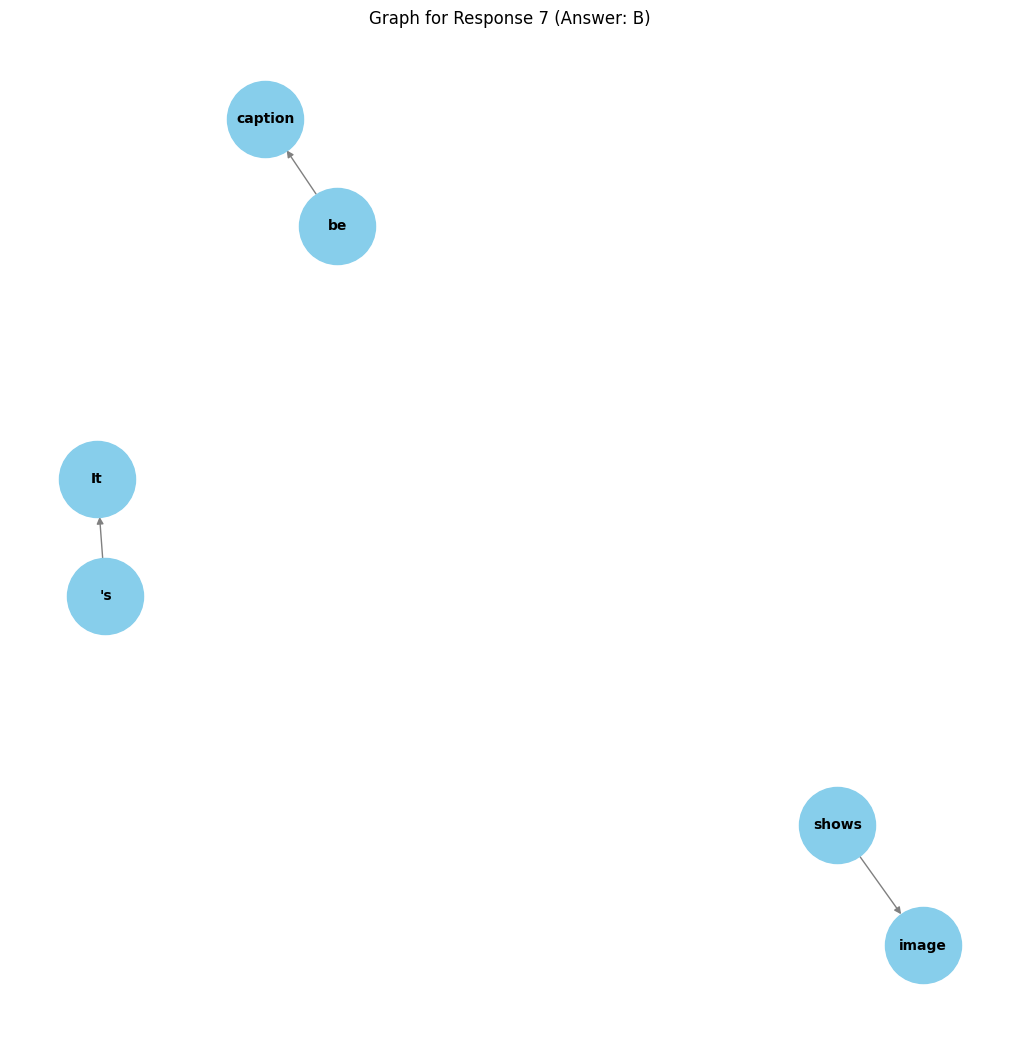

Explanation: The image depicts a statue of a horse rider with a water fountain behind it, suggesting that the statue is not inside the fountain itself. It's likely that the fountain is in the background and the statue is for decorative purposes to be appreciated while visiting the water fountain. Option A and C seem to mix up the statue and fountain, and D is not related directly to this caption context.


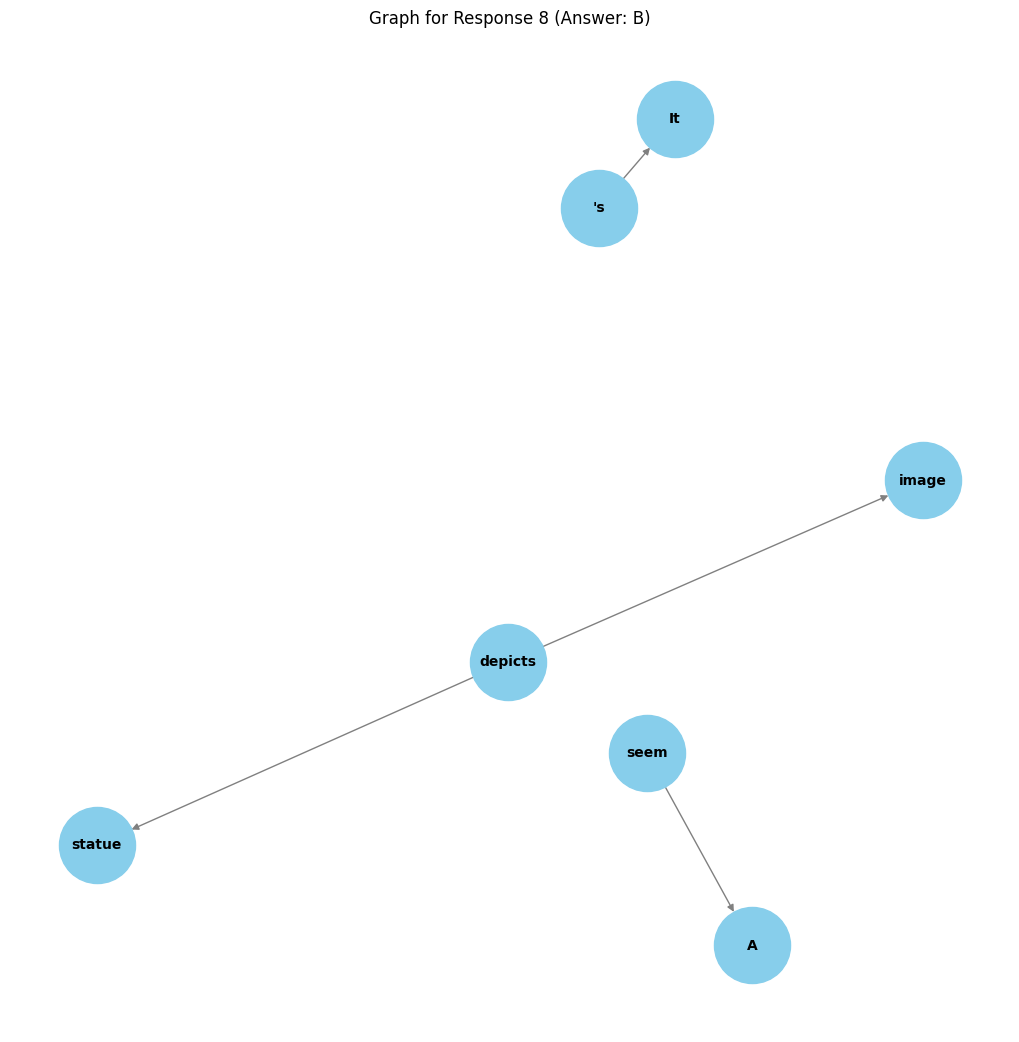

Explanation: The statue is depicting a rider or a person who is holding the reigns of a horse. This is an artistic portrayal, so it's not in the literal sense when one imagines a person 'in' water as if they are part of it, but it could be interpreted as the statue being surrounded or in the middle of a fountain. Since the object is a statue, it is inanimate, so the concept of 'in' doesn't apply to it. If seen from another perspective, the rider might seem to be riding above a water feature, so option B is more accurate. Option A doesn't relate to this scenario at all, and option C or D doesn't have any meaning in the context of this specific image.


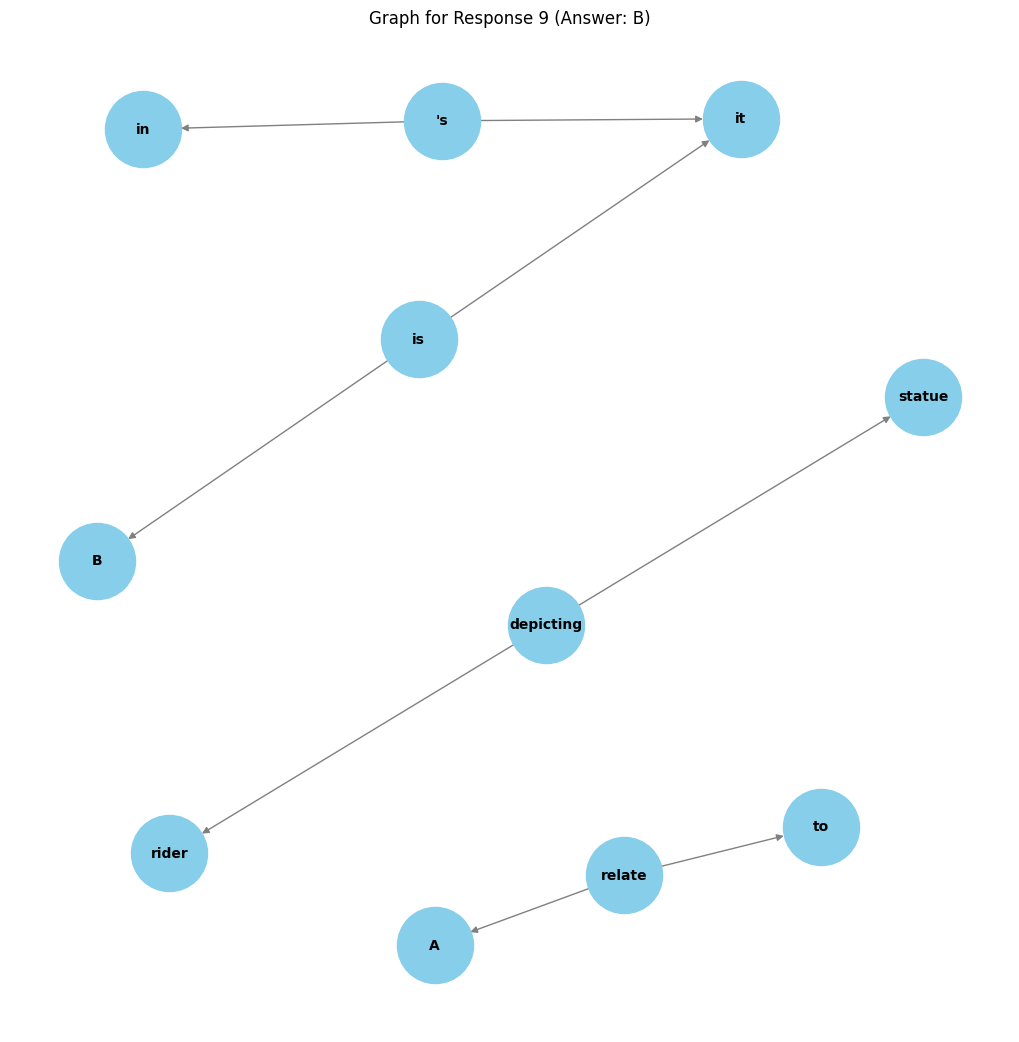

Explanation: From the given image, the statue with a horse rider and a bull is actively spraying water from a fountain. The statue is clearly being used as a component within the fountain. Therefore, the correct caption would be 'the statue is in the fountain' as both the statue and the fountain are integrated within the same image.


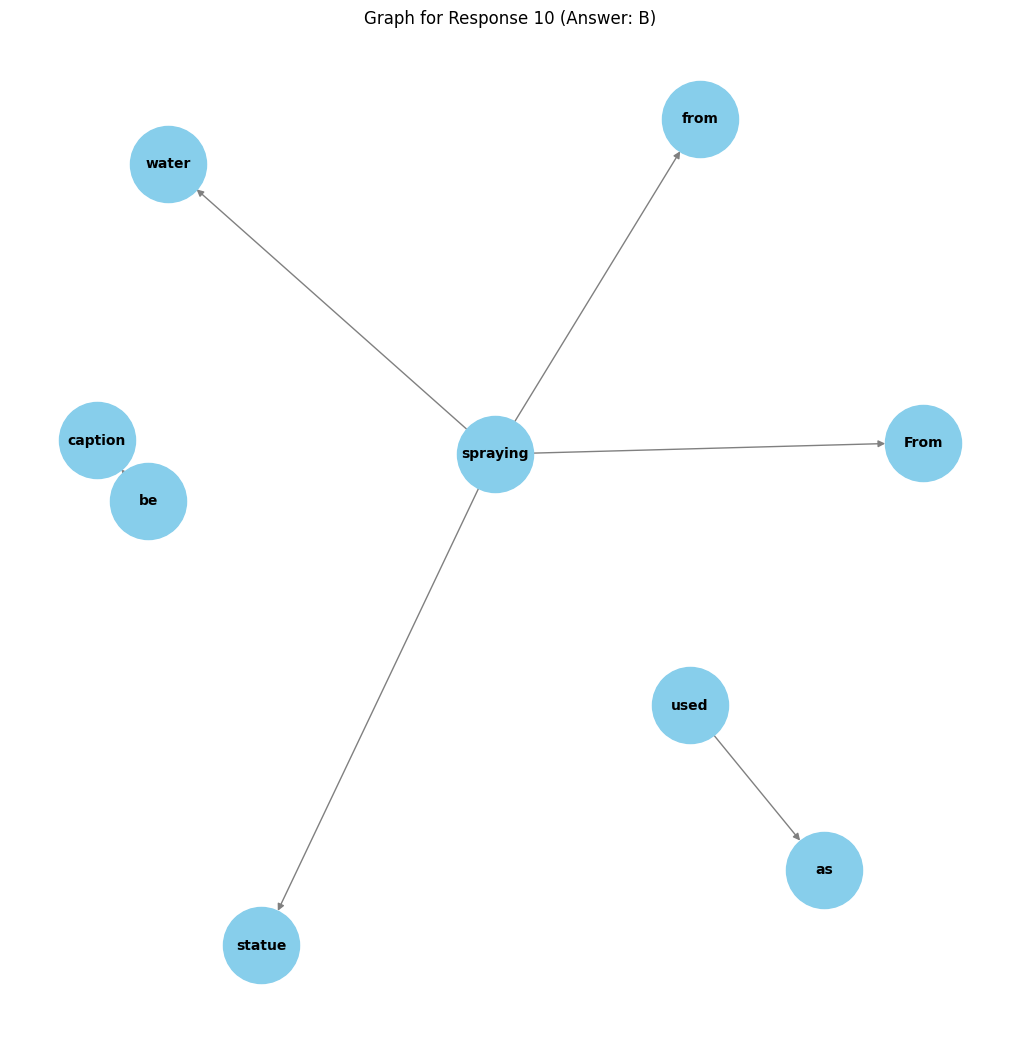

Visualizing for index: 2863
Explanation: The image depicts a black bear crossing a road from one side to the other, which matches the 'crossing the road' caption as a more active and accurate description of the action in the scene. The other captions, while valid in different contexts, do not correctly describe the bear crossing the road. Choice D is incorrect because the road is not crossing the bear. Choice B is incorrect because the road is being crossed by the bear, not the road crossing the bear


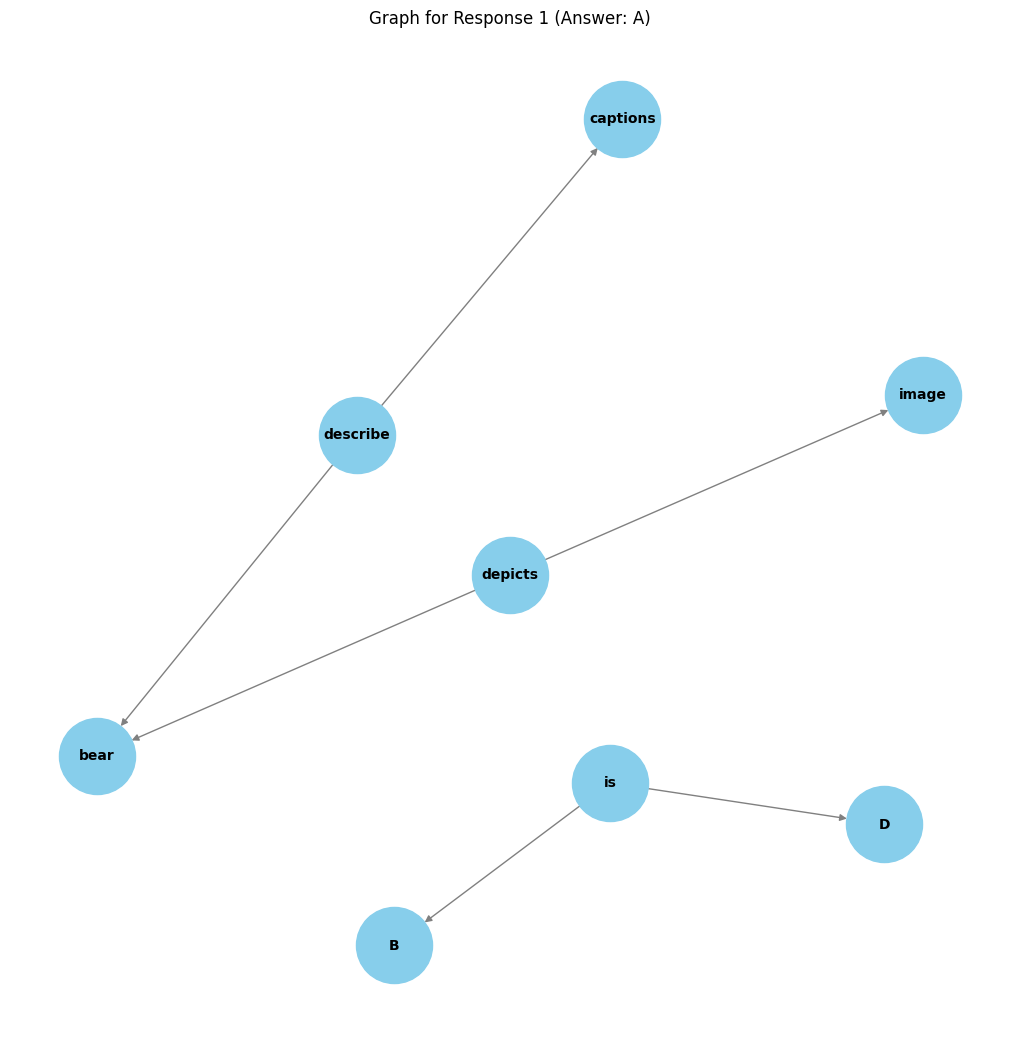

Explanation: The bear is crossing the road in this image. The road appears to be empty, and the bear is walking from the left toward the right side of the image, indicating it is the main subject and the focus of the scene. The term 'crossing' implies an action where one thing extends or overlaps another, and in this case, the bear is in fact crossing the road over a long distance, making this the most fitting description. The other options may not fully capture the concept of crossing, which is the correct label for this situation.


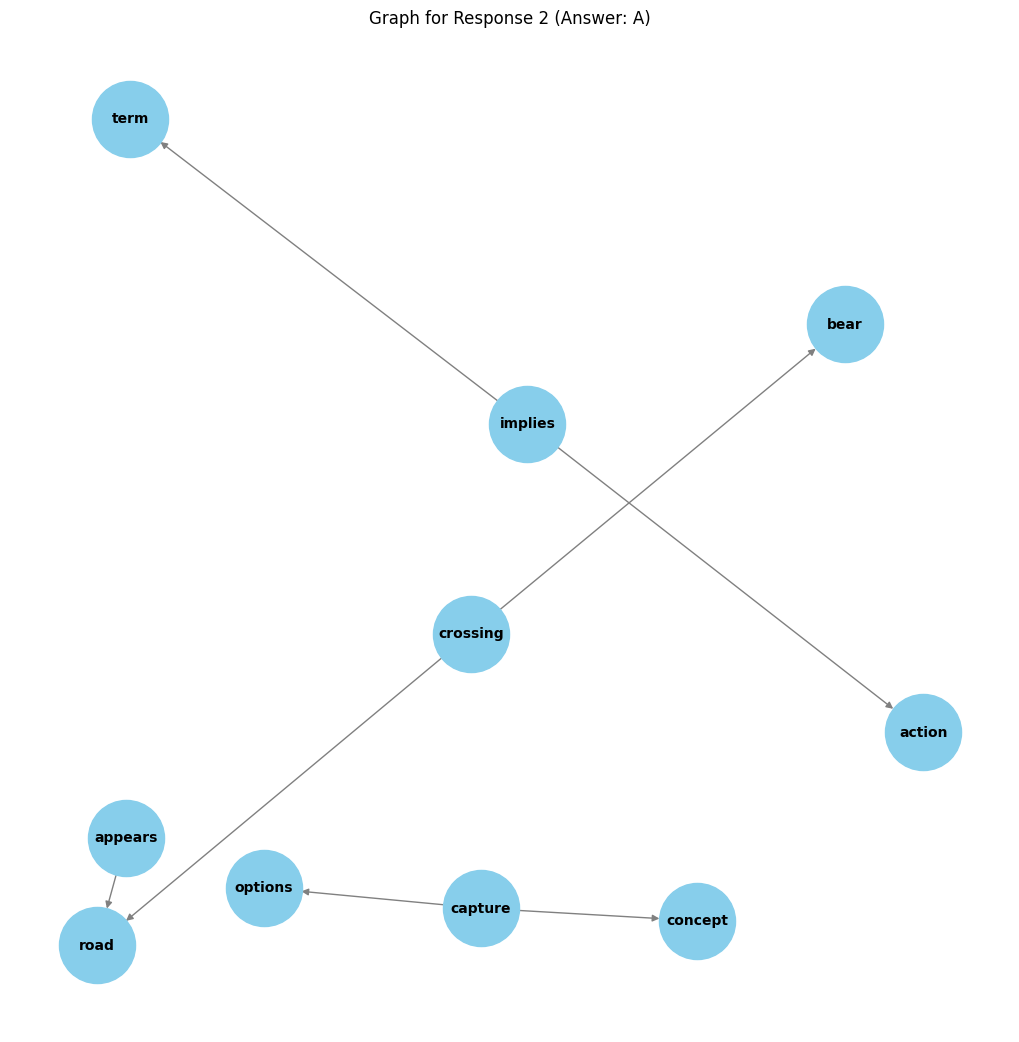

Explanation: The bear is crossing the road, and the road is crossing the bear as they both move through the environment. 'Crossing' is an appropriate description for the interaction that is observed in the image. It is the only one of the given options that accurately describes the bear's actions in the depicted photo.


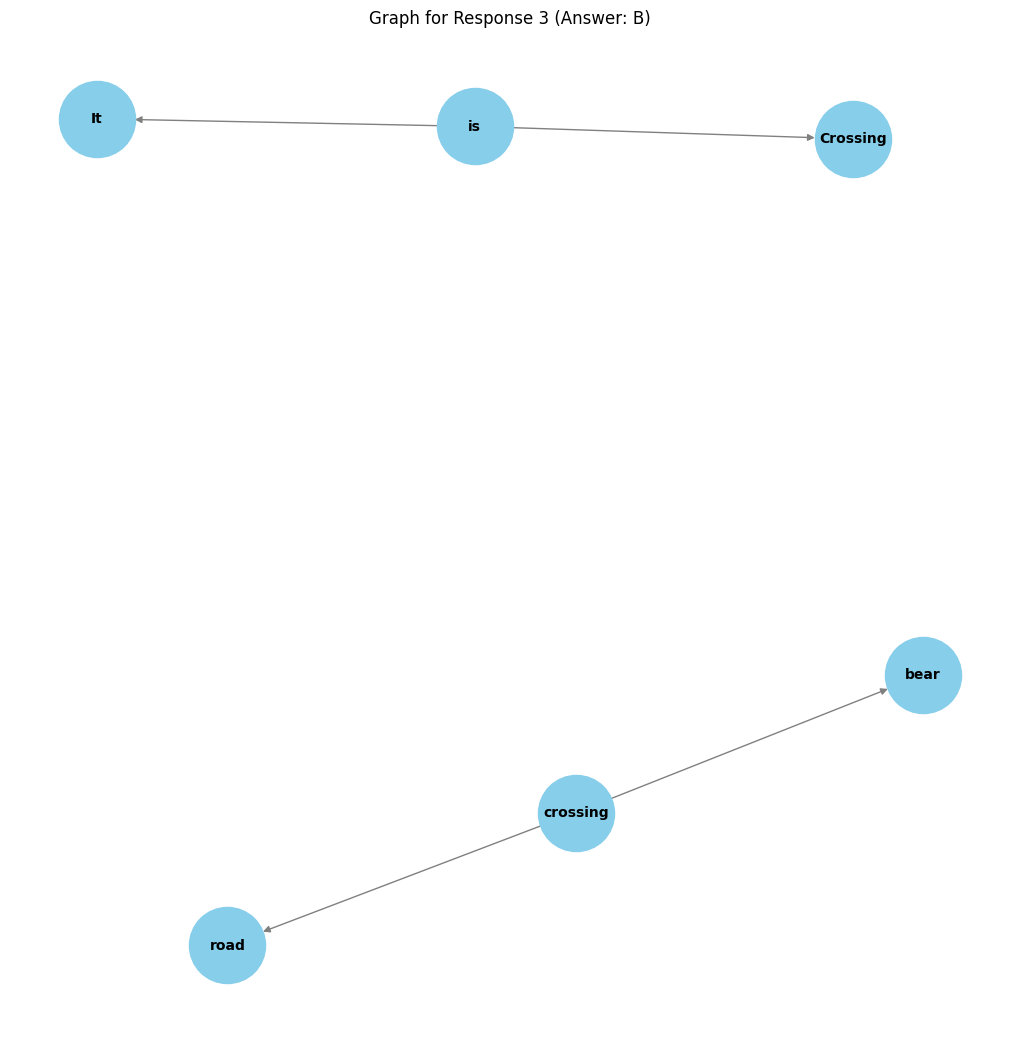

Explanation: The bear is crossing the street by itself, which means that the bear is passing over the road. In this context, the road is not crossing the bear, and the bear is not crossing itself. The bear is a significant subject in the image, walking across the road that is meant for vehicles, indicating a separation of the bear's environment from traffic. Therefore, the correct caption is 'the bear is crossing the road' to accurately describe the scene depicted in the image.


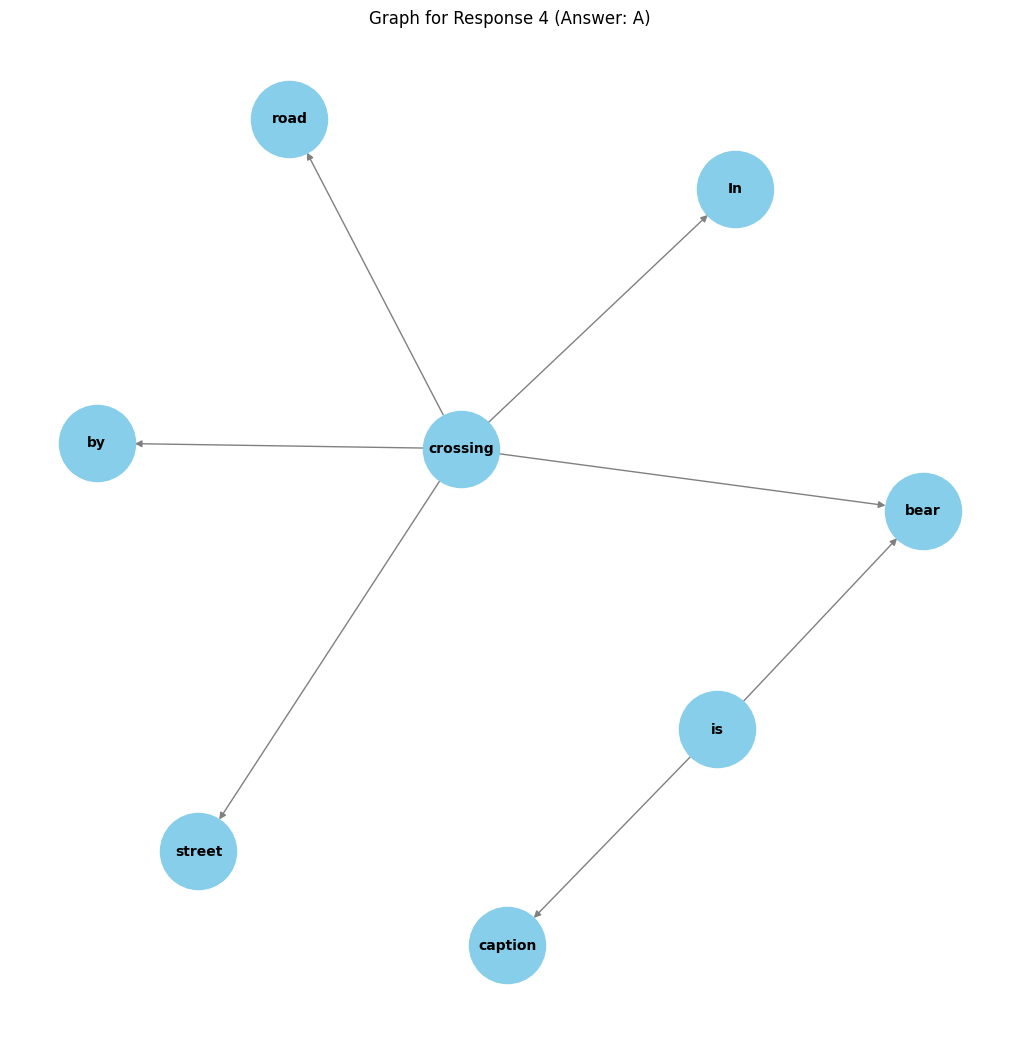

Explanation: The bear is crossing the road. The bear is actively moving across the road, which indicates it's the most 'crossing' action in this context.


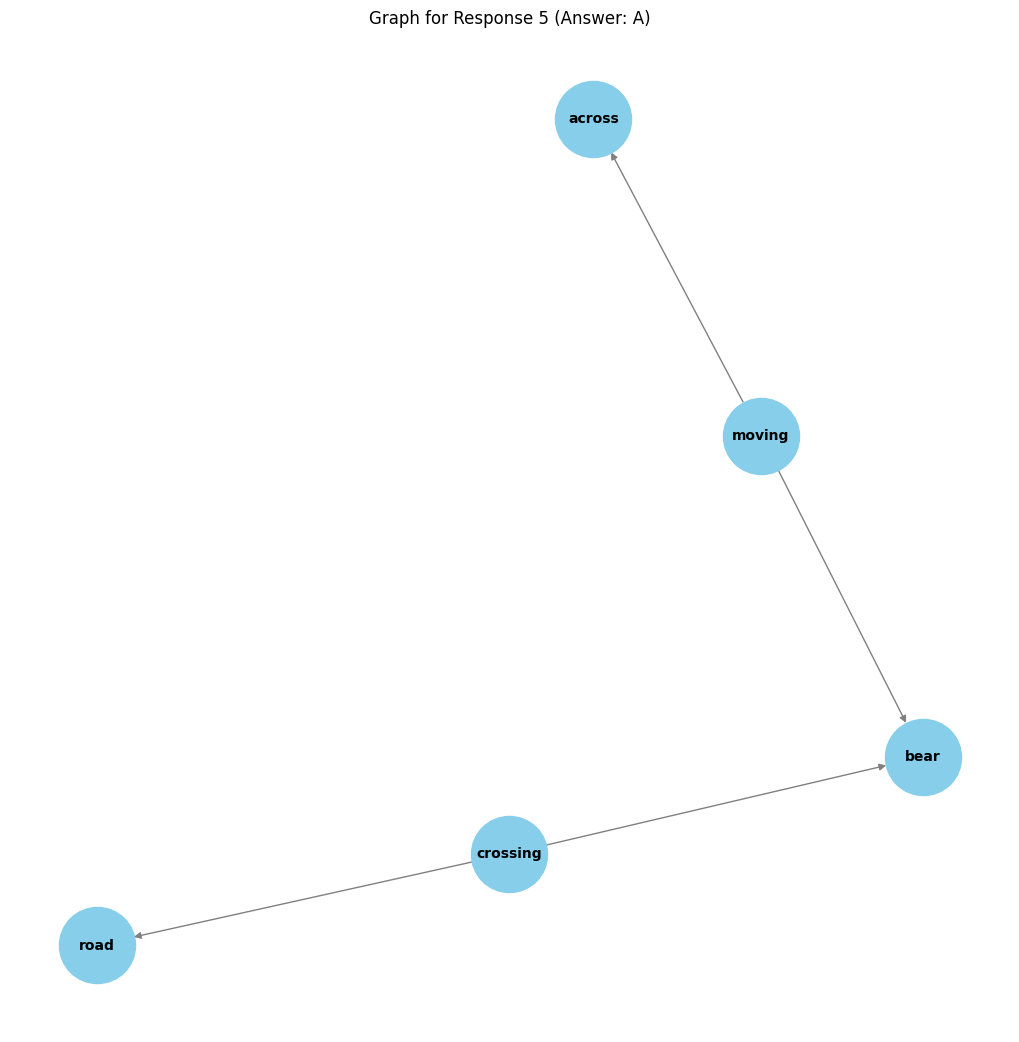

Explanation: The bear is walking across the road, making it the correct caption. The image shows a bear walking along the road in the middle of the image, indicating it is the primary subject of the image interacting with the road.


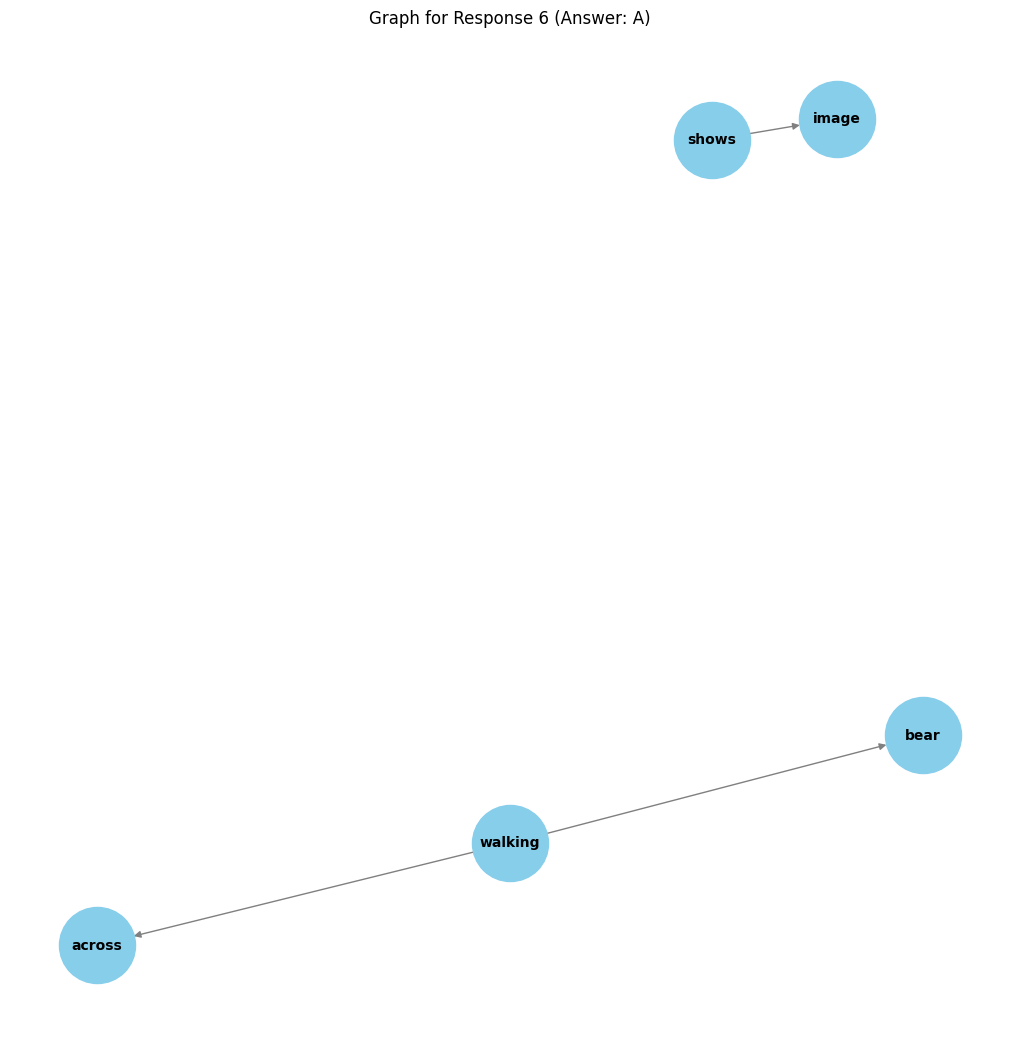

Explanation: In the image, the bear is crossing the road as it moves towards the camera on the empty winding and wooded highway. There is no indication of the road crossing anything or being cross-ed by any objects or animals. The bear's proximity to the camera suggests that it has been recently observed or is present at the moment of the photo, not that it is crossing something in the distance. Therefore, 'A' is the correct answer.


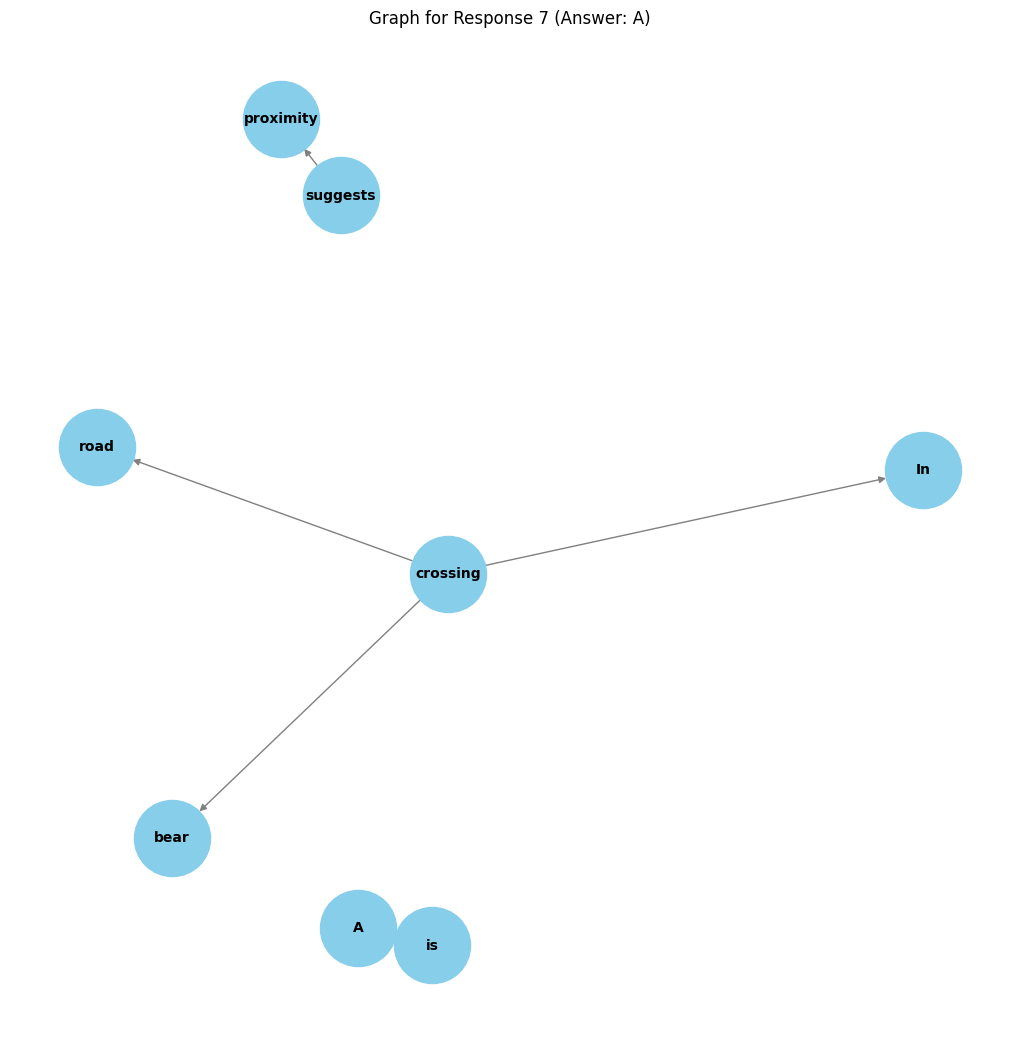

Explanation: The image shows a wild bear, specifically identified as a black bear, walking across the street, which is a concrete road. As the bear is actively crossing the street, it aligns with the use of the term 'crossing' and not 'road crossing', as this context specifically relates to the bear moving from one side of the street to the other. Consequently, option A is the most likely answer.


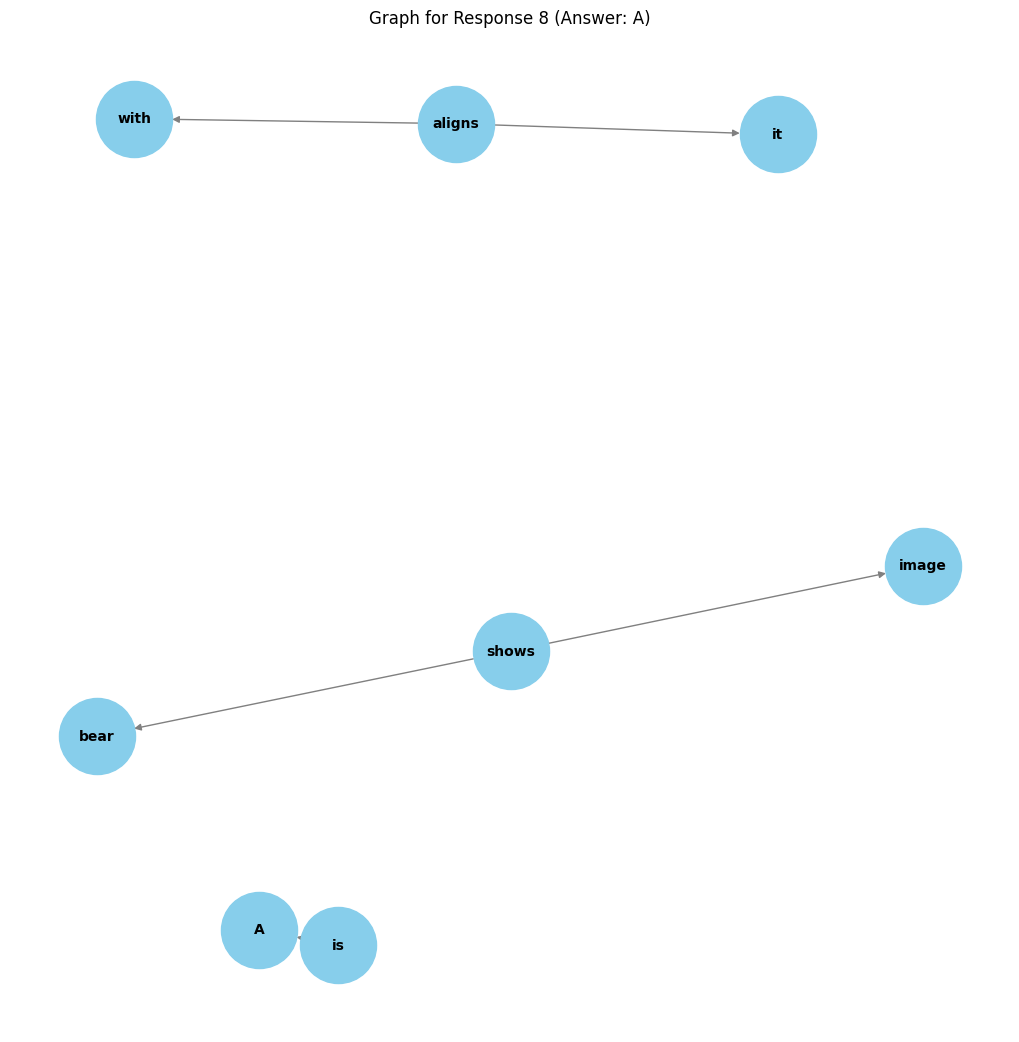

Explanation: In the image, a bear is shown walking across the road. There is only one correct caption in the given options, which is `A`, 'the bear is crossing the road'. 'A' is the most likely answer because the bear is the main subject and it is depicted actively crossing the street.


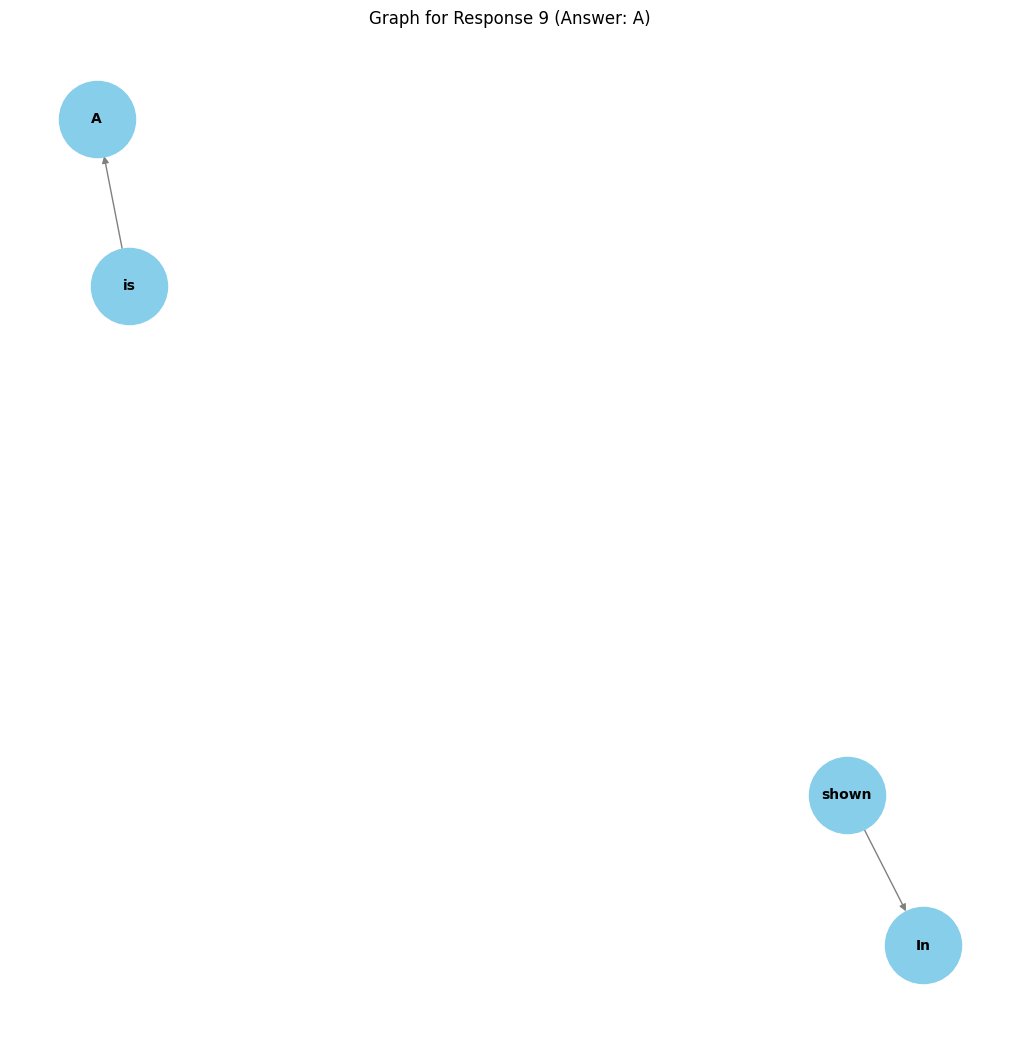

Explanation: The bear is crossing the road, and the road is effectively a bridge with two sides. This is consistent with what would be generally understood as crossing the road. In the image, the bear is clearly crossing the road in a wildlife area, where roads run through forests. The other captions do not fit the context of the image.


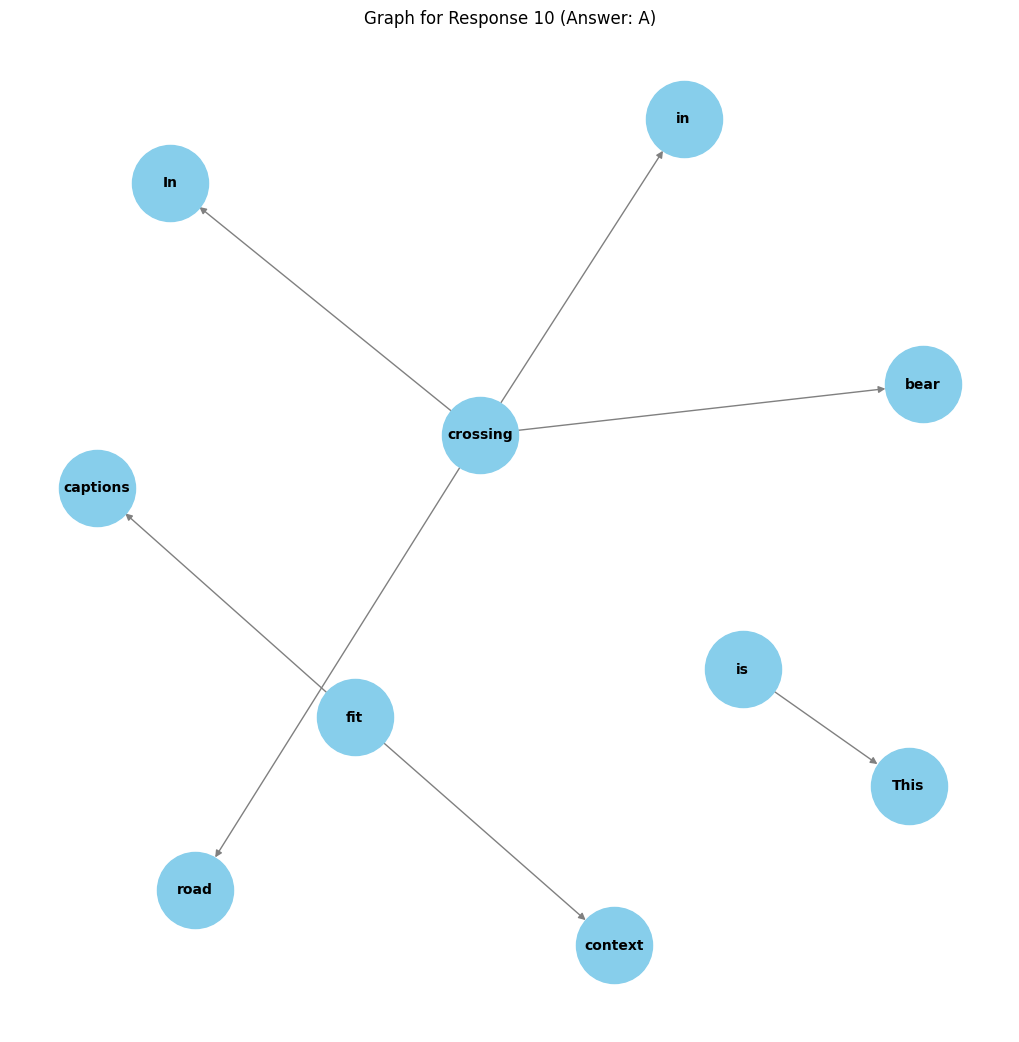

Explanation: The bear appears to be crossing the road from its left or right side, depending on the observer's perspective, but the actual crossing is going on in both the bear and the road direction. The correct description would be 'the bear is crossing the road' since the bear is the main subject in the image and the road is an inanimate object.


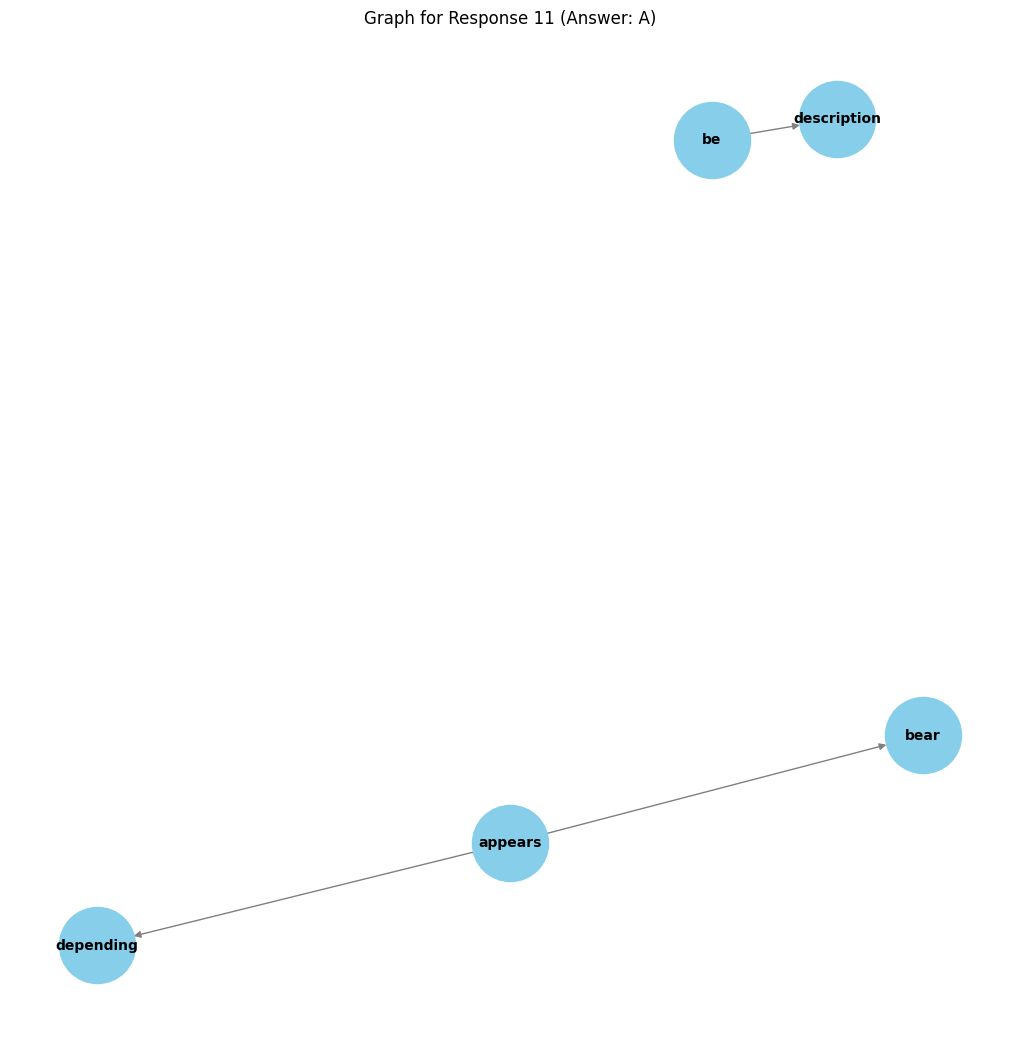

Explanation: The caption accurately describes the scene as the bear is crossing the road, not the other way around. Although there is only a single bear in the image, it's walking across the road, which means it's crossing from the animal's perspective into the human's perspective (as seen from the driver's point of view).


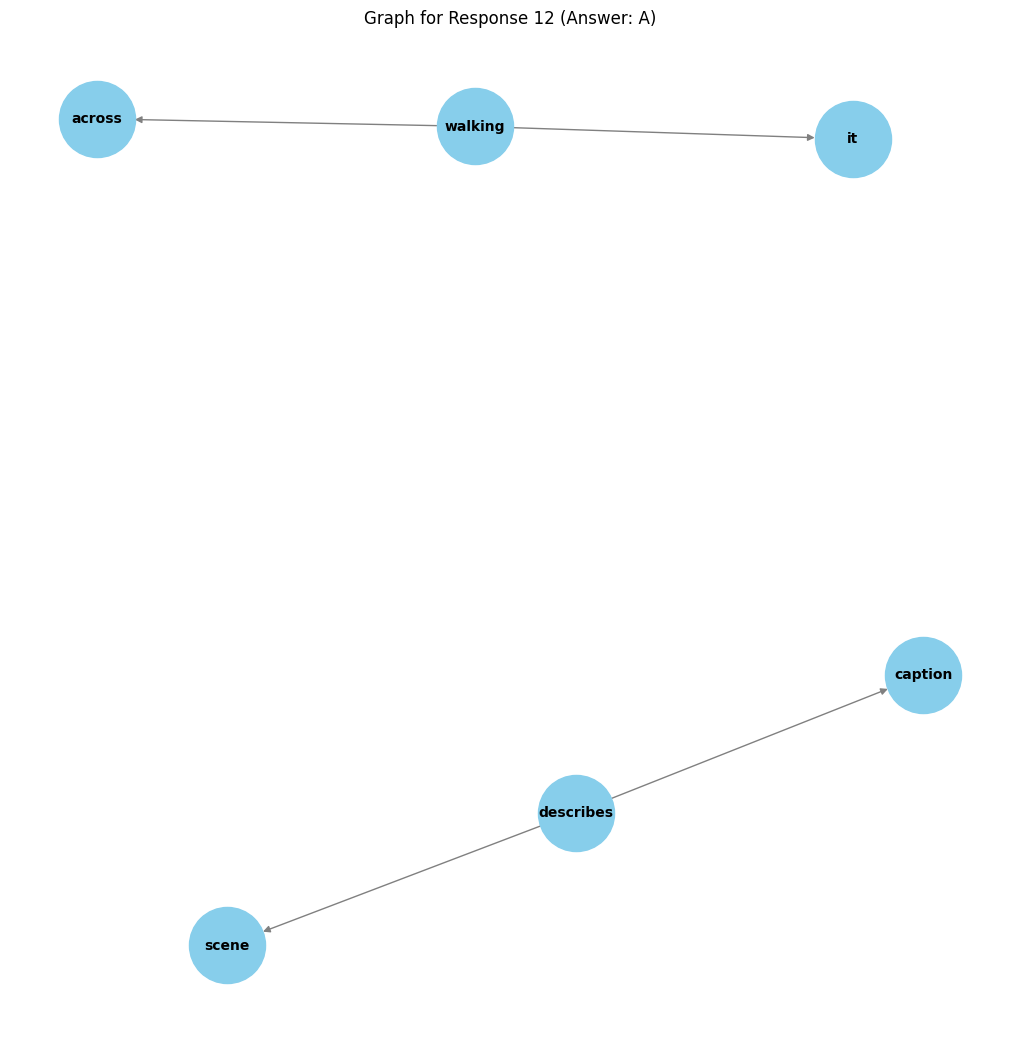

Explanation: The bear is crossing the road, this statement accurately captures the action in the image where the bear is physically positioned on the road, with its front leg and head in the camera's frame. The other statements do not apply to the situation depicted in this image.


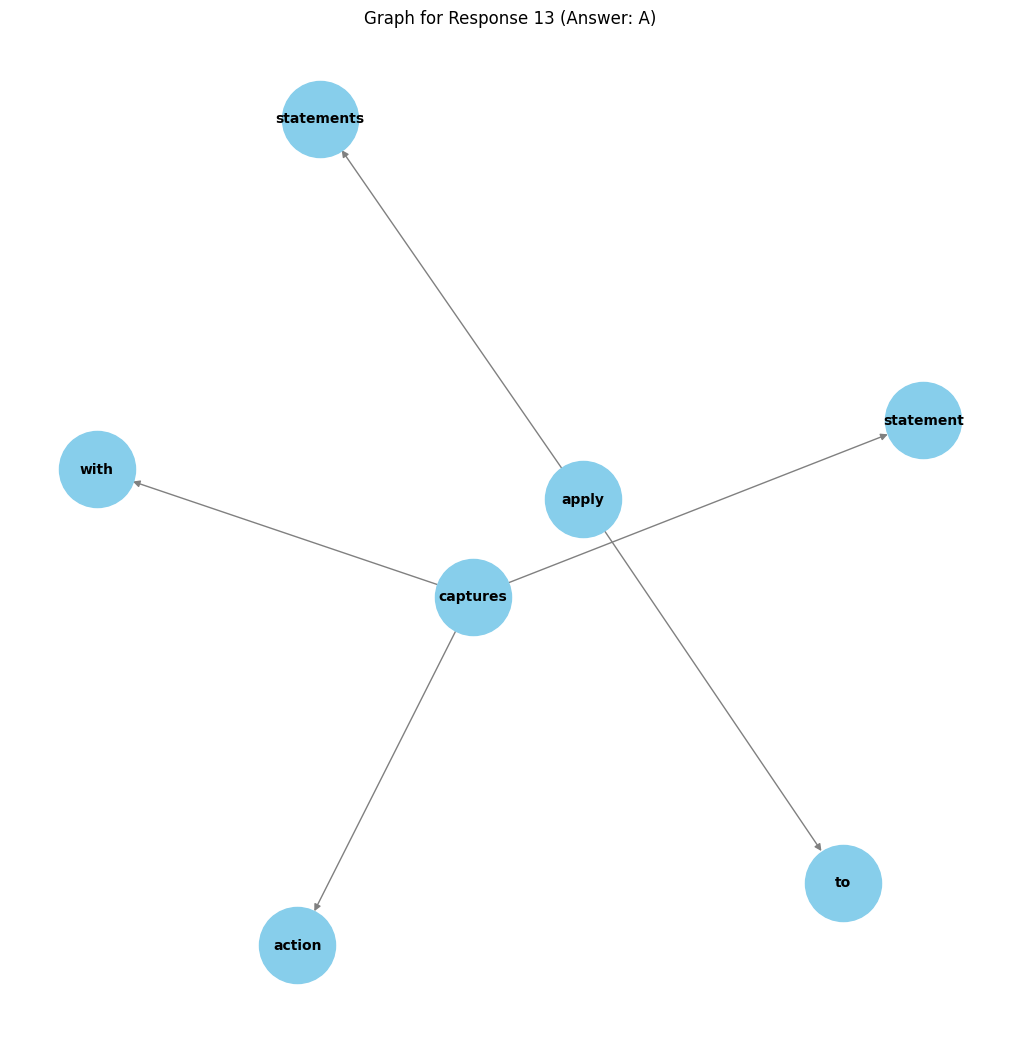

Explanation: The bear is crossing the road, not the road crossing the bear, since it is a living animal that interacts with its environment. The road does not have the ability to move or perform actions on its own. Furthermore, the context of the sentence and the presence of the bear on the road in the image implies that the 'crossing' scenario is the bear crossing the road.


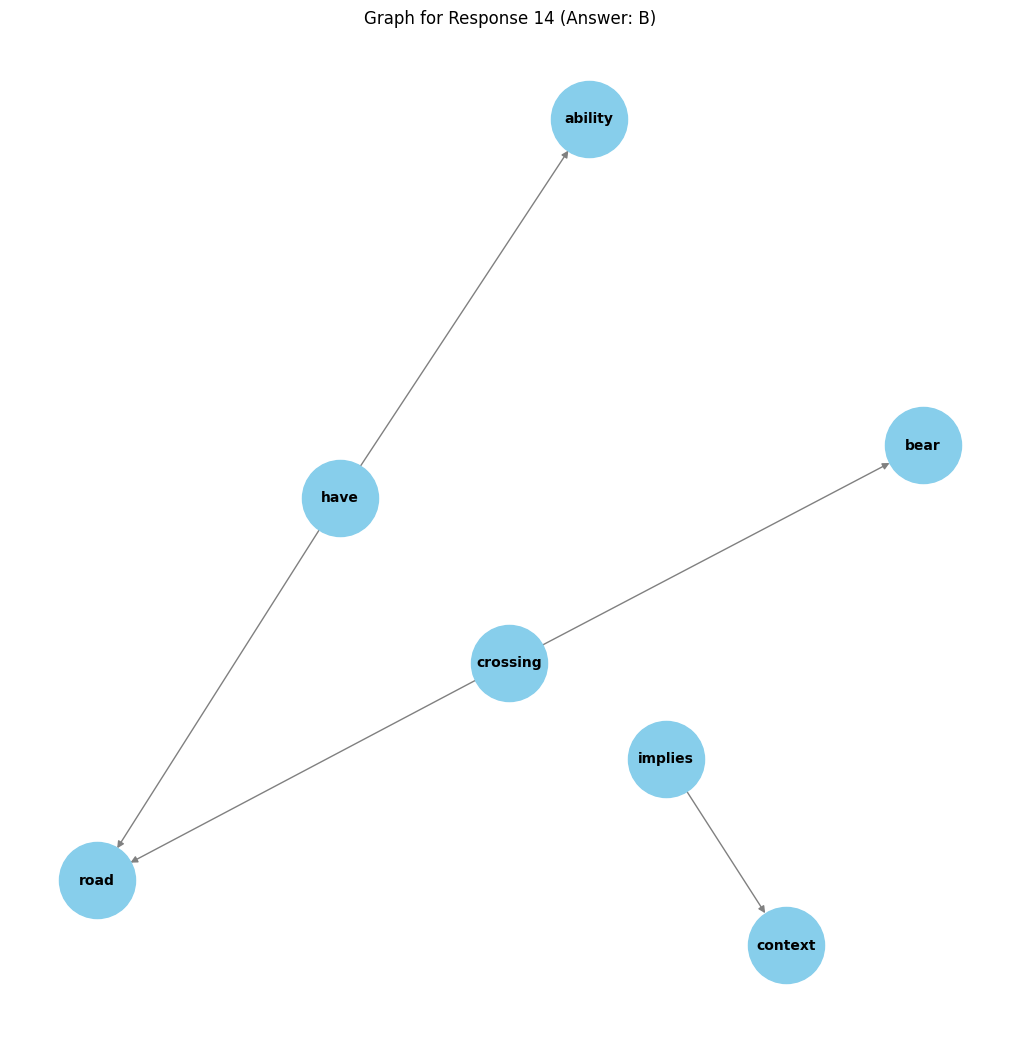

Explanation: The context provides a clear indication that the bear is actively crossing the road, as there's a description of the animal 'crossing a paved road.' The image shows a bear walking across the road, which fits the described scenario. The bear is the subject actively engaging in the action of crossing the road. As the options do not match the image content, the confidence in the correctness of this answer is 1.0.


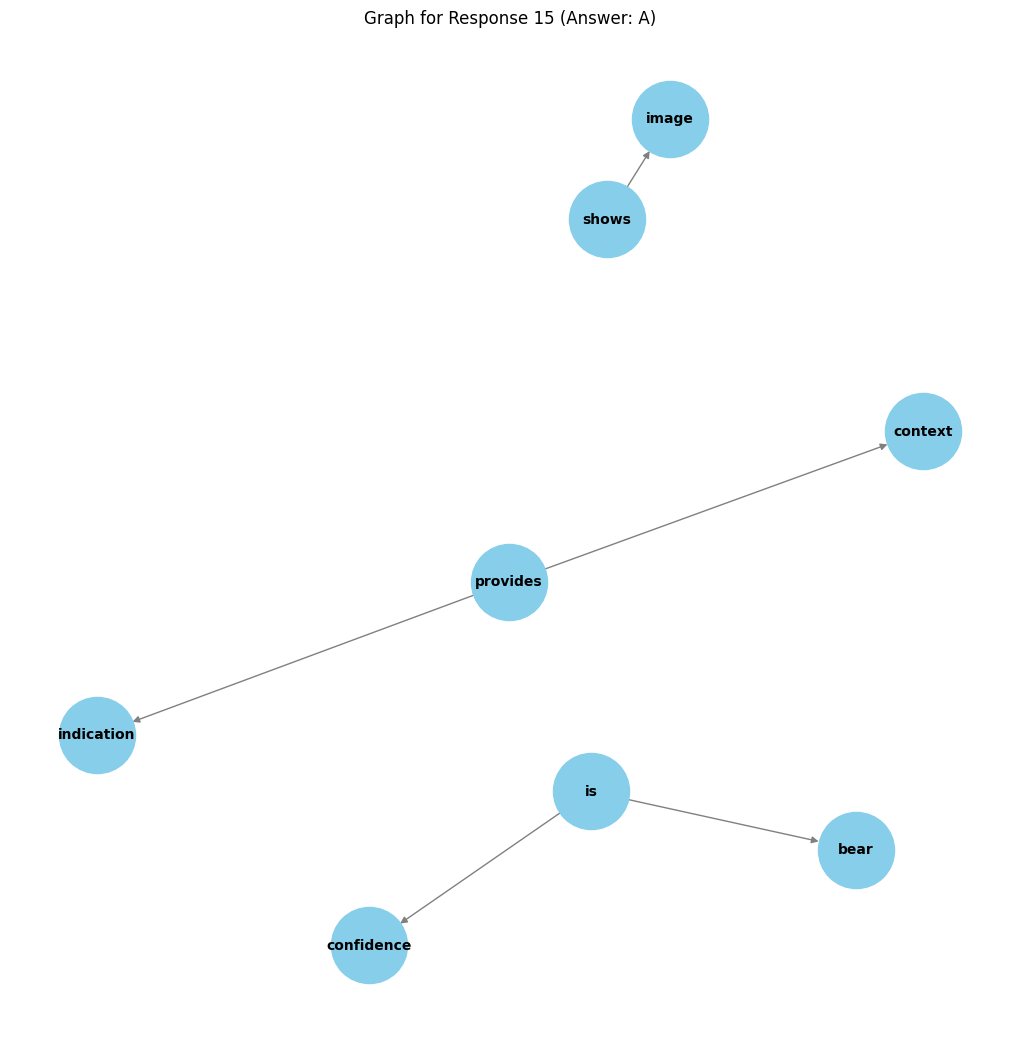

Visualizing for index: 2864
Explanation: The most likely and correct choice is 'A. the cake is on the table', as there is a cake on the table in the image which is clearly visible. The cake is the primary item in focus, and the placement suggests it is ready to be consumed. 'B. the table is on the cake' is contradictory as tables do not typically 'ride' on a cake, while 'C. nan' is a person and not relevant to the context given. 'D. nan' is also not relevant to the image, which focuses on a cake without any individual or group present.


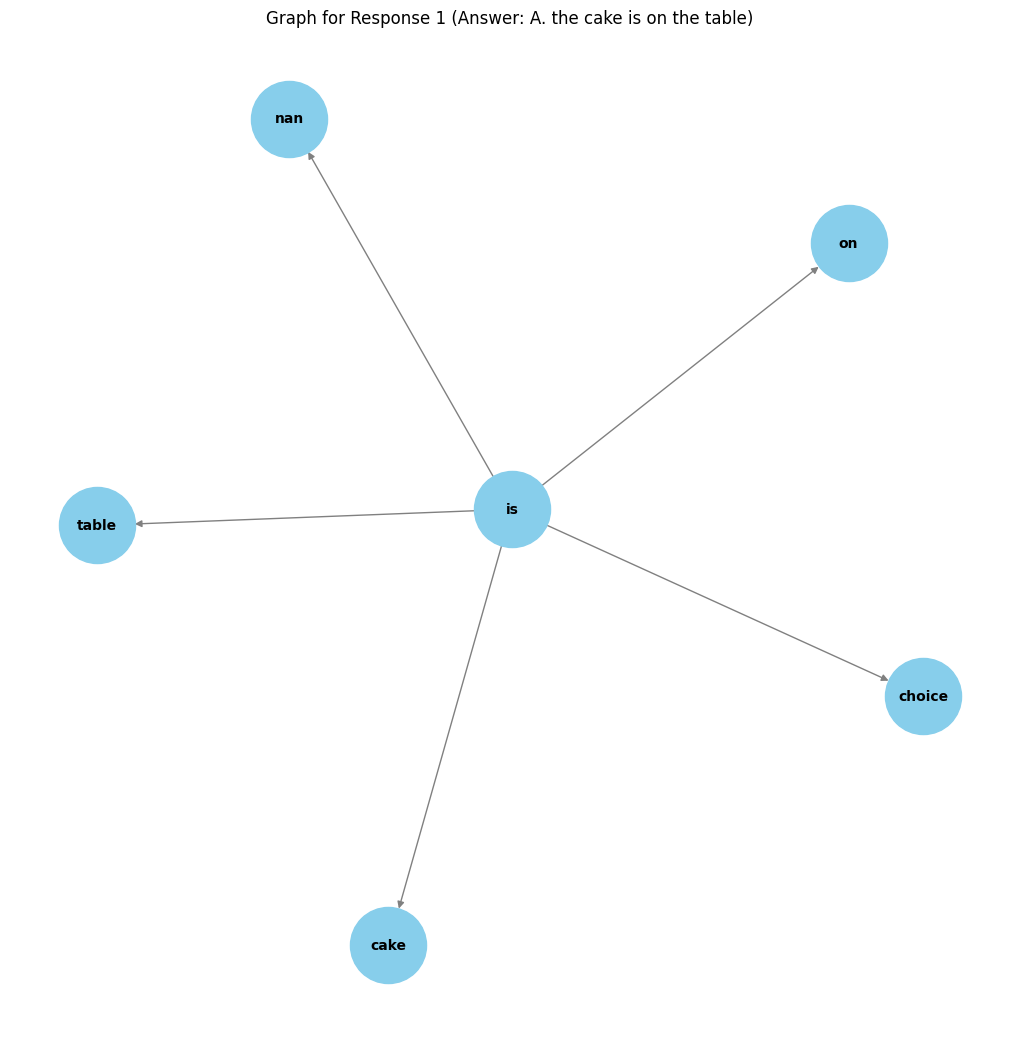

Explanation: In the context of the available options, 'on' indicates that the cake is located on the table, and 'table' is the correct object here. The cake and the table are close to each other, and the table is indeed on top of which the cake is placed. Therefore, the answer is 'A', 'the cake is on the table'.


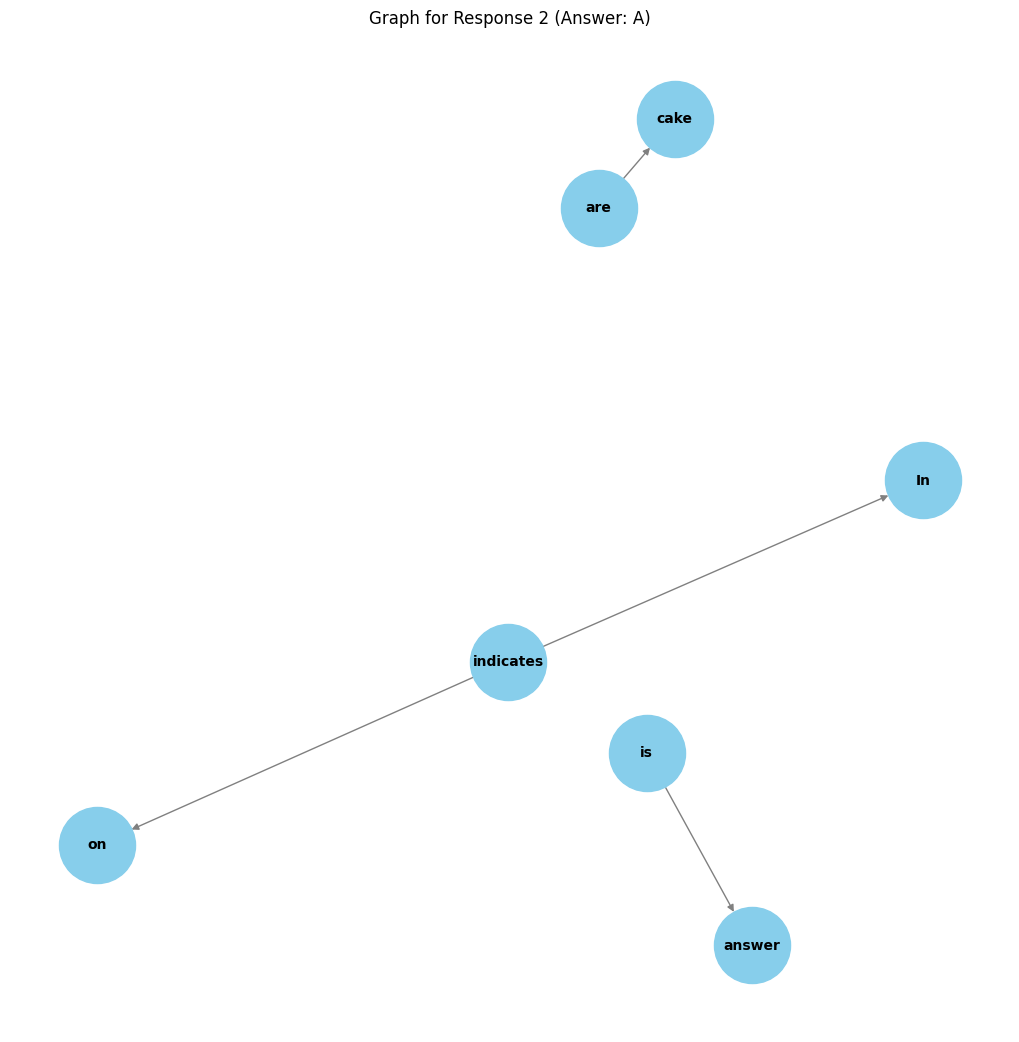

Explanation: The correct answer based on the context provided is 'B' as the table is indeed on the cake. The presence of plates with cake slices and utensils around the cake suggests it is on a table. A cake placed on the table could have multiple layers and be adorned with various decorations, and that is confirmed by the picture provided. There are no chairs on the cake, as chairs are typically located around the table for guests to sit, so we can confidently deduce that 'B' is the correct option.


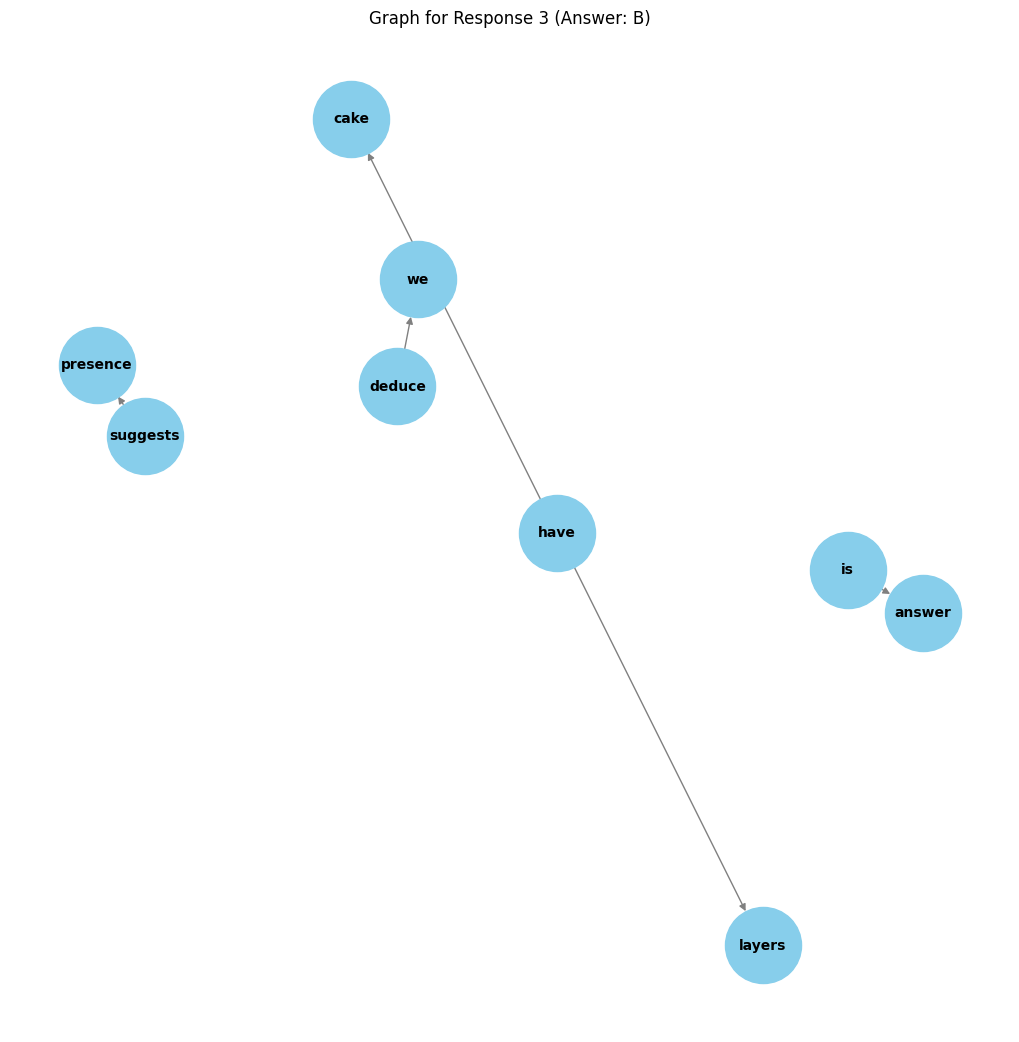

Explanation: The correct caption based on the image provided is 'A. the cake is on the table'. There is no evidence in the image to support the caption 'B. the table is on the cake' or 'C. nan'. Option 'D. nan' is likely a misspelling or a mistake, as it doesn't correspond to any caption from the four provided.


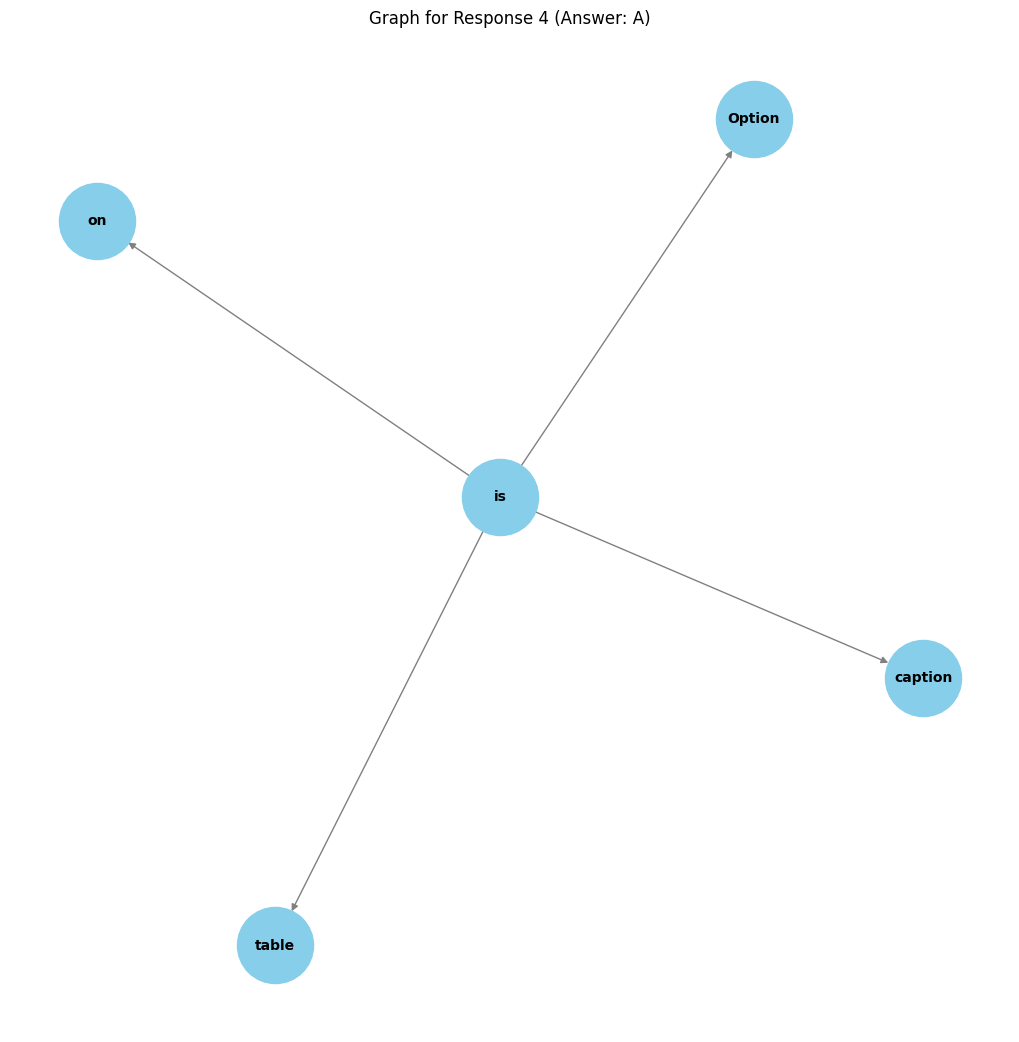

Explanation: The cake is displayed on a surface, and it appears to be the object of a celebration. Given that context, 'on' correctly describes the placement of the cake on the serving table. Options B, C, and D do not accurately describe the relationship of the cake and table.


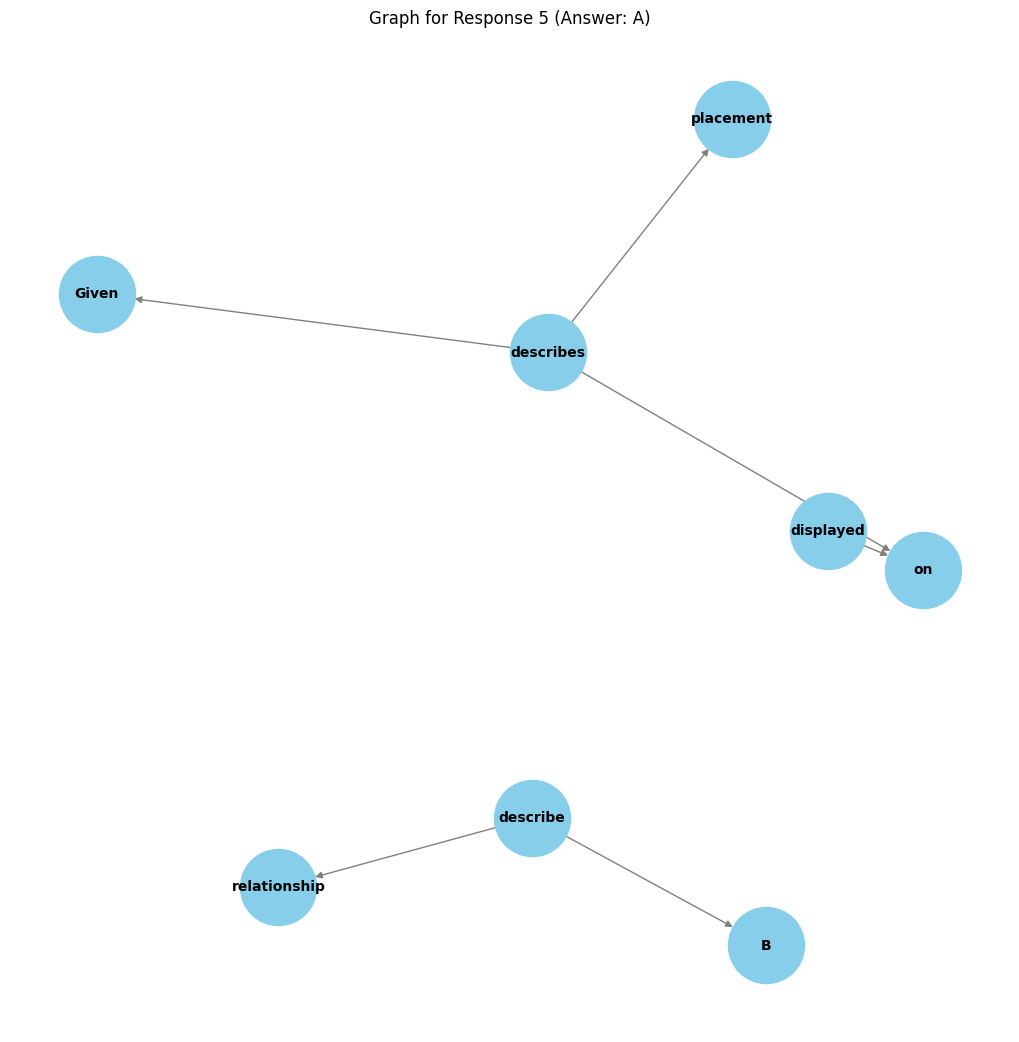

Explanation: The cake is on the table. The phrase 'On Birthday' and 'On 50th' suggest action involving the celebration, which is consistent with the cake's placement. The table provides the surface for the celebration and accommodates the cake, so 'on' in this context directly pertains to the cake being on the table.


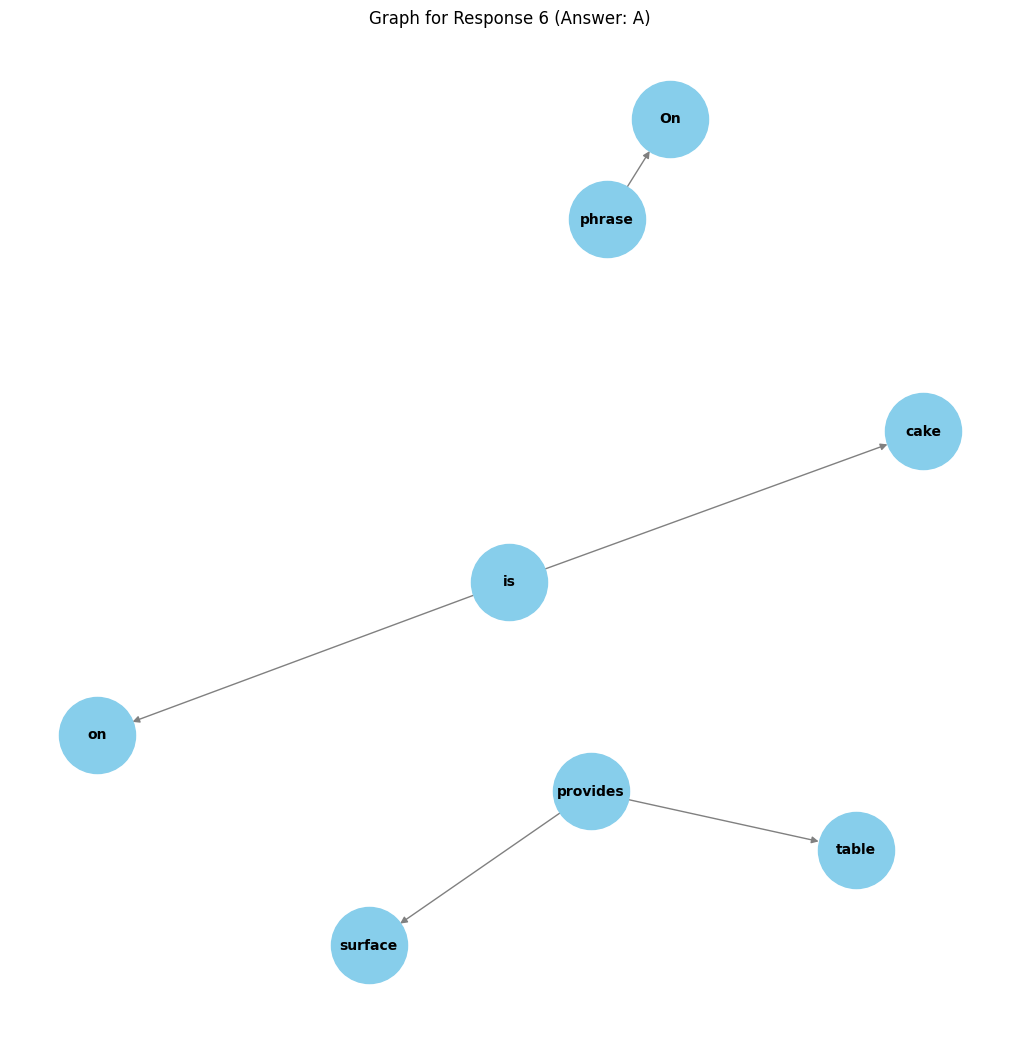

Explanation: While 'B' and 'D' may describe placement scenarios where the cake could be sitting on something rather than the table, they do not fit the exact context provided. Nan does not refer to a type of pastry that would be on or sitting on a table. Similarly, there's no reason to assume 'C' refers to a cake being on a table. For these reasons, 'A' is the most likely answer as it directly pertains to a cake sitting on top of the table. The cake itself is indeed on the white surface, as indicated by its placement in the image.


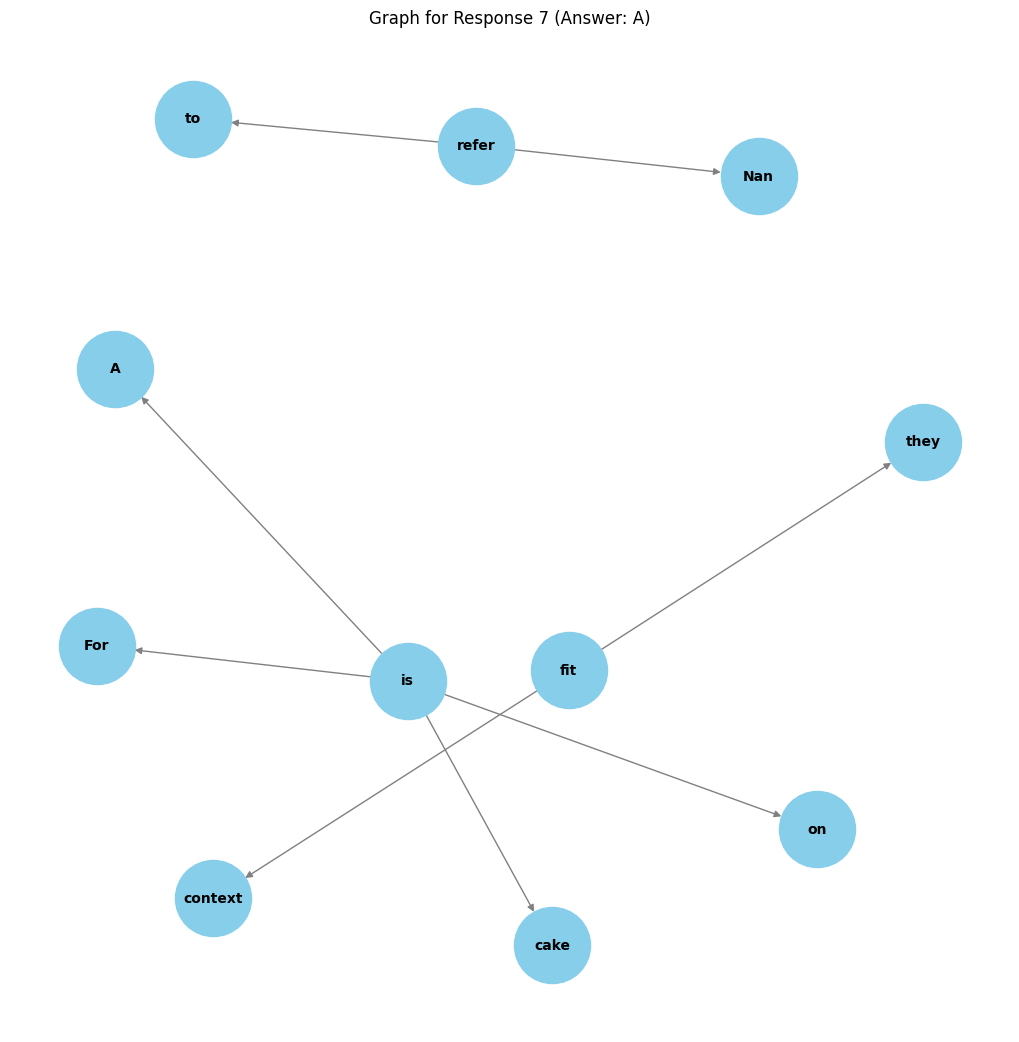

Explanation: The cake is the focal point of the image and is placed prominently in the middle of the table. The cake is not on the table, but rather it is the main decoration and item on the table. The table serves as a surface to display the cake. Hence, 'A' is the most correct answer as the cake is most likely the main subject in terms of relation 'on', while 'D', 'C', and 'B' do not accurately describe the relationship here.


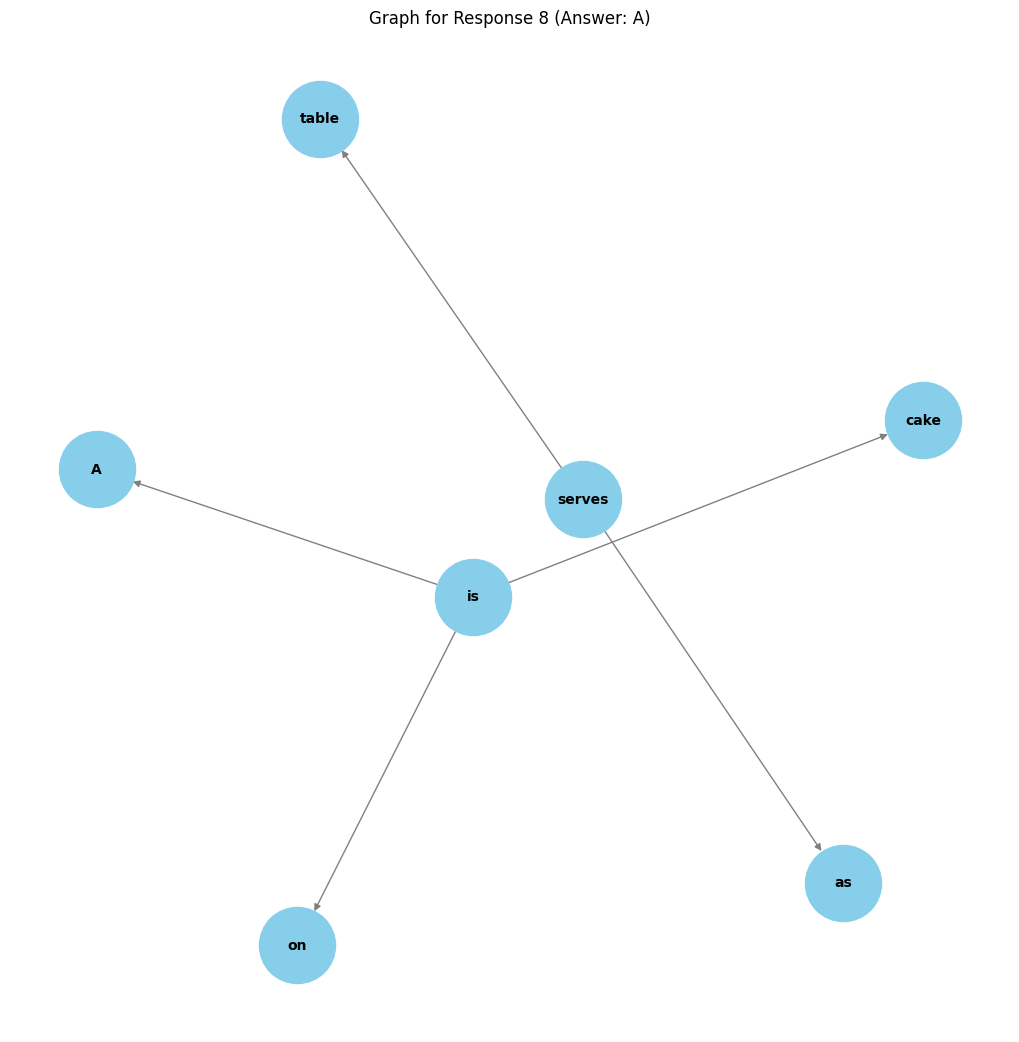

Explanation: The caption that suggests 'the table is on the cake' is likely correct, as it seems to describe the situation in front of the cake. There is a cake with red frosting and white writing on it, and plates of cake pieces are in the foreground with white plates and a red cloth in the background. The image suggests that the cake is being served onto plates from the cake itself, placing the table in the context of being on the surface of the cake, as the plates from the cake are placed on the table.


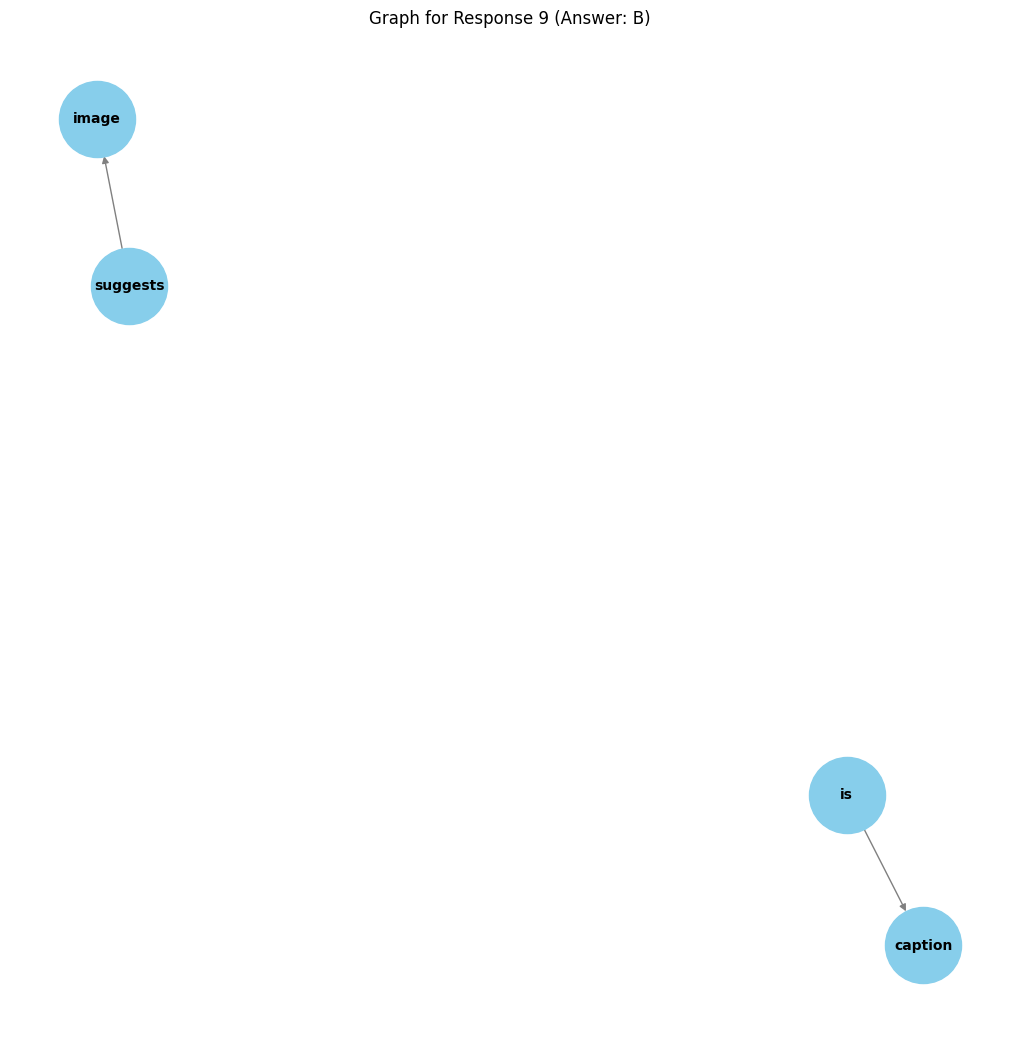

Explanation: The table is on the cake as evidenced by the cake being on a tablecloth and the cake sits on a table. Nan is not relevant to the image or question.


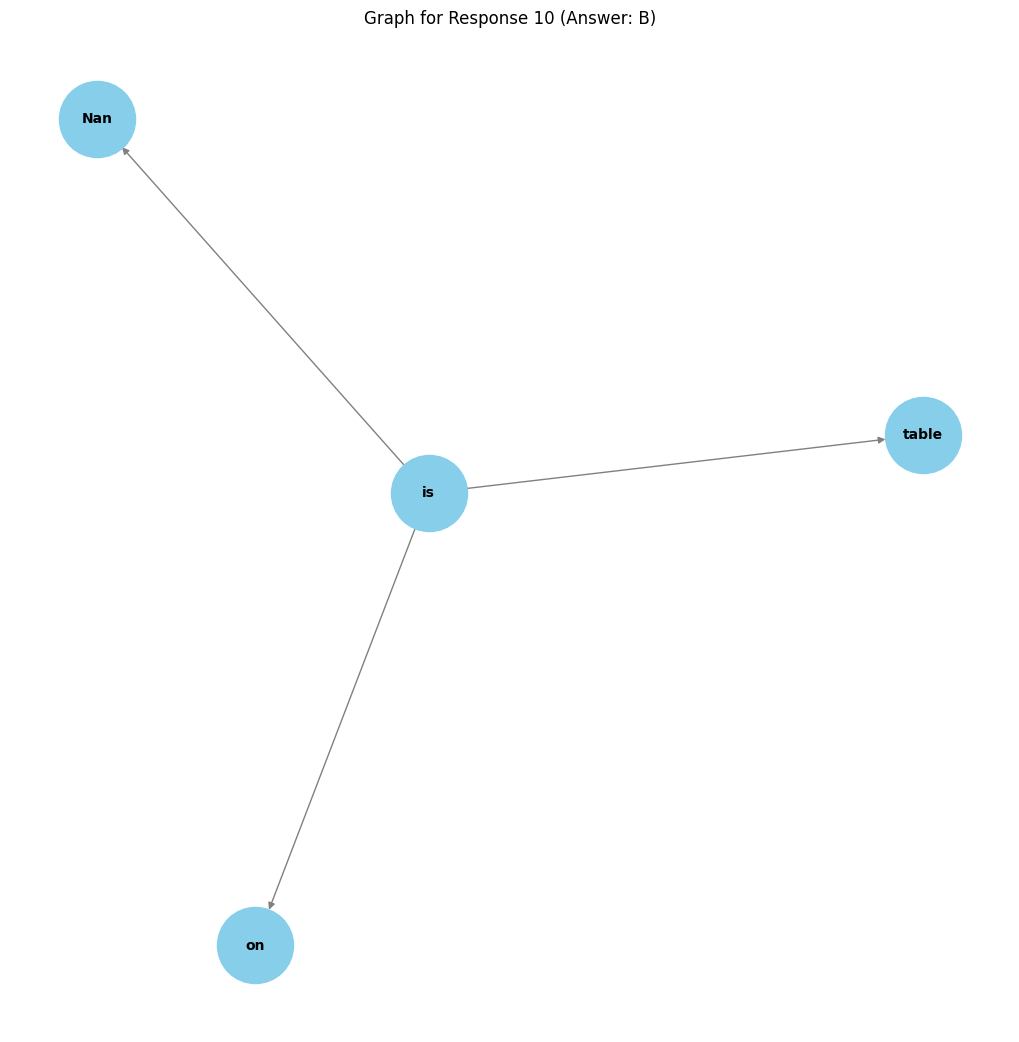

Explanation: The cake is on the table, suggesting it is present at the event. The other options do not seem to match this statement. 100% confident.


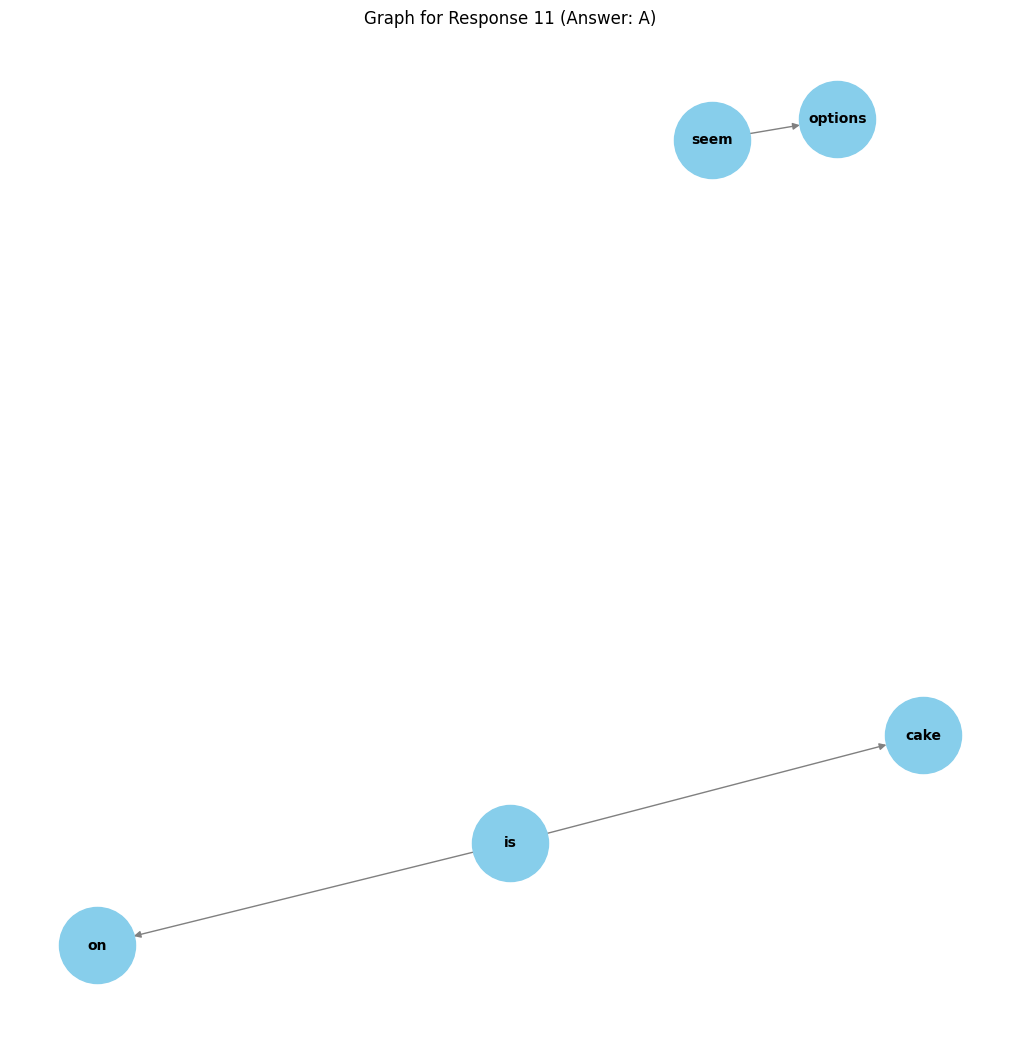

Explanation: The correct answer is 'C the cake is on the table'. In the image, it appears that a piece of cake is already served on a plate, and there is a whole cake still on the table. This indicates that the cake is on the table, not 'under' it, though the specific positioning of the cake on the table is not clear from the image.


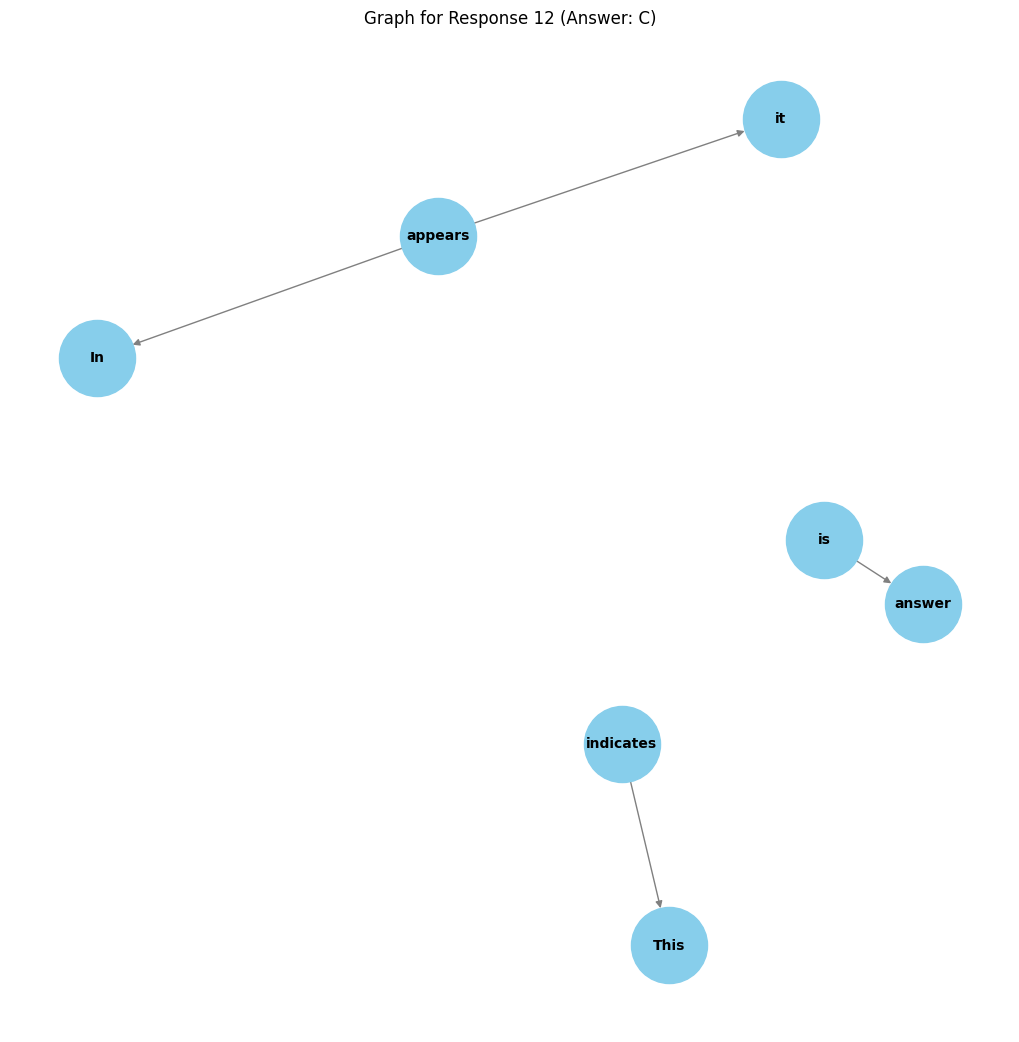

In [11]:
# bin 2 
path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/debug_bin_9_10_llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json'
with open(path, 'r') as file:   
    bin_2_results = json.load(file) 

# iterate over the responses and plot the graphs
for idx, result in bin_2_results.items():
    print(f"Visualizing for index: {idx}")
    for i, response in enumerate(result['responses']):
        try:
            adj_list = response.get('graph', {})
            G = adj_list_to_graph(adj_list)
            print('Explanation:', response.get('explanation', ''))
            title = f"Graph for Response {i + 1} (Answer: {response['answer']})"
            plot_graph(G, title)
        except Exception as e:
            print(f"Error: {e}")
            print(f"Response: {response}")